## Below is the Data Analysis work conducted for the Working Paper Series starting on Social Value, MFIs and SROI.

### This data analysis is being conducted on the macro level source data downloaded from RBI, NPCI, HCES and NABARD database sources

In [41]:
import pandas as pd
import numpy as np

In [42]:
# Base data directory
base_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded"

hces_dir = base_dir + "/HCES_MOSPI_Data"
npci_dir = base_dir + "/NPCI_Data"
rbi_dir  = base_dir + "/RBI_Data"

#### Loading the HCES files....

In [43]:
hces_22_noimp = pd.read_excel(hces_dir + "/Statement_8.xlsx")

hces_22_noimp.head()

,Statement 8: Average MPCE for each State/UT in 2022-23,Unnamed: 1,Unnamed: 2
0,State/UT,Average MPCE (Rs.),NaN
1,NaN,Rural,Urban
2,Andhra Pradesh,4870,6782
3,Arunachal Pradesh,5276,8636
4,Assam,3432,6136


In [44]:
stmt8_path = hces_dir + "/Statement_8.xlsx"

hces_22_raw = pd.read_excel(stmt8_path)

hces_22_raw.head()

,Statement 8: Average MPCE for each State/UT in 2022-23,Unnamed: 1,Unnamed: 2
0,State/UT,Average MPCE (Rs.),NaN
1,NaN,Rural,Urban
2,Andhra Pradesh,4870,6782
3,Arunachal Pradesh,5276,8636
4,Assam,3432,6136


In [45]:
# Finding the first row where State/UT is not NaN
mask_state_notnull = hces_22_raw["State/UT"].notna()
first_data_idx = hces_22_raw[mask_state_notnull].index.min()

# Keeping only rows from that index onward
hces_22 = hces_22_raw.loc[first_data_idx:].copy()

hces_22.head()

KeyError: 'State/UT'

In [46]:
import os

# Show current working directory
print("CWD:", os.getcwd())

# List contents of Data_downloaded
print(os.listdir("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded"))

CWD: /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded
['FIN_704_Data_Analysis.ipynb', '.DS_Store', 'MSc_Dissertation_Data_Analysis.ipynb', 'Additional_Data', 'RBI_Data', 'MOSPI_Declaration_Download_Data.docx', 'NPCI_Data', 'Health_Education_Data', 'Census_Data', '.ipynb_checkpoints', 'HCES_MOSPI_Data']


In [47]:
import os

hces_dir = os.path.join(os.getcwd(), "HCES_MOSPI_Data")
print("HCES directory:", hces_dir)
print("Files:", os.listdir(hces_dir))

HCES directory: /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data
Files: ['highlights-of-the-shg-bank-linkage-programme-2023-24.xlsx', 'HCES.xlsx', 'Highlights-2020-21.xlsx', 'Highlights of the SHG Bank Linkage Programme 2016-17.xlsx', 'Highlights 2017-18.pdf', 'annexure-i-2020-21.pdf', '.DS_Store', '1207192354SMFI 2018-19 (1).pdf', 'hces_8.xlsx', 'Table 3.5.xlsx', 'hces_3.xlsx', 'Highlights-2018-19.xlsx', 'highlights-of-the-shg-bank-linkage-programme-2022-23.xlsx', 'Highlights of the SHG-Bank Linkage Programme 2015-16.xlsx', 'Table 3.2.xlsx', 'Highlights 2017-18.xlsx', 'Statement_18.xlsx', 'highlights-of-the-shg-bank-linkage-programme-2022-23.pdf', 'somfi-2021-22 (1).pdf', 'Table 3.3.xlsx', 'Highlights of the SHG Bank Linkage Programme 2016-17.pdf', 'Self-Help-Group-Bank-Linkage-Programme-4.xlsx', 'Highlights-2019-20.xlsx', 'annexurei-2019-20.pdf', '1.xlsx', 'SoMFI-2020-21 (1).pdf', 'status-of-microfinance-in-indi

In [48]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"

stmt8_path = os.path.join(hces_dir, "Statement_8.xlsx")
hces_22_raw = pd.read_excel(stmt8_path)

print("Columns:", hces_22_raw.columns)
print(hces_22_raw.head(10))

Columns: Index(['Statement 8: Average MPCE for each State/UT in 2022-23', 'Unnamed: 1',
       'Unnamed: 2'],
      dtype='object')
  Statement 8: Average MPCE for each State/UT in 2022-23          Unnamed: 1  \
0                                           State/UT      Average MPCE (Rs.)   
1                                                NaN                   Rural   
2                                     Andhra Pradesh                    4870   
3                                  Arunachal Pradesh                    5276   
4                                              Assam                    3432   
5                                              Bihar                    3384   
6                                       Chhattisgarh                    2466   
7                                              Delhi                    6576   
8                                                Goa                    7367   
9                                            Gujarat                

In [49]:
# Loading raw file
hces_22_raw = pd.read_excel(stmt8_path)

# Dropping fully empty rows
hces_22 = hces_22_raw.dropna(how="all").reset_index(drop=True)

# We know:
# - Row 0: header labels (State/UT, Average MPCE, NaN)
# - Row 1: 'NaN', 'Rural', 'Urban'
# - Row 2 onward: actual data (State, rural MPCE, urban MPCE)

# Keeping rows from index 2 onwards
hces_22_data = hces_22.iloc[2:].copy()

# Renaming columns
hces_22_data = hces_22_data.rename(columns={
    "Statement 8: Average MPCE for each State/UT in 2022-23": "state_name",
    "Unnamed: 1": "MPCE_rural_22_noimp",
    "Unnamed: 2": "MPCE_urban_22_noimp"
})

# Cleaning state names
hces_22_data["state_name"] = hces_22_data["state_name"].astype(str).str.strip().str.upper()

# Converting MPCE columns to numeric
hces_22_data["MPCE_rural_22_noimp"] = pd.to_numeric(hces_22_data["MPCE_rural_22_noimp"], errors="coerce")
hces_22_data["MPCE_urban_22_noimp"] = pd.to_numeric(hces_22_data["MPCE_urban_22_noimp"], errors="coerce")

hces_22_data.head()

,state_name,MPCE_rural_22_noimp,MPCE_urban_22_noimp
2,ANDHRA PRADESH,4870.0,6782.0
3,ARUNACHAL PRADESH,5276.0,8636.0
4,ASSAM,3432.0,6136.0
5,BIHAR,3384.0,4768.0
6,CHHATTISGARH,2466.0,4483.0


In [50]:
# Creating master state frame from HCES state names
states = pd.DataFrame({
    "state_name": hces_22_data["state_name"].unique()
})

# Setting state_name as index
states = states.set_index("state_name")

states.head()

""
state_name
ANDHRA PRADESH
ARUNACHAL PRADESH
ASSAM
BIHAR
CHHATTISGARH


In [51]:
# Setting index on HCES data
hces_22_indexed = hces_22_data.set_index("state_name")

# Joining MPCE data to states
states = states.join(hces_22_indexed, how="left")

states.head()

,MPCE_rural_22_noimp,MPCE_urban_22_noimp
state_name,,
ANDHRA PRADESH,4870.0,6782.0
ARUNACHAL PRADESH,5276.0,8636.0
ASSAM,3432.0,6136.0
BIHAR,3384.0,4768.0
CHHATTISGARH,2466.0,4483.0


In [52]:
# Computing urban–rural MPCE gap (no imputation)
states["MPCE_gap_22_noimp"] = states["MPCE_urban_22_noimp"] - states["MPCE_rural_22_noimp"]

# Computing urban–rural MPCE ratio (no imputation)
states["MPCE_ratio_22_noimp"] = states["MPCE_urban_22_noimp"] / states["MPCE_rural_22_noimp"]

# Inspecting key columns
states[["MPCE_rural_22_noimp",
        "MPCE_urban_22_noimp",
        "MPCE_gap_22_noimp",
        "MPCE_ratio_22_noimp"]].head()

,MPCE_rural_22_noimp,MPCE_urban_22_noimp,MPCE_gap_22_noimp,MPCE_ratio_22_noimp
state_name,,,,
ANDHRA PRADESH,4870.0,6782.0,1912.0,1.392608
ARUNACHAL PRADESH,5276.0,8636.0,3360.0,1.636846
ASSAM,3432.0,6136.0,2704.0,1.787879
BIHAR,3384.0,4768.0,1384.0,1.408983
CHHATTISGARH,2466.0,4483.0,2017.0,1.817924


In [53]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"

stmt18_path = os.path.join(hces_dir, "Statement_18.xlsx")
hces_18_raw = pd.read_excel(stmt18_path)

print("Columns:", hces_18_raw.columns)
print(hces_18_raw.head(10))

Columns: Index(['Statement 18: Average MPCE for each State/UT in 2022-23', 'Unnamed: 1',
       'Unnamed: 2'],
      dtype='object')
  Statement 18: Average MPCE for each State/UT in 2022-23          Unnamed: 1  \
0                                           State/UT       Average MPCE (Rs.)   
1                                                NaN                    Rural   
2                                     Andhra Pradesh                     4996   
3                                  Arunachal Pradesh                     5300   
4                                              Assam                     3546   
5                                              Bihar                     3454   
6                                       Chhattisgarh                     2575   
7                                              Delhi                     6595   
8                                                Goa                     7388   
9                                            Gujarat     

In [54]:
# Dropping fully empty rows and resetting index
hces_18 = hces_18_raw.dropna(how="all").reset_index(drop=True)

# Keeping data rows from index 2 onward (skipping header and 'Rural/Urban' row)
hces_18_data = hces_18.iloc[2:].copy()

# Renaming columns using their current names
hces_18_data = hces_18_data.rename(columns={
    "Statement 18: Average MPCE for each State/UT in 2022-23": "state_name",
    "Unnamed: 1": "MPCE_rural_22_imp",
    "Unnamed: 2": "MPCE_urban_22_imp"
})

# Cleaning state names
hces_18_data["state_name"] = hces_18_data["state_name"].astype(str).str.strip().str.upper()

# Converting MPCE columns to numeric
hces_18_data["MPCE_rural_22_imp"] = pd.to_numeric(hces_18_data["MPCE_rural_22_imp"], errors="coerce")
hces_18_data["MPCE_urban_22_imp"] = pd.to_numeric(hces_18_data["MPCE_urban_22_imp"], errors="coerce")

hces_18_data.head()

,state_name,MPCE_rural_22_imp,MPCE_urban_22_imp
2,ANDHRA PRADESH,4996.0,6877.0
3,ARUNACHAL PRADESH,5300.0,8649.0
4,ASSAM,3546.0,6210.0
5,BIHAR,3454.0,4819.0
6,CHHATTISGARH,2575.0,4557.0


In [55]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"

table7_path = os.path.join(hces_dir, "Table_7.xlsx")
plfs_raw = pd.read_excel(table7_path)

print("Columns:", plfs_raw.columns)
print(plfs_raw.head(10))

Columns: Index(['Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6'],
      dtype='object')
  Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural  \
0                                                NaN                                                     
1                                         State \ UT                                                     
2                                                NaN                                                     
3                                                NaN                                                     
4                                                (1)                                                     
5                                     Andhra Pradesh                                                     
6                

In [56]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_raw = pd.read_excel(table7_path)

# Dropping fully empty rows and resetting the index
plfs = plfs_raw.dropna(how="all").reset_index(drop=True)

# Keeping rows from index 5 onwards 
plfs_rural_data = plfs.iloc[5:].copy()

# Column 0 = state name; column 5 = persons, 7+ literacy
state_col = plfs.columns[0]
persons7_col = plfs.columns[5]

plfs_rural = plfs_rural_data[[state_col, persons7_col]].copy()
plfs_rural.columns = ["state_name", "Literacy_rural_7plus"]

# Cleaning state names
plfs_rural["state_name"] = plfs_rural["state_name"].astype(str).str.strip().str.upper()

# Converting literacy to numeric
plfs_rural["Literacy_rural_7plus"] = pd.to_numeric(plfs_rural["Literacy_rural_7plus"], errors="coerce")

plfs_rural.head()

,state_name,Literacy_rural_7plus
5,ARUNACHAL PRADESH,81.9
6,ASSAM,87.0
7,BIHAR,71.0
8,CHHATTISGARH,76.1
9,DELHI,93.1


In [57]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

xls = pd.ExcelFile(table7_path)
print("Sheets:", xls.sheet_names)

Sheets: ['Sheet1', 'Sheet2', 'Sheet3']


In [58]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_sheet2 = pd.read_excel(table7_path, sheet_name="Sheet2")

print("Sheet2 columns:", plfs_sheet2.columns)
print(plfs_sheet2.head(10))

Sheet2 columns: RangeIndex(start=0, stop=0, step=1)
Empty DataFrame
Columns: []
Index: []


In [59]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_sheet3 = pd.read_excel(table7_path, sheet_name="Sheet3")

print("Sheet3 columns:", plfs_sheet3.columns)
print(plfs_sheet3.head(12))

Sheet3 columns: RangeIndex(start=0, stop=0, step=1)
Empty DataFrame
Columns: []
Index: []


In [60]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_raw = pd.read_excel(table7_path)

# Dropping fully empty rows and resetting index
plfs = plfs_raw.dropna(how="all").reset_index(drop=True)

# Quick look to see where the three headers sit
print(plfs.head(40))

   Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural  \
0                                          State \ UT                                                     
1                                                 NaN                                                     
2                                                 NaN                                                     
3                                                 (1)                                                     
4                                      Andhra Pradesh                                                     
5                                   Arunachal Pradesh                                                     
6                                               Assam                                                     
7                                               Bihar                                                     
8                                    

In [61]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_raw = pd.read_excel(table7_path) 
plfs = plfs_raw.dropna(how="all").reset_index(drop=True)

state_col = plfs.columns[0]        # col 0 = titles / State \ UT / state names
persons7_col = plfs.columns[5]     # col 5 = persons, 7 & above

In [62]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_raw = pd.read_excel(table7_path)
plfs = plfs_raw.dropna(how="all").reset_index(drop=True)

state_col = plfs.columns[0]        # first column
persons7_col = plfs.columns[5]     # persons, 7 & above 

# Finding all rows where "State \\ UT" appears — these mark the three blocks
state_ut_idxs = plfs[
    plfs[state_col].astype(str).str.strip() == "State \\ UT"
].index.tolist()

print("State \\ UT indices:", state_ut_idxs)

State \ UT indices: [0, 43, 86]


In [63]:
hces_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data"
table7_path = os.path.join(hces_dir, "Table_7.xlsx")

plfs_raw = pd.read_excel(table7_path)
plfs = plfs_raw.dropna(how="all").reset_index(drop=True)

state_col = plfs.columns[0]        # first column
persons7_col = plfs.columns[5]     # persons, 7 & above

state_ut_idxs = [0, 43, 86]        

In [64]:
def extract_block(plfs, header_idx, state_col):
    # First state row (Andhra Pradesh) after this header
    data_start = plfs[
        (plfs.index > header_idx) &
        (plfs[state_col].astype(str).str.contains("Andhra Pradesh"))
    ].index[0]
    
    # Last row for the block: "all India"
    data_end = plfs[
        (plfs.index >= data_start) &
        (plfs[state_col].astype(str).str.strip().str.lower() == "all india")
    ].index[0]
    
    return plfs.loc[data_start:data_end].copy()

rural_block = extract_block(plfs, state_ut_idxs[0], state_col)
urban_block = extract_block(plfs, state_ut_idxs[1], state_col)
total_block = extract_block(plfs, state_ut_idxs[2], state_col)

print(rural_block.head())
print(urban_block.head())
print(total_block.head())

  Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural  \
4                                     Andhra Pradesh                                                     
5                                  Arunachal Pradesh                                                     
6                                              Assam                                                     
7                                              Bihar                                                     
8                                       Chhattisgarh                                                     

  Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  
4       70.5       69.8         56       55.9       63.2       62.8  
5       86.6       86.5       76.6       76.7       81.9       81.8  
6       89.8       89.2       84.1       83.8         87       86.6  
7       79.8       79.7       61.6       62.4         71       71.4  
8       84.3 

In [65]:
rural_lit = rural_block[[state_col, persons7_col]].copy()
rural_lit.columns = ["state_name", "Literacy_rural_7plus"]

rural_lit["state_name"] = rural_lit["state_name"].astype(str).str.strip().str.upper()
rural_lit["Literacy_rural_7plus"] = pd.to_numeric(rural_lit["Literacy_rural_7plus"], errors="coerce")

print(rural_lit[rural_lit["state_name"] == "BIHAR"])

  state_name  Literacy_rural_7plus
7      BIHAR                  71.0


In [66]:
urban_lit = urban_block[[state_col, persons7_col]].copy()
urban_lit.columns = ["state_name", "Literacy_urban_7plus"]

urban_lit["state_name"] = urban_lit["state_name"].astype(str).str.strip().str.upper()
urban_lit["Literacy_urban_7plus"] = pd.to_numeric(urban_lit["Literacy_urban_7plus"], errors="coerce")

print(urban_lit[urban_lit["state_name"] == "BIHAR"])

   state_name  Literacy_urban_7plus
50      BIHAR                  82.4


In [67]:
total_lit = total_block[[state_col, persons7_col]].copy()
total_lit.columns = ["state_name", "Literacy_total_7plus"]

total_lit["state_name"] = total_lit["state_name"].astype(str).str.strip().str.upper()
total_lit["Literacy_total_7plus"] = pd.to_numeric(total_lit["Literacy_total_7plus"], errors="coerce")

print(total_lit[total_lit["state_name"] == "BIHAR"])

   state_name  Literacy_total_7plus
93      BIHAR                  72.3


In [68]:
base_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded"

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.lower().endswith(".xlsx"):
            print(os.path.join(root, f))

/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data/SMFI 2017-18-Extracted.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data/shg_digital_health_education_panels.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data/shg_digital_ratios_master.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data/shg_digital_ratios_all.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/RBI_Data/Self-Help Group-Bank Linkage Programme.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/RBI_Data/_Bank Credit of SCBs - Bank Group, Population Group, Occupation (Sector), District Wise - Annual.xlsx
/Users/d

In [69]:
deposits_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/RBI_Data/Bank Deposits of SCBs - Region, State, District, Bank Group, Population Group-Wise - Annual.xlsx"

xls_dep = pd.ExcelFile(deposits_path)
print("Deposits sheets:", xls_dep.sheet_names)

Deposits sheets: ['State Wise Summary', 'District Wise Summary', 'Bank Group Wise Summary', 'Data']


/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [70]:
deposits_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/RBI_Data/Bank Deposits of SCBs - Region, State, District, Bank Group, Population Group-Wise - Annual.xlsx"

dep_state = pd.read_excel(deposits_path, sheet_name="State Wise Summary")
print(dep_state.columns)
print(dep_state.head(10))

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')
   Unnamed: 0                                         Unnamed: 1  \
0         NaN  State wise, population group wise Deposit deta...   
1         NaN                                                NaN   
2         NaN                                               Year   
3         NaN                                                NaN   
4         NaN                                            2017-18   
5         NaN                                            2017-18   
6         NaN                                            2017-18   
7         NaN                                            2017-18   
8         NaN                                            2017-18   
9         NaN                                            2017-18   

                  Unna

In [71]:
dep_state = pd.read_excel(deposits_path, sheet_name="State Wise Summary")

# Keeping only rows with a valid year (to drop the header rows)
mask_year = dep_state["Unnamed: 1"].notna() & dep_state["Unnamed: 2"].notna()

dep_state_clean = dep_state.loc[mask_year].copy()

# Filtering to 2017-18 
dep_state_clean["Year"] = dep_state_clean["Unnamed: 1"].astype(str).str.strip()
print(dep_state_clean["Year"].unique())  # to see all available years

dep_2017 = dep_state_clean[dep_state_clean["Year"] == "2017-18"].copy()

# State names and total deposits
dep_2017["state_name"] = dep_2017["Unnamed: 2"].astype(str).str.strip().str.upper()
dep_2017["Deposits_total_2017_18"] = pd.to_numeric(dep_2017["Unnamed: 4"], errors="coerce")

dep_2017 = dep_2017[["state_name", "Deposits_total_2017_18"]]

print(dep_2017.head())

['Year' '2017-18' '2016-17' '2015-16' '2014-15' '2013-14' '2012-13'
 '2011-12' '2010-11' '2009-10']
                  state_name  Deposits_total_2017_18
4  ANDAMAN & NICOBAR ISLANDS               4683.3509
5             ANDHRA PRADESH             274565.8859
6          ARUNACHAL PRADESH              13448.9272
7                      ASSAM             134287.0908
8                      BIHAR             314811.2411


/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [72]:
dep_2017_idx = dep_2017.set_index("state_name")
states = states.join(dep_2017_idx, how="left")

states[["Deposits_total_2017_18"]].head()

,Deposits_total_2017_18
state_name,
ANDHRA PRADESH,274565.8859
ARUNACHAL PRADESH,13448.9272
ASSAM,134287.0908
BIHAR,314811.2411
CHHATTISGARH,132428.8082


In [73]:
ppra_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/1.xlsx"  # adjust if stored elsewhere

ppra_raw = pd.read_excel(ppra_path)
print(ppra_raw.head(10))
print(ppra_raw.columns)

  Table A1: Percentage of Persons that Responded as Ailing (PPRA) in each state/UT  \
0                                                NaN                                 
1                                           State/UT                                 
2                                                NaN                                 
3                                     Andhra Pradesh                                 
4                                  Arunachal Pradesh                                 
5                                              Assam                                 
6                                              Bihar                                 
7                                       Chhattisgarh                                 
8                                              Delhi                                 
9                                                Goa                                 

  Unnamed: 1                                       Un

In [74]:
ppra_raw = pd.read_excel(ppra_path)

state_col = ppra_raw.columns[0]      # table title / State/UT / state names
ppra_all_col = ppra_raw.columns[9]   # Unnamed: 9 = Rural+Urban, all

ppra = ppra_raw.copy()

# Keeping rows where state names start (excluding title/header rows and blanks)
ppra = ppra[ppra[state_col].notna()].copy()
ppra = ppra[ppra[state_col].astype(str).str.strip().str.lower() != "state/ut"]
ppra = ppra[ppra[state_col].astype(str).str.strip().str.lower() != "table a1: percentage of persons that responded as ailing (ppra) in each state/ut"]

# Building state_name and PPRA_total_2017_18
ppra["state_name"] = ppra[state_col].astype(str).str.strip().str.upper()
ppra["PPRA_total_2017_18"] = pd.to_numeric(ppra[ppra_all_col], errors="coerce")

ppra = ppra[["state_name", "PPRA_total_2017_18"]]

print(ppra.head())

          state_name  PPRA_total_2017_18
3     ANDHRA PRADESH                14.2
4  ARUNACHAL PRADESH                 2.9
5              ASSAM                 2.5
6              BIHAR                 2.5
7       CHHATTISGARH                 4.9


In [75]:
ppra_idx = ppra.set_index("state_name")

states = states.join(ppra_idx, how="left")

states[["PPRA_total_2017_18"]].head()

,PPRA_total_2017_18
state_name,
ANDHRA PRADESH,14.2
ARUNACHAL PRADESH,2.9
ASSAM,2.5
BIHAR,2.5
CHHATTISGARH,4.9


In [76]:
a17_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/17.xlsx"  # adjust if needed

a17_raw = pd.read_excel(a17_path)
print(a17_raw.head(10))
print(a17_raw.columns)

  Table A17: Average medical expenditure incurred for treatment during stay at hospital per case of hospitalization, by state/UT, separately for public and private hospitals in each sector  \
0  Average medical expenses (Rs.) during hospital...                                                                                                                                           
1                                           State/UT                                                                                                                                           
2                                                NaN                                                                                                                                           
3                                     Andhra Pradesh                                                                                                                                           
4                                  Aruna

In [77]:
a17_raw = pd.read_excel(a17_path)

state_col = a17_raw.columns[0]      # title / State/UT / state names
all_ru_col = a17_raw.columns[9]     # Unnamed: 9 = all providers, R+U

a17 = a17_raw.copy()

# Keeping rows with actual state names
a17 = a17[a17[state_col].notna()].copy()
a17 = a17[a17[state_col].astype(str).str.strip().str.lower() != "state/ut"]
a17 = a17[a17[state_col].astype(str).str.strip().str.lower() !=
          "table a17: average medical expenditure incurred for treatment during stay at hospital per case of hospitalization, by state/ut, separately for public and private hospitals in each sector"]

# Building state_name and all-providers, rural+urban hospitalisation cost
a17["state_name"] = a17[state_col].astype(str).str.strip().str.upper()
a17["HospExp_all_total_2017_18"] = pd.to_numeric(a17[all_ru_col], errors="coerce")

a17 = a17[["state_name", "HospExp_all_total_2017_18"]]

print(a17.head())

                                          state_name  \
0  AVERAGE MEDICAL EXPENSES (RS.) DURING HOSPITAL...   
3                                     ANDHRA PRADESH   
4                                  ARUNACHAL PRADESH   
5                                              ASSAM   
6                                              BIHAR   

   HospExp_all_total_2017_18  
0                        NaN  
3                    18665.0  
4                     4754.0  
5                    15661.0  
6                    12298.0  


In [78]:
a17_idx = a17.set_index("state_name")

states = states.join(a17_idx, how="left")

states[["HospExp_all_total_2017_18"]].head()

,HospExp_all_total_2017_18
state_name,
ANDHRA PRADESH,18665.0
ARUNACHAL PRADESH,4754.0
ASSAM,15661.0
BIHAR,12298.0
CHHATTISGARH,24521.0


In [79]:
shg_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Self-Help-Group-Bank-Linkage-Programme-4.xlsx"

xls_shg = pd.ExcelFile(shg_path)
print("SHG sheets:", xls_shg.sheet_names)

SHG sheets: ['Report 1']


/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [80]:
shg_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/RBI_Data/Self-Help Group-Bank Linkage Programme.xlsx"

shg_raw = pd.read_excel(shg_path, sheet_name="Report 1")
print(shg_raw.columns)
print(shg_raw.head(10))

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')
   Unnamed: 0                                     Unnamed: 1  \
0         NaN         Self-Help Group-Bank Linkage Programme   
1         NaN                                            NaN   
2         NaN  (Number in Lakhs and Amount in Rupees Crores)   
3         NaN                                            NaN   
4         NaN                             Year (end - March)   
5         NaN                                            NaN   
6         NaN                                              1   
7         NaN                                     2024-25      
8         NaN                                     2023-24      
9         NaN                                     2022-23      

                      Unnamed: 2  Unnamed: 3       Unnamed: 4  Unnamed: 5  \
0                            NaN         NaN              NaN        

In [81]:
shg_state_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Self-Help-Group-Bank-Linkage-Programme-4.xlsx"

xls_shg_state = pd.ExcelFile(shg_state_path)
print("State SHG sheets:", xls_shg_state.sheet_names)

shg_state_raw = pd.read_excel(shg_state_path, sheet_name=xls_shg_state.sheet_names[0])
print(shg_state_raw.columns)
print(shg_state_raw.head(10))

State SHG sheets: ['Report 1']
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')
   Unnamed: 0                                     Unnamed: 1  \
0         NaN         Self-Help Group-Bank Linkage Programme   
1         NaN                                            NaN   
2         NaN  (Number in Lakhs and Amount in Rupees Crores)   
3         NaN                                            NaN   
4         NaN                             Year (end - March)   
5         NaN                                            NaN   
6         NaN                                              1   
7         NaN                                     2024-25      
8         NaN                                     2023-24      
9         NaN                                     2022-23      

                      Unnamed: 2  Unnamed: 3       Unnamed: 4  Unnamed: 5  \
0                            NaN      

/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [82]:
upi_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-UPI-Product-statistics-upi-2018-19-Monthly.xlsx"

upi_raw = pd.read_excel(upi_path)
print(upi_raw.columns)
print(upi_raw.head())

Index(['Month', 'No. of Banks live on UPI', 'Volume (In Mn.)',
       'Value (In Cr.)'],
      dtype='object')
       Month  No. of Banks live on UPI  Volume (In Mn.) Value (In Cr.)
0 2019-03-01                       142           799.54    1,33,460.72
1 2019-02-01                       139           674.19    1,06,737.12
2 2019-01-01                       134           672.75    1,09,932.43
3 2018-12-01                       129           620.17    1,02,594.82
4 2018-11-01                       128           524.94       82232.21


In [83]:
upi_raw = pd.read_excel(upi_path)

# Cleaning Month to datetime
upi = upi_raw.copy()
upi["Month"] = pd.to_datetime(upi["Month"])

# Sorting chronologically
upi = upi.sort_values("Month")

print(upi.head())
print(upi.tail())

        Month  No. of Banks live on UPI  Volume (In Mn.) Value (In Cr.)
11 2018-04-01                        97           190.08       27021.85
10 2018-05-01                       101           189.48       33288.51
9  2018-06-01                       110           246.37       40834.03
8  2018-07-01                       114           273.75       51843.14
7  2018-08-01                       114           312.02       54212.26
       Month  No. of Banks live on UPI  Volume (In Mn.) Value (In Cr.)
4 2018-11-01                       128           524.94       82232.21
3 2018-12-01                       129           620.17    1,02,594.82
2 2019-01-01                       134           672.75    1,09,932.43
1 2019-02-01                       139           674.19    1,06,737.12
0 2019-03-01                       142           799.54    1,33,460.72


In [84]:
upi["Volume (In Mn.)"] = pd.to_numeric(upi["Volume (In Mn.)"], errors="coerce")

# Removing commas from Value and converting to float
upi["Value (In Cr.)"] = (
    upi["Value (In Cr.)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
upi["Value (In Cr.)"] = pd.to_numeric(upi["Value (In Cr.)"], errors="coerce")

# Banks live should already be numeric, but ensuring it
upi["No. of Banks live on UPI"] = pd.to_numeric(
    upi["No. of Banks live on UPI"], errors="coerce"
)

# Checking types
print(upi.dtypes)

Month                       datetime64[ns]
No. of Banks live on UPI             int64
Volume (In Mn.)                    float64
Value (In Cr.)                     float64
dtype: object


In [85]:
upi["Year"] = upi["Month"].dt.year

annual_upi = (
    upi.groupby("Year")
       .agg({
           "Volume (In Mn.)": "sum",           # total annual volume
           "Value (In Cr.)": "sum",            # total annual value
           "No. of Banks live on UPI": "max"   # max banks live that year
       })
       .reset_index()
)

annual_upi.rename(columns={
    "Volume (In Mn.)": "UPI_volume_Mn_year",
    "Value (In Cr.)": "UPI_value_Cr_year",
    "No. of Banks live on UPI": "UPI_banks_live_year"
}, inplace=True)

print(annual_upi)

   Year  UPI_volume_Mn_year  UPI_value_Cr_year  UPI_banks_live_year
0  2018             3245.04          526840.45                  129
1  2019             2146.48          350130.27                  142


In [86]:
import numpy as np
import statsmodels.api as sm

# 1. Creating log deposits
states["log_deposits_total_2017_18"] = np.log(states["Deposits_total_2017_18"])

# 2. Choosing an MPCE variable
states["MPCE_rural"] = states["MPCE_rural_22_noimp"] 

# 3. Building a model dataset and dropping missing values
model_data = states[[
    "HospExp_all_total_2017_18",
    "log_deposits_total_2017_18",
    "Literacy_total_7plus",
    "MPCE_rural",
    "PPRA_total_2017_18"
]].dropna()

print(model_data.shape)
print(model_data.head())

KeyError: "['Literacy_total_7plus'] not in index"

In [87]:
print(states.columns)

Index(['MPCE_rural_22_noimp', 'MPCE_urban_22_noimp', 'MPCE_gap_22_noimp',
       'MPCE_ratio_22_noimp', 'Deposits_total_2017_18', 'PPRA_total_2017_18',
       'HospExp_all_total_2017_18', 'log_deposits_total_2017_18',
       'MPCE_rural'],
      dtype='object')


In [88]:
# 1. Building a model dataset and dropping missing values
model_data_no_lit = states[[
    "HospExp_all_total_2017_18",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "PPRA_total_2017_18"
]].dropna()

Y_no_lit = model_data_no_lit["HospExp_all_total_2017_18"]
X_no_lit = model_data_no_lit[[
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "PPRA_total_2017_18"
]]

X_no_lit = sm.add_constant(X_no_lit)

model_no_lit = sm.OLS(Y_no_lit, X_no_lit).fit()
print(model_no_lit.summary())

                                OLS Regression Results                               
Dep. Variable:     HospExp_all_total_2017_18   R-squared:                       0.291
Model:                                   OLS   Adj. R-squared:                  0.215
Method:                        Least Squares   F-statistic:                     3.838
Date:                       Mon, 10 Aug 2026   Prob (F-statistic):             0.0203
Time:                               17:09:22   Log-Likelihood:                -332.24
No. Observations:                         32   AIC:                             672.5
Df Residuals:                             28   BIC:                             678.3
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [89]:
plfs_t7_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Table_7.xlsx"  # adjust if needed

plfs_t7 = pd.read_excel(plfs_t7_path)
print(plfs_t7.columns)
print(plfs_t7.head(10))

Index(['Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6'],
      dtype='object')
  Table (7): Literacy rate (in per cent) of persons of different age groups for each State/UT\n\nrural  \
0                                                NaN                                                     
1                                         State \ UT                                                     
2                                                NaN                                                     
3                                                NaN                                                     
4                                                (1)                                                     
5                                     Andhra Pradesh                                                     
6                         

In [90]:
state_col = plfs_t7.columns[0]   # "State \ UT"
persons_7plus_col = plfs_t7.columns[5]  # Unnamed: 5 = persons 7 & above (rural)

t7_rural = plfs_t7.copy()

# Keeping rows with real state names
t7_rural = t7_rural[t7_rural[state_col].notna()].copy()
t7_rural = t7_rural[
    t7_rural[state_col].astype(str).str.strip().str.lower() != "state \\ ut"
]
t7_rural = t7_rural[
    t7_rural[state_col].astype(str).str.strip().str.lower() !=
    "table (7): literacy rate (in per cent) of persons of different age groups for each state/ut"
]

# Building state_name and rural literacy (persons 7+)
t7_rural["state_name"] = t7_rural[state_col].astype(str).str.strip().str.upper()
t7_rural["Literacy_rural_7plus"] = pd.to_numeric(
    t7_rural[persons_7plus_col], errors="coerce"
)

t7_rural = t7_rural[["state_name", "Literacy_rural_7plus"]]

print(t7_rural.head())

          state_name  Literacy_rural_7plus
4                (1)                   NaN
5     ANDHRA PRADESH                  63.2
6  ARUNACHAL PRADESH                  81.9
7              ASSAM                  87.0
8              BIHAR                  71.0


In [91]:
t7_rural_idx = t7_rural.set_index("state_name")
states = states.join(t7_rural_idx, how="left")

print(states[["Literacy_rural_7plus"]].head())

                   Literacy_rural_7plus
state_name                             
ANDHRA PRADESH                     63.2
ANDHRA PRADESH                     81.1
ANDHRA PRADESH                     68.9
ARUNACHAL PRADESH                  81.9
ARUNACHAL PRADESH                  91.8


In [92]:
# Starting from the literacy_rural_7plus series as currently in states
lit_rural = states[["Literacy_rural_7plus"]].copy()
lit_rural["state_name"] = states.index  # assuming state_name is index

# Dropping rows without literacy
lit_rural = lit_rural.dropna(subset=["Literacy_rural_7plus"])

# Grouping by state_name and taking the mean
lit_rural_collapsed = (
    lit_rural.groupby("state_name")["Literacy_rural_7plus"]
    .mean()
    .reset_index()
)

print(lit_rural_collapsed.head())

ValueError: 'state_name' is both an index level and a column label, which is ambiguous.

In [93]:
# 1. Pulling out the literacy series with state_name as index
lit_rural = states[["Literacy_rural_7plus"]].copy()

# 2. Dropping rows without literacy
lit_rural = lit_rural.dropna(subset=["Literacy_rural_7plus"])

# 3. Grouping by the index (state_name) and taking the mean
lit_rural_collapsed = (
    lit_rural.groupby(lit_rural.index)["Literacy_rural_7plus"]
    .mean()
    .reset_index()
)

lit_rural_collapsed.columns = ["state_name", "Literacy_rural_7plus"]

print(lit_rural_collapsed.head())

          state_name  Literacy_rural_7plus
0     ANDHRA PRADESH             71.066667
1  ARUNACHAL PRADESH             85.800000
2              ASSAM             89.666667
3              BIHAR             75.233333
4         CHANDIGARH             90.266667


In [94]:
model_data_lit_rural = states[[
    "HospExp_all_total_2017_18",
    "log_deposits_total_2017_18",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "PPRA_total_2017_18"
]].dropna()

Y_lit_rural = model_data_lit_rural["HospExp_all_total_2017_18"]
X_lit_rural = model_data_lit_rural[[
    "log_deposits_total_2017_18",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "PPRA_total_2017_18"
]]

X_lit_rural = sm.add_constant(X_lit_rural)

model_lit_rural = sm.OLS(Y_lit_rural, X_lit_rural).fit()
print(model_lit_rural.summary())

                                OLS Regression Results                               
Dep. Variable:     HospExp_all_total_2017_18   R-squared:                       0.292
Model:                                   OLS   Adj. R-squared:                  0.261
Method:                        Least Squares   F-statistic:                     9.375
Date:                       Mon, 10 Aug 2026   Prob (F-statistic):           2.17e-06
Time:                               17:09:44   Log-Likelihood:                -996.69
No. Observations:                         96   AIC:                             2003.
Df Residuals:                             91   BIC:                             2016.
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [95]:
model_data_lit_outcome = states[[
    "Literacy_rural_7plus",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
 
]].dropna()

Y_lit = model_data_lit_outcome["Literacy_rural_7plus"]
X_lit = model_data_lit_outcome[["log_deposits_total_2017_18", "MPCE_rural_22_noimp"]]

X_lit = sm.add_constant(X_lit)

model_lit_outcome = sm.OLS(Y_lit, X_lit).fit()
print(model_lit_outcome.summary())

                             OLS Regression Results                             
Dep. Variable:     Literacy_rural_7plus   R-squared:                       0.348
Model:                              OLS   Adj. R-squared:                  0.334
Method:                   Least Squares   F-statistic:                     24.79
Date:                  Mon, 10 Aug 2026   Prob (F-statistic):           2.35e-09
Time:                          17:09:48   Log-Likelihood:                -323.35
No. Observations:                    96   AIC:                             652.7
Df Residuals:                        93   BIC:                             660.4
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------


In [96]:
model_data_dep = states[[
    "log_deposits_total_2017_18",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp"
]].dropna()

Y_dep = model_data_dep["log_deposits_total_2017_18"]
X_dep = model_data_dep[["Literacy_rural_7plus", "MPCE_rural_22_noimp"]]

X_dep = sm.add_constant(X_dep)

model_dep = sm.OLS(Y_dep, X_dep).fit()
print(model_dep.summary())

                                OLS Regression Results                                
Dep. Variable:     log_deposits_total_2017_18   R-squared:                       0.382
Model:                                    OLS   Adj. R-squared:                  0.369
Method:                         Least Squares   F-statistic:                     28.79
Date:                        Mon, 10 Aug 2026   Prob (F-statistic):           1.85e-10
Time:                                17:09:51   Log-Likelihood:                -168.50
No. Observations:                          96   AIC:                             343.0
Df Residuals:                              93   BIC:                             350.7
Df Model:                                   2                                         
Covariance Type:                    nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [97]:
a1_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Census_Data/A-1_NO_OF_VILLAGES_TOWNS_HOUSEHOLDS_POPULATION_AND_AREA.xlsx"
a1 = pd.read_excel(a1_path)

In [98]:
# Keeping only state-level rows (India/State level; excluding districts/sub-districts)
state_rows = a1[a1["India/ State/ Union Territory/ District/ Sub-district Name"]
                .str.startswith("STATE")].copy()

# Cleaning state name
state_rows["state_name"] = (
    state_rows["India/ State/ Union Territory/ District/ Sub-district Name"]
    .str.replace("STATE ", "", regex=False)
    .str.strip()
)

# Selecting Total and Urban population rows
total_pop = state_rows[state_rows["Total/ Rural/ Urban"] == "Total"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_total_2011"})

urban_pop = state_rows[state_rows["Total/ Rural/ Urban"] == "Urban"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_urban_2011"})

# Merging and computing urban share
urban_share = total_pop.merge(urban_pop, on="state_name", how="inner")
urban_share["urban_share_2011"] = (
    urban_share["pop_urban_2011"] / urban_share["pop_total_2011"]
)

# Joining to the existing `states` dataframe
states = states.join(
    urban_share.set_index("state_name")[["urban_share_2011"]],
    on="state_name"
)

print(states[["urban_share_2011"]].head())

KeyError: 'India/ State/ Union Territory/ District/ Sub-district Name'

In [99]:
a1.columns

Index(['A-1 NUMBER OF VILLAGES, TOWNS, HOUSEHOLDS, POPULATION AND AREA',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14'],
      dtype='object')

In [100]:
a1_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Census_Data/A-1_NO_OF_VILLAGES_TOWNS_HOUSEHOLDS_POPULATION_AND_AREA.xlsx"

a1 = pd.read_excel(a1_path, header=1)

print(a1.columns)

Index(['State  Code', 'District Code', 'Sub District Code',
       'India/ State/ Union Territory/ District/ Sub-district', 'Name',
       'Total/\nRural/\nUrban', 'Number of villages', 'Unnamed: 7',
       'Number of towns', 'Number of households', 'Population', 'Unnamed: 11',
       'Unnamed: 12', 'Area\n (In sq. km)', 'Population per sq. km.'],
      dtype='object')


In [101]:
import os
print(os.getcwd())

/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded


In [102]:
a1_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Census_Data/A-1_NO_OF_VILLAGES_TOWNS_HOUSEHOLDS_POPULATION_AND_AREA.xlsx"
a1 = pd.read_excel(a1_path, header=1)
print(a1.columns)

Index(['State  Code', 'District Code', 'Sub District Code',
       'India/ State/ Union Territory/ District/ Sub-district', 'Name',
       'Total/\nRural/\nUrban', 'Number of villages', 'Unnamed: 7',
       'Number of towns', 'Number of households', 'Population', 'Unnamed: 11',
       'Unnamed: 12', 'Area\n (In sq. km)', 'Population per sq. km.'],
      dtype='object')


In [103]:
name_col = "India/ State/ Union Territory/ District/ Sub-district"

# Keeping only STATE-level rows
state_rows = a1[a1[name_col].str.startswith("STATE")].copy()

# Cleaning state_name (dropping the leading "STATE ")
state_rows["state_name"] = (
    state_rows[name_col]
    .str.replace("STATE ", "", regex=False)
    .str.strip()
)

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [104]:
name_col = "India/ State/ Union Territory/ District/ Sub-district"

# Boolean mask: True where the name is non-missing and starts with "STATE"
mask_states = a1[name_col].notna() & a1[name_col].str.startswith("STATE")

state_rows = a1[mask_states].copy()

In [105]:
state_rows["state_name"] = (
    state_rows[name_col]
    .str.replace("STATE ", "", regex=False)
    .str.strip()
)

In [106]:
# Total population
total_pop = state_rows[state_rows["Total/\nRural/\nUrban"] == "Total"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_total_2011"})

# Urban population
urban_pop = state_rows[state_rows["Total/\nRural/\nUrban"] == "Urban"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_urban_2011"})

urban_share = total_pop.merge(urban_pop, on="state_name", how="inner")
urban_share["urban_share_2011"] = (
    urban_share["pop_urban_2011"] / urban_share["pop_total_2011"]
)

print(urban_share.head())

  state_name pop_total_2011 pop_urban_2011 urban_share_2011
0      STATE       12541302        3433242         0.273755
1      STATE       12541302         688552         0.054903
2      STATE       12541302       10399146         0.829192
3      STATE       12541302        1026459         0.081846
4      STATE       12541302        3049338         0.243144


In [107]:
name_col = "India/ State/ Union Territory/ District/ Sub-district"

# Masking for STATE-level rows (dropping NaNs and checking type)
mask_states = a1[name_col].notna() & a1[name_col].str.startswith("STATE")

state_rows = a1[mask_states].copy()

# Using the 'Name' column as the true state name
state_rows["state_name"] = state_rows["Name"].str.strip()

In [108]:
# Total population by state
total_pop = state_rows[state_rows["Total/\nRural/\nUrban"] == "Total"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_total_2011"})

# Urban population by state
urban_pop = state_rows[state_rows["Total/\nRural/\nUrban"] == "Urban"][[
    "state_name", "Population"
]].rename(columns={"Population": "pop_urban_2011"})

urban_share = total_pop.merge(urban_pop, on="state_name", how="inner")
urban_share["urban_share_2011"] = (
    urban_share["pop_urban_2011"] / urban_share["pop_total_2011"]
)

print(urban_share.head())

         state_name pop_total_2011 pop_urban_2011 urban_share_2011
0  HIMACHAL PRADESH        6864602         688552         0.100305
1            PUNJAB       27743338       10399146         0.374834
2        CHANDIGARH        1055450        1026459         0.972532
3       UTTARAKHAND       10086292        3049338         0.302325
4           HARYANA       25351462        8842103         0.348781


In [109]:
print(states[["state_name", "urban_share_2011"]].head(10))

KeyError: "None of [Index(['state_name', 'urban_share_2011'], dtype='object')] are in the [columns]"

In [110]:
print(states.index.name)
print(states.columns)

state_name
Index(['MPCE_rural_22_noimp', 'MPCE_urban_22_noimp', 'MPCE_gap_22_noimp',
       'MPCE_ratio_22_noimp', 'Deposits_total_2017_18', 'PPRA_total_2017_18',
       'HospExp_all_total_2017_18', 'log_deposits_total_2017_18', 'MPCE_rural',
       'Literacy_rural_7plus'],
      dtype='object')


In [111]:
# Indexing urban_share by state_name
urban_share_idx = urban_share.set_index("state_name")

# Joining to states (state_name index)
states = states.join(urban_share_idx[["urban_share_2011"]], how="left")

In [112]:
model_data_dep_urb = states[[
    "log_deposits_total_2017_18",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]].dropna()

Y_dep_urb = model_data_dep_urb["log_deposits_total_2017_18"]
X_dep_urb = model_data_dep_urb[[
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]]

X_dep_urb = sm.add_constant(X_dep_urb)
model_dep_urb = sm.OLS(Y_dep_urb, X_dep_urb).fit()
print(model_dep_urb.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [113]:
print(model_data_dep_urb.dtypes)

log_deposits_total_2017_18    float64
Literacy_rural_7plus          float64
MPCE_rural_22_noimp           float64
urban_share_2011               object
dtype: object


In [114]:
states["urban_share_2011"] = (
    states["urban_share_2011"].astype(str).str.replace(",", "", regex=False)
)

# Converting to numeric
states["urban_share_2011"] = pd.to_numeric(states["urban_share_2011"], errors="coerce")

print(states["urban_share_2011"].dtype)

float64


In [115]:
model_data_dep_urb = states[[
    "log_deposits_total_2017_18",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]].dropna()

print(model_data_dep_urb.dtypes) 

Y_dep_urb = model_data_dep_urb["log_deposits_total_2017_18"]
X_dep_urb = model_data_dep_urb[[
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]]

X_dep_urb = sm.add_constant(X_dep_urb)
model_dep_urb = sm.OLS(Y_dep_urb, X_dep_urb).fit()
print(model_dep_urb.summary())

log_deposits_total_2017_18    float64
Literacy_rural_7plus          float64
MPCE_rural_22_noimp           float64
urban_share_2011              float64
dtype: object
                                OLS Regression Results                                
Dep. Variable:     log_deposits_total_2017_18   R-squared:                       0.398
Model:                                    OLS   Adj. R-squared:                  0.377
Method:                         Least Squares   F-statistic:                     18.96
Date:                        Mon, 10 Aug 2026   Prob (F-statistic):           1.58e-09
Time:                                17:10:52   Log-Likelihood:                -158.91
No. Observations:                          90   AIC:                             325.8
Df Residuals:                              86   BIC:                             335.8
Df Model:                                   3                                         
Covariance Type:                    nonrobust      

In [116]:
print(os.listdir())  

shg_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Self-Help-Group-Bank-Linkage-Programme-4.xlsx"
shg_xls = pd.ExcelFile(shg_path)
print(shg_xls.sheet_names)

['FIN_704_Data_Analysis.ipynb', '.DS_Store', 'MSc_Dissertation_Data_Analysis.ipynb', 'Additional_Data', 'RBI_Data', 'MOSPI_Declaration_Download_Data.docx', 'NPCI_Data', 'Health_Education_Data', 'Census_Data', '.ipynb_checkpoints', 'HCES_MOSPI_Data']
['Report 1']


/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [117]:
print(os.listdir())  


print(os.listdir("HCES_MOSPI_Data"))

['FIN_704_Data_Analysis.ipynb', '.DS_Store', 'MSc_Dissertation_Data_Analysis.ipynb', 'Additional_Data', 'RBI_Data', 'MOSPI_Declaration_Download_Data.docx', 'NPCI_Data', 'Health_Education_Data', 'Census_Data', '.ipynb_checkpoints', 'HCES_MOSPI_Data']
['highlights-of-the-shg-bank-linkage-programme-2023-24.xlsx', 'HCES.xlsx', 'Highlights-2020-21.xlsx', 'Highlights of the SHG Bank Linkage Programme 2016-17.xlsx', 'Highlights 2017-18.pdf', 'annexure-i-2020-21.pdf', '.DS_Store', '1207192354SMFI 2018-19 (1).pdf', 'hces_8.xlsx', 'Table 3.5.xlsx', 'hces_3.xlsx', 'Highlights-2018-19.xlsx', 'highlights-of-the-shg-bank-linkage-programme-2022-23.xlsx', 'Highlights of the SHG-Bank Linkage Programme 2015-16.xlsx', 'Table 3.2.xlsx', 'Highlights 2017-18.xlsx', 'Statement_18.xlsx', 'highlights-of-the-shg-bank-linkage-programme-2022-23.pdf', 'somfi-2021-22 (1).pdf', 'Table 3.3.xlsx', 'Highlights of the SHG Bank Linkage Programme 2016-17.pdf', 'Self-Help-Group-Bank-Linkage-Programme-4.xlsx', 'Highlights-2

In [118]:
shg_xls = pd.ExcelFile(shg_path)
print(shg_xls.sheet_names)

shg_df = pd.read_excel(shg_path, sheet_name=shg_xls.sheet_names[0])
print(shg_df.columns)
print(shg_df.head())

['Report 1']
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')
   Unnamed: 0                                     Unnamed: 1  \
0         NaN         Self-Help Group-Bank Linkage Programme   
1         NaN                                            NaN   
2         NaN  (Number in Lakhs and Amount in Rupees Crores)   
3         NaN                                            NaN   
4         NaN                             Year (end - March)   

                      Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  Unnamed: 6  \
0                            NaN        NaN        NaN        NaN         NaN   
1                            NaN        NaN        NaN        NaN         NaN   
2                            NaN        NaN        NaN        NaN         NaN   
3                            NaN        NaN        NaN        NaN         NaN   
4  No. of SHGs Financed by Banks        NaN  Ban

In [119]:
shg_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Self-Help-Group-Bank-Linkage-Programme-4.xlsx"

shg_xls = pd.ExcelFile(shg_path)
print(shg_xls.sheet_names)

shg_df = pd.read_excel(shg_path, sheet_name=shg_xls.sheet_names[0])
print(shg_df.columns)
print(shg_df.head(10))

['Report 1']
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')
   Unnamed: 0                                     Unnamed: 1  \
0         NaN         Self-Help Group-Bank Linkage Programme   
1         NaN                                            NaN   
2         NaN  (Number in Lakhs and Amount in Rupees Crores)   
3         NaN                                            NaN   
4         NaN                             Year (end - March)   
5         NaN                                            NaN   
6         NaN                                              1   
7         NaN                                     2024-25      
8         NaN                                     2023-24      
9         NaN                                     2022-23      

                      Unnamed: 2  Unnamed: 3       Unnamed: 4  Unnamed: 5  \
0                            NaN         NaN            

/Users/dineshpandey/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [120]:
import os

# 1. Changing to the project data directory
os.chdir("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data")

# 2. Confirming current working directory and contents
print(os.getcwd())
print(os.listdir())

/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data
['SMFI 2017-18.pdf', 'Highlights 2017-18.pdf', 'SMFI 2017-18-Extracted.xlsx', 'annexure-i-2020-21.pdf', '1207192354SMFI 2018-19.pdf', 'shg_digital_health_education_panels.xlsx', 'fig_bhim_shg_ratios.png', 'shg_digital_ratios_master.xlsx', 'fig_combined_shg_digital_ratios.png', '1307174808Status of Microfinance in India 2016-17.pdf', 'SMFI 2017-18-Extracted.pdf', 'fig_combined_shg_digital_ratios_logscale.png', 'highlights-of-the-shg-bank-linkage-programme-2022-23.pdf', 'SoMFI-2020-21.pdf', '1409165809Status of Microfinance in India - 2015-16.pdf', 'Highlights of the SHG Bank Linkage Programme 2016-17.pdf', 'fig_aeps_shg_ratios_logscale.png', 'status-of-microfinance-in-india-2022-23.pdf', 'annexurei-2019-20.pdf', 'shg_digital_ratios_all.xlsx', 'SHG-BLP as on 30 June 2019.pdf', 'annexure-i-2021-22.pdf', 'fig_upi_shg_ratios.png', 'fig_upi_shg_ratios_logscale.png', 'fig_

In [121]:
# 3. Loading the extracted SMFI workbook
xls = pd.ExcelFile("SMFI 2017-18-Extracted.xlsx")

# 4. Listing sheet names
print("Sheets:", xls.sheet_names)

Sheets: ['Table 3', 'Table 6', 'Table 9', 'Table 12']


In [122]:
xls = pd.ExcelFile("SMFI 2017-18-Extracted.xlsx")
print("Sheets:", xls.sheet_names)

# Reading each sheet
sav_df = pd.read_excel(xls, sheet_name="Table 3")   
loans_d_df = pd.read_excel(xls, sheet_name="Table 6") 
loans_o_df = pd.read_excel(xls, sheet_name="Table 9") 
npa_df = pd.read_excel(xls, sheet_name="Table 12")  

print("Savings (Table 3) columns:")
print(sav_df.columns)
print(sav_df.head(10))

print("\nLoans disbursed (Table 6) columns:")
print(loans_d_df.columns)
print(loans_d_df.head(10))

print("\nLoans outstanding (Table 9) columns:")
print(loans_o_df.columns)
print(loans_o_df.head(10))

print("\nNPA (Table 12) columns:")
print(npa_df.columns)
print(npa_df.head(10))

Sheets: ['Table 3', 'Table 6', 'Table 9', 'Table 12']
Savings (Table 3) columns:
Index(['Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')
  Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018  \
0                                      (Amt. R lakh)                                                                            
1                                           Sr.\nNo.                                                                            
2                                                NaN                                                                            
3                                     CENTRAL REGION                                                      

In [123]:
# 1. Path to the extracted SMFI file
smfi_path = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data/SMFI 2017-18-Extracted.xlsx"

xls = pd.ExcelFile(smfi_path)
print("Sheets:", xls.sheet_names)

# 2. Loading each table
sav_df = pd.read_excel(xls, sheet_name="Table 3")   # Savings of SHGs with banks
loans_d_df = pd.read_excel(xls, sheet_name="Table 6")  # Loans disbursed during 2017-18
loans_o_df = pd.read_excel(xls, sheet_name="Table 9")  # Loans outstanding as on 31 March 2018
npa_df = pd.read_excel(xls, sheet_name="Table 12")     # NPAs as on 31 March 2018

print("Savings columns:", sav_df.columns)
print("Loans disbursed columns:", loans_d_df.columns)
print("Loans outstanding columns:", loans_o_df.columns)
print("NPA columns:", npa_df.columns)

Sheets: ['Table 3', 'Table 6', 'Table 9', 'Table 12']
Savings columns: Index(['Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')
Loans disbursed columns: Index(['Progress under Microfinance - Bank Loans disbursed during the year 2017-18 Region-wise/ State-wise/ Agency-wise position',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')
Loans outstanding columns: Index(['Progress under Microfinance - Bank Loans outstanding against SHGs Region-wise/ State-wise/ Agency-wise position as on 31 March 2018',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
   

In [124]:
# 3. Extracting value rows (skipping header rows)
sav_values = sav_df.copy()

# Identifying rows where Unnamed: 1 is not NaN and not region labels like 'CENTRAL REGION', 'Total', etc.
mask_sav_states = sav_values["Unnamed: 1"].notna() & \
                  ~sav_values["Unnamed: 1"].str.contains("REGION", case=False, na=False) & \
                  ~sav_values["Unnamed: 1"].str.contains("Total", case=False, na=False)

sav_states = sav_values[mask_sav_states].copy()

# Mapping columns to meaningful names
sav_states = sav_states.rename(columns={
    "Unnamed: 1": "state_name",
    "Unnamed: 2": "cb_shg_sav",
    "Unnamed: 3": "cb_sav_R_lakh",
    "Unnamed: 4": "rrb_shg_sav",
    "Unnamed: 5": "rrb_sav_R_lakh",
    "Unnamed: 6": "coop_shg_sav",
    "Unnamed: 7": "coop_sav_R_lakh",
    "Unnamed: 8": "tot_shg_sav",
    "Unnamed: 9": "tot_sav_R_lakh",
})

# Cleaning state names
sav_states["state_name"] = sav_states["state_name"].str.strip()

# Converting to numeric
for c in ["cb_shg_sav", "cb_sav_R_lakh",
          "rrb_shg_sav", "rrb_sav_R_lakh",
          "coop_shg_sav", "coop_sav_R_lakh",
          "tot_shg_sav", "tot_sav_R_lakh"]:
    sav_states[c] = pd.to_numeric(sav_states[c], errors="coerce")

# Recomputing totals from components to check consistency
sav_states["shg_total_saving_linked"] = (
    sav_states["cb_shg_sav"] +
    sav_states["rrb_shg_sav"] +
    sav_states["coop_shg_sav"]
)

sav_states["savings_total_R_lakh"] = (
    sav_states["cb_sav_R_lakh"] +
    sav_states["rrb_sav_R_lakh"] +
    sav_states["coop_sav_R_lakh"]
)

print(sav_states[["state_name", "shg_total_saving_linked", "savings_total_R_lakh"]].head(10))

           state_name  shg_total_saving_linked  savings_total_R_lakh
4        Chhattisgarh                   190513              22541.10
5      Madhya Pradesh                   256178              30067.45
6         Uttarakhand                    48141               7987.88
7       Uttar Pradesh                   407390              34788.68
10  Andaman & Nicobar                     5257               1020.74
11              Bihar                   594790              98375.42
12          Jharkhand                   153192              44874.87
13             Odisha                   530489              92478.21
14        West Bengal                   847269             205053.94
17  Arunachal Pradesh                     6000                901.50


In [125]:
# 4. Extracting value rows for loans disbursed
loans_d_values = loans_d_df.copy()

mask_loans_d_states = loans_d_values["Unnamed: 1"].notna() & \
                      ~loans_d_values["Unnamed: 1"].str.contains("REGION", case=False, na=False) & \
                      ~loans_d_values["Unnamed: 1"].str.contains("Total", case=False, na=False)

loans_d_states = loans_d_values[mask_loans_d_states].copy()

loans_d_states = loans_d_states.rename(columns={
    "Unnamed: 1": "state_name",
    "Unnamed: 2": "cb_shg_loans_d",
    "Unnamed: 3": "cb_loans_d_R_lakh",
    "Unnamed: 4": "rrb_shg_loans_d",
    "Unnamed: 5": "rrb_loans_d_R_lakh",
    "Unnamed: 6": "coop_shg_loans_d",
    "Unnamed: 7": "coop_loans_d_R_lakh",
    "Unnamed: 8": "tot_shg_loans_d",
    "Unnamed: 9": "tot_loans_d_R_lakh",
})

loans_d_states["state_name"] = loans_d_states["state_name"].str.strip()

for c in ["cb_shg_loans_d", "cb_loans_d_R_lakh",
          "rrb_shg_loans_d", "rrb_loans_d_R_lakh",
          "coop_shg_loans_d", "coop_loans_d_R_lakh",
          "tot_shg_loans_d", "tot_loans_d_R_lakh"]:
    loans_d_states[c] = pd.to_numeric(loans_d_states[c], errors="coerce")

loans_d_states["shg_total_loans_disbursed"] = (
    loans_d_states["cb_shg_loans_d"] +
    loans_d_states["rrb_shg_loans_d"] +
    loans_d_states["coop_shg_loans_d"]
)

loans_d_states["loans_disbursed_R_lakh"] = (
    loans_d_states["cb_loans_d_R_lakh"] +
    loans_d_states["rrb_loans_d_R_lakh"] +
    loans_d_states["coop_loans_d_R_lakh"]
)

print(loans_d_states[["state_name", "shg_total_loans_disbursed", "loans_disbursed_R_lakh"]].head(10))

           state_name  shg_total_loans_disbursed  loans_disbursed_R_lakh
4        Chhattisgarh                      21686                23080.59
5      Madhya Pradesh                      25987                17984.38
6         Uttarakhand                       4415                 2586.83
7       Uttar Pradesh                      17207                12291.75
10  Andaman & Nicobar                        309                  668.40
11              Bihar                     226645               234361.35
12          Jharkhand                      35466                33877.27
13             Odisha                     111411               151669.61
14        West Bengal                     346613               488373.28
17  Arunachal Pradesh                        119                  118.30


In [126]:
# 5. Extracting value rows for loans outstanding
loans_o_values = loans_o_df.copy()

mask_loans_o_states = loans_o_values["Unnamed: 1"].notna() & \
                      ~loans_o_values["Unnamed: 1"].str.contains("REGION", case=False, na=False) & \
                      ~loans_o_values["Unnamed: 1"].str.contains("Total", case=False, na=False)

loans_o_states = loans_o_values[mask_loans_o_states].copy()

loans_o_states = loans_o_states.rename(columns={
    "Unnamed: 1": "state_name",
    "Unnamed: 2": "cb_shg_loans_o",
    "Unnamed: 3": "cb_loans_o_R_lakh",
    "Unnamed: 4": "rrb_shg_loans_o",
    "Unnamed: 5": "rrb_loans_o_R_lakh",
    "Unnamed: 6": "coop_shg_loans_o",
    "Unnamed: 7": "coop_loans_o_R_lakh",
    "Unnamed: 8": "tot_shg_loans_o",
    "Unnamed: 9": "tot_loans_o_R_lakh",
})

loans_o_states["state_name"] = loans_o_states["state_name"].str.strip()

for c in ["cb_shg_loans_o", "cb_loans_o_R_lakh",
          "rrb_shg_loans_o", "rrb_loans_o_R_lakh",
          "coop_shg_loans_o", "coop_loans_o_R_lakh",
          "tot_shg_loans_o", "tot_loans_o_R_lakh"]:
    loans_o_states[c] = pd.to_numeric(loans_o_states[c], errors="coerce")

loans_o_states["shg_total_loans_outstanding"] = (
    loans_o_states["cb_shg_loans_o"] +
    loans_o_states["rrb_shg_loans_o"] +
    loans_o_states["coop_shg_loans_o"]
)

loans_o_states["loans_outstanding_R_lakh"] = (
    loans_o_states["cb_loans_o_R_lakh"] +
    loans_o_states["rrb_loans_o_R_lakh"] +
    loans_o_states["coop_loans_o_R_lakh"]
)

print(loans_o_states[["state_name", "shg_total_loans_outstanding", "loans_outstanding_R_lakh"]].head(10))

           state_name  shg_total_loans_outstanding  loans_outstanding_R_lakh
4        Chhattisgarh                       106752                  46010.82
5      Madhya Pradesh                        88698                  44031.87
6         Uttarakhand                        17193                   9012.46
7       Uttar Pradesh                       191735                 117116.88
10  Andaman & Nicobar                          977                   1031.18
11              Bihar                       474913                 317347.78
12          Jharkhand                        80482                  36450.99
13             Odisha                       232945                 226206.76
14        West Bengal                       622836                 587027.35
17  Arunachal Pradesh                          526                    319.23


In [127]:
# 6. Extracting NPA value rows
npa_values = npa_df.copy()

mask_npa_states = npa_values["Unnamed: 1"].notna() & \
                  ~npa_values["Unnamed: 1"].str.contains("REGION", case=False, na=False) & \
                  ~npa_values["Unnamed: 1"].str.contains("Total", case=False, na=False)

npa_states = npa_values[mask_npa_states].copy()

npa_states = npa_states.rename(columns={
    "Unnamed: 1": "state_name",
    "Unnamed: 2": "psb_npa_amt",
    "Unnamed: 3": "psb_npa_pct",
    "Unnamed: 4": "pvb_npa_amt",
    "Unnamed: 5": "pvb_npa_pct",
    "Unnamed: 6": "rrb_npa_amt",
    "Unnamed: 7": "rrb_npa_pct",
    "Unnamed: 8": "coop_npa_amt",
    "Unnamed: 9": "coop_npa_pct",
    "Unnamed: 10": "tot_npa_amt",
    "Unnamed: 11": "tot_npa_pct",
})

npa_states["state_name"] = npa_states["state_name"].str.strip()

for c in ["psb_npa_amt", "psb_npa_pct",
          "pvb_npa_amt", "pvb_npa_pct",
          "rrb_npa_amt", "rrb_npa_pct",
          "coop_npa_amt", "coop_npa_pct",
          "tot_npa_amt", "tot_npa_pct"]:
    npa_states[c] = pd.to_numeric(npa_states[c], errors="coerce")

print(npa_states[["state_name", "tot_npa_amt", "tot_npa_pct"]].head(10))

           state_name  tot_npa_amt  tot_npa_pct
4        Chhattisgarh      4545.88         9.88
5      Madhya Pradesh      8690.58        19.74
6         Uttarakhand      3972.24        44.07
7       Uttar Pradesh     36184.34        30.90
10  Andaman & Nicobar        80.94         7.85
11              Bihar     24119.04         7.60
12          Jharkhand      5513.79        15.13
13             Odisha     32471.97        14.35
14        West Bengal     21566.27         3.67
17  Arunachal Pradesh        88.89        27.85


#### Merging each state‑wise table with rural households to get penetration measures

In [128]:
# 7. Rural households from Census A-1
name_col = "India/ State/ Union Territory/ District/ Sub-district"

mask_states_a1 = a1[name_col].notna() & a1[name_col].str.startswith("STATE")
state_rows_a1 = a1[mask_states_a1].copy()
state_rows_a1["state_name"] = state_rows_a1["Name"].str.strip()

rural_households = state_rows_a1[state_rows_a1["Total/\nRural/\nUrban"] == "Rural"][[
    "state_name", "Number of households"
]].rename(columns={"Number of households": "rural_households_2011"})

rural_households["rural_households_2011"] = pd.to_numeric(
    rural_households["rural_households_2011"], errors="coerce"
)

##### Savings penetration

In [129]:
shg_sav_rural = sav_states.merge(rural_households, on="state_name", how="left")

shg_sav_rural["shg_savings_per_10k_rural_households"] = (
    shg_sav_rural["shg_total_saving_linked"] /
    shg_sav_rural["rural_households_2011"] * 10000
)

shg_sav_rural["shg_savings_per_rural_household"] = (
    shg_sav_rural["savings_total_R_lakh"] * 1e5 /
    shg_sav_rural["rural_households_2011"]
)

##### Loans disbursed penetration

In [130]:
shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"] /
    shg_loans_d_rural["rural_households_2011"] * 10000
)

shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5 /
    shg_loans_d_rural["rural_households_2011"]
)

##### Loans outstanding penetration

In [131]:
shg_loans_o_rural = loans_o_states.merge(rural_households, on="state_name", how="left")

shg_loans_o_rural["shg_loans_outstanding_per_10k_rural_households"] = (
    shg_loans_o_rural["shg_total_loans_outstanding"] /
    shg_loans_o_rural["rural_households_2011"] * 10000
)

shg_loans_o_rural["shg_loans_outstanding_per_rural_household"] = (
    shg_loans_o_rural["loans_outstanding_R_lakh"] * 1e5 /
    shg_loans_o_rural["rural_households_2011"]
)

##### NPA intensity per rural household

In [132]:
shg_npa_rural = npa_states.merge(rural_households, on="state_name", how="left")

shg_npa_rural["shg_npa_per_rural_household"] = (
    shg_npa_rural["tot_npa_amt"] * 1e5 /
    shg_npa_rural["rural_households_2011"]
)

#### Joining all SHG indicators to the states DataFrame

In [133]:
# 8. Indexing each by state_name
sav_idx = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx = shg_npa_rural.set_index("state_name")

# 9. Joining to states 
states = states.join(
    sav_idx[["shg_savings_per_10k_rural_households",
             "shg_savings_per_rural_household"]],
    how="left"
)

states = states.join(
    loans_d_idx[["shg_loans_disbursed_per_10k_rural_households",
                 "shg_loans_disbursed_per_rural_household"]],
    how="left"
)

states = states.join(
    loans_o_idx[["shg_loans_outstanding_per_10k_rural_households",
                 "shg_loans_outstanding_per_rural_household"]],
    how="left"
)

states = states.join(
    npa_idx[["tot_npa_amt", "tot_npa_pct", "shg_npa_per_rural_household"]],
    how="left"
)

print(states.reset_index()[[
    "state_name",
    "Literacy_rural_7plus",
    "MPCE_rural_22_noimp",
    "urban_share_2011",
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_disbursed_per_rural_household",
    "shg_loans_outstanding_per_10k_rural_households",
    "shg_loans_outstanding_per_rural_household",
    "tot_npa_pct",
]].head())

          state_name  Literacy_rural_7plus  MPCE_rural_22_noimp  \
0     ANDHRA PRADESH                  63.2               4870.0   
1     ANDHRA PRADESH                  81.1               4870.0   
2     ANDHRA PRADESH                  68.9               4870.0   
3  ARUNACHAL PRADESH                  81.9               5276.0   
4  ARUNACHAL PRADESH                  91.8               5276.0   

   urban_share_2011  shg_savings_per_10k_rural_households  \
0          0.333635                                   NaN   
1          0.333635                                   NaN   
2          0.333635                                   NaN   
3          0.229358                                   NaN   
4          0.229358                                   NaN   

   shg_savings_per_rural_household  \
0                              NaN   
1                              NaN   
2                              NaN   
3                              NaN   
4                              NaN   

 

In [134]:
# 1. Checking unique state names in sav_states (SHG savings)
print(sorted(sav_states["state_name"].unique()))

# 2. Checking unique state names in rural_households (Census A-1)
print(sorted(rural_households["state_name"].unique()))

# 3. Checking unique state names in states DataFrame index
print(sorted(states.index.unique()))

['Andaman & Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra Nagar Haveli', 'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'New Delhi', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
['ANDAMAN & NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA & NAGAR HAVELI', 'DAMAN & DIU', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'NCT OF DELHI', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL'

In [135]:
# SMFI / SHG names to canonical (HCES `states` index)
map_smfi_to_states = {
    "Andaman & Nicobar": "ANDAMAN & N ISLANDS",
    "Andhra Pradesh": "ANDHRA PRADESH",
    "Arunachal Pradesh": "ARUNACHAL PRADESH",
    "Assam": "ASSAM",
    "Bihar": "BIHAR",
    "Chandigarh": "CHANDIGARH",
    "Chhattisgarh": "CHHATTISGARH",
    "Dadra Nagar Haveli": "DADRA & NAGAR HAVELI AND DAMAN & DIU",  # SMFI separates, HCES combines
    "Daman & Diu": "DADRA & NAGAR HAVELI AND DAMAN & DIU",
    "Goa": "GOA",
    "Gujarat": "GUJARAT",
    "Haryana": "HARYANA",
    "Himachal Pradesh": "HIMACHAL PRADESH",
    "Jammu and Kashmir": "JAMMU & KASHMIR",
    "Jharkhand": "JHARKHAND",
    "Karnataka": "KARNATAKA",
    "Kerala": "KERALA",
    "Lakshadweep": "LAKSHADWEEP",
    "Madhya Pradesh": "MADHYA PRADESH",
    "Maharashtra": "MAHARASHTRA",
    "Manipur": "MANIPUR",
    "Meghalaya": "MEGHALAYA",
    "Mizoram": "MIZORAM",
    "Nagaland": "NAGALAND",
    "New Delhi": "DELHI",
    "Odisha": "ODISHA",
    "Puducherry": "PUDUCHERRY",
    "Punjab": "PUNJAB",
    "Rajasthan": "RAJASTHAN",
    "Sikkim": "SIKKIM",
    "Tamil Nadu": "TAMIL NADU",
    "Telangana": "TELANGANA",
    "Tripura": "TRIPURA",
    "Uttar Pradesh": "UTTAR PRADESH",
    "Uttarakhand": "UTTARAKHAND",
    "West Bengal": "WEST BENGAL",
}

In [136]:
for df in [sav_states, loans_d_states, loans_o_states, npa_states]:
    df["state_name"] = df["state_name"].map(map_smfi_to_states)

In [137]:
map_census_to_states = {
    "ANDAMAN & NICOBAR ISLANDS": "ANDAMAN & N ISLANDS",
    "ANDHRA PRADESH": "ANDHRA PRADESH",
    "ARUNACHAL PRADESH": "ARUNACHAL PRADESH",
    "ASSAM": "ASSAM",
    "BIHAR": "BIHAR",
    "CHANDIGARH": "CHANDIGARH",
    "CHHATTISGARH": "CHHATTISGARH",
    "DADRA & NAGAR HAVELI": "DADRA & NAGAR HAVELI AND DAMAN & DIU",
    "DAMAN & DIU": "DADRA & NAGAR HAVELI AND DAMAN & DIU",
    "GOA": "GOA",
    "GUJARAT": "GUJARAT",
    "HARYANA": "HARYANA",
    "HIMACHAL PRADESH": "HIMACHAL PRADESH",
    "JAMMU & KASHMIR": "JAMMU & KASHMIR",
    "JHARKHAND": "JHARKHAND",
    "KARNATAKA": "KARNATAKA",
    "KERALA": "KERALA",
    "LAKSHADWEEP": "LAKSHADWEEP",
    "MADHYA PRADESH": "MADHYA PRADESH",
    "MAHARASHTRA": "MAHARASHTRA",
    "MANIPUR": "MANIPUR",
    "MEGHALAYA": "MEGHALAYA",
    "MIZORAM": "MIZORAM",
    "NAGALAND": "NAGALAND",
    "NCT OF DELHI": "DELHI",
    "ODISHA": "ODISHA",
    "PUDUCHERRY": "PUDUCHERRY",
    "PUNJAB": "PUNJAB",
    "RAJASTHAN": "RAJASTHAN",
    "SIKKIM": "SIKKIM",
    "TAMIL NADU": "TAMIL NADU",
    "TRIPURA": "TRIPURA",
    "UTTAR PRADESH": "UTTAR PRADESH",
    "UTTARAKHAND": "UTTARAKHAND",
    "WEST BENGAL": "WEST BENGAL",
}

In [138]:
rural_households["state_name"] = rural_households["state_name"].map(map_census_to_states)

In [139]:
states = states.rename_axis("state_name")
states.index = states.index.str.strip()

# Dropping meta rows
states = states[~states.index.isin(["ALL-INDIA",
                                   "FACT SHEET ON HCES: 2022-23, M/O S&PI, GOI"])]

In [140]:
# 1. Applying SMFI → states mapping
for df in [sav_states, loans_d_states, loans_o_states, npa_states]:
    df["state_name"] = df["state_name"].map(map_smfi_to_states)

# 2. Applying Census → states mapping
rural_households["state_name"] = rural_households["state_name"].map(map_census_to_states)

# 3. Cleaning states index (canonical)
states = states.rename_axis("state_name")
states.index = states.index.str.strip()

# Dropping meta rows if present
states = states[~states.index.isin([
    "ALL-INDIA",
    "FACT SHEET ON HCES: 2022-23, M/O S&PI, GOI"
])]

In [141]:
# SHG savings states missing in Census
missing_sav_in_census = sav_states[
    ~sav_states["state_name"].isin(rural_households["state_name"])
]["state_name"].unique()
print("Savings states missing in Census:", missing_sav_in_census)

# SHG loans disbursed states missing in Census
missing_loans_d_in_census = loans_d_states[
    ~loans_d_states["state_name"].isin(rural_households["state_name"])
]["state_name"].unique()
print("Loans disbursed states missing in Census:", missing_loans_d_in_census)

# SHG loans outstanding states missing in Census
missing_loans_o_in_census = loans_o_states[
    ~loans_o_states["state_name"].isin(rural_households["state_name"])
]["state_name"].unique()
print("Loans outstanding states missing in Census:", missing_loans_o_in_census)

# SHG NPA states missing in Census
missing_npa_in_census = npa_states[
    ~npa_states["state_name"].isin(rural_households["state_name"])
]["state_name"].unique()
print("NPA states missing in Census:", missing_npa_in_census)

Savings states missing in Census: []
Loans disbursed states missing in Census: []
Loans outstanding states missing in Census: []
NPA states missing in Census: []


In [142]:
# Savings states missing in `states`
missing_sav_in_states = sav_states[
    ~sav_states["state_name"].isin(states.index)
]["state_name"].unique()
print("Savings states missing in states:", missing_sav_in_states)

# Loans disbursed states missing in `states`
missing_loans_d_in_states = loans_d_states[
    ~loans_d_states["state_name"].isin(states.index)
]["state_name"].unique()
print("Loans disbursed states missing in states:", missing_loans_d_in_states)

# Loans outstanding states missing in `states`
missing_loans_o_in_states = loans_o_states[
    ~loans_o_states["state_name"].isin(states.index)
]["state_name"].unique()
print("Loans outstanding states missing in states:", missing_loans_o_in_states)

# NPA states missing in `states`
missing_npa_in_states = npa_states[
    ~npa_states["state_name"].isin(states.index)
]["state_name"].unique()
print("NPA states missing in states:", missing_npa_in_states)

Savings states missing in states: [nan]
Loans disbursed states missing in states: [nan]
Loans outstanding states missing in states: [nan]
NPA states missing in states: [nan]


In [143]:
# States with no SHG savings data
states_without_sav = states[
    ~states.index.isin(sav_states["state_name"])
].index.unique()
print("States without SHG savings data:", states_without_sav)

# States with no SHG loans disbursed data
states_without_loans_d = states[
    ~states.index.isin(loans_d_states["state_name"])
].index.unique()
print("States without SHG loans disbursed data:", states_without_loans_d)

# States with no SHG loans outstanding data
states_without_loans_o = states[
    ~states.index.isin(loans_o_states["state_name"])
].index.unique()
print("States without SHG loans outstanding data:", states_without_loans_o)

# States with no SHG NPA data
states_without_npa = states[
    ~states.index.isin(npa_states["state_name"])
].index.unique()
print("States without SHG NPA data:", states_without_npa)

States without SHG savings data: Index(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHHATTISGARH',
       'DELHI', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JHARKHAND',
       'KARNATAKA', 'KERALA', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR',
       'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUNJAB', 'RAJASTHAN',
       'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTARAKHAND',
       'UTTAR PRADESH', 'WEST BENGAL', 'ANDAMAN & N ISLANDS', 'CHANDIGARH',
       'DADRA & NAGAR HAVELI AND DAMAN & DIU', 'JAMMU & KASHMIR', 'LADAKH',
       'LAKSHADWEEP', 'PUDUCHERRY'],
      dtype='object', name='state_name')
States without SHG loans disbursed data: Index(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHHATTISGARH',
       'DELHI', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JHARKHAND',
       'KARNATAKA', 'KERALA', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR',
       'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUNJAB', 'RAJASTHAN',
       'SI

##### Inspecting SHG state_name before and after mapping

In [144]:
print("Original SHG savings state names (sample):")
print(sav_states["state_name"].head(10))

print("Unique SHG savings state names:")
print(sorted(sav_states["state_name"].dropna().unique()))

Original SHG savings state names (sample):
4     NaN
5     NaN
6     NaN
7     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
17    NaN
Name: state_name, dtype: object
Unique SHG savings state names:
[]


In [145]:
# Working from the raw sheet
sav_df = pd.read_excel(xls, sheet_name="Table 3")

# Inspecting rows to confirm where state names sit
print(sav_df.head(20)[["Unnamed: 1"]])

           Unnamed: 1
0                 NaN
1      Region / State
2                 NaN
3                 NaN
4        Chhattisgarh
5      Madhya Pradesh
6         Uttarakhand
7       Uttar Pradesh
8               Total
9                 NaN
10  Andaman & Nicobar
11              Bihar
12          Jharkhand
13             Odisha
14        West Bengal
15              Total
16                NaN
17  Arunachal Pradesh
18              Assam
19            Manipur


In [146]:
sav_df = pd.read_excel(xls, sheet_name="Table 3")

sav_values = sav_df.copy()

mask_sav_states = (
    sav_values["Unnamed: 1"].notna()
    & (sav_values["Unnamed: 1"] != "Region / State")
    & ~sav_values["Unnamed: 1"].str.contains("Total", case=False, na=False)
)

sav_states = sav_values[mask_sav_states].copy()

sav_states = sav_states.rename(columns={"Unnamed: 1": "state_name"})

print(sav_states[["state_name"]].head(20))
print(sorted(sav_states["state_name"].dropna().unique()))

           state_name
4        Chhattisgarh
5      Madhya Pradesh
6         Uttarakhand
7       Uttar Pradesh
10  Andaman & Nicobar
11              Bihar
12          Jharkhand
13             Odisha
14        West Bengal
17  Arunachal Pradesh
18              Assam
19            Manipur
20          Meghalaya
21            Mizoram
22           Nagaland
23             Sikkim
24            Tripura
27         Chandigarh
28            Haryana
29   Himachal Pradesh
['Andaman & Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra Nagar Haveli', 'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'New Delhi', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [147]:
for df in [sav_states, loans_d_states, loans_o_states, npa_states]:
    # Ensuring we start from strings, and handle NaNs
    df["state_name"] = df["state_name"].astype("string").str.strip()

    # Applying mapping, keeping original names where not mapped
    mapped = df["state_name"].map(map_smfi_to_states)
    df["state_name"] = mapped.fillna(df["state_name"])

    # Again ensuring string type, then standardise case
    df["state_name"] = df["state_name"].astype("string").str.strip().str.upper()

In [148]:
print("SHG savings states:", sorted(sav_states["state_name"].dropna().unique()))
print("states index:", sorted(states.index.unique())[:10])

SHG savings states: ['ANDAMAN & N ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA & NAGAR HAVELI AND DAMAN & DIU', 'DELHI', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']
states index: ['ANDAMAN & N ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA & NAGAR HAVELI AND DAMAN & DIU', 'DELHI', 'GOA']


#### Merging SHG tables with rural households and computing indicators

In [149]:
# Ensuring Census A-1 state names are canonical and upper-case
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

# --- Savings: SHGs with savings & savings amount ---

shg_sav_rural = sav_states.merge(rural_households, on="state_name", how="left")

# SHG savings-linked groups per 10,000 rural households
shg_sav_rural["shg_savings_per_10k_rural_households"] = (
    shg_sav_rural["shg_total_saving_linked"]
    / shg_sav_rural["rural_households_2011"] * 10000
)

# SHG savings amount per rural household (amount in lakh → rupees)
shg_sav_rural["shg_savings_per_rural_household"] = (
    shg_sav_rural["savings_total_R_lakh"] * 1e5
    / shg_sav_rural["rural_households_2011"]
)

# --- Loans disbursed during 2017-18 ---

shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

# SHGs receiving loans per 10,000 rural households
shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"]
    / shg_loans_d_rural["rural_households_2011"] * 10000
)

# Loan amount disbursed per rural household (lakh → rupees)
shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5
    / shg_loans_d_rural["rural_households_2011"]
)

# --- Loans outstanding as on 31 March 2018 ---

shg_loans_o_rural = loans_o_states.merge(rural_households, on="state_name", how="left")

# SHGs with loan outstanding per 10,000 rural households
shg_loans_o_rural["shg_loans_outstanding_per_10k_rural_households"] = (
    shg_loans_o_rural["shg_total_loans_outstanding"]
    / shg_loans_o_rural["rural_households_2011"] * 10000
)

# Loan outstanding amount per rural household (lakh → rupees)
shg_loans_o_rural["shg_loans_outstanding_per_rural_household"] = (
    shg_loans_o_rural["loans_outstanding_R_lakh"] * 1e5
    / shg_loans_o_rural["rural_households_2011"]
)

# --- NPA as on 31 March 2018 ---

shg_npa_rural = npa_states.merge(rural_households, on="state_name", how="left")

# NPA amount per rural household (lakh → rupees)
shg_npa_rural["shg_npa_per_rural_household"] = (
    shg_npa_rural["tot_npa_amt"] * 1e5
    / shg_npa_rural["rural_households_2011"]
)

KeyError: 'shg_total_saving_linked'

In [150]:
print(sav_states.columns)

Index(['Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018',
       'state_name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')


In [151]:
# Renaming numeric columns to meaningful names
sav_states = sav_states.rename(columns={
    "Unnamed: 2": "cb_shg_sav",
    "Unnamed: 3": "cb_sav_R_lakh",
    "Unnamed: 4": "rrb_shg_sav",
    "Unnamed: 5": "rrb_sav_R_lakh",
    "Unnamed: 6": "coop_shg_sav",
    "Unnamed: 7": "coop_sav_R_lakh",
    "Unnamed: 8": "tot_shg_sav",
    "Unnamed: 9": "tot_sav_R_lakh",
})

# Converting to numeric
for c in [
    "cb_shg_sav", "cb_sav_R_lakh",
    "rrb_shg_sav", "rrb_sav_R_lakh",
    "coop_shg_sav", "coop_sav_R_lakh",
    "tot_shg_sav", "tot_sav_R_lakh",
]:
    sav_states[c] = pd.to_numeric(sav_states[c], errors="coerce")

# Computing totals from components 
sav_states["shg_total_saving_linked"] = (
    sav_states["cb_shg_sav"] +
    sav_states["rrb_shg_sav"] +
    sav_states["coop_shg_sav"]
)

sav_states["savings_total_R_lakh"] = (
    sav_states["cb_sav_R_lakh"] +
    sav_states["rrb_sav_R_lakh"] +
    sav_states["coop_sav_R_lakh"]
)

print(sav_states[["state_name", "shg_total_saving_linked", "savings_total_R_lakh"]].head(10))

             state_name  shg_total_saving_linked  savings_total_R_lakh
4          CHHATTISGARH                   190513              22541.10
5        MADHYA PRADESH                   256178              30067.45
6           UTTARAKHAND                    48141               7987.88
7         UTTAR PRADESH                   407390              34788.68
10  ANDAMAN & N ISLANDS                     5257               1020.74
11                BIHAR                   594790              98375.42
12            JHARKHAND                   153192              44874.87
13               ODISHA                   530489              92478.21
14          WEST BENGAL                   847269             205053.94
17    ARUNACHAL PRADESH                     6000                901.50


In [152]:
# Ensuring Census A-1 names are canonical and upper-case
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

# --- Savings ---

shg_sav_rural = sav_states.merge(rural_households, on="state_name", how="left")

shg_sav_rural["shg_savings_per_10k_rural_households"] = (
    shg_sav_rural["shg_total_saving_linked"]
    / shg_sav_rural["rural_households_2011"] * 10000
)

shg_sav_rural["shg_savings_per_rural_household"] = (
    shg_sav_rural["savings_total_R_lakh"] * 1e5
    / shg_sav_rural["rural_households_2011"]
)

# --- Loans disbursed ---

shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"]
    / shg_loans_d_rural["rural_households_2011"] * 10000
)

shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5
    / shg_loans_d_rural["rural_households_2011"]
)

# --- Loans outstanding ---

shg_loans_o_rural = loans_o_states.merge(rural_households, on="state_name", how="left")

shg_loans_o_rural["shg_loans_outstanding_per_10k_rural_households"] = (
    shg_loans_o_rural["shg_total_loans_outstanding"]
    / shg_loans_o_rural["rural_households_2011"] * 10000
)

shg_loans_o_rural["shg_loans_outstanding_per_rural_household"] = (
    shg_loans_o_rural["loans_outstanding_R_lakh"] * 1e5
    / shg_loans_o_rural["rural_households_2011"]
)

# --- NPA ---

shg_npa_rural = npa_states.merge(rural_households, on="state_name", how="left")

shg_npa_rural["shg_npa_per_rural_household"] = (
    shg_npa_rural["tot_npa_amt"] * 1e5
    / shg_npa_rural["rural_households_2011"]
)

In [153]:
sav_idx     = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx     = shg_npa_rural.set_index("state_name")

# Ensuring states index is canonical, upper-case
states = states.rename_axis("state_name")
states.index = states.index.str.strip().str.upper()

# Joining savings indicators
states = states.join(
    sav_idx[["shg_savings_per_10k_rural_households",
             "shg_savings_per_rural_household"]],
    how="left"
)

# Joining loans disbursed indicators
states = states.join(
    loans_d_idx[["shg_loans_disbursed_per_10k_rural_households",
                 "shg_loans_disbursed_per_rural_household"]],
    how="left"
)

# Joining loans outstanding indicators
states = states.join(
    loans_o_idx[["shg_loans_outstanding_per_10k_rural_households",
                 "shg_loans_outstanding_per_rural_household"]],
    how="left"
)

# Joining NPA indicators
states = states.join(
    npa_idx[["tot_npa_amt", "tot_npa_pct", "shg_npa_per_rural_household"]],
    how="left"
)

print(
    states.reset_index()[[
        "state_name",
        "shg_savings_per_rural_household",
        "shg_loans_disbursed_per_rural_household",
        "shg_loans_outstanding_per_rural_household",
        "tot_npa_pct"
    ]].dropna().head(10)
)

ValueError: columns overlap but no suffix specified: Index(['shg_savings_per_10k_rural_households', 'shg_savings_per_rural_household'], dtype='object')

In [154]:
# Ensuring both are indexed by canonical state_name
states = states.rename_axis("state_name")
states.index = states.index.str.strip().str.upper()
sav_idx = shg_sav_rural.set_index("state_name")

# Overwriting savings indicators from sav_idx
for col in ["shg_savings_per_10k_rural_households",
            "shg_savings_per_rural_household"]:
    states[col] = sav_idx[col]

ValueError: cannot reindex on an axis with duplicate labels

In [155]:
print(states.index.value_counts().head(10))

state_name
ANDHRA PRADESH    3
TRIPURA           3
ODISHA            3
PUNJAB            3
RAJASTHAN         3
SIKKIM            3
TAMIL NADU        3
TELANGANA         3
UTTARAKHAND       3
MIZORAM           3
Name: count, dtype: int64


In [156]:
# Indexing each SHG+household frame by canonical state_name
sav_idx     = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx     = shg_npa_rural.set_index("state_name")

# Starting shg_state with savings indicators
shg_state = sav_idx[[
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household"
]].copy()

# Adding loans disbursed indicators
shg_state = shg_state.join(
    loans_d_idx[[
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_disbursed_per_rural_household"
    ]],
    how="left"
)

# Adding loans outstanding indicators
shg_state = shg_state.join(
    loans_o_idx[[
        "shg_loans_outstanding_per_10k_rural_households",
        "shg_loans_outstanding_per_rural_household"
    ]],
    how="left"
)

# Adding NPA indicators
shg_state = shg_state.join(
    npa_idx[[
        "tot_npa_amt",
        "tot_npa_pct",
        "shg_npa_per_rural_household"
    ]],
    how="left"
)

# Making state_name a column for merging
shg_state = shg_state.reset_index()

# Standardising state_name just in case
shg_state["state_name"] = shg_state["state_name"].str.strip().str.upper()

print(shg_state.head())

            state_name  shg_savings_per_10k_rural_households  \
0         CHHATTISGARH                            436.399112   
1       MADHYA PRADESH                            231.201780   
2          UTTARAKHAND                            337.811192   
3        UTTAR PRADESH                            158.604267   
4  ANDAMAN & N ISLANDS                                   NaN   

   shg_savings_per_rural_household  \
0                       516.338309   
1                       271.360069   
2                       560.519155   
3                       135.438599   
4                              NaN   

   shg_loans_disbursed_per_10k_rural_households  \
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

   shg_loans_disbursed_per_rural_household  \
0                                

In [157]:
# 0. Ensuring rural_households has canonical upper-case state_name
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

# ======================
# 1. SAVINGS (Table 3)
# ======================

sav_states = sav_states.rename(columns={
    "Unnamed: 2": "cb_shg_sav",
    "Unnamed: 3": "cb_sav_R_lakh",
    "Unnamed: 4": "rrb_shg_sav",
    "Unnamed: 5": "rrb_sav_R_lakh",
    "Unnamed: 6": "coop_shg_sav",
    "Unnamed: 7": "coop_sav_R_lakh",
    "Unnamed: 8": "tot_shg_sav",
    "Unnamed: 9": "tot_sav_R_lakh",
})

for c in [
    "cb_shg_sav", "cb_sav_R_lakh",
    "rrb_shg_sav", "rrb_sav_R_lakh",
    "coop_shg_sav", "coop_sav_R_lakh",
    "tot_shg_sav", "tot_sav_R_lakh",
]:
    sav_states[c] = pd.to_numeric(sav_states[c], errors="coerce")

# Using reported totals as state-level counts and amounts
sav_states["shg_total_saving_linked"] = sav_states["tot_shg_sav"]
sav_states["savings_total_R_lakh"]   = sav_states["tot_sav_R_lakh"]

sav_states["state_name"] = sav_states["state_name"].str.strip().str.upper()

shg_sav_rural = sav_states.merge(rural_households, on="state_name", how="left")

shg_sav_rural["shg_savings_per_10k_rural_households"] = (
    shg_sav_rural["shg_total_saving_linked"]
    / shg_sav_rural["rural_households_2011"] * 10000
)

shg_sav_rural["shg_savings_per_rural_household"] = (
    shg_sav_rural["savings_total_R_lakh"] * 1e5
    / shg_sav_rural["rural_households_2011"]
)

# ===========================
# 2. LOANS DISBURSED (Table 6)
# ===========================

loans_d_states = loans_d_states.rename(columns={
    "Unnamed: 2": "cb_shg_loans_d",
    "Unnamed: 3": "cb_loans_d_R_lakh",
    "Unnamed: 4": "rrb_shg_loans_d",
    "Unnamed: 5": "rrb_loans_d_R_lakh",
    "Unnamed: 6": "coop_shg_loans_d",
    "Unnamed: 7": "coop_loans_d_R_lakh",
    "Unnamed: 8": "tot_shg_loans_d",
    "Unnamed: 9": "tot_loans_d_R_lakh",
})

for c in [
    "cb_shg_loans_d", "cb_loans_d_R_lakh",
    "rrb_shg_loans_d", "rrb_loans_d_R_lakh",
    "coop_shg_loans_d", "coop_loans_d_R_lakh",
    "tot_shg_loans_d", "tot_loans_d_R_lakh",
]:
    loans_d_states[c] = pd.to_numeric(loans_d_states[c], errors="coerce")

loans_d_states["shg_total_loans_disbursed"] = loans_d_states["tot_shg_loans_d"]
loans_d_states["loans_disbursed_R_lakh"]    = loans_d_states["tot_loans_d_R_lakh"]

loans_d_states["state_name"] = loans_d_states["state_name"].str.strip().str.upper()

shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"]
    / shg_loans_d_rural["rural_households_2011"] * 10000
)

shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5
    / shg_loans_d_rural["rural_households_2011"]
)

# ==============================
# 3. LOANS OUTSTANDING (Table 9)
# ==============================

loans_o_states = loans_o_states.rename(columns={
    "Unnamed: 2": "cb_shg_loans_o",
    "Unnamed: 3": "cb_loans_o_R_lakh",
    "Unnamed: 4": "rrb_shg_loans_o",
    "Unnamed: 5": "rrb_loans_o_R_lakh",
    "Unnamed: 6": "coop_shg_loans_o",
    "Unnamed: 7": "coop_loans_o_R_lakh",
    "Unnamed: 8": "tot_shg_loans_o",
    "Unnamed: 9": "tot_loans_o_R_lakh",
})

for c in [
    "cb_shg_loans_o", "cb_loans_o_R_lakh",
    "rrb_shg_loans_o", "rrb_loans_o_R_lakh",
    "coop_shg_loans_o", "coop_loans_o_R_lakh",
    "tot_shg_loans_o", "tot_loans_o_R_lakh",
]:
    loans_o_states[c] = pd.to_numeric(loans_o_states[c], errors="coerce")

loans_o_states["shg_total_loans_outstanding"] = loans_o_states["tot_shg_loans_o"]
loans_o_states["loans_outstanding_R_lakh"]    = loans_o_states["tot_loans_o_R_lakh"]

loans_o_states["state_name"] = loans_o_states["state_name"].str.strip().str.upper()

shg_loans_o_rural = loans_o_states.merge(rural_households, on="state_name", how="left")

shg_loans_o_rural["shg_loans_outstanding_per_10k_rural_households"] = (
    shg_loans_o_rural["shg_total_loans_outstanding"]
    / shg_loans_o_rural["rural_households_2011"] * 10000
)

shg_loans_o_rural["shg_loans_outstanding_per_rural_household"] = (
    shg_loans_o_rural["loans_outstanding_R_lakh"] * 1e5
    / shg_loans_o_rural["rural_households_2011"]
)

# ==================
# 4. NPA (Table 12)
# ==================

npa_states = npa_states.rename(columns={
    "Unnamed: 10": "tot_npa_amt",
    "Unnamed: 11": "tot_npa_pct",
})

for c in ["tot_npa_amt", "tot_npa_pct"]:
    npa_states[c] = pd.to_numeric(npa_states[c], errors="coerce")

npa_states["state_name"] = npa_states["state_name"].str.strip().str.upper()

shg_npa_rural = npa_states.merge(rural_households, on="state_name", how="left")

shg_npa_rural["shg_npa_per_rural_household"] = (
    shg_npa_rural["tot_npa_amt"] * 1e5
    / shg_npa_rural["rural_households_2011"]
)

# ===================================
# 5. Building shg_state (state-level)
# ===================================

sav_idx     = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx     = shg_npa_rural.set_index("state_name")

shg_state = sav_idx[[
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household"
]].copy()

shg_state = shg_state.join(
    loans_d_idx[[
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_disbursed_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.join(
    loans_o_idx[[
        "shg_loans_outstanding_per_10k_rural_households",
        "shg_loans_outstanding_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.join(
    npa_idx[[
        "tot_npa_amt",
        "tot_npa_pct",
        "shg_npa_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.reset_index()
shg_state["state_name"] = shg_state["state_name"].str.strip().str.upper()

# ================================
# 6. Merging shg_state into states
# ================================

states = states.rename_axis("state_name")
states.index = states.index.str.strip().str.upper()
states = states.reset_index()  # state_name -> column

states = states.merge(
    shg_state,
    on="state_name",
    how="left"
)

print(
    states[[
        "state_name",
        "shg_savings_per_rural_household",
        "shg_loans_disbursed_per_rural_household",
        "shg_loans_outstanding_per_rural_household",
        "tot_npa_pct"
    ]].dropna().head(10)
)

KeyError: "['shg_savings_per_rural_household', 'shg_loans_disbursed_per_rural_household', 'shg_loans_outstanding_per_rural_household', 'tot_npa_pct'] not in index"

In [158]:
# A. Inspecting SHG state tables

print("=== sav_states columns ===")
print(sav_states.columns)

print("\n=== sav_states sample ===")
print(sav_states.head(10))

print("\n=== loans_d_states columns ===")
print(loans_d_states.columns)

print("\n=== loans_d_states sample ===")
print(loans_d_states.head(10))

print("\n=== loans_o_states columns ===")
print(loans_o_states.columns)

print("\n=== loans_o_states sample ===")
print(loans_o_states.head(10))

print("\n=== npa_states columns ===")
print(npa_states.columns)

print("\n=== npa_states sample ===")
print(npa_states.head(10))

# B. Inspecting rural_households

print("\n=== rural_households columns ===")
print(rural_households.columns)

print("\n=== rural_households sample ===")
print(rural_households.head(10))

# C. Inspecting states

print("\n=== states columns ===")
print(states.columns)

print("\n=== states sample ===")
print(states.head(10))

print("\n=== states.value_counts on state_name (if any) ===")
if "state_name" in states.columns:
    print(states["state_name"].value_counts().head(10))
else:
    print("No state_name column; index is:")
    print(states.index.value_counts().head(10))

=== sav_states columns ===
Index(['Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018',
       'state_name', 'cb_shg_sav', 'cb_sav_R_lakh', 'rrb_shg_sav',
       'rrb_sav_R_lakh', 'coop_shg_sav', 'coop_sav_R_lakh', 'tot_shg_sav',
       'tot_sav_R_lakh', 'shg_total_saving_linked', 'savings_total_R_lakh'],
      dtype='object')

=== sav_states sample ===
   Progress under Microfinance - Savings of SHGs with Banks\nRegion-wise/ State-wise/ Agency-wise position as on 31 March 2018  \
4                                                   1                                                                            
5                                                   2                                                                            
6                                                   3                                                                            
7                                                  

In [159]:
# Re-extracting state_name for loans disbursed from raw Table 6
loans_d_df = pd.read_excel(xls, sheet_name="Table 6")

loans_d_values = loans_d_df.copy()

mask_loans_d_states = (
    loans_d_values["Unnamed: 1"].notna()
    & (loans_d_values["Unnamed: 1"] != "Region/ State")
    & ~loans_d_values["Unnamed: 1"].str.contains("Total", case=False, na=False)
)

loans_d_states = loans_d_values[mask_loans_d_states].copy()
loans_d_states = loans_d_states.rename(columns={"Unnamed: 1": "state_name"})

In [160]:
# Loans outstanding (Table 9)
loans_o_df = pd.read_excel(xls, sheet_name="Table 9")

loans_o_values = loans_o_df.copy()

mask_loans_o_states = (
    loans_o_values["Unnamed: 1"].notna()
    & (loans_o_values["Unnamed: 1"] != "Region/ State")
    & ~loans_o_values["Unnamed: 1"].str.contains("Total", case=False, na=False)
)

loans_o_states = loans_o_values[mask_loans_o_states].copy()
loans_o_states = loans_o_states.rename(columns={"Unnamed: 1": "state_name"})

# NPA (Table 12)
npa_df = pd.read_excel(xls, sheet_name="Table 12")

npa_values = npa_df.copy()

mask_npa_states = (
    npa_values["Unnamed: 1"].notna()
    & (npa_values["Unnamed: 1"] != "Region / State")
    & ~npa_values["Unnamed: 1"].str.contains("Total", case=False, na=False)
)

npa_states = npa_values[mask_npa_states].copy()
npa_states = npa_states.rename(columns={"Unnamed: 1": "state_name"})

In [161]:
# Standardising and maping SMFI state names to canonical names
for df in [loans_d_states, loans_o_states, npa_states]:
    df["state_name"] = df["state_name"].str.strip()

    df["state_name"] = df["state_name"].map(map_smfi_to_states).fillna(df["state_name"])
    df["state_name"] = df["state_name"].str.strip().str.upper()

In [162]:
# Loans disbursed columns are already correctly named, as per inspection
for c in [
    "cb_shg_loans_d", "cb_loans_d_R_lakh",
    "rrb_shg_loans_d", "rrb_loans_d_R_lakh",
    "coop_shg_loans_d", "coop_loans_d_R_lakh",
    "tot_shg_loans_d", "tot_loans_d_R_lakh",
]:
    loans_d_states[c] = pd.to_numeric(loans_d_states[c], errors="coerce")

loans_d_states["shg_total_loans_disbursed"] = loans_d_states["tot_shg_loans_d"]
loans_d_states["loans_disbursed_R_lakh"]    = loans_d_states["tot_loans_d_R_lakh"]

# Loans outstanding columns already named correctly
for c in [
    "cb_shg_loans_o", "cb_loans_o_R_lakh",
    "rrb_shg_loans_o", "rrb_loans_o_R_lakh",
    "coop_shg_loans_o", "coop_loans_o_R_lakh",
    "tot_shg_loans_o", "tot_loans_o_R_lakh",
]:
    loans_o_states[c] = pd.to_numeric(loans_o_states[c], errors="coerce")

loans_o_states["shg_total_loans_outstanding"] = loans_o_states["tot_shg_loans_o"]
loans_o_states["loans_outstanding_R_lakh"]    = loans_o_states["tot_loans_o_R_lakh"]

# NPA columns already named correctly from inspection
for c in ["psb_npa_amt","psb_npa_pct","pvb_npa_amt","pvb_npa_pct",
          "rrb_npa_amt","rrb_npa_pct","coop_npa_amt","coop_npa_pct",
          "tot_npa_amt","tot_npa_pct"]:
    npa_states[c] = pd.to_numeric(npa_states[c], errors="coerce")

KeyError: 'cb_shg_loans_d'

In [163]:
# Reloading raw sheets
loans_d_df = pd.read_excel(xls, sheet_name="Table 6")
loans_o_df = pd.read_excel(xls, sheet_name="Table 9")
npa_df     = pd.read_excel(xls, sheet_name="Table 12")

# Extracting state rows for loans disbursed
mask_loans_d_states = (
    loans_d_df["Unnamed: 1"].notna()
    & (loans_d_df["Unnamed: 1"] != "Region/ State")
    & ~loans_d_df["Unnamed: 1"].str.contains("Total", case=False, na=False)
)
loans_d_states = loans_d_df[mask_loans_d_states].copy()
loans_d_states = loans_d_states.rename(columns={"Unnamed: 1": "state_name"})

# Extracting state rows for loans outstanding
mask_loans_o_states = (
    loans_o_df["Unnamed: 1"].notna()
    & (loans_o_df["Unnamed: 1"] != "Region/ State")
    & ~loans_o_df["Unnamed: 1"].str.contains("Total", case=False, na=False)
)
loans_o_states = loans_o_df[mask_loans_o_states].copy()
loans_o_states = loans_o_states.rename(columns={"Unnamed: 1": "state_name"})

# Extracting state rows for NPA
mask_npa_states = (
    npa_df["Unnamed: 1"].notna()
    & (npa_df["Unnamed: 1"] != "Region / State")
    & ~npa_df["Unnamed: 1"].str.contains("Total", case=False, na=False)
)
npa_states = npa_df[mask_npa_states].copy()
npa_states = npa_states.rename(columns={"Unnamed: 1": "state_name"})

In [164]:
# map_smfi_to_states is the dictionary built earlier using unique list
for df in [sav_states, loans_d_states, loans_o_states, npa_states]:
    df["state_name"] = df["state_name"].str.strip()
    df["state_name"] = df["state_name"].map(map_smfi_to_states).fillna(df["state_name"])
    df["state_name"] = df["state_name"].str.strip().str.upper()

In [165]:
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

shg_sav_rural = sav_states.merge(rural_households, on="state_name", how="left")

shg_sav_rural["shg_savings_per_10k_rural_households"] = (
    shg_sav_rural["shg_total_saving_linked"] /
    shg_sav_rural["rural_households_2011"] * 10000
)

shg_sav_rural["shg_savings_per_rural_household"] = (
    shg_sav_rural["savings_total_R_lakh"] * 1e5 /
    shg_sav_rural["rural_households_2011"]
)

In [166]:
shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"] /
    shg_loans_d_rural["rural_households_2011"] * 10000
)

shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5 /
    shg_loans_d_rural["rural_households_2011"]
)

KeyError: 'shg_total_loans_disbursed'

In [167]:
print("=== CURRENT loans_d_states columns ===")
print(loans_d_states.columns)

print("\n=== CURRENT loans_d_states sample ===")
print(loans_d_states.head(10))

=== CURRENT loans_d_states columns ===
Index(['Progress under Microfinance - Bank Loans disbursed during the year 2017-18 Region-wise/ State-wise/ Agency-wise position',
       'state_name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')

=== CURRENT loans_d_states sample ===
   Progress under Microfinance - Bank Loans disbursed during the year 2017-18 Region-wise/ State-wise/ Agency-wise position  \
4                                                   1                                                                         
5                                                   2                                                                         
6                                                   3                                                                         
7                                                   4                                                                   

In [168]:
# 1. Renaming Unnamed columns to meaningful names based on the sample
loans_d_states = loans_d_states.rename(columns={
    "Unnamed: 2": "cb_shg_loans_d",         # Commercial Banks - No. of SHGs
    "Unnamed: 3": "cb_loans_d_R_lakh",     # Commercial Banks - Loans disbursed (R lakh)
    "Unnamed: 4": "rrb_shg_loans_d",       # RRBs - No. of SHGs
    "Unnamed: 5": "rrb_loans_d_R_lakh",    # RRBs - Loans disbursed (R lakh)
    "Unnamed: 6": "coop_shg_loans_d",      # Co-op - No. of SHGs
    "Unnamed: 7": "coop_loans_d_R_lakh",   # Co-op - Loans disbursed (R lakh)
    "Unnamed: 8": "tot_shg_loans_d",       # Total - No. of SHGs
    "Unnamed: 9": "tot_loans_d_R_lakh",    # Total - Loans disbursed (R lakh)
})

# 2. Converting numeric columns
for c in [
    "cb_shg_loans_d", "cb_loans_d_R_lakh",
    "rrb_shg_loans_d", "rrb_loans_d_R_lakh",
    "coop_shg_loans_d", "coop_loans_d_R_lakh",
    "tot_shg_loans_d", "tot_loans_d_R_lakh",
]:
    loans_d_states[c] = pd.to_numeric(loans_d_states[c], errors="coerce")

# 3. Defining state-level totals using the reported totals
loans_d_states["shg_total_loans_disbursed"] = loans_d_states["tot_shg_loans_d"]
loans_d_states["loans_disbursed_R_lakh"]    = loans_d_states["tot_loans_d_R_lakh"]

# 4. Standardising state_name to canonical upper-case
loans_d_states["state_name"] = loans_d_states["state_name"].str.strip().str.upper()

# 5. Merging with rural_households to compute per-household metrics
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

shg_loans_d_rural = loans_d_states.merge(rural_households, on="state_name", how="left")

shg_loans_d_rural["shg_loans_disbursed_per_10k_rural_households"] = (
    shg_loans_d_rural["shg_total_loans_disbursed"] /
    shg_loans_d_rural["rural_households_2011"] * 10000
)

shg_loans_d_rural["shg_loans_disbursed_per_rural_household"] = (
    shg_loans_d_rural["loans_disbursed_R_lakh"] * 1e5 /
    shg_loans_d_rural["rural_households_2011"]
)

# 6. Quick check: printing a few rows to verify
print(shg_loans_d_rural[[
    "state_name",
    "shg_total_loans_disbursed",
    "loans_disbursed_R_lakh",
    "shg_loans_disbursed_per_rural_household"
]].head(10))

            state_name  shg_total_loans_disbursed  loans_disbursed_R_lakh  \
0         CHHATTISGARH                      21686                23080.59   
1       MADHYA PRADESH                      25987                17984.38   
2          UTTARAKHAND                       4415                 2586.83   
3        UTTAR PRADESH                      17207                12291.75   
4  ANDAMAN & N ISLANDS                        309                  668.40   
5                BIHAR                     226645               234361.35   
6            JHARKHAND                      35466                33877.27   
7               ODISHA                     111411               151669.61   
8          WEST BENGAL                     346613               488373.28   
9    ARUNACHAL PRADESH                        119                  118.30   

   shg_loans_disbursed_per_rural_household  
0                               528.696151  
1                               162.309827  
2                

In [169]:
# 1. Renaming Unnamed columns in loans_o_states
loans_o_states = loans_o_states.rename(columns={
    "Unnamed: 2": "cb_shg_loans_o",         # Commercial Banks - No. of SHGs
    "Unnamed: 3": "cb_loans_o_R_lakh",     # Commercial Banks - Loans outstanding (R lakh)
    "Unnamed: 4": "rrb_shg_loans_o",       # RRBs - No. of SHGs
    "Unnamed: 5": "rrb_loans_o_R_lakh",    # RRBs - Loans outstanding (R lakh)
    "Unnamed: 6": "coop_shg_loans_o",      # Co-op - No. of SHGs
    "Unnamed: 7": "coop_loans_o_R_lakh",   # Co-op - Loans outstanding (R lakh)
    "Unnamed: 8": "tot_shg_loans_o",       # Total - No. of SHGs
    "Unnamed: 9": "tot_loans_o_R_lakh",    # Total - Loans outstanding (R lakh)
})

# 2. Converting to numeric
for c in [
    "cb_shg_loans_o", "cb_loans_o_R_lakh",
    "rrb_shg_loans_o", "rrb_loans_o_R_lakh",
    "coop_shg_loans_o", "coop_loans_o_R_lakh",
    "tot_shg_loans_o", "tot_loans_o_R_lakh",
]:
    loans_o_states[c] = pd.to_numeric(loans_o_states[c], errors="coerce")

# 3. Defining totals using reported totals
loans_o_states["shg_total_loans_outstanding"] = loans_o_states["tot_shg_loans_o"]
loans_o_states["loans_outstanding_R_lakh"]    = loans_o_states["tot_loans_o_R_lakh"]

# 4. Standardising state_name to canonical upper-case
loans_o_states["state_name"] = loans_o_states["state_name"].str.strip().str.upper()

# 5. Merging with rural_households to compute per-household metrics
rural_households["state_name"] = rural_households["state_name"].str.strip().str.upper()

shg_loans_o_rural = loans_o_states.merge(rural_households, on="state_name", how="left")

shg_loans_o_rural["shg_loans_outstanding_per_10k_rural_households"] = (
    shg_loans_o_rural["shg_total_loans_outstanding"] /
    shg_loans_o_rural["rural_households_2011"] * 10000
)

shg_loans_o_rural["shg_loans_outstanding_per_rural_household"] = (
    shg_loans_o_rural["loans_outstanding_R_lakh"] * 1e5 /
    shg_loans_o_rural["rural_households_2011"]
)

# 6. Quick check
print(shg_loans_o_rural[[
    "state_name",
    "shg_total_loans_outstanding",
    "loans_outstanding_R_lakh",
    "shg_loans_outstanding_per_rural_household"
]].head(10))

            state_name  shg_total_loans_outstanding  loans_outstanding_R_lakh  \
0         CHHATTISGARH                       106752                  46010.82   
1       MADHYA PRADESH                        88698                  44031.87   
2          UTTARAKHAND                        17193                   9012.46   
3        UTTAR PRADESH                       191735                 117116.88   
4  ANDAMAN & N ISLANDS                          977                   1031.18   
5                BIHAR                       474913                 317347.78   
6            JHARKHAND                        80482                  36450.99   
7               ODISHA                       232945                 226206.76   
8          WEST BENGAL                       622836                 587027.35   
9    ARUNACHAL PRADESH                          526                    319.23   

   shg_loans_outstanding_per_rural_household  
0                                1053.948077  
1             

In [170]:
# Indexing by state_name
sav_idx     = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx     = shg_npa_rural.set_index("state_name")

# Starting with savings
shg_state = sav_idx[[
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household"
]].copy()

# Adding loans disbursed
shg_state = shg_state.join(
    loans_d_idx[[
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_disbursed_per_rural_household"
    ]],
    how="left"
)

# Adding loans outstanding
shg_state = shg_state.join(
    loans_o_idx[[
        "shg_loans_outstanding_per_10k_rural_households",
        "shg_loans_outstanding_per_rural_household"
    ]],
    how="left"
)

# Adding NPA
shg_state = shg_state.join(
    npa_idx[[
        "tot_npa_amt",
        "tot_npa_pct",
        "shg_npa_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.reset_index()
shg_state["state_name"] = shg_state["state_name"].str.strip().str.upper()

print("=== shg_state sample ===")
print(shg_state.head(10))

=== shg_state sample ===
            state_name  shg_savings_per_10k_rural_households  \
0         CHHATTISGARH                            436.399112   
1       MADHYA PRADESH                            231.201780   
2          UTTARAKHAND                            337.811192   
3        UTTAR PRADESH                            158.604267   
4  ANDAMAN & N ISLANDS                                   NaN   
5                BIHAR                            352.720226   
6            JHARKHAND                            323.916362   
7               ODISHA                            655.735294   
8          WEST BENGAL                            613.377890   
9    ARUNACHAL PRADESH                            299.685330   

   shg_savings_per_rural_household  \
0                       516.338309   
1                       271.360069   
2                       560.519155   
3                       135.438599   
4                              NaN   
5                       583.382376   
6   

In [171]:
print("=== CURRENT npa_states columns ===")
print(npa_states.columns)

print("\n=== CURRENT npa_states sample ===")
print(npa_states.head(10))

print("\n=== npa_states state_name sample ===")
print(npa_states["state_name"].head(20))

print("\n=== unique npa_states names ===")
print(sorted(npa_states["state_name"].dropna().astype(str).str.strip().str.upper().unique())[:50])

print("\n=== unique rural_households names ===")
print(sorted(rural_households["state_name"].dropna().astype(str).str.strip().str.upper().unique())[:50])

=== CURRENT npa_states columns ===
Index(['Progress under Microfinance - Non-Performing Assets of Banks against SHGs- Position as on 31 March 2018',
       'state_name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

=== CURRENT npa_states sample ===
   Progress under Microfinance - Non-Performing Assets of Banks against SHGs- Position as on 31 March 2018  \
4                                                   1                                                        
5                                                   2                                                        
6                                                   3                                                        
7                                                   4                                                        
10                                                  1             

In [172]:
# Standardising names
npa_states["state_name"] = (
    npa_states["state_name"]
    .astype("string")
    .str.strip()
    .str.upper()
)

rural_households["state_name"] = (
    rural_households["state_name"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Ensuring tot_npa_amt/tot_npa_pct are numeric
for c in ["Unnamed: 10", "Unnamed: 11"]:
    npa_states[c] = pd.to_numeric(npa_states[c], errors="coerce")

# Renaming Unnamed:10/11 to tot_npa_amt / tot_npa_pct
npa_states = npa_states.rename(columns={
    "Unnamed: 10": "tot_npa_amt",
    "Unnamed: 11": "tot_npa_pct",
})

# Merging with rural households
shg_npa_rural = npa_states.merge(rural_households, on="state_name", how="left")

# NPA per rural household (amount in lakh → rupees)
shg_npa_rural["shg_npa_per_rural_household"] = (
    shg_npa_rural["tot_npa_amt"] * 1e5 /
    shg_npa_rural["rural_households_2011"]
)

print(shg_npa_rural[[
    "state_name", "tot_npa_amt", "tot_npa_pct", "shg_npa_per_rural_household"
]].head(15))

             state_name  tot_npa_amt  tot_npa_pct  shg_npa_per_rural_household
0          CHHATTISGARH      4545.88         9.88                   104.130322
1        MADHYA PRADESH      8690.58        19.74                    78.432870
2           UTTARAKHAND      3972.24        44.07                   278.736862
3         UTTAR PRADESH     36184.34        30.90                   140.872155
4   ANDAMAN & N ISLANDS        80.94         7.85                          NaN
5                 BIHAR     24119.04         7.60                   143.029863
6             JHARKHAND      5513.79        15.13                   116.586166
7                ODISHA     32471.97        14.35                   401.384699
8           WEST BENGAL     21566.27         3.67                   156.128375
9     ARUNACHAL PRADESH        88.89        27.85                    44.398382
10                ASSAM     11232.51        16.57                   207.208354
11              MANIPUR       158.79        17.85   

In [173]:
# Indexing all SHG+household frames
sav_idx     = shg_sav_rural.set_index("state_name")
loans_d_idx = shg_loans_d_rural.set_index("state_name")
loans_o_idx = shg_loans_o_rural.set_index("state_name")
npa_idx     = shg_npa_rural.set_index("state_name")

# Building combined state-level SHG indicator frame
shg_state = sav_idx[[
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household"
]].copy()

shg_state = shg_state.join(
    loans_d_idx[[
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_disbursed_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.join(
    loans_o_idx[[
        "shg_loans_outstanding_per_10k_rural_households",
        "shg_loans_outstanding_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.join(
    npa_idx[[
        "tot_npa_amt",
        "tot_npa_pct",
        "shg_npa_per_rural_household"
    ]],
    how="left"
)

shg_state = shg_state.reset_index()
shg_state["state_name"] = (
    shg_state["state_name"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("=== shg_state with NPA sample ===")
print(shg_state.head(10))

=== shg_state with NPA sample ===
            state_name  shg_savings_per_10k_rural_households  \
0         CHHATTISGARH                            436.399112   
1       MADHYA PRADESH                            231.201780   
2          UTTARAKHAND                            337.811192   
3        UTTAR PRADESH                            158.604267   
4  ANDAMAN & N ISLANDS                                   NaN   
5                BIHAR                            352.720226   
6            JHARKHAND                            323.916362   
7               ODISHA                            655.735294   
8          WEST BENGAL                            613.377890   
9    ARUNACHAL PRADESH                            299.685330   

   shg_savings_per_rural_household  \
0                       516.338309   
1                       271.360069   
2                       560.519155   
3                       135.438599   
4                              NaN   
5                       583.38237

In [174]:
# Canonical state_name in states
states["state_name"] = (
    states["state_name"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Merging new shg_state; using _new suffix to avoid collisions
states = states.merge(
    shg_state,
    on="state_name",
    how="left",
    suffixes=("", "_new")
)

# Dropping old duplicated SHG columns
old_shg_cols = [
    "shg_savings_per_10k_rural_households_x",
    "shg_savings_per_rural_household_x",
    "shg_loans_disbursed_per_10k_rural_households_x",
    "shg_loans_disbursed_per_rural_household_x",
    "shg_loans_outstanding_per_10k_rural_households_x",
    "shg_loans_outstanding_per_rural_household_x",
    "tot_npa_amt_x",
    "tot_npa_pct_x",
    "shg_npa_per_rural_household_x",
    "shg_savings_per_10k_rural_households_y",
    "shg_savings_per_rural_household_y",
    "shg_loans_disbursed_per_10k_rural_households_y",
    "shg_loans_disbursed_per_rural_household_y",
    "shg_loans_outstanding_per_10k_rural_households_y",
    "shg_loans_outstanding_per_rural_household_y",
    "tot_npa_amt_y",
    "tot_npa_pct_y",
    "shg_npa_per_rural_household_y",
]

states = states.drop(columns=[c for c in old_shg_cols if c in states.columns])

rename_map = {}
for c in [
    "shg_savings_per_10k_rural_households",
    "shg_savings_per_rural_household",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_disbursed_per_rural_household",
    "shg_loans_outstanding_per_10k_rural_households",
    "shg_loans_outstanding_per_rural_household",
    "tot_npa_amt",
    "tot_npa_pct",
    "shg_npa_per_rural_household",
]:
    if f"{c}_new" in states.columns:
        rename_map[f"{c}_new"] = c

states = states.rename(columns=rename_map)

# Final check: SHG + NPA indicators attached
print(
    states[[
        "state_name",
        "shg_savings_per_rural_household",
        "shg_loans_disbursed_per_rural_household",
        "shg_loans_outstanding_per_rural_household",
        "tot_npa_pct",
        "shg_npa_per_rural_household"
    ]].dropna().head(10)
)

          state_name  shg_savings_per_rural_household  \
0     ANDHRA PRADESH                      4694.561487   
1     ANDHRA PRADESH                      4694.561487   
2     ANDHRA PRADESH                      4694.561487   
3  ARUNACHAL PRADESH                       450.277209   
4  ARUNACHAL PRADESH                       450.277209   
5  ARUNACHAL PRADESH                       450.277209   
6              ASSAM                       359.110897   
7              ASSAM                       359.110897   
8              ASSAM                       359.110897   
9              BIHAR                       583.382376   

   shg_loans_disbursed_per_rural_household  \
0                              7483.252071   
1                              7483.252071   
2                              7483.252071   
3                                59.087958   
4                                59.087958   
5                                59.087958   
6                               570.663013   
7   

In [175]:
print("=== states columns ===")
print(states.columns)

# Collapsing to one row per state by averaging numeric columns
state_level = states.copy()

numeric_cols = state_level.select_dtypes(include=["float", "int"]).columns.tolist()

state_level = (
    state_level
    .groupby("state_name")[numeric_cols]
    .mean()
    .reset_index()
)

print("\n=== state_level sample ===")
print(state_level.head(10))

=== states columns ===
Index(['state_name', 'MPCE_rural_22_noimp', 'MPCE_urban_22_noimp',
       'MPCE_gap_22_noimp', 'MPCE_ratio_22_noimp', 'Deposits_total_2017_18',
       'PPRA_total_2017_18', 'HospExp_all_total_2017_18',
       'log_deposits_total_2017_18', 'MPCE_rural', 'Literacy_rural_7plus',
       'urban_share_2011', 'shg_savings_per_10k_rural_households',
       'shg_savings_per_rural_household',
       'shg_loans_disbursed_per_10k_rural_households',
       'shg_loans_disbursed_per_rural_household',
       'shg_loans_outstanding_per_10k_rural_households',
       'shg_loans_outstanding_per_rural_household', 'tot_npa_amt',
       'tot_npa_pct', 'shg_npa_per_rural_household'],
      dtype='object')

=== state_level sample ===
                             state_name  MPCE_rural_22_noimp  \
0                   ANDAMAN & N ISLANDS               7332.0   
1                        ANDHRA PRADESH               4870.0   
2                     ARUNACHAL PRADESH               5276.0   
3 

#### Simple‑linear models

In [176]:
import statsmodels.api as sm

# Regressors using
regressors = ["Literacy_rural_7plus", "MPCE_rural", "urban_share_2011"]

# Checking if they exist
print("Regressors present:", [c for c in regressors if c in state_level.columns])

# Dropping states with any missing in Y or X for each model
def run_ols(dep_col):
    data = state_level.dropna(subset=[dep_col] + regressors)
    Y = data[dep_col]
    X = data[regressors]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X).fit()
    return model

# 1. Loans outstanding per rural household
model_loans_out = run_ols("shg_loans_outstanding_per_rural_household")
print("\n=== OLS: SHG loans outstanding per rural household ===")
print(model_loans_out.summary())

# 2. NPA per rural household
model_npa_amt = run_ols("shg_npa_per_rural_household")
print("\n=== OLS: SHG NPA amount per rural household ===")
print(model_npa_amt.summary())

# 3. NPA percentage
model_npa_pct = run_ols("tot_npa_pct")
print("\n=== OLS: SHG NPA percentage ===")
print(model_npa_pct.summary())

Regressors present: ['Literacy_rural_7plus', 'MPCE_rural', 'urban_share_2011']

=== OLS: SHG loans outstanding per rural household ===
                                        OLS Regression Results                                       
Dep. Variable:     shg_loans_outstanding_per_rural_household   R-squared:                       0.127
Model:                                                   OLS   Adj. R-squared:                  0.026
Method:                                        Least Squares   F-statistic:                     1.261
Date:                                       Mon, 10 Aug 2026   Prob (F-statistic):              0.308
Time:                                               17:14:25   Log-Likelihood:                -291.27
No. Observations:                                         30   AIC:                             590.5
Df Residuals:                                             26   BIC:                             596.1
Df Model:                                        

#### Log‑linear models for loans and NPA per household

In [177]:
# Working on state_level and dropping states with missing key variables
vars_needed = [
    "shg_loans_outstanding_per_rural_household",
    "shg_npa_per_rural_household",
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
]

data = state_level.dropna(subset=vars_needed).copy()

# Log-transform dependent variables (adding small constant to avoid log(0))
eps = 1e-6
data["log_loans_out_per_hh"] = np.log(data["shg_loans_outstanding_per_rural_household"] + eps)
data["log_npa_per_hh"]       = np.log(data["shg_npa_per_rural_household"] + eps)

# Defining regressors
regressors = [
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
]

X = data[regressors]
X = sm.add_constant(X)

# 1. Log loans outstanding per household
Y_loans = data["log_loans_out_per_hh"]
model_log_loans = sm.OLS(Y_loans, X).fit()
print("\n=== Log OLS: SHG loans outstanding per rural household ===")
print(model_log_loans.summary())

# 2. Log NPA amount per household
Y_npa = data["log_npa_per_hh"]
model_log_npa = sm.OLS(Y_npa, X).fit()
print("\n=== Log OLS: SHG NPA amount per rural household ===")
print(model_log_npa.summary())


=== Log OLS: SHG loans outstanding per rural household ===
                             OLS Regression Results                             
Dep. Variable:     log_loans_out_per_hh   R-squared:                       0.272
Model:                              OLS   Adj. R-squared:                  0.155
Method:                   Least Squares   F-statistic:                     2.333
Date:                  Mon, 10 Aug 2026   Prob (F-statistic):             0.0834
Time:                          17:14:30   Log-Likelihood:                -49.962
No. Observations:                    30   AIC:                             109.9
Df Residuals:                        25   BIC:                             116.9
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

#### 1. Extended log‑linear state‑level models (PPRA + health)

In [178]:
# Variables we need (all present in state_level from the sample)
vars_needed = [
    "shg_loans_outstanding_per_rural_household",
    "shg_npa_per_rural_household",
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
]

state_data = state_level.dropna(subset=vars_needed).copy()

# Log-transform dependent variables
eps = 1e-6
state_data["log_loans_out_per_hh"] = np.log(
    state_data["shg_loans_outstanding_per_rural_household"] + eps
)
state_data["log_npa_per_hh"] = np.log(
    state_data["shg_npa_per_rural_household"] + eps
)

# Regressors: literacy, MPCE, urban share, log deposits, PPRA, health expenditure
regressors_ext = [
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
]

X_ext = sm.add_constant(state_data[regressors_ext])

# 1. Loans outstanding per household
Y_loans_ext = state_data["log_loans_out_per_hh"]
model_loans_ext = sm.OLS(Y_loans_ext, X_ext).fit()
print("\n=== Log OLS (state-level): loans outstanding per hh with PPRA & health ===")
print(model_loans_ext.summary())

# 2. NPA per household
Y_npa_ext = state_data["log_npa_per_hh"]
model_npa_ext = sm.OLS(Y_npa_ext, X_ext).fit()
print("\n=== Log OLS (state-level): NPA per hh with PPRA & health ===")
print(model_npa_ext.summary())


=== Log OLS (state-level): loans outstanding per hh with PPRA & health ===
                             OLS Regression Results                             
Dep. Variable:     log_loans_out_per_hh   R-squared:                       0.345
Model:                              OLS   Adj. R-squared:                  0.174
Method:                   Least Squares   F-statistic:                     2.019
Date:                  Mon, 10 Aug 2026   Prob (F-statistic):              0.104
Time:                          17:14:36   Log-Likelihood:                -48.373
No. Observations:                    30   AIC:                             110.7
Df Residuals:                        23   BIC:                             120.6
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------

#### 2. Fixed‑effects log‑linear models on full-states panel

In [179]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

eps = 1e-6

# 1. Building panel and log-dependent variables
panel_vars_needed = [
    "shg_loans_outstanding_per_rural_household",
    "shg_npa_per_rural_household",
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
]

panel = states.dropna(subset=panel_vars_needed).copy()

panel["log_loans_out_per_hh"] = np.log(
    panel["shg_loans_outstanding_per_rural_household"].astype(float) + eps
)
panel["log_npa_per_hh"] = np.log(
    panel["shg_npa_per_rural_household"].astype(float) + eps
)

# 2. Constructing regressors + state dummies
state_dummies = pd.get_dummies(panel["state_name"], drop_first=True)

X_fe_base = panel[[
    "Literacy_rural_7plus",
    "MPCE_rural",
    "urban_share_2011",
    "log_deposits_total_2017_18",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
]]

X_fe_full = pd.concat([X_fe_base, state_dummies], axis=1)

# Adding constant
X_fe_full = sm.add_constant(X_fe_full)

# 3. Forcing numeric dtype for X and Y and converting to NumPy arrays
X_fe_full = X_fe_full.apply(pd.to_numeric, errors="coerce")
Y_loans = panel["log_loans_out_per_hh"].astype(float)
Y_npa   = panel["log_npa_per_hh"].astype(float)

# Dropping any rows with NaNs introduced by coercion
valid_rows_loans = X_fe_full.notna().all(axis=1) & Y_loans.notna()
valid_rows_npa   = X_fe_full.notna().all(axis=1) & Y_npa.notna()

X_loans = X_fe_full.loc[valid_rows_loans].values.astype(float)
Y_loans_arr = Y_loans.loc[valid_rows_loans].values.astype(float)

X_npa = X_fe_full.loc[valid_rows_npa].values.astype(float)
Y_npa_arr = Y_npa.loc[valid_rows_npa].values.astype(float)

print("X_loans dtype:", X_loans.dtype, "Y_loans dtype:", Y_loans_arr.dtype)
print("X_npa dtype:", X_npa.dtype, "Y_npa dtype:", Y_npa_arr.dtype)

# 4. Estimating fixed-effects models via OLS
model_fe_loans = sm.OLS(Y_loans_arr, X_loans).fit()
print("\n=== Log OLS (fixed effects): loans outstanding per hh ===")
print(model_fe_loans.summary())

model_fe_npa = sm.OLS(Y_npa_arr, X_npa).fit()
print("\n=== Log OLS (fixed effects): NPA per hh ===")
print(model_fe_npa.summary())

X_loans dtype: float64 Y_loans dtype: float64
X_npa dtype: float64 Y_npa dtype: float64

=== Log OLS (fixed effects): loans outstanding per hh ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.937e+22
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:14:41   Log-Likelihood:                 2156.8
No. Observations:                  90   AIC:                            -4252.
Df Residuals:                      59   BIC:                            -4174.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.

#### Connecting the NPCI (UPI, AePS, BHIM)

In [180]:
import os

npcidata_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data"

print("=== Excel files in NPCI_Data ===")
excel_files = []

for fname in os.listdir(npcidata_dir):
    if fname.lower().endswith((".xlsx", ".xls")):
        full_path = os.path.join(npcidata_dir, fname)
        excel_files.append(full_path)
        print(full_path)

print(f"\nTotal Excel files found: {len(excel_files)}")

=== Excel files in NPCI_Data ===
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-UPI-Upi-monthly-statistics-2025-26-monthly.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-BHIM-Product-statistics-bhim-2020-21-Monthly.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-AEPS-Aeps-funds-transfer-monthly-statistics-2022-23-Monthly.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-UPI-Product-statistics-upi-2025-26-Monthly.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data/Product-Statistics-AEPS-Aeps-2020-21.xlsx
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ul

##### 1. Loading all NPCI Excel files into a dictionary

In [181]:
import os
import pandas as pd

npcidata_dir = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/NPCI_Data"

# Collecting Excel file paths
excel_files = [
    os.path.join(npcidata_dir, fname)
    for fname in os.listdir(npcidata_dir)
    if fname.lower().endswith((".xlsx", ".xls"))
]

print(f"Total Excel files found: {len(excel_files)}")

# Reading each file into a dict
npcidata = {}

for path in excel_files:
    fname = os.path.basename(path)
    try:
        df = pd.read_excel(path)
        npcidata[fname] = df
        print(f"Loaded {fname}: {df.shape[0]} rows, {df.shape[1]} cols")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

Total Excel files found: 58
Loaded Product-Statistics-UPI-Upi-monthly-statistics-2025-26-monthly.xlsx: 10 rows, 5 cols
Loaded Product-Statistics-BHIM-Product-statistics-bhim-2020-21-Monthly.xlsx: 12 rows, 4 cols
Loaded Product-Statistics-AEPS-Aeps-funds-transfer-monthly-statistics-2022-23-Monthly.xlsx: 10 rows, 5 cols
Loaded Product-Statistics-UPI-Product-statistics-upi-2025-26-Monthly.xlsx: 12 rows, 4 cols
Loaded Product-Statistics-AEPS-Aeps-2020-21.xlsx: 12 rows, 9 cols
Loaded Product-Statistics-AEPS-Aeps-bhim-aadhaar-pay-monthly-statistics-2022-23-Monthly.xlsx: 10 rows, 5 cols
Loaded Product-Statistics-BHIM-Product-statistics-bhim-2022-23-Monthly.xlsx: 12 rows, 4 cols
Loaded Product-Statistics-AEPS-Aeps-cash-withdrawal-monthly-statistics-2021-22-Monthly.xlsx: 10 rows, 5 cols
Loaded Product-Statistics-BHIM-Product-statistics-bhim-2024-25-Monthly.xlsx: 12 rows, 4 cols
Loaded Product-Statistics-AEPS-Aeps-bhim-aadhaar-pay-monthly-statistics-2024-25-Monthly.xlsx: 10 rows, 5 cols
Loaded P

##### 2. Building a unified NPCI panel

In [182]:
import os
import re
import pandas as pd

def parse_npci_filename(fname):
    base = os.path.basename(fname)

    # Product
    product = None
    for p in ["UPI", "AEPS", "Aeps", "BHIM", "bhim"]:
        if p in base.split("-"):
            product = p.upper()
            break

    # Subtype
    bl = base.lower()
    if "cash-withdrawal" in bl:
        subtype = "CASH_WITHDRAWAL"
    elif "funds-transfer" in bl:
        subtype = "FUNDS_TRANSFER"
    elif "aadhaar-pay" in bl:
        subtype = "BHIM_AADHAAR_PAY"
    elif "upi" in bl:
        subtype = "UPI"
    elif "aeps-201" in bl or "aeps-202" in bl:
        subtype = "AEPS_SUMMARY"
    else:
        subtype = "OTHER"

    # Financial year
    year_match = re.search(r"(20\\d{2}-\\d{2})", base)
    year = year_match.group(1) if year_match else None

    return {"product": product, "subtype": subtype, "year": year}

records = []

for fname, df in npcidata.items():
    meta = parse_npci_filename(fname)
    product = meta["product"]
    subtype = meta["subtype"]
    year = meta["year"]

    # Normalising column names
    df_local = df.rename(columns=lambda c: c.strip())
    cols_lower = {c.lower(): c for c in df_local.columns}

    # Checking we have Month + Volume + Value
    has_month = any(c.lower() == "month" for c in df_local.columns)
    has_volume = any("volume (in mn" in c.lower() for c in df_local.columns)
    has_value = any("value (in cr" in c.lower() for c in df_local.columns)

    if not (has_month and has_volume and has_value):
        continue  # skip non-monthly-summary tables

    # Identifying core columns
    month_col   = [c for c in df_local.columns if c.lower() == "month"][0]
    vol_col     = [c for c in df_local.columns if "Volume (In Mn" in c][0]
    val_col     = [c for c in df_local.columns if "Value (In Cr" in c][0]

    # Identifying optional avg-daily columns
    adv_vol_candidates = [c for c in df_local.columns if "Avg. Daily Volume" in c]
    adv_val_candidates = [c for c in df_local.columns if "Avg. Daily Value" in c]

    adv_vol_col = adv_vol_candidates[0] if adv_vol_candidates else None
    adv_val_col = adv_val_candidates[0] if adv_val_candidates else None

    for _, row in df_local.iterrows():
        rec = {
            "file": fname,
            "product": product,
            "subtype": subtype,
            "financial_year": year,
            "month": row.get(month_col),
            "volume_mn": row.get(vol_col),
            "value_cr": row.get(val_col),
        }
        if adv_vol_col is not None:
            rec["avg_daily_volume_mn"] = row.get(adv_vol_col)
        if adv_val_col is not None:
            rec["avg_daily_value_cr"] = row.get(adv_val_col)

        records.append(rec)

npc_panel = pd.DataFrame(records)

print("=== NPCI panel sample ===")
print(npc_panel.head(10))
print("\nPanel shape:", npc_panel.shape)
print("\nProducts/subtypes:", npc_panel[["product","subtype"]].drop_duplicates())

=== NPCI panel sample ===
                                                file product subtype  \
0  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
1  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
2  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
3  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
4  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
5  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
6  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
7  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
8  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   
9  Product-Statistics-UPI-Upi-monthly-statistics-...     UPI     UPI   

  financial_year           month volume_mn    value_cr  avg_daily_volume_mn  \
0           None      March-2026  22641.14  2952542.03             730.3594   
1           None   Febr

In [183]:
import re

def infer_fin_year_from_month(month_str):
    """
    Infer Indian financial year (YYYY-YY) from a string like 'March-2026' or 'June-2025'.
    """
    if not isinstance(month_str, str):
        return None

    m = re.search(r"-?(20\d{2})", month_str)
    if not m:
        return None

    year = int(m.group(1))

    # Indian FY: starts in April, ends in March
    # Months April–Dec belong to FY year-(year+1); Jan–Mar belong to (year-1)-year
    month_name = month_str.split("-")[0].strip().lower()
    late_months = ["april", "may", "june", "july", "august", "september", "october", "november", "december"]

    if month_name in late_months:
        return f"{year}-{str(year + 1)[-2:]}"
    else:
        # Jan–Mar
        return f"{year - 1}-{str(year)[-2:]}"

In [184]:
npc_panel["financial_year_fixed"] = npc_panel["financial_year"]

mask_none = npc_panel["financial_year_fixed"].isna()
npc_panel.loc[mask_none, "financial_year_fixed"] = npc_panel.loc[mask_none, "month"].apply(infer_fin_year_from_month)

print(npc_panel[["month", "financial_year", "financial_year_fixed"]].head(12))

             month financial_year financial_year_fixed
0       March-2026           None              2025-26
1    February-2026           None              2025-26
2     January-2026           None              2025-26
3    December-2025           None              2025-26
4    November-2025           None              2025-26
5     October-2025           None              2025-26
6   September-2025           None              2025-26
7      August-2025           None              2025-26
8        July-2025           None              2025-26
9        June-2025           None              2025-26
10      March-2021           None              2020-21
11   February-2021           None              2020-21


In [185]:
annual = (
    npc_panel
    .groupby(["product", "subtype", "financial_year_fixed"], as_index=False)
    .agg({
        "volume_mn": "sum",
        "value_cr": "sum",
    })
    .sort_values(["product", "subtype", "financial_year_fixed"])
)

print(annual.head(30))

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [186]:
print(npc_panel.dtypes[["volume_mn", "value_cr"]])
print(npc_panel[["volume_mn", "value_cr"]].head(10))

# Coercing to numeric, stripping commas / spaces and turning errors into NaN
npc_panel["volume_mn"] = (
    npc_panel["volume_mn"]
    .astype(str)
    .str.replace(",", "")
    .str.strip()
    .replace("", None)
)
npc_panel["value_cr"] = (
    npc_panel["value_cr"]
    .astype(str)
    .str.replace(",", "")
    .str.strip()
    .replace("", None)
)

npc_panel["volume_mn"] = pd.to_numeric(npc_panel["volume_mn"], errors="coerce")
npc_panel["value_cr"] = pd.to_numeric(npc_panel["value_cr"], errors="coerce")

print("\nAfter coercion:")
print(npc_panel.dtypes[["volume_mn", "value_cr"]])

volume_mn    object
value_cr     object
dtype: object
  volume_mn    value_cr
0  22641.14  2952542.03
1   20394.2   2684229.3
2  21703.46  2833481.26
3  21634.67  2796712.71
4  20466.98  2631632.64
5  20700.92  2727790.71
6  19633.43  2489736.52
7  20008.31   2485472.9
8  19467.95   2508498.1
9  18395.01  2403930.69

After coercion:
volume_mn    float64
value_cr     float64
dtype: object


In [187]:
annual = (
    npc_panel
    .groupby(["product", "subtype", "financial_year_fixed"], as_index=False)
    .agg({
        "volume_mn": "sum",
        "value_cr": "sum",
    })
    .sort_values(["product", "subtype", "financial_year_fixed"])
)

print("=== Annual NPCI totals (volume/value) ===")
print(annual.head(30))

=== Annual NPCI totals (volume/value) ===
   product           subtype financial_year_fixed  volume_mn    value_cr
0     AEPS  BHIM_AADHAAR_PAY              2021-22      24.67     5313.98
1     AEPS  BHIM_AADHAAR_PAY              2022-23      18.01     5636.53
2     AEPS  BHIM_AADHAAR_PAY              2023-24      16.20     4972.45
3     AEPS  BHIM_AADHAAR_PAY              2024-25      18.96     5817.87
4     AEPS  BHIM_AADHAAR_PAY              2025-26      19.55     6497.28
5     AEPS  BHIM_AADHAAR_PAY              2026-27       8.80     3146.87
6     AEPS   CASH_WITHDRAWAL              2021-22     873.01   253936.95
7     AEPS   CASH_WITHDRAWAL              2022-23    1027.79   284234.11
8     AEPS   CASH_WITHDRAWAL              2023-24     977.65   257580.22
9     AEPS   CASH_WITHDRAWAL              2024-25     984.17   249315.88
10    AEPS   CASH_WITHDRAWAL              2025-26    1018.11   269414.16
11    AEPS   CASH_WITHDRAWAL              2026-27     294.25    81926.51
12    AEP

In [188]:
# Peeking at the first few rows
annual.head(20)

# Checking overall shape
annual.shape

# Column names and dtypes
annual.dtypes

product                  object
subtype                  object
financial_year_fixed     object
volume_mn               float64
value_cr                float64
dtype: object

In [189]:
annual[["volume_mn", "value_cr"]].describe()

,volume_mn,value_cr
count,35.000000,3.500000e+01
mean,39593.441714,5.637351e+06
std,104199.966143,1.434549e+07
min,0.030000,4.765000e+01
25%,19.255000,5.143215e+03
50%,294.250000,8.297570e+04
75%,1022.950000,2.557586e+05
max,446662.950000,5.793728e+07


In [190]:
annual.groupby(["product", "subtype"])[["volume_mn", "value_cr"]].describe()

volume_mn                                          \
                             count           mean            std       min   
product subtype                                                              
AEPS    BHIM_AADHAAR_PAY       6.0      17.698333       5.198982      8.80   
        CASH_WITHDRAWAL        6.0     862.496667     283.766415    294.25   
        FUNDS_TRANSFER         6.0     149.923333     315.272606      0.03   
BHIM    OTHER                 11.0     456.140909     522.345985      6.19   
UPI     UPI                    6.0  229095.366667  147721.564321  40786.91   

                                                                           \
                                  25%         50%          75%        max   
product subtype                                                             
AEPS    BHIM_AADHAAR_PAY      16.6525      18.485      19.4025      24.67   
        CASH_WITHDRAWAL      899.1700     980.910    1009.6250    1027.79   
        FUNDS_TRANSFER         0.2250       0.305      83.8525     787.00   
BHIM    OTHER                193.8900     293.940     360.6850    1567.12   
UPI     UPI               146079.9250  199972.450  319289.3800  446662.95   

                         value_cr                                          \
                            count          mean           std         min   
product subtype                                                             
AEPS    BHIM_AADHAAR_PAY      6.0  5.230830e+03  1.142774e+03     3146.87   
        CASH_WITHDRAWAL       6.0  2.327346e+05  7.494325e+04    81926.51   
        FUNDS_TRANSFER        6.0  2.153183e+02  1.423086e+02       47.65   
BHIM    OTHER                11.0  9.412387e+04  5.615521e+04     1804.60   
UPI     UPI                   6.0  3.247380e+07  1.887582e+07  7433130.68   

                                                                    \
                                   25%           50%           75%   
product subtype                                                      
AEPS    BHIM_AADHAAR_PAY  5.057832e+03  5.475255e+03  5.772535e+03   
        CASH_WITHDRAWAL   2.504711e+05  2.557586e+05  2.664557e+05   
        FUNDS_TRANSFER    1.402750e+02  1.824500e+02  2.688375e+02   
BHIM    OTHER             7.745951e+04  9.388789e+04  1.024349e+05   
UPI     UPI               2.030589e+07  3.144867e+07  4.534976e+07   

                                       
                                  max  
product subtype                        
AEPS    BHIM_AADHAAR_PAY      6497.28  
        CASH_WITHDRAWAL     284234.11  
        FUNDS_TRANSFER         455.51  
BHIM    OTHER               211629.30  
UPI     UPI               57937276.57

In [191]:
# AEPS subtypes
annual_aeps = annual[annual["product"] == "AEPS"]
annual_aeps

# AEPS cash withdrawal only
annual_aeps_cash = annual[
    (annual["product"] == "AEPS") &
    (annual["subtype"] == "CASH_WITHDRAWAL")
]
annual_aeps_cash

# BHIM
annual_bhim = annual[annual["product"] == "BHIM"]
annual_bhim

# UPI
annual_upi = annual[annual["product"] == "UPI"]
annual_upi

,product,subtype,financial_year_fixed,volume_mn,value_cr
29,UPI,UPI,2021-22,40786.91,7433130.68
30,UPI,UPI,2022-23,155964.04,25811813.98
31,UPI,UPI,2023-24,243980.86,37085520.88
32,UPI,UPI,2024-25,344392.22,48104507.75
33,UPI,UPI,2025-26,446662.95,57937276.57
34,UPI,UPI,2026-27,142785.22,18470577.57


In [192]:
annual_aeps_cash[["financial_year_fixed", "volume_mn", "value_cr"]]
annual_upi[["financial_year_fixed", "volume_mn", "value_cr"]]

,financial_year_fixed,volume_mn,value_cr
29,2021-22,40786.91,7433130.68
30,2022-23,155964.04,25811813.98
31,2023-24,243980.86,37085520.88
32,2024-25,344392.22,48104507.75
33,2025-26,446662.95,57937276.57
34,2026-27,142785.22,18470577.57


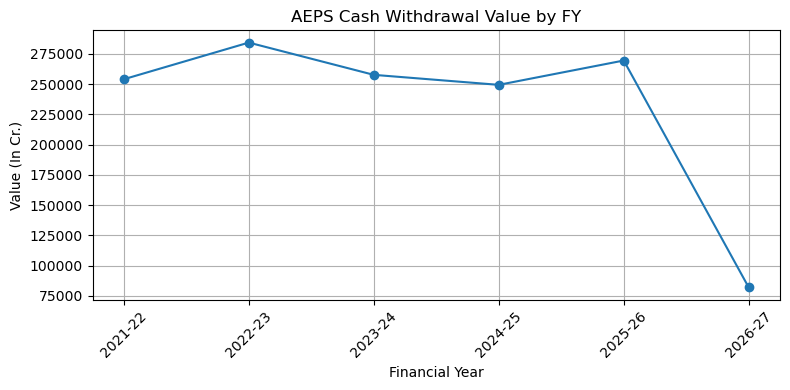

In [193]:
import matplotlib.pyplot as plt

# AEPS cash withdrawal value over time
plt.figure(figsize=(8, 4))
plt.plot(
    annual_aeps_cash["financial_year_fixed"],
    annual_aeps_cash["value_cr"],
    marker="o"
)
plt.title("AEPS Cash Withdrawal Value by FY")
plt.xlabel("Financial Year")
plt.ylabel("Value (In Cr.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

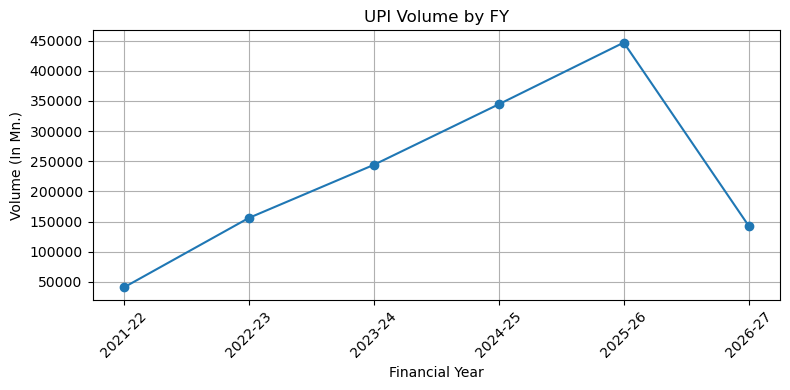

In [194]:
plt.figure(figsize=(8, 4))
plt.plot(
    annual_upi["financial_year_fixed"],
    annual_upi["volume_mn"],
    marker="o",
    color="tab:blue"
)
plt.title("UPI Volume by FY")
plt.xlabel("Financial Year")
plt.ylabel("Volume (In Mn.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

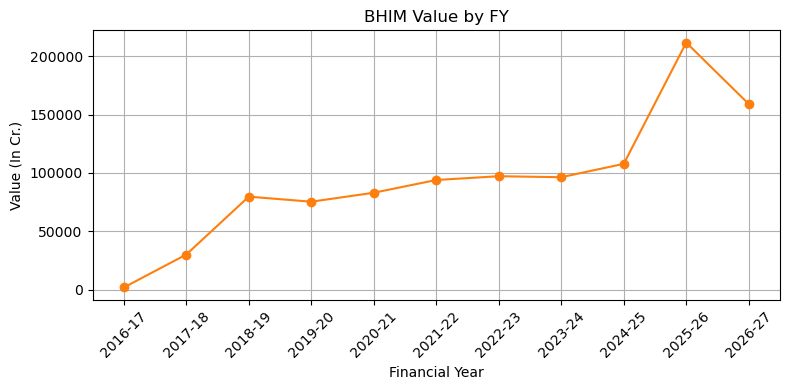

In [195]:
plt.figure(figsize=(8, 4))
plt.plot(
    annual_bhim["financial_year_fixed"],
    annual_bhim["value_cr"],
    marker="o",
    color="tab:orange"
)
plt.title("BHIM Value by FY")
plt.xlabel("Financial Year")
plt.ylabel("Value (In Cr.)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

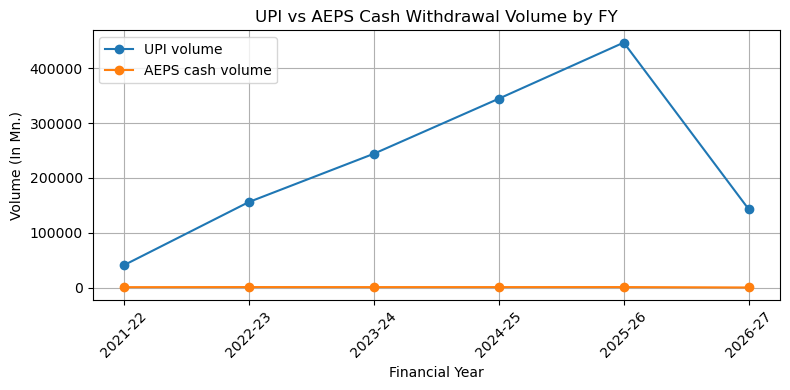

In [196]:
plt.figure(figsize=(8, 4))

plt.plot(
    annual_upi["financial_year_fixed"],
    annual_upi["volume_mn"],
    marker="o",
    label="UPI volume"
)

plt.plot(
    annual_aeps_cash["financial_year_fixed"],
    annual_aeps_cash["volume_mn"],
    marker="o",
    label="AEPS cash volume"
)

plt.title("UPI vs AEPS Cash Withdrawal Volume by FY")
plt.xlabel("Financial Year")
plt.ylabel("Volume (In Mn.)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [197]:
# Ensuring financial years are sorted correctly within each product/subtype
annual.sort_values(["product", "subtype", "financial_year_fixed"], inplace=True)

for key, grp in annual.groupby(["product", "subtype"]):
    print("\n===", key, "===")
    print(grp[["financial_year_fixed", "volume_mn", "value_cr"]])


=== ('AEPS', 'BHIM_AADHAAR_PAY') ===
  financial_year_fixed  volume_mn  value_cr
0              2021-22      24.67   5313.98
1              2022-23      18.01   5636.53
2              2023-24      16.20   4972.45
3              2024-25      18.96   5817.87
4              2025-26      19.55   6497.28
5              2026-27       8.80   3146.87

=== ('AEPS', 'CASH_WITHDRAWAL') ===
   financial_year_fixed  volume_mn   value_cr
6               2021-22     873.01  253936.95
7               2022-23    1027.79  284234.11
8               2023-24     977.65  257580.22
9               2024-25     984.17  249315.88
10              2025-26    1018.11  269414.16
11              2026-27     294.25   81926.51

=== ('AEPS', 'FUNDS_TRANSFER') ===
   financial_year_fixed  volume_mn  value_cr
12              2021-22     787.00    455.51
13              2022-23     111.70    287.52
14              2023-24       0.31    212.79
15              2024-25       0.30    152.11
16              2025-26       0.20

In [198]:
import numpy as np

def cv(x):
    return np.std(x, ddof=1) / np.mean(x)

cv_df = (
    annual
    .groupby(["product", "subtype"])
    .agg({
        "volume_mn": cv,
        "value_cr": cv,
    })
    .rename(columns={"volume_mn": "cv_volume", "value_cr": "cv_value"})
)

cv_df

cv_volume  cv_value
product subtype                              
AEPS    BHIM_AADHAAR_PAY   0.293755  0.218469
        CASH_WITHDRAWAL    0.329006  0.322012
        FUNDS_TRANSFER     2.102892  0.660922
BHIM    OTHER              1.145142  0.596610
UPI     UPI                0.644804  0.581263

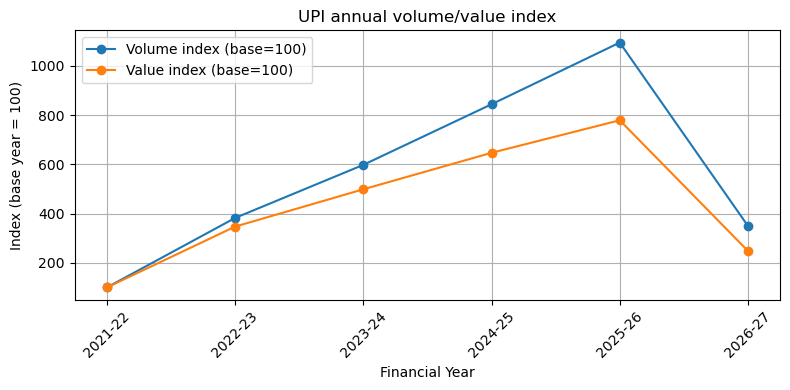

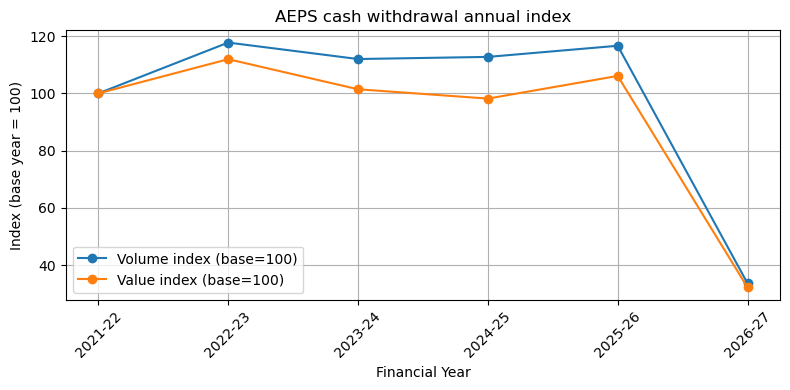

In [199]:
import matplotlib.pyplot as plt

def plot_index_series(df, title):
    base = df.iloc[0]
    idx_vol = df["volume_mn"] / base["volume_mn"] * 100
    idx_val = df["value_cr"] / base["value_cr"] * 100

    plt.figure(figsize=(8, 4))
    plt.plot(df["financial_year_fixed"], idx_vol, marker="o", label="Volume index (base=100)")
    plt.plot(df["financial_year_fixed"], idx_val, marker="o", label="Value index (base=100)")
    plt.title(title)
    plt.xlabel("Financial Year")
    plt.ylabel("Index (base year = 100)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example: UPI index
plot_index_series(annual_upi, "UPI annual volume/value index")

# Example: AEPS cash withdrawal index
plot_index_series(annual_aeps_cash, "AEPS cash withdrawal annual index")

In [200]:
import pandas as pd

path_2016_17 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG Bank Linkage Programme 2016-17.xlsx"

xls = pd.ExcelFile(path_2016_17)
print(xls.sheet_names)

['Table 1', 'Table 2', 'Table 3']


In [201]:
# 2016-17 highlights Excel
path_2016_17 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG Bank Linkage Programme 2016-17.xlsx"

xls_2016 = pd.ExcelFile(path_2016_17)
print("2016-17 sheet names:", xls_2016.sheet_names)

# Inspecting Table 3 
df_h2016 = xls_2016.parse("Table 3")
print(df_h2016.head(20))
print("Columns:", df_h2016.columns.tolist())

2016-17 sheet names: ['Table 1', 'Table 2', 'Table 3']
   Unnamed: 0                                          no. only)  \
0         NaN                                             Number   
1         NaN                                                NaN   
2        (ii)                                  Refinance Support   
3         NaN                  Refinance to banks during 2016-17   
4         NaN   Cumulative refinance released upto 31 March 2017   
5       (iii)                                          Financial   
6         NaN                                    Support to MFIs   
7         NaN                RFA outstanding as on 31 March 2017   
8         NaN    Capital support outstanding as on 31 March 2017   
9         NaN    Refinance disbursed to NBFC-MFIs during 2016-17   
10      (iii)       Grant  assistance  to  SHPIs  for  promotion   
11        NaN                                 SHGs under SHG-BLP   
12        NaN         Grant assistance sanctioned during 2016

In [202]:
import pandas as pd

path_2016_17 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG Bank Linkage Programme 2016-17.xlsx"

xls_2016 = pd.ExcelFile(path_2016_17)
print("2016-17 sheet names:", xls_2016.sheet_names)

# Inspecting Table 1
df_t1_2016 = xls_2016.parse("Table 1")
print("\n=== Table 1 head ===")
print(df_t1_2016.head(20))
print("Table 1 columns:", df_t1_2016.columns.tolist())

# Inspecting Table 2
df_t2_2016 = xls_2016.parse("Table 2")
print("\n=== Table 2 head ===")
print(df_t2_2016.head(20))
print("Table 2 columns:", df_t2_2016.columns.tolist())

2016-17 sheet names: ['Table 1', 'Table 2', 'Table 3']

=== Table 1 head ===
Empty DataFrame
Columns: [Highlights of the SHG-Bank Linkage Programme 2016-17]
Index: []
Table 1 columns: ['Highlights of the SHG-Bank Linkage Programme 2016-17']

=== Table 2 head ===
      Sr.                                      Particulars  Unnamed: 2  \
0     No.                                              NaN         NaN   
1     NaN                                              NaN         NaN   
2     NaN                                              NaN         NaN   
3       1    Total number of SHGs saving linked with banks         NaN   
4     (i)         Out of total SHGs - exclusive Women SHGs         NaN   
5    (ii)               Out of total SHGs- under NRLM/SGSY         NaN   
6   (iii)              Out of total SHGs -under NULM/SJSRY         NaN   
7       2                                            Total  number  of   
8     NaN                                          2016-17         NaN 

In [203]:
path_2016_17 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG Bank Linkage Programme 2016-17.xlsx"

xls_2016 = pd.ExcelFile(path_2016_17)
print("2016-17 sheet names:", xls_2016.sheet_names)

# We know Table 2 has the SHG summary
df_t2_2016 = xls_2016.parse("Table 2")
print("\n=== Table 2 head (2016-17) ===")
print(df_t2_2016.head(20))
print("Table 2 columns:", df_t2_2016.columns.tolist())

records_2016_17 = []

for _, row in df_t2_2016.iterrows():
    part = str(row.get("Particulars", "")).strip()
    if not part:
        continue

    phys = row.get("Achievements")
    fin = row.get("Unnamed: 8")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 2. Total SHGs credit linked during 2016-17
    elif part.startswith("Total number of SHGs credit linked during"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2017
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 4. Average loan amount outstanding/SHG as on March 2017
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "value_R": fin,  # average amount is stored in Unnamed: 8
        })

    # 5. Average loan amount disbursed/SHG during 2016-17
    elif part.startswith("Average") and "disbursed/SHG during" in str(row.get("Unnamed: 5", "")):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "value_R": fin,
        })

shg_highlights_2016_17 = pd.DataFrame(records_2016_17)
print("\n=== SHG highlights 2016-17 ===")
print(shg_highlights_2016_17)

2016-17 sheet names: ['Table 1', 'Table 2', 'Table 3']

=== Table 2 head (2016-17) ===
      Sr.                                      Particulars  Unnamed: 2  \
0     No.                                              NaN         NaN   
1     NaN                                              NaN         NaN   
2     NaN                                              NaN         NaN   
3       1    Total number of SHGs saving linked with banks         NaN   
4     (i)         Out of total SHGs - exclusive Women SHGs         NaN   
5    (ii)               Out of total SHGs- under NRLM/SGSY         NaN   
6   (iii)              Out of total SHGs -under NULM/SJSRY         NaN   
7       2                                            Total  number  of   
8     NaN                                          2016-17         NaN   
9     (i)         Out of total SHGs - exclusive Women SHGs         NaN   
10   (ii)              Out of total SHGs – under NRLM/SGSY         NaN   
11  (iii)             Out

In [204]:
path_2016_17 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG Bank Linkage Programme 2016-17.xlsx"

xls_2016 = pd.ExcelFile(path_2016_17)
df_t2_2016 = xls_2016.parse("Table 2")

records_2016_17 = []

for _, row in df_t2_2016.iterrows():
    part = str(row.get("Particulars", "")).strip()
    u4   = str(row.get("Unnamed: 4", "")).strip()
    u5   = str(row.get("Unnamed: 5", "")).strip()

    phys = row.get("Achievements")
    fin  = row.get("Unnamed: 8")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 2. Total SHGs credit linked during 2016-17
    # Using Unnamed: 4 text, since the phrase lives there
    elif "SHGs  credit  linked  during" in u4:
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2017
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 4. Average loan amount outstanding/SHG as on March 2017
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "value_R": fin,
        })

    # 5. Average loan amount disbursed/SHG during 2016-17
    elif "disbursed/SHG  during" in u5:
        records_2016_17.append({
            "financial_year": "2016-17",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "value_R": fin,
        })

shg_highlights_2016_17 = pd.DataFrame(records_2016_17)
print("=== SHG highlights 2016-17 (fixed) ===")
print(shg_highlights_2016_17)

=== SHG highlights 2016-17 (fixed) ===
  financial_year                            indicator  physical_lakh  \
0        2016-17                   SHGs_saving_linked          85.77   
1        2016-17       SHGs_credit_linked_during_year          18.98   
2        2016-17               SHGs_loans_outstanding          48.48   
3        2016-17  avg_loan_amount_outstanding_per_shg            NaN   
4        2016-17    avg_loan_amount_disbursed_per_shg            NaN   

   financial_crore    value_R  
0         16114.23        NaN  
1         38781.16        NaN  
2         61581.30        NaN  
3              NaN  127016.62  
4              NaN  204313.51  


In [205]:
path_smfi_2017_18 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights 2017-18.xlsx"

xls_smfi = pd.ExcelFile(path_smfi_2017_18)
print("SMFI 2017-18 sheet names:", xls_smfi.sheet_names)

df_h2017 = xls_smfi.parse("Table 1")  # 'HIGHLIGHTS of the SHG-Bank Linkage Programme 2017-18'
print("\n=== Table 1 head (2017-18) ===")
print(df_h2017.head(20))
print("Table 1 columns:", df_h2017.columns.tolist())

SMFI 2017-18 sheet names: ['Table 1']

=== Table 1 head (2017-18) ===
   HIGHLIGHTS of the SHG-Bank Linkage Programme - 2017-18  \
0                                            Sr.\nNo.       
1                                                 NaN       
2                                                   1       
3                                                 (i)       
4                                                (ii)       
5                                               (iii)       
6                                                   2       
7                                                 (i)       
8                                                (ii)       
9                                               (iii)       
10                                                  3       
11                                                (i)       
12                                               (ii)       
13                                              (iii)       
14             

In [206]:
path_smfi_2017_18 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights 2017-18.xlsx"

xls_smfi = pd.ExcelFile(path_smfi_2017_18)
print("SMFI 2017-18 sheet names:", xls_smfi.sheet_names)

df_h2017 = xls_smfi.parse("Table 1")

print("\n=== Table 1 head (2017-18) ===")
print(df_h2017.head(20))
print("Columns:", df_h2017.columns.tolist())

records_2017_18 = []

for _, row in df_h2017.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()  # 'Particulars'
    if not part:
        continue

    phys = row.get("Unnamed: 2")  # Physical (No. in lakh)
    fin  = row.get("Unnamed: 3")  # Financial (` in crore)

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2017_18.append({
            "financial_year": "2017-18",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 2. Total SHGs credit linked during the year 2017-18
    elif part.startswith("Total number of SHGs credit linked during the year"):
        records_2017_18.append({
            "financial_year": "2017-18",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2018
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2017_18.append({
            "financial_year": "2017-18",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
        })

    # 4. Average loan amount outstanding/SHG as on March 2018
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2017_18.append({
            "financial_year": "2017-18",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "value_R": fin,  # this row stores the average in Unnamed: 3
        })

    # 5. Average loan amount disbursed/SHG during 2017-18
    elif part.startswith("Average loan amount disbursed/SHG during 2017-18"):
        records_2017_18.append({
            "financial_year": "2017-18",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "value_R": fin,
        })

shg_highlights_2017_18 = pd.DataFrame(records_2017_18)
print("\n=== SHG highlights 2017-18 ===")
print(shg_highlights_2017_18)

SMFI 2017-18 sheet names: ['Table 1']

=== Table 1 head (2017-18) ===
   HIGHLIGHTS of the SHG-Bank Linkage Programme - 2017-18  \
0                                            Sr.\nNo.       
1                                                 NaN       
2                                                   1       
3                                                 (i)       
4                                                (ii)       
5                                               (iii)       
6                                                   2       
7                                                 (i)       
8                                                (ii)       
9                                               (iii)       
10                                                  3       
11                                                (i)       
12                                               (ii)       
13                                              (iii)       
14             

In [207]:
# Combining the two highlight DataFrames
shg_highlights = pd.concat(
    [shg_highlights_2016_17, shg_highlights_2017_18],
    ignore_index=True
)

print("=== Combined SHG highlights (long) ===")
print(shg_highlights)

# Pivot to one row per financial_year
shg_annual = (
    shg_highlights
    .pivot_table(
        index="financial_year",
        columns="indicator",
        values=["physical_lakh", "financial_crore", "value_R"],
        aggfunc="first"
    )
)

# Flatten MultiIndex columns: ('physical_lakh','SHGs_saving_linked') -> 'SHGs_saving_linked_physical_lakh'
new_cols = []
for lvl0, indicator in shg_annual.columns:
    if lvl0 == "value_R":
        new_cols.append(indicator)
    else:
        new_cols.append(f"{indicator}_{lvl0}")
shg_annual.columns = new_cols

shg_annual = shg_annual.reset_index()

print("\n=== SHG annual table (2016-17, 2017-18) ===")
print(shg_annual)
print(shg_annual.dtypes)

=== Combined SHG highlights (long) ===
  financial_year                            indicator  physical_lakh  \
0        2016-17                   SHGs_saving_linked          85.77   
1        2016-17       SHGs_credit_linked_during_year          18.98   
2        2016-17               SHGs_loans_outstanding          48.48   
3        2016-17  avg_loan_amount_outstanding_per_shg            NaN   
4        2016-17    avg_loan_amount_disbursed_per_shg            NaN   
5        2017-18                   SHGs_saving_linked          87.44   
6        2017-18       SHGs_credit_linked_during_year          22.61   
7        2017-18               SHGs_loans_outstanding          50.20   
8        2017-18  avg_loan_amount_outstanding_per_shg            NaN   
9        2017-18    avg_loan_amount_disbursed_per_shg            NaN   

   financial_crore    value_R  
0         16114.23        NaN  
1         38781.16        NaN  
2         61581.30        NaN  
3              NaN  127016.62  
4       

In [208]:
merged_macro = annual.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

print("=== NPCI × SHG annual merged sample ===")
print(merged_macro.head())

=== NPCI × SHG annual merged sample ===
  product subtype financial_year_fixed  volume_mn  value_cr financial_year  \
0    BHIM   OTHER              2016-17       6.19   1804.60        2016-17   
1    BHIM   OTHER              2017-18      87.92  30018.42        2017-18   

   SHGs_credit_linked_during_year_financial_crore  \
0                                        38781.16   
1                                        47185.88   

   SHGs_loans_outstanding_financial_crore  SHGs_saving_linked_financial_crore  \
0                                61581.30                            16114.23   
1                               755998.45                            19592.12   

   SHGs_credit_linked_during_year_physical_lakh  \
0                                         18.98   
1                                         22.61   

   SHGs_loans_outstanding_physical_lakh  SHGs_saving_linked_physical_lakh  \
0                                 48.48                             85.77   
1            

In [209]:
# Viewing all merged rows
merged_macro

,product,subtype,financial_year_fixed,volume_mn,value_cr,financial_year,SHGs_credit_linked_during_year_financial_crore,SHGs_loans_outstanding_financial_crore,SHGs_saving_linked_financial_crore,SHGs_credit_linked_during_year_physical_lakh,SHGs_loans_outstanding_physical_lakh,SHGs_saving_linked_physical_lakh,avg_loan_amount_disbursed_per_shg,avg_loan_amount_outstanding_per_shg
0,BHIM,OTHER,2016-17,6.19,1804.60,2016-17,38781.16,61581.30,16114.23,18.98,48.48,85.77,204313.51,127016.62
1,BHIM,OTHER,2017-18,87.92,30018.42,2017-18,47185.88,755998.45,19592.12,22.61,50.20,87.44,208682.54,150583.79


In [210]:
merged_macro[["product", "subtype", "financial_year_fixed"]].drop_duplicates()

,product,subtype,financial_year_fixed
0,BHIM,OTHER,2016-17
1,BHIM,OTHER,2017-18


In [211]:
# BHIM (already merged)
annual_bhim = annual[annual["product"] == "BHIM"].copy()

# UPI (subtype 'UPI')
annual_upi = annual[
    (annual["product"] == "UPI") &
    (annual["subtype"] == "UPI")
].copy()

# AEPS cash withdrawal
annual_aeps_cash = annual[
    (annual["product"] == "AEPS") &
    (annual["subtype"] == "CASH_WITHDRAWAL")
].copy()

print("UPI years:", annual_upi["financial_year_fixed"].unique())
print("AEPS cash withdrawal years:", annual_aeps_cash["financial_year_fixed"].unique())

UPI years: ['2021-22' '2022-23' '2023-24' '2024-25' '2025-26' '2026-27']
AEPS cash withdrawal years: ['2021-22' '2022-23' '2023-24' '2024-25' '2025-26' '2026-27']


In [212]:
import pandas as pd

path_2023_24 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/highlights-of-the-shg-bank-linkage-programme-2023-24.xlsx"

xls_2023_24 = pd.ExcelFile(path_2023_24)
print("2023-24 sheet names:", xls_2023_24.sheet_names)

df_h2023 = xls_2023_24.parse(xls_2023_24.sheet_names[0])
print(df_h2023.head(20))
print("Columns:", df_h2023.columns.tolist())

2023-24 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2023-24  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                     

In [213]:
xls_2023_24 = pd.ExcelFile(path_2023_24)
df_h2023 = xls_2023_24.parse("Table 1")

print("=== Table 1 head (2023-24) ===")
print(df_h2023.head(20))
print("Columns:", df_h2023.columns.tolist())

records_2023_24 = []

for _, row in df_h2023.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2023_24.append({
            "financial_year": "2023-24",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2023-24
    elif part.startswith("Total number of SHGs credit linked during the year"):
        records_2023_24.append({
            "financial_year": "2023-24",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2024
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2023_24.append({
            "financial_year": "2023-24",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2024 (in ₹ lakh)
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2023_24.append({
            "financial_year": "2023-24",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.35 (₹ lakh)
        })

    # 5. Average loan amount disbursed/SHG during 2023-24 (in ₹ lakh)
    elif part.startswith("Average loan amount disbursed/SHG during 2023-24"):
        records_2023_24.append({
            "financial_year": "2023-24",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.82 (₹ lakh)
        })

shg_highlights_2023_24 = pd.DataFrame(records_2023_24)
print("=== SHG highlights 2023-24 (from Excel) ===")
print(shg_highlights_2023_24)

=== Table 1 head (2023-24) ===
   Highlights of the SHG-Bank Linkage Programme 2023-24  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                       

In [214]:
import pandas as pd

path_2022_23 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/highlights-of-the-shg-bank-linkage-programme-2022-23.xlsx"

xls_2022_23 = pd.ExcelFile(path_2022_23)
print("2022-23 sheet names:", xls_2022_23.sheet_names)

df_h2022 = xls_2022_23.parse(xls_2022_23.sheet_names[0])
print(df_h2022.head(20))
print("Columns:", df_h2022.columns.tolist())

2022-23 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2022-23  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                     

In [215]:
xls_2022_23 = pd.ExcelFile(path_2022_23)
df_h2022 = xls_2022_23.parse("Table 1")

print("=== Table 1 head (2022-23) ===")
print(df_h2022.head(20))
print("Columns:", df_h2022.columns.tolist())

records_2022_23 = []

for _, row in df_h2022.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2022_23.append({
            "financial_year": "2022-23",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2022-23
    elif part.startswith("Total number of SHGs credit linked during the year"):
        records_2022_23.append({
            "financial_year": "2022-23",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2023
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2022_23.append({
            "financial_year": "2022-23",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2023 (in ₹ lakh)
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2022_23.append({
            "financial_year": "2022-23",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.35 (₹ lakh)
        })

    # 5. Average loan amount disbursed/SHG during 2022-23 (in ₹ lakh)
    elif part.startswith("Average loan amount disbursed/SHG during 2022-23"):
        records_2022_23.append({
            "financial_year": "2022-23",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.82 (₹ lakh)
        })

shg_highlights_2022_23 = pd.DataFrame(records_2022_23)
print("=== SHG highlights 2022-23 (from Excel) ===")
print(shg_highlights_2022_23)

=== Table 1 head (2022-23) ===
   Highlights of the SHG-Bank Linkage Programme 2022-23  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                       

In [216]:
shg_highlights = pd.concat(
    [
        shg_highlights_2016_17,
        shg_highlights_2017_18,
        shg_highlights_2022_23,
        shg_highlights_2023_24,
    ],
    ignore_index=True
)

shg_annual = (
    shg_highlights
    .pivot_table(
        index="financial_year",
        columns="indicator",
        values=["physical_lakh", "financial_crore", "value_R"],
        aggfunc="first"
    )
)

new_cols = []
for lvl0, indicator in shg_annual.columns:
    if lvl0 == "value_R":
        new_cols.append(indicator)
    else:
        new_cols.append(f"{indicator}_{lvl0}")
shg_annual.columns = new_cols
shg_annual = shg_annual.reset_index()

In [224]:
merged_upi_shg = annual_upi.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

merged_aeps_shg = annual_aeps_cash.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

In [217]:
annual_upi = annual[
    (annual["product"] == "UPI") &
    (annual["subtype"] == "UPI")
].copy()

annual_aeps_cash = annual[
    (annual["product"] == "AEPS") &
    (annual["subtype"] == "CASH_WITHDRAWAL")
].copy()

# Merging UPI × SHG
merged_upi_shg = annual_upi.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

print("=== UPI × SHG annual ===")
print(merged_upi_shg[[
    "financial_year_fixed", "volume_mn", "value_cr",
    "SHGs_saving_linked_physical_lakh",
    "SHGs_saving_linked_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "SHGs_loans_outstanding_financial_crore"
]])

# Merging AEPS cash withdrawal × SHG
merged_aeps_shg = annual_aeps_cash.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

print("\n=== AEPS cash withdrawal × SHG annual ===")
print(merged_aeps_shg[[
    "financial_year_fixed", "volume_mn", "value_cr",
    "SHGs_saving_linked_physical_lakh",
    "SHGs_saving_linked_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "SHGs_loans_outstanding_financial_crore"
]])

=== UPI × SHG annual ===
  financial_year_fixed  volume_mn     value_cr  \
0              2022-23  155964.04  25811813.98   
1              2023-24  243980.86  37085520.88   

   SHGs_saving_linked_physical_lakh  SHGs_saving_linked_financial_crore  \
0                            134.03                            58892.68   
1                            144.22                            65089.15   

   SHGs_credit_linked_during_year_financial_crore  \
0                                       145200.23   
1                                       209285.87   

   SHGs_loans_outstanding_financial_crore  
0                               188078.80  
1                               259663.73  

=== AEPS cash withdrawal × SHG annual ===
  financial_year_fixed  volume_mn   value_cr  \
0              2022-23    1027.79  284234.11   
1              2023-24     977.65  257580.22   

   SHGs_saving_linked_physical_lakh  SHGs_saving_linked_financial_crore  \
0                            134.03        

In [218]:
import pandas as pd

path_2015_16 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights of the SHG-Bank Linkage Programme 2015-16.xlsx"

xls_2015_16 = pd.ExcelFile(path_2015_16)
print("2015-16 sheet names:", xls_2015_16.sheet_names)

df_h2015 = xls_2015_16.parse(xls_2015_16.sheet_names[0])
print(df_h2015.head(20))
print("Columns:", df_h2015.columns.tolist())

2015-16 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2015-16  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                     

In [219]:
xls_2015_16 = pd.ExcelFile(path_2015_16)
df_h2015 = xls_2015_16.parse("Table 1")

print("=== Table 1 head (2015-16) ===")
print(df_h2015.head(20))
print("Columns:", df_h2015.columns.tolist())

records_2015_16 = []

for _, row in df_h2015.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2015-16
    elif part.startswith("Total number of SHGs credit linked during the year"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2026
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2026 (in ₹ lakh)
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.35 (₹ lakh)
        })

    # 5. Average loan amount disbursed/SHG during 2015-16 (in ₹ lakh)
    elif part.startswith("Average loan amount disbursed/SHG during 2015-16"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 3.82 (₹ lakh)
        })

shg_highlights_2015_16 = pd.DataFrame(records_2015_16)
print("=== SHG highlights 2015-16 (from Excel) ===")
print(shg_highlights_2015_16)

=== Table 1 head (2015-16) ===
   Highlights of the SHG-Bank Linkage Programme 2015-16  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                       

In [220]:
records_2015_16 = []

for _, row in df_h2015.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2015-16
    elif part.startswith("Total   number   of   SHGs   credit   linked"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2016
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2016
    elif part.startswith("Average  loan  amount  outstanding/SHG  as  on"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 122242.39
        })

    # 5. Average loan amount disbursed/SHG during 2015-16
    elif part.startswith("Average   loan   amount   disbursed/SHG   duri"):
        records_2015_16.append({
            "financial_year": "2015-16",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 203495.24
        })

shg_highlights_2015_16 = pd.DataFrame(records_2015_16)
print("=== SHG highlights 2015-16 (complete) ===")
print(shg_highlights_2015_16)

=== SHG highlights 2015-16 (complete) ===
  financial_year                            indicator  physical_lakh  \
0        2015-16                   SHGs_saving_linked          79.03   
1        2015-16       SHGs_credit_linked_during_year          18.32   
2        2015-16               SHGs_loans_outstanding          46.73   
3        2015-16  avg_loan_amount_outstanding_per_shg            NaN   
4        2015-16    avg_loan_amount_disbursed_per_shg            NaN   

   financial_crore    value_R  
0         13691.39        NaN  
1         37286.90        NaN  
2         57119.23        NaN  
3              NaN  122242.39  
4              NaN  203495.24  


In [221]:
import pandas as pd

path_2018_19 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights-2018-19.xlsx"

xls_2018_19 = pd.ExcelFile(path_2018_19)
print("2018-19 sheet names:", xls_2018_19.sheet_names)

df_h2018 = xls_2018_19.parse(xls_2018_19.sheet_names[0])
print(df_h2018.head(20))
print("Columns:", df_h2018.columns.tolist())

2018-19 sheet names: ['Table 1']
                                           Unnamed: 0  \
0   Highlights of the SHG-Bank Linkage Programme 2...   
1                                                   #   
2                                                 NaN   
3                                                   1   
4                                                 (i)   
5                                                (ii)   
6                                               (iii)   
7                                                   2   
8                                                 (i)   
9                                                (ii)   
10                                              (iii)   
11                                                  3   
12                                                (i)   
13                                               (ii)   
14                                              (iii)   
15                                                  4  

In [222]:
xls_2018_19 = pd.ExcelFile(path_2018_19)
df_h2018 = xls_2018_19.parse("Table 1")

print("=== Table 1 head (2018-19) ===")
print(df_h2018.head(20))
print("Columns:", df_h2018.columns.tolist())

records_2018_19 = []

for _, row in df_h2018.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2018_19.append({
            "financial_year": "2018-19",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2018-19
    elif part.startswith("Total number of SHGs credit linked during the"):
        records_2018_19.append({
            "financial_year": "2018-19",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2019
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2018_19.append({
            "financial_year": "2018-19",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2019
    elif part.startswith("Average loan amount outstanding/SHG as on 31 March 2019"):
        records_2018_19.append({
            "financial_year": "2018-19",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 1,71,543.15
        })

    # 5. Average loan amount disbursed/SHG during 2018-19
    elif part.startswith("Average loan amount disbursed/SHG during 2018-19"):
        records_2018_19.append({
            "financial_year": "2018-19",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 2,16,119.29
        })

shg_highlights_2018_19 = pd.DataFrame(records_2018_19)
print("=== SHG highlights 2018-19 (from Excel) ===")
print(shg_highlights_2018_19)

=== Table 1 head (2018-19) ===
                                           Unnamed: 0  \
0   Highlights of the SHG-Bank Linkage Programme 2...   
1                                                   #   
2                                                 NaN   
3                                                   1   
4                                                 (i)   
5                                                (ii)   
6                                               (iii)   
7                                                   2   
8                                                 (i)   
9                                                (ii)   
10                                              (iii)   
11                                                  3   
12                                                (i)   
13                                               (ii)   
14                                              (iii)   
15                                                  4   


In [223]:
# Keeping only the first 5 rows (main totals and averages), dropping the extra 3
shg_highlights_2018_19_clean = shg_highlights_2018_19.iloc[:5].copy()

print("=== SHG highlights 2018-19 (clean) ===")
print(shg_highlights_2018_19_clean)

=== SHG highlights 2018-19 (clean) ===
  financial_year                            indicator  physical_lakh  \
0        2018-19                   SHGs_saving_linked         100.14   
1        2018-19       SHGs_credit_linked_during_year          26.98   
2        2018-19               SHGs_loans_outstanding          50.77   
3        2018-19  avg_loan_amount_outstanding_per_shg            NaN   
4        2018-19    avg_loan_amount_disbursed_per_shg            NaN   

   financial_crore      value_R  
0         23324.48         None  
1         58317.63         None  
2         87098.15         None  
3              NaN  1,71,543.15  
4              NaN  2,16,119.29  


In [224]:
import pandas as pd

path_2019_20 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights-2019-20.xlsx"

xls_2019_20 = pd.ExcelFile(path_2019_20)
print("2019-20 sheet names:", xls_2019_20.sheet_names)

df_h2019 = xls_2019_20.parse(xls_2019_20.sheet_names[0])
print(df_h2019.head(20))
print("Columns:", df_h2019.columns.tolist())

2019-20 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2019-20  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                     

In [225]:
xls_2019_20 = pd.ExcelFile(path_2019_20)
df_h2019 = xls_2019_20.parse("Table 1")

print("=== Table 1 head (2019-20) ===")
print(df_h2019.head(20))
print("Columns:", df_h2019.columns.tolist())

records_2019_20 = []

for _, row in df_h2019.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2019_20.append({
            "financial_year": "2019-20",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2019-20
    elif part.startswith("Total number of SHGs credit linked during the"):
        records_2019_20.append({
            "financial_year": "2019-20",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2020
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2019_20.append({
            "financial_year": "2019-20",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2020
    elif part.startswith("Average loan amount outstanding/SHG as on 31 March 2020"):
        records_2019_20.append({
            "financial_year": "2019-20",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 1,90,371.18
        })

    # 5. Average loan amount disbursed/SHG during 2019-20
    elif part.startswith("Average loan amount disbursed/SHG during 2019-20"):
        records_2019_20.append({
            "financial_year": "2019-20",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 2,46,850.92
        })

shg_highlights_2019_20 = pd.DataFrame(records_2019_20)
print("=== SHG highlights 2019-20 (from Excel) ===")
print(shg_highlights_2019_20)

=== Table 1 head (2019-20) ===
   Highlights of the SHG-Bank Linkage Programme 2019-20  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                       

In [226]:
import pandas as pd

path_2020_21 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights-2020-21.xlsx"

xls_2020_21 = pd.ExcelFile(path_2020_21)
print("2020-21 sheet names:", xls_2020_21.sheet_names)

df_h2020 = xls_2020_21.parse(xls_2020_21.sheet_names[0])
print(df_h2020.head(20))
print("Columns:", df_h2020.columns.tolist())

2020-21 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2020-21  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                     

In [227]:
xls_2020_21 = pd.ExcelFile(path_2020_21)
df_h2020 = xls_2020_21.parse("Table 1")

print("=== Table 1 head (2020-21) ===")
print(df_h2020.head(20))
print("Columns:", df_h2020.columns.tolist())

records_2020_21 = []

for _, row in df_h2020.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks
    if part.startswith("Total number of SHGs saving linked with"):
        records_2020_21.append({
            "financial_year": "2020-21",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2020-21
    elif part.startswith("Total number of SHGs credit linked during the"):
        records_2020_21.append({
            "financial_year": "2020-21",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2021
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2020_21.append({
            "financial_year": "2020-21",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2021
    elif part.startswith("Average loan amount outstanding/SHG as on  31 March 2021"):
        records_2020_21.append({
            "financial_year": "2020-21",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 178694.37
        })

    # 5. Average loan amount disbursed/SHG during 2020-21
    elif part.startswith("Average loan amount disbursed/SHG during 2020-21"):
        records_2020_21.append({
            "financial_year": "2020-21",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 201117.96
        })

shg_highlights_2020_21 = pd.DataFrame(records_2020_21)
print("=== SHG highlights 2020-21 (from Excel) ===")
print(shg_highlights_2020_21)

=== Table 1 head (2020-21) ===
   Highlights of the SHG-Bank Linkage Programme 2020-21  \
0                                            Sr.\nNo.     
1                                                 NaN     
2                                                   1     
3                                                 (i)     
4                                                (ii)     
5                                               (iii)     
6                                                   2     
7                                                 (i)     
8                                                (ii)     
9                                               (iii)     
10                                                  3     
11                                                (i)     
12                                               (ii)     
13                                              (iii)     
14                                                  4     
15                       

In [228]:
import pandas as pd

path_2021_22 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/HCES_MOSPI_Data/Highlights-2021-22.xlsx"

xls_2021_22 = pd.ExcelFile(path_2021_22)
print("2021-22 sheet names:", xls_2021_22.sheet_names)

df_h2021 = xls_2021_22.parse(xls_2021_22.sheet_names[0])
print(df_h2021.head(20))
print("Columns:", df_h2021.columns.tolist())

2021-22 sheet names: ['Table 1']
   Highlights of the SHG-Bank Linkage Programme 2021-22  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                     

In [229]:
xls_2021_22 = pd.ExcelFile(path_2021_22)
df_h2021 = xls_2021_22.parse("Table 1")

print("=== Table 1 head (2021-22) ===")
print(df_h2021.head(20))
print("Columns:", df_h2021.columns.tolist())

records_2021_22 = []

for _, row in df_h2021.iterrows():
    part = str(row.get("Unnamed: 1", "")).strip()
    if not part:
        continue

    phys = row.get("Unnamed: 2")
    fin  = row.get("Unnamed: 3")

    # 1. Total SHGs saving linked with banks as on 31 March 2022
    if part.startswith("Total number of SHGs saving linked with banks"):
        records_2021_22.append({
            "financial_year": "2021-22",
            "indicator": "SHGs_saving_linked",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 2. Total SHGs credit linked during the year 2021-22
    elif part.startswith("Total number of SHGs credit linked during the"):
        records_2021_22.append({
            "financial_year": "2021-22",
            "indicator": "SHGs_credit_linked_during_year",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 3. Total SHGs having loans outstanding as on 31 March 2022
    elif part.startswith("Total number of SHGs having loans outstanding"):
        records_2021_22.append({
            "financial_year": "2021-22",
            "indicator": "SHGs_loans_outstanding",
            "physical_lakh": phys,
            "financial_crore": fin,
            "value_R": None,
        })

    # 4. Average loan amount outstanding/SHG as on 31 March 2022 (in ₹ lakh)
    elif part.startswith("Average loan amount outstanding/SHG as on"):
        records_2021_22.append({
            "financial_year": "2021-22",
            "indicator": "avg_loan_amount_outstanding_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 2.24
        })

    # 5. Average loan amount disbursed/SHG during 2021-22 (in ₹ lakh)
    elif part.startswith("Average loan amount disbursed/SHG during 2021-22"):
        records_2021_22.append({
            "financial_year": "2021-22",
            "indicator": "avg_loan_amount_disbursed_per_shg",
            "physical_lakh": None,
            "financial_crore": None,
            "value_R": fin,  # 2.93
        })

shg_highlights_2021_22 = pd.DataFrame(records_2021_22)
print("=== SHG highlights 2021-22 (from Excel) ===")
print(shg_highlights_2021_22)

=== Table 1 head (2021-22) ===
   Highlights of the SHG-Bank Linkage Programme 2021-22  \
0                                                   #     
1                                                   1     
2                                                 (i)     
3                                                (ii)     
4                                               (iii)     
5                                                   2     
6                                                 (i)     
7                                                (ii)     
8                                               (iii)     
9                                                   3     
10                                                (i)     
11                                               (ii)     
12                                              (iii)     
13                                                  4     
14                                                  5     
15                       

In [230]:
# Combining all long-format SHG highlight frames
shg_highlights = pd.concat(
    [
        shg_highlights_2015_16,
        shg_highlights_2016_17,
        shg_highlights_2017_18,
        shg_highlights_2018_19_clean,
        shg_highlights_2019_20,
        shg_highlights_2020_21,
        shg_highlights_2021_22,
        shg_highlights_2022_23,
        shg_highlights_2023_24,
    ],
    ignore_index=True
)

print("=== Combined SHG highlights (long, all years) ===")
print(shg_highlights)

# Pivoting to one row per financial_year, with indicator-specific columns
shg_annual = (
    shg_highlights
    .pivot_table(
        index="financial_year",
        columns="indicator",
        values=["physical_lakh", "financial_crore", "value_R"],
        aggfunc="first"
    )
)

# Flatten MultiIndex columns: ('physical_lakh','SHGs_saving_linked') -> 'SHGs_saving_linked_physical_lakh'
new_cols = []
for lvl0, indicator in shg_annual.columns:
    if lvl0 == "value_R":
        new_cols.append(indicator)
    else:
        new_cols.append(f"{indicator}_{lvl0}")
shg_annual.columns = new_cols

shg_annual = shg_annual.reset_index()

print("\n=== SHG annual table (2015-16 to 2023-24) ===")
print(shg_annual)
print(shg_annual.dtypes)

=== Combined SHG highlights (long, all years) ===
   financial_year                            indicator  physical_lakh  \
0         2015-16                   SHGs_saving_linked          79.03   
1         2015-16       SHGs_credit_linked_during_year          18.32   
2         2015-16               SHGs_loans_outstanding          46.73   
3         2015-16  avg_loan_amount_outstanding_per_shg            NaN   
4         2015-16    avg_loan_amount_disbursed_per_shg            NaN   
5         2016-17                   SHGs_saving_linked          85.77   
6         2016-17       SHGs_credit_linked_during_year          18.98   
7         2016-17               SHGs_loans_outstanding          48.48   
8         2016-17  avg_loan_amount_outstanding_per_shg            NaN   
9         2016-17    avg_loan_amount_disbursed_per_shg            NaN   
10        2017-18                   SHGs_saving_linked          87.44   
11        2017-18       SHGs_credit_linked_during_year          22.61   
1

In [231]:
# Columns that should be numeric but are currently 'object'
num_cols = [
    "SHGs_credit_linked_during_year_financial_crore",
    "SHGs_loans_outstanding_financial_crore",
    "SHGs_saving_linked_financial_crore",
    "avg_loan_amount_disbursed_per_shg",
    "avg_loan_amount_outstanding_per_shg",
]

for c in num_cols:
    shg_annual[c] = (
        shg_annual[c]
        .astype(str)
        .str.replace(",", "", regex=False)   # remove thousand separators
        .replace({"None": None, "nan": None})
    )
    shg_annual[c] = pd.to_numeric(shg_annual[c], errors="coerce")

print("=== SHG annual dtypes after cleaning ===")
print(shg_annual.dtypes)

=== SHG annual dtypes after cleaning ===
financial_year                                     object
SHGs_credit_linked_during_year_financial_crore    float64
SHGs_loans_outstanding_financial_crore            float64
SHGs_saving_linked_financial_crore                float64
SHGs_credit_linked_during_year_physical_lakh      float64
SHGs_loans_outstanding_physical_lakh              float64
SHGs_saving_linked_physical_lakh                  float64
avg_loan_amount_disbursed_per_shg                 float64
avg_loan_amount_outstanding_per_shg               float64
dtype: object


In [232]:
for name in ["merged_bhim_shg", "merged_upi_shg", "merged_aeps_shg"]:
    print(name in globals(), name)

False merged_bhim_shg
True merged_upi_shg
True merged_aeps_shg


In [233]:
# BHIM annual slice should already exist; if not, recreate it
annual_bhim = annual[annual["product"] == "BHIM"].copy()

# Merging BHIM with SHG annual panel
merged_bhim_shg = annual_bhim.merge(
    shg_annual,
    left_on="financial_year_fixed",
    right_on="financial_year",
    how="inner",
)

print("BHIM × SHG rows:")
print(merged_bhim_shg[[
    "financial_year_fixed",
    "volume_mn",
    "value_cr",
    "SHGs_saving_linked_physical_lakh",
    "SHGs_saving_linked_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "SHGs_loans_outstanding_financial_crore"
]].head())

BHIM × SHG rows:
  financial_year_fixed  volume_mn  value_cr  SHGs_saving_linked_physical_lakh  \
0              2016-17       6.19   1804.60                             85.77   
1              2017-18      87.92  30018.42                             87.44   
2              2018-19     186.76  79633.62                            100.14   
3              2019-20     201.02  75285.40                            102.43   
4              2020-21     250.61  82975.70                            112.23   

   SHGs_saving_linked_financial_crore  \
0                            16114.23   
1                            19592.12   
2                            23324.48   
3                            26152.05   
4                            37477.61   

   SHGs_credit_linked_during_year_financial_crore  \
0                                        38781.16   
1                                        47185.88   
2                                        58317.63   
3                                    

In [234]:
for name in ["merged_bhim_shg", "merged_upi_shg", "merged_aeps_shg"]:
    print(name in globals(), name)

True merged_bhim_shg
True merged_upi_shg
True merged_aeps_shg


In [235]:
def add_shg_ratios(df, product_label):
    # Avoiding division by zero or missing value issues
    df = df.copy()
    df[f"{product_label}_shg_loans_to_value"] = (
        df["SHGs_loans_outstanding_financial_crore"] /
        df["value_cr"]
    )
    df[f"{product_label}_shg_credit_to_value"] = (
        df["SHGs_credit_linked_during_year_financial_crore"] /
        df["value_cr"]
    )
    return df

# 1. Adding ratios
bhim_with_ratios = add_shg_ratios(merged_bhim_shg, "BHIM")
upi_with_ratios = add_shg_ratios(merged_upi_shg, "UPI")
aeps_with_ratios = add_shg_ratios(merged_aeps_shg, "AEPS")

# 2. Selecting a neat view for each
bhim_summary = bhim_with_ratios[[
    "financial_year_fixed",
    "value_cr",
    "SHGs_loans_outstanding_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "BHIM_shg_loans_to_value",
    "BHIM_shg_credit_to_value",
]]

upi_summary = upi_with_ratios[[
    "financial_year_fixed",
    "value_cr",
    "SHGs_loans_outstanding_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "UPI_shg_loans_to_value",
    "UPI_shg_credit_to_value",
]]

aeps_summary = aeps_with_ratios[[
    "financial_year_fixed",
    "value_cr",
    "SHGs_loans_outstanding_financial_crore",
    "SHGs_credit_linked_during_year_financial_crore",
    "AEPS_shg_loans_to_value",
    "AEPS_shg_credit_to_value",
]]

print("=== BHIM: SHG ratios ===")
print(bhim_summary)

print("\n=== UPI: SHG ratios ===")
print(upi_summary)

print("\n=== AEPS cash withdrawal: SHG ratios ===")
print(aeps_summary)

=== BHIM: SHG ratios ===
  financial_year_fixed  value_cr  SHGs_loans_outstanding_financial_crore  \
0              2016-17   1804.60                                61581.30   
1              2017-18  30018.42                               755998.45   
2              2018-19  79633.62                                87098.15   
3              2019-20  75285.40                               108075.07   
4              2020-21  82975.70                               103289.71   
5              2021-22  93887.89                               151051.30   
6              2022-23  97124.92                               188078.80   
7              2023-24  96281.75                               259663.73   

   SHGs_credit_linked_during_year_financial_crore  BHIM_shg_loans_to_value  \
0                                        38781.16                34.124626   
1                                        47185.88                25.184485   
2                                        58317.63       

#### Calculating Ratios....

In [236]:
def build_ratio_table(df, product_name):
    out = df.copy()

    out[f"{product_name}_shg_loans_to_value"] = (
        out["SHGs_loans_outstanding_financial_crore"] / out["value_cr"]
    )
    out[f"{product_name}_shg_credit_to_value"] = (
        out["SHGs_credit_linked_during_year_financial_crore"] / out["value_cr"]
    )

    out = out[[
        "financial_year_fixed",
        "value_cr",
        "SHGs_loans_outstanding_financial_crore",
        "SHGs_credit_linked_during_year_financial_crore",
        f"{product_name}_shg_loans_to_value",
        f"{product_name}_shg_credit_to_value",
    ]].copy()

    out = out.rename(columns={
        "financial_year_fixed": "financial_year",
        "value_cr": f"{product_name.lower()}_value_cr",
        "SHGs_loans_outstanding_financial_crore": "shg_loans_outstanding_cr",
        "SHGs_credit_linked_during_year_financial_crore": "shg_credit_during_year_cr",
    })

    return out.sort_values("financial_year").reset_index(drop=True)

bhim_ratio_table = build_ratio_table(merged_bhim_shg, "BHIM")
upi_ratio_table = build_ratio_table(merged_upi_shg, "UPI")
aeps_ratio_table = build_ratio_table(merged_aeps_shg, "AEPS")

print("=== BHIM ratio table ===")
display(bhim_ratio_table)

print("=== UPI ratio table ===")
display(upi_ratio_table)

print("=== AEPS ratio table ===")
display(aeps_ratio_table)

=== BHIM ratio table ===


,financial_year,bhim_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,BHIM_shg_loans_to_value,BHIM_shg_credit_to_value
0,2016-17,1804.60,61581.30,38781.16,34.124626,21.490170
1,2017-18,30018.42,755998.45,47185.88,25.184485,1.571898
2,2018-19,79633.62,87098.15,58317.63,1.093736,0.732324
3,2019-20,75285.40,108075.07,77659.35,1.435538,1.031533
4,2020-21,82975.70,103289.71,58070.68,1.244819,0.699852
5,2021-22,93887.89,151051.30,99729.22,1.608848,1.062216
6,2022-23,97124.92,188078.80,145200.23,1.936463,1.494984
7,2023-24,96281.75,259663.73,209285.87,2.696915,2.173682


=== UPI ratio table ===


,financial_year,upi_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,UPI_shg_loans_to_value,UPI_shg_credit_to_value
0,2022-23,25811813.98,188078.80,145200.23,0.007287,0.005625
1,2023-24,37085520.88,259663.73,209285.87,0.007002,0.005643


=== AEPS ratio table ===


,financial_year,aeps_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,AEPS_shg_loans_to_value,AEPS_shg_credit_to_value
0,2022-23,284234.11,188078.80,145200.23,0.661704,0.510847
1,2023-24,257580.22,259663.73,209285.87,1.008089,0.812508


In [237]:
bhim_panel = bhim_ratio_table.copy()
bhim_panel["product"] = "BHIM"

upi_panel = upi_ratio_table.copy()
upi_panel["product"] = "UPI"

aeps_panel = aeps_ratio_table.copy()
aeps_panel["product"] = "AEPS cash withdrawal"

ratio_master = pd.concat(
    [bhim_panel, upi_panel, aeps_panel],
    ignore_index=True
)

ratio_master = ratio_master[[
    "product",
    "financial_year",
    "shg_loans_outstanding_cr",
    "shg_credit_during_year_cr",
    "BHIM_shg_loans_to_value" if "BHIM_shg_loans_to_value" in ratio_master.columns else None,
]]

# Rebuilding properly with common names
def standardize_ratio_table(df, product_col_value, value_col_name, loans_ratio_col, credit_ratio_col):
    x = df.copy()
    x["product"] = product_col_value
    x["digital_value_cr"] = x[value_col_name]
    x["shg_loans_to_digital_value"] = x[loans_ratio_col]
    x["shg_credit_to_digital_value"] = x[credit_ratio_col]
    return x[[
        "product",
        "financial_year",
        "digital_value_cr",
        "shg_loans_outstanding_cr",
        "shg_credit_during_year_cr",
        "shg_loans_to_digital_value",
        "shg_credit_to_digital_value",
    ]]

bhim_std = standardize_ratio_table(
    bhim_ratio_table,
    "BHIM",
    "bhim_value_cr",
    "BHIM_shg_loans_to_value",
    "BHIM_shg_credit_to_value",
)

upi_std = standardize_ratio_table(
    upi_ratio_table,
    "UPI",
    "upi_value_cr",
    "UPI_shg_loans_to_value",
    "UPI_shg_credit_to_value",
)

aeps_std = standardize_ratio_table(
    aeps_ratio_table,
    "AEPS cash withdrawal",
    "aeps_value_cr",
    "AEPS_shg_loans_to_value",
    "AEPS_shg_credit_to_value",
)

ratio_master = pd.concat([bhim_std, upi_std, aeps_std], ignore_index=True)
ratio_master = ratio_master.sort_values(["product", "financial_year"]).reset_index(drop=True)

print("=== Combined dissertation table ===")
display(ratio_master)

=== Combined dissertation table ===


,product,financial_year,digital_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,shg_loans_to_digital_value,shg_credit_to_digital_value
0,AEPS cash withdrawal,2022-23,284234.11,188078.80,145200.23,0.661704,0.510847
1,AEPS cash withdrawal,2023-24,257580.22,259663.73,209285.87,1.008089,0.812508
2,BHIM,2016-17,1804.60,61581.30,38781.16,34.124626,21.490170
3,BHIM,2017-18,30018.42,755998.45,47185.88,25.184485,1.571898
4,BHIM,2018-19,79633.62,87098.15,58317.63,1.093736,0.732324
5,BHIM,2019-20,75285.40,108075.07,77659.35,1.435538,1.031533
6,BHIM,2020-21,82975.70,103289.71,58070.68,1.244819,0.699852
7,BHIM,2021-22,93887.89,151051.30,99729.22,1.608848,1.062216
8,BHIM,2022-23,97124.92,188078.80,145200.23,1.936463,1.494984
9,BHIM,2023-24,96281.75,259663.73,209285.87,2.696915,2.173682


In [238]:
ratio_master_display = ratio_master.copy()

for col in [
    "digital_value_cr",
    "shg_loans_outstanding_cr",
    "shg_credit_during_year_cr",
    "shg_loans_to_digital_value",
    "shg_credit_to_digital_value",
]:
    ratio_master_display[col] = ratio_master_display[col].round(3)

display(ratio_master_display)

print(ratio_master_display.to_markdown(index=False))

,product,financial_year,digital_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,shg_loans_to_digital_value,shg_credit_to_digital_value
0,AEPS cash withdrawal,2022-23,284234.11,188078.80,145200.23,0.662,0.511
1,AEPS cash withdrawal,2023-24,257580.22,259663.73,209285.87,1.008,0.813
2,BHIM,2016-17,1804.60,61581.30,38781.16,34.125,21.490
3,BHIM,2017-18,30018.42,755998.45,47185.88,25.184,1.572
4,BHIM,2018-19,79633.62,87098.15,58317.63,1.094,0.732
5,BHIM,2019-20,75285.40,108075.07,77659.35,1.436,1.032
6,BHIM,2020-21,82975.70,103289.71,58070.68,1.245,0.700
7,BHIM,2021-22,93887.89,151051.30,99729.22,1.609,1.062
8,BHIM,2022-23,97124.92,188078.80,145200.23,1.936,1.495
9,BHIM,2023-24,96281.75,259663.73,209285.87,2.697,2.174


| product              | financial_year   |   digital_value_cr |   shg_loans_outstanding_cr |   shg_credit_during_year_cr |   shg_loans_to_digital_value |   shg_credit_to_digital_value |
|:---------------------|:-----------------|-------------------:|---------------------------:|----------------------------:|-----------------------------:|------------------------------:|
| AEPS cash withdrawal | 2022-23          |   284234           |                   188079   |                    145200   |                        0.662 |                         0.511 |
| AEPS cash withdrawal | 2023-24          |   257580           |                   259664   |                    209286   |                        1.008 |                         0.813 |
| BHIM                 | 2016-17          |     1804.6         |                    61581.3 |                     38781.2 |                       34.125 |                        21.49  |
| BHIM                 | 2017-18          |    30018.4         | 

In [239]:
def standardize_ratio_table(df, product_col_value, value_col_name, loans_ratio_col, credit_ratio_col):
    x = df.copy()
    x["product"] = product_col_value
    x["digital_value_cr"] = x[value_col_name]
    x["shg_loans_to_digital_value"] = x[loans_ratio_col]
    x["shg_credit_to_digital_value"] = x[credit_ratio_col]
    return x[[
        "product",
        "financial_year",
        "digital_value_cr",
        "shg_loans_outstanding_cr",
        "shg_credit_during_year_cr",
        "shg_loans_to_digital_value",
        "shg_credit_to_digital_value",
    ]]

In [240]:
ratio_master = pd.concat([bhim_std, upi_std, aeps_std], ignore_index=True)
ratio_master = ratio_master.sort_values(["product", "financial_year"]).reset_index(drop=True)

In [241]:
ratio_master_display = ratio_master.copy()
for col in [
    "digital_value_cr",
    "shg_loans_outstanding_cr",
    "shg_credit_during_year_cr",
    "shg_loans_to_digital_value",
    "shg_credit_to_digital_value",
]:
    ratio_master_display[col] = ratio_master_display[col].round(3)

display(ratio_master_display)
print(ratio_master_display.to_markdown(index=False))

,product,financial_year,digital_value_cr,shg_loans_outstanding_cr,shg_credit_during_year_cr,shg_loans_to_digital_value,shg_credit_to_digital_value
0,AEPS cash withdrawal,2022-23,284234.11,188078.80,145200.23,0.662,0.511
1,AEPS cash withdrawal,2023-24,257580.22,259663.73,209285.87,1.008,0.813
2,BHIM,2016-17,1804.60,61581.30,38781.16,34.125,21.490
3,BHIM,2017-18,30018.42,755998.45,47185.88,25.184,1.572
4,BHIM,2018-19,79633.62,87098.15,58317.63,1.094,0.732
5,BHIM,2019-20,75285.40,108075.07,77659.35,1.436,1.032
6,BHIM,2020-21,82975.70,103289.71,58070.68,1.245,0.700
7,BHIM,2021-22,93887.89,151051.30,99729.22,1.609,1.062
8,BHIM,2022-23,97124.92,188078.80,145200.23,1.936,1.495
9,BHIM,2023-24,96281.75,259663.73,209285.87,2.697,2.174


| product              | financial_year   |   digital_value_cr |   shg_loans_outstanding_cr |   shg_credit_during_year_cr |   shg_loans_to_digital_value |   shg_credit_to_digital_value |
|:---------------------|:-----------------|-------------------:|---------------------------:|----------------------------:|-----------------------------:|------------------------------:|
| AEPS cash withdrawal | 2022-23          |   284234           |                   188079   |                    145200   |                        0.662 |                         0.511 |
| AEPS cash withdrawal | 2023-24          |   257580           |                   259664   |                    209286   |                        1.008 |                         0.813 |
| BHIM                 | 2016-17          |     1804.6         |                    61581.3 |                     38781.2 |                       34.125 |                        21.49  |
| BHIM                 | 2017-18          |    30018.4         | 

#### Plotting Various Figures...

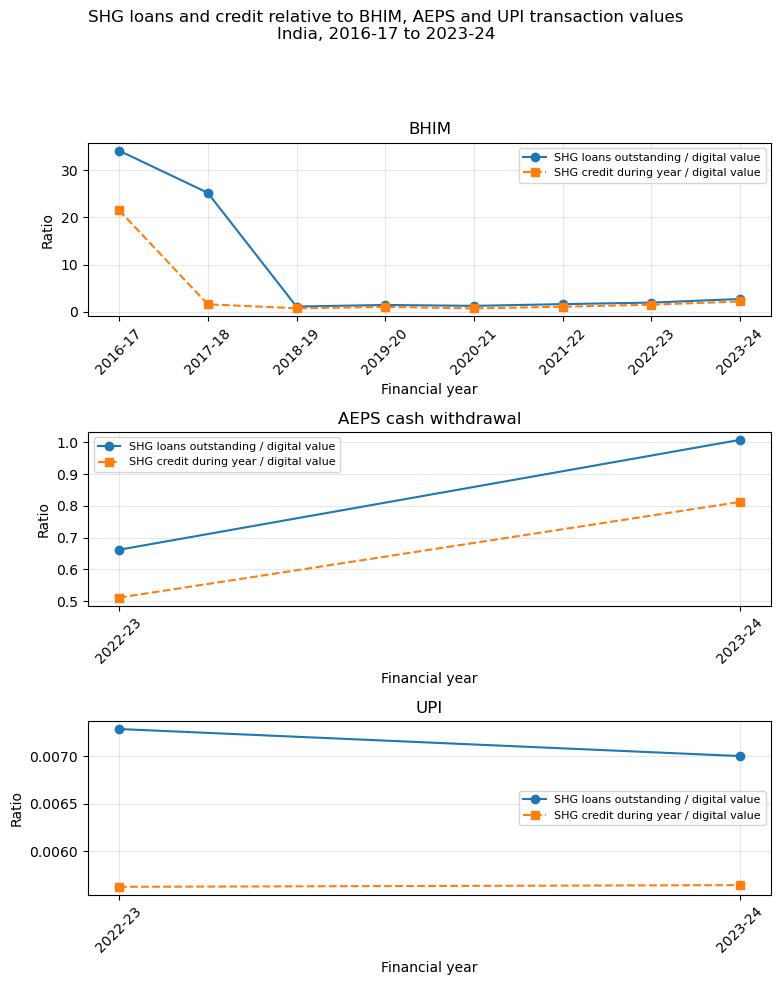

In [242]:
import matplotlib.pyplot as plt

# Ensuring financial_year is treated as categorical in the right order
ratio_master_sorted = ratio_master.sort_values(["product", "financial_year"]).copy()

products_order = ["BHIM", "AEPS cash withdrawal", "UPI"]
ratio_master_sorted["product"] = pd.Categorical(
    ratio_master_sorted["product"],
    categories=products_order,
    ordered=True,
)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)
fig.suptitle(
    "SHG loans and credit relative to BHIM, AEPS and UPI transaction values\nIndia, 2016-17 to 2023-24",
    fontsize=12,
)

for ax, product in zip(axes, products_order):
    df_p = ratio_master_sorted[ratio_master_sorted["product"] == product]

    ax.plot(
        df_p["financial_year"],
        df_p["shg_loans_to_digital_value"],
        marker="o",
        label="SHG loans outstanding / digital value",
    )
    ax.plot(
        df_p["financial_year"],
        df_p["shg_credit_to_digital_value"],
        marker="s",
        linestyle="--",
        label="SHG credit during year / digital value",
    )

    ax.set_title(product)
    ax.set_xlabel("Financial year")
    ax.set_ylabel("Ratio")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [243]:
# BHIM-only figure
df_bhim = ratio_master_sorted[ratio_master_sorted["product"] == "BHIM"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_bhim["financial_year"],
    df_bhim["shg_loans_to_digital_value"],
    marker="o",
    label="Loans outstanding / BHIM value",
)
plt.plot(
    df_bhim["financial_year"],
    df_bhim["shg_credit_to_digital_value"],
    marker="s",
    linestyle="--",
    label="Credit during year / BHIM value",
)
plt.title("SHG ratios relative to BHIM transaction values\nIndia, 2016-17 to 2023-24")
plt.xlabel("Financial year")
plt.ylabel("Ratio")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_bhim_shg_ratios.png", dpi=300, bbox_inches="tight")
plt.close()

# AEPS-only figure
df_aeps = ratio_master_sorted[ratio_master_sorted["product"] == "AEPS cash withdrawal"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_aeps["financial_year"],
    df_aeps["shg_loans_to_digital_value"],
    marker="o",
    label="Loans outstanding / AEPS value",
)
plt.plot(
    df_aeps["financial_year"],
    df_aeps["shg_credit_to_digital_value"],
    marker="s",
    linestyle="--",
    label="Credit during year / AEPS value",
)
plt.title("SHG ratios relative to AEPS cash withdrawal values\nIndia, 2022-23 to 2023-24")
plt.xlabel("Financial year")
plt.ylabel("Ratio")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_aeps_shg_ratios.png", dpi=300, bbox_inches="tight")
plt.close()

# UPI-only figure
df_upi = ratio_master_sorted[ratio_master_sorted["product"] == "UPI"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_upi["financial_year"],
    df_upi["shg_loans_to_digital_value"],
    marker="o",
    label="Loans outstanding / UPI value",
)
plt.plot(
    df_upi["financial_year"],
    df_upi["shg_credit_to_digital_value"],
    marker="s",
    linestyle="--",
    label="Credit during year / UPI value",
)
plt.title("SHG ratios relative to UPI transaction values\nIndia, 2022-23 to 2023-24")
plt.xlabel("Financial year")
plt.ylabel("Ratio")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_upi_shg_ratios.png", dpi=300, bbox_inches="tight")
plt.close()

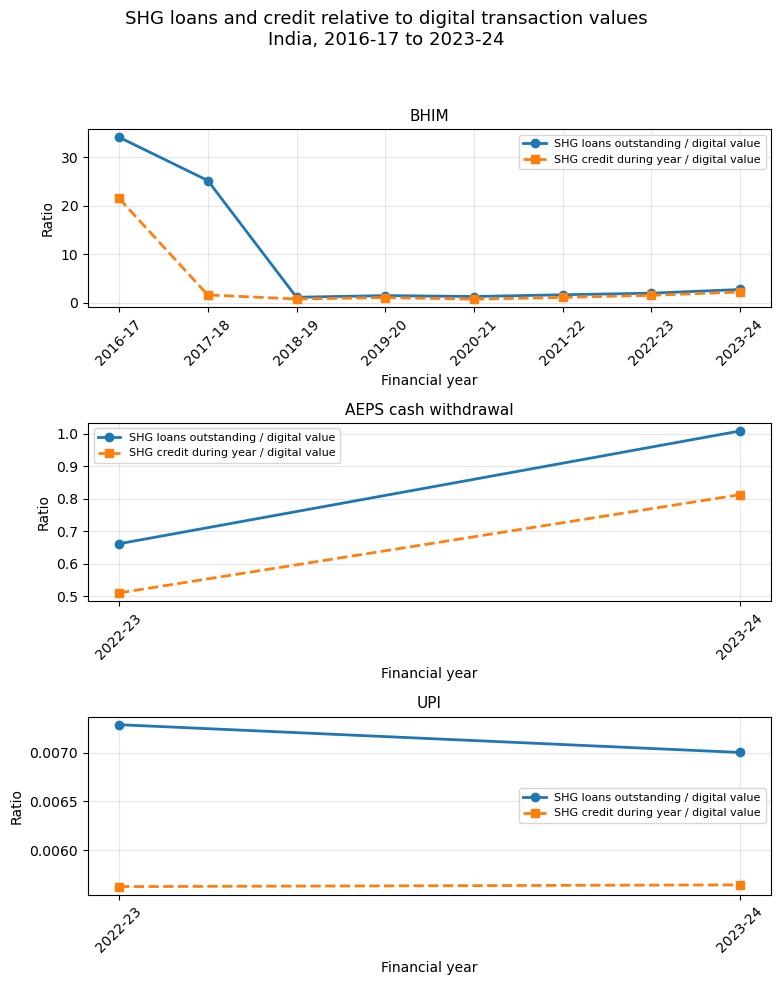

In [244]:
ratio_master_sorted = ratio_master.sort_values(["product", "financial_year"]).copy()

products_order = ["BHIM", "AEPS cash withdrawal", "UPI"]
ratio_master_sorted["product"] = pd.Categorical(
    ratio_master_sorted["product"],
    categories=products_order,
    ordered=True,
)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

fig.suptitle(
    "SHG loans and credit relative to digital transaction values\nIndia, 2016-17 to 2023-24",
    fontsize=13
)

for ax, product in zip(axes, products_order):
    df_p = ratio_master_sorted[ratio_master_sorted["product"] == product]

    ax.plot(
        df_p["financial_year"],
        df_p["shg_loans_to_digital_value"],
        marker="o",
        linewidth=2,
        label="SHG loans outstanding / digital value"
    )
    ax.plot(
        df_p["financial_year"],
        df_p["shg_credit_to_digital_value"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="SHG credit during year / digital value"
    )

    ax.set_title(product, fontsize=11)
    ax.set_xlabel("Financial year")
    ax.set_ylabel("Ratio")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("fig_combined_shg_digital_ratios.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

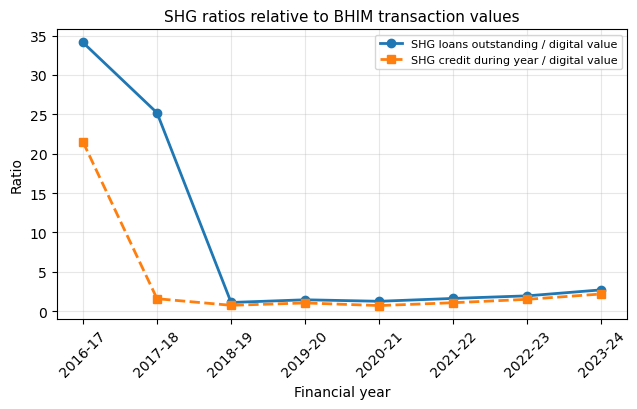

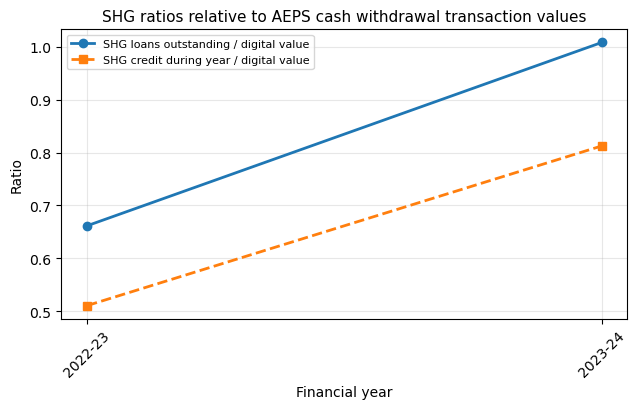

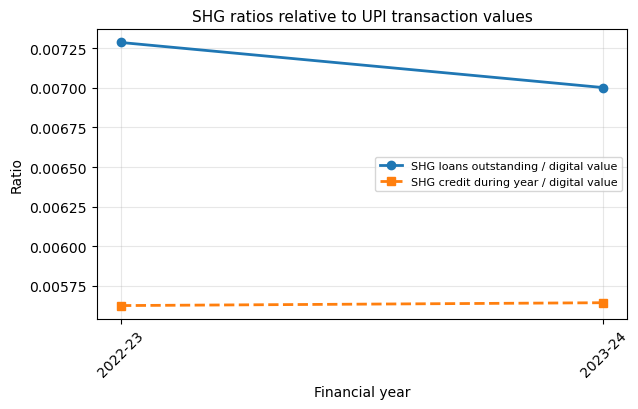

In [245]:
product_specs = [
    ("BHIM", "fig_bhim_shg_ratios.png"),
    ("AEPS cash withdrawal", "fig_aeps_shg_ratios.png"),
    ("UPI", "fig_upi_shg_ratios.png"),
]

for product, filename in product_specs:
    df_p = ratio_master_sorted[ratio_master_sorted["product"] == product]

    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    ax.plot(
        df_p["financial_year"],
        df_p["shg_loans_to_digital_value"],
        marker="o",
        linewidth=2,
        label="SHG loans outstanding / digital value"
    )
    ax.plot(
        df_p["financial_year"],
        df_p["shg_credit_to_digital_value"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="SHG credit during year / digital value"
    )

    ax.set_title(f"SHG ratios relative to {product} transaction values", fontsize=11)
    ax.set_xlabel("Financial year")
    ax.set_ylabel("Ratio")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [246]:
figure_captions = {
    "fig_combined_shg_digital_ratios.png":
        "Figure X. SHG loans outstanding and SHG credit during the year relative to BHIM, AEPS cash withdrawal and UPI transaction values, India, 2016-17 to 2023-24.",
    "fig_bhim_shg_ratios.png":
        "Figure X. SHG loans outstanding and SHG credit during the year relative to BHIM transaction values, India, 2016-17 to 2023-24.",
    "fig_aeps_shg_ratios.png":
        "Figure X. SHG loans outstanding and SHG credit during the year relative to AEPS cash withdrawal values, India, 2022-23 to 2023-24.",
    "fig_upi_shg_ratios.png":
        "Figure X. SHG loans outstanding and SHG credit during the year relative to UPI transaction values, India, 2022-23 to 2023-24."
}

figure_captions

{'fig_combined_shg_digital_ratios.png': 'Figure X. SHG loans outstanding and SHG credit during the year relative to BHIM, AEPS cash withdrawal and UPI transaction values, India, 2016-17 to 2023-24.',
 'fig_bhim_shg_ratios.png': 'Figure X. SHG loans outstanding and SHG credit during the year relative to BHIM transaction values, India, 2016-17 to 2023-24.',
 'fig_aeps_shg_ratios.png': 'Figure X. SHG loans outstanding and SHG credit during the year relative to AEPS cash withdrawal values, India, 2022-23 to 2023-24.',
 'fig_upi_shg_ratios.png': 'Figure X. SHG loans outstanding and SHG credit during the year relative to UPI transaction values, India, 2022-23 to 2023-24.'}

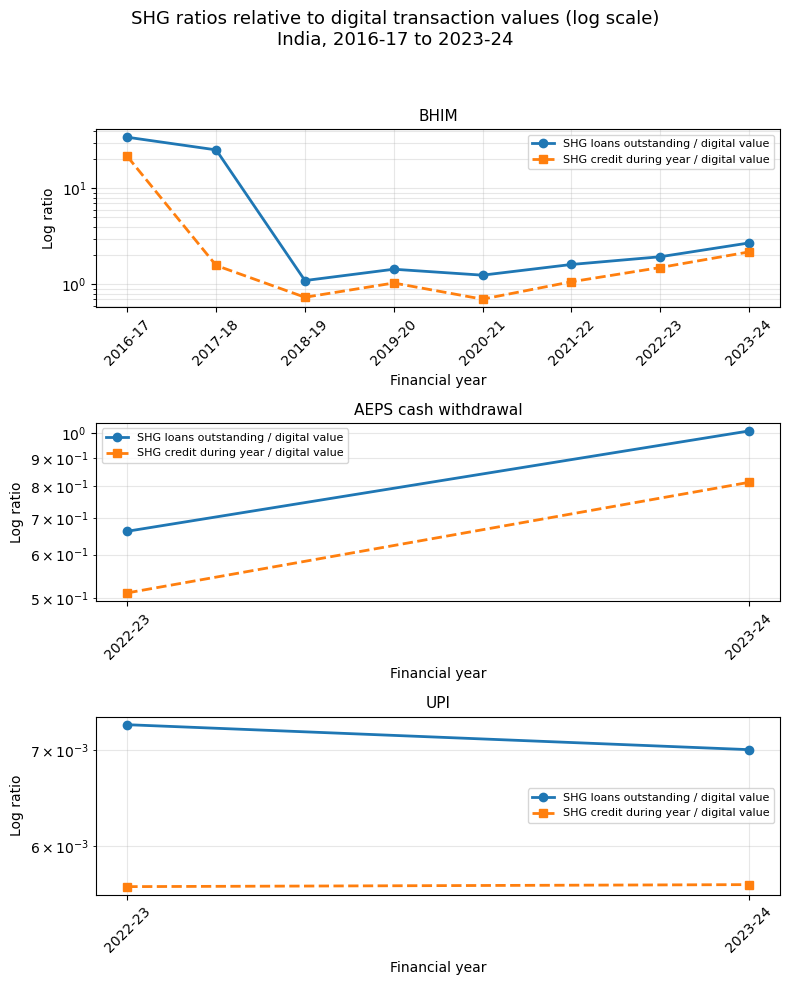

In [247]:
ratio_master_sorted = ratio_master.sort_values(["product", "financial_year"]).copy()

products_order = ["BHIM", "AEPS cash withdrawal", "UPI"]
ratio_master_sorted["product"] = pd.Categorical(
    ratio_master_sorted["product"],
    categories=products_order,
    ordered=True,
)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

fig.suptitle(
    "SHG ratios relative to digital transaction values (log scale)\nIndia, 2016-17 to 2023-24",
    fontsize=13
)

for ax, product in zip(axes, products_order):
    df_p = ratio_master_sorted[ratio_master_sorted["product"] == product]

    ax.plot(
        df_p["financial_year"],
        df_p["shg_loans_to_digital_value"],
        marker="o",
        linewidth=2,
        label="SHG loans outstanding / digital value"
    )
    ax.plot(
        df_p["financial_year"],
        df_p["shg_credit_to_digital_value"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="SHG credit during year / digital value"
    )

    ax.set_yscale("log")
    ax.set_title(product, fontsize=11)
    ax.set_xlabel("Financial year")
    ax.set_ylabel("Log ratio")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("fig_combined_shg_digital_ratios_logscale.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

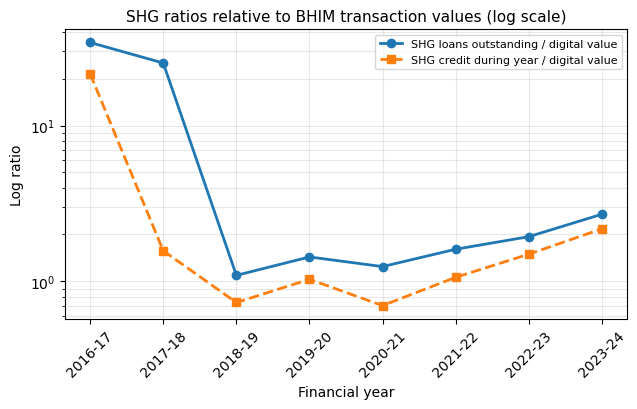

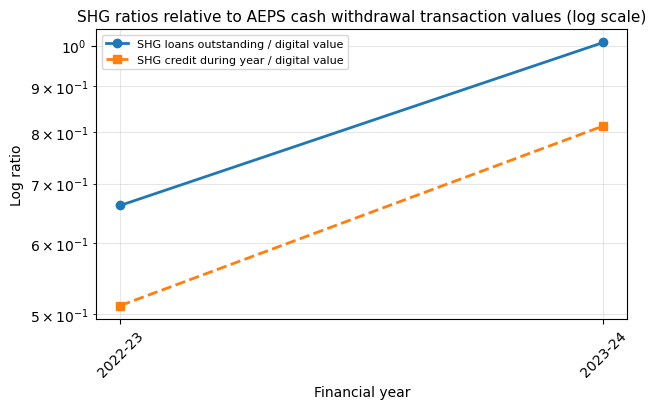

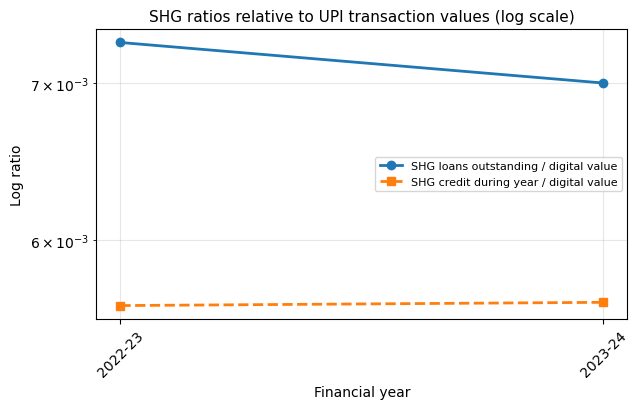

In [248]:
product_specs = [
    ("BHIM", "fig_bhim_shg_ratios_logscale.png"),
    ("AEPS cash withdrawal", "fig_aeps_shg_ratios_logscale.png"),
    ("UPI", "fig_upi_shg_ratios_logscale.png"),
]

for product, filename in product_specs:
    df_p = ratio_master_sorted[ratio_master_sorted["product"] == product]

    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    ax.plot(
        df_p["financial_year"],
        df_p["shg_loans_to_digital_value"],
        marker="o",
        linewidth=2,
        label="SHG loans outstanding / digital value"
    )
    ax.plot(
        df_p["financial_year"],
        df_p["shg_credit_to_digital_value"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="SHG credit during year / digital value"
    )

    ax.set_yscale("log")
    ax.set_title(f"SHG ratios relative to {product} transaction values (log scale)", fontsize=11)
    ax.set_xlabel("Financial year")
    ax.set_ylabel("Log ratio")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [249]:
# Exporting the combined dissertation table to Excel (single sheet)
ratio_master.to_excel(
    "shg_digital_ratios_master.xlsx",
    sheet_name="SHG_digital_ratios",
    index=False
)

In [250]:
with pd.ExcelWriter("shg_digital_ratios_all.xlsx") as writer:
    ratio_master.to_excel(
        writer,
        sheet_name="combined_master",
        index=False
    )
    bhim_ratio_table.to_excel(
        writer,
        sheet_name="bhim_ratios",
        index=False
    )
    aeps_ratio_table.to_excel(
        writer,
        sheet_name="aeps_ratios",
        index=False
    )
    upi_ratio_table.to_excel(
        writer,
        sheet_name="upi_ratios",
        index=False
    )

In [251]:
# Creating a single Excel workbook with multiple sheets
with pd.ExcelWriter("shg_digital_health_education_panels.xlsx") as writer:
    # 1. Combined master of SHG × digital rails
    ratio_master.to_excel(
        writer,
        sheet_name="shg_digital_ratios_master",
        index=False
    )

    # 2. Product-specific ratio tables
    bhim_ratio_table.to_excel(
        writer,
        sheet_name="bhim_ratios",
        index=False
    )
    aeps_ratio_table.to_excel(
        writer,
        sheet_name="aeps_ratios",
        index=False
    )
    upi_ratio_table.to_excel(
        writer,
        sheet_name="upi_ratios",
        index=False
    )

    # 3. Placeholders for health and education panels
    try:
        health_annual.to_excel(
            writer,
            sheet_name="health_panel",
            index=False
        )
    except NameError:
        print("Note: health_annual not defined yet, skipping health_panel sheet.")

    try:
        education_annual.to_excel(
            writer,
            sheet_name="education_panel",
            index=False
        )
    except NameError:
        print("Note: education_annual not defined yet, skipping education_panel sheet.")

Note: health_annual not defined yet, skipping health_panel sheet.
Note: education_annual not defined yet, skipping education_panel sheet.


In [252]:
import os

print("Current working directory:")
print(os.getcwd())

print("Files in this directory:")
print(os.listdir())

Current working directory:
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Additional_Data
Files in this directory:
['SMFI 2017-18.pdf', 'Highlights 2017-18.pdf', 'SMFI 2017-18-Extracted.xlsx', 'annexure-i-2020-21.pdf', '1207192354SMFI 2018-19.pdf', 'shg_digital_health_education_panels.xlsx', 'fig_bhim_shg_ratios.png', 'shg_digital_ratios_master.xlsx', 'fig_combined_shg_digital_ratios.png', '1307174808Status of Microfinance in India 2016-17.pdf', 'SMFI 2017-18-Extracted.pdf', 'fig_combined_shg_digital_ratios_logscale.png', 'highlights-of-the-shg-bank-linkage-programme-2022-23.pdf', 'SoMFI-2020-21.pdf', '1409165809Status of Microfinance in India - 2015-16.pdf', 'Highlights of the SHG Bank Linkage Programme 2016-17.pdf', 'fig_aeps_shg_ratios_logscale.png', 'status-of-microfinance-in-india-2022-23.pdf', 'annexurei-2019-20.pdf', 'shg_digital_ratios_all.xlsx', 'SHG-BLP as on 30 June 2019.pdf', 'annexure-i-2021-22.pdf', 'fig_upi_shg_r

### Loading and Reading Health & Education Datasets....

In [253]:
path_plfs_chhv1 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_Data_2022-22_CSV/chhv1.csv"

plfs_chhv1 = pd.read_csv(path_plfs_chhv1)

print("PLFS chhv1 shape:", plfs_chhv1.shape)
print("\nPLFS chhv1 columns:")
print(plfs_chhv1.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_chhv1.head(20))

print("\nInfo:")
print(plfs_chhv1.info())

PLFS chhv1 shape: (102030, 38)

PLFS chhv1 columns:
['panel_chhv1', 'FI_chhv1', 'B1q2_chhv1', 'qtr_chhv1', 'visit_chhv1', 'b1q3_chhv1', 'state_chhv1', 'distcode_chhv1', 'nss_region_chhv1', 'b1q5_chhv1', 'b1q6_chhv1', 'b1q11_chhv1', 'b1q12_chhv1', 'b1q1_chhv1', 'b1q13_chhv1', 'b1q14_chhv1', 'b1q15_chhv1', 'b1q9_chhv1', 'b1q17_chhv1', 'b1q18_chhv1', 'b1q19_hhv1', 'b3q1_chhv1', 'b3q2_chhv1', 'b3q3_chhv1', 'b3q4_chhv1', 'b3q5pt1_chhv1', 'b3q5pt2_chhv1', 'b3q5pt3_chhv1', 'b3q5pt4_chhv1', 'b3q5pt5_chhv1', 'b3q5pt6_chhv1', 'b1q16_chhv1', 'b2q2i_chhv1', 'b2q4_chhv1', 'nss_chhv1', 'nsc_chhv1', 'mult_chhv1', 'no_qtr_chhv1']

First 20 rows:
   panel_chhv1 FI_chhv1  B1q2_chhv1 qtr_chhv1 visit_chhv1  b1q3_chhv1  \
0           P3    CFVH2         104        Q3          V1           1   
1           P3    CFVH2         104        Q3          V1           1   
2           P3    CFVH2         104        Q3          V1           1   
3           P3    CFVH2         104        Q3          V1           1 

In [254]:
path_plfs_chhv1 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_Data_2022-22_CSV/chhv1.csv"

plfs_chhv1 = pd.read_csv(path_plfs_chhv1)

print("PLFS chhv1 shape:", plfs_chhv1.shape)

print("\nColumns:")
print(plfs_chhv1.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_chhv1.head(20))

print("\nData types:")
print(plfs_chhv1.dtypes)

print("\nInfo:")
plfs_chhv1.info()

print("\nMissing values by column:")
print(plfs_chhv1.isna().sum().sort_values(ascending=False).head(30))

PLFS chhv1 shape: (102030, 38)

Columns:
['panel_chhv1', 'FI_chhv1', 'B1q2_chhv1', 'qtr_chhv1', 'visit_chhv1', 'b1q3_chhv1', 'state_chhv1', 'distcode_chhv1', 'nss_region_chhv1', 'b1q5_chhv1', 'b1q6_chhv1', 'b1q11_chhv1', 'b1q12_chhv1', 'b1q1_chhv1', 'b1q13_chhv1', 'b1q14_chhv1', 'b1q15_chhv1', 'b1q9_chhv1', 'b1q17_chhv1', 'b1q18_chhv1', 'b1q19_hhv1', 'b3q1_chhv1', 'b3q2_chhv1', 'b3q3_chhv1', 'b3q4_chhv1', 'b3q5pt1_chhv1', 'b3q5pt2_chhv1', 'b3q5pt3_chhv1', 'b3q5pt4_chhv1', 'b3q5pt5_chhv1', 'b3q5pt6_chhv1', 'b1q16_chhv1', 'b2q2i_chhv1', 'b2q4_chhv1', 'nss_chhv1', 'nsc_chhv1', 'mult_chhv1', 'no_qtr_chhv1']

First 20 rows:
   panel_chhv1 FI_chhv1  B1q2_chhv1 qtr_chhv1 visit_chhv1  b1q3_chhv1  \
0           P3    CFVH2         104        Q3          V1           1   
1           P3    CFVH2         104        Q3          V1           1   
2           P3    CFVH2         104        Q3          V1           1   
3           P3    CFVH2         104        Q3          V1           1   
4       

In [255]:
plfs_chhv1_raw = pd.read_csv(path_plfs_chhv1)
plfs_chhv1 = plfs_chhv1_raw.copy()

print("PLFS chhv1 shape:", plfs_chhv1.shape)
print(plfs_chhv1.columns.tolist())

PLFS chhv1 shape: (102030, 38)
['panel_chhv1', 'FI_chhv1', 'B1q2_chhv1', 'qtr_chhv1', 'visit_chhv1', 'b1q3_chhv1', 'state_chhv1', 'distcode_chhv1', 'nss_region_chhv1', 'b1q5_chhv1', 'b1q6_chhv1', 'b1q11_chhv1', 'b1q12_chhv1', 'b1q1_chhv1', 'b1q13_chhv1', 'b1q14_chhv1', 'b1q15_chhv1', 'b1q9_chhv1', 'b1q17_chhv1', 'b1q18_chhv1', 'b1q19_hhv1', 'b3q1_chhv1', 'b3q2_chhv1', 'b3q3_chhv1', 'b3q4_chhv1', 'b3q5pt1_chhv1', 'b3q5pt2_chhv1', 'b3q5pt3_chhv1', 'b3q5pt4_chhv1', 'b3q5pt5_chhv1', 'b3q5pt6_chhv1', 'b1q16_chhv1', 'b2q2i_chhv1', 'b2q4_chhv1', 'nss_chhv1', 'nsc_chhv1', 'mult_chhv1', 'no_qtr_chhv1']


In [256]:
# Replacing these names if the codebook assigns differently
health_var = "b3q3_chhv1"     # monthly household health expenditure
education_var = "b3q2_chhv1"  # monthly household education expenditure
weight_var = "mult_chhv1"

# Dropping any rows with missing in the key variables
plfs_health = plfs_chhv1.dropna(subset=[health_var, weight_var]).copy()
plfs_edu = plfs_chhv1.dropna(subset=[education_var, weight_var]).copy()

# Weighted averages (all-India)
import numpy as np

avg_health_exp = (
    np.sum(plfs_health[health_var] * plfs_health[weight_var]) /
    np.sum(plfs_health[weight_var])
)

avg_education_exp = (
    np.sum(plfs_edu[education_var] * plfs_edu[weight_var]) /
    np.sum(plfs_edu[weight_var])
)

print("Average monthly household health expenditure (weighted):", avg_health_exp)
print("Average monthly household education expenditure (weighted):", avg_education_exp)

Average monthly household health expenditure (weighted): 1.2954070320979254
Average monthly household education expenditure (weighted): 2.891777758922245


In [257]:
path_plfs_cperv1 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_Data_2022-22_CSV/cperv1.csv"

plfs_cperv1 = pd.read_csv(path_plfs_cperv1)

print("PLFS cperv1 shape:", plfs_cperv1.shape)
print("\nPLFS cperv1 columns:")
print(plfs_cperv1.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_cperv1.head(20))

print("\nInfo:")
print(plfs_cperv1.info())

PLFS cperv1 shape: (424926, 140)

PLFS cperv1 columns:
['panel_cperv1', 'FI_cperv1', 'B1q2_cperv1', 'qtr_cperv1', 'visit_cperv1', 'b1q3_cperv1', 'state_cperv1', 'distcode_cperv1', 'nss_region_cperv1', 'b1q5_cperv1', 'b1q6_cperv1', 'b1q11_cperv1', 'b1q12_cperv1', 'b1q1_cperv1', 'b1q13_cperv1', 'b1q14_cperv1', 'b1q15_cperv1', 'b4q1_cperv1', 'b4q4_cperv1', 'b4q5_cperv1', 'b4q6_perv1', 'b4q7_cperv1', 'b4q8_cperv1', 'b4q9_cperv1', 'b4q10_cperv1', 'b4q11_cperv1', 'b4q12_cperv1', 'b4pt1q3_cperv1', 'b4pt1q4_cperv1', 'b4pt1q5_cperv1', 'b4pt1q6_cperv1', 'b4pt1q7_cperv1', 'b5pt1q3_cperv1', 'b5pt1q5_cperv1', 'b5pt1q6_cperv1', 'b5pt1q7_cperv1', 'b5pt1q8_cperv1', 'b5pt1q9_cperv1', 'b5pt1q10_cperv1', 'b5pt1q11_cperv1', 'b5pt1q12_cperv1', 'b5pt1q13_cperv1', 'b5pt1q14_cperv1', 'b5pt2q3_cperv1', 'b5pt2q5_cperv1', 'b5pt2q6_cperv1', 'b5pt2q7_cperv1', 'b5pt2q8_cperv1', 'b5pt2q9_cperv1', 'b5pt2q10_cperv1', 'b5pt2q11_cperv1', 'b5pt2q12_cperv1', 'b5pt2q13_cperv1', 'b5pt3q5_cperv1', 'b5pt3q6_cperv1', 'b5pt3q7_

In [258]:
[col for col in plfs_cperv1.columns 
 if "educ" in col.lower() or "sch" in col.lower() or "lit" in col.lower() or "b4q" in col.lower()]

['b4q1_cperv1',
 'b4q4_cperv1',
 'b4q5_cperv1',
 'b4q6_perv1',
 'b4q7_cperv1',
 'b4q8_cperv1',
 'b4q9_cperv1',
 'b4q10_cperv1',
 'b4q11_cperv1',
 'b4q12_cperv1']

In [259]:
# Quick frequency tables for Block 4 variables
for col in [
    "b4q1_cperv1",
    "b4q4_cperv1",
    "b4q5_cperv1",
    "b4q6_perv1",
    "b4q7_cperv1",
    "b4q8_cperv1",
    "b4q9_cperv1",
    "b4q10_cperv1",
    "b4q11_cperv1",
    "b4q12_cperv1",
]:
    print("\n", col)
    print(plfs_cperv1[col].value_counts(dropna=False).head(20))


 b4q1_cperv1
b4q1_cperv1
1     102030
2      94677
3      82989
4      65519
5      39591
6      20276
7       9617
8       4759
9       2427
10      1335
11       731
12       412
13       222
14       136
15        87
16        52
17        33
18        15
19        10
20         8
Name: count, dtype: int64

 b4q4_cperv1
b4q4_cperv1
5    141300
1    102030
2     77570
6     35772
3     23544
4     23491
7     10770
8      9962
9       487
Name: count, dtype: int64

 b4q5_cperv1
b4q5_cperv1
1    215713
2    209200
3        13
Name: count, dtype: int64

 b4q6_perv1
b4q6_perv1
40    11221
45    11012
30    10420
35     9925
18     9646
17     8650
22     8649
16     8638
12     8612
20     8597
32     8570
25     8546
38     8468
15     8411
14     8399
28     8372
50     8370
42     8061
10     7809
4      7710
Name: count, dtype: int64

 b4q7_cperv1
b4q7_cperv1
2    211403
1    187033
3     24526
4      1964
Name: count, dtype: int64

 b4q8_cperv1
b4q8_cperv1
1     95258
7     80297


In [260]:
# Variable names
age_var = "b4q4_cperv1"
school_var = "b4q7_cperv1"   # 1 = attending, 2+ = not attending / other
educ_var = "b4q9_cperv1"     # 1 is dominant; treating as basic education/literacy proxy
weight_var = "mult_cperv1"

# 1) Literacy proxy: persons aged 7+ with educ_var == 1
ppl_7plus = plfs_cperv1[plfs_cperv1[age_var] >= 7].copy()
is_literate = (ppl_7plus[educ_var] == 1).astype(int)

literacy_rate_7plus_pct = (
    np.sum(ppl_7plus[weight_var] * is_literate) /
    np.sum(ppl_7plus[weight_var]) * 100
)

# 2) School participation: children aged 6–14 with school_var == 1 (attending)
children_6_14 = plfs_cperv1[
    (plfs_cperv1[age_var] >= 6) & (plfs_cperv1[age_var] <= 14)
].copy()
is_attending = (children_6_14[school_var] == 1).astype(int)

school_participation_6_14_pct = (
    np.sum(children_6_14[weight_var] * is_attending) /
    np.sum(children_6_14[weight_var]) * 100
)

print("PLFS literacy proxy (7+), weighted %:", literacy_rate_7plus_pct)
print("PLFS school participation (6–14), weighted %:", school_participation_6_14_pct)

PLFS literacy proxy (7+), weighted %: 98.73431150882601
PLFS school participation (6–14), weighted %: 72.13664031051985


In [261]:
health_education_annual_plfs = pd.DataFrame({
    "calendar_year": [2022],
    "financial_year_mapped": ["2022-23"],  # explicit mapping to financial year
    "plfs_avg_monthly_health_exp": [avg_health_exp],
    "plfs_avg_monthly_education_exp": [avg_education_exp],
    "plfs_literacy_rate_7plus_pct": [literacy_rate_7plus_pct],
    "plfs_school_participation_6_14_pct": [school_participation_6_14_pct],
})

health_education_annual_plfs

,calendar_year,financial_year_mapped,plfs_avg_monthly_health_exp,plfs_avg_monthly_education_exp,plfs_literacy_rate_7plus_pct,plfs_school_participation_6_14_pct
0,2022,2022-23,1.295407,2.891778,98.734312,72.13664


In [263]:
# SHG annual with PLFS indicators
shg_health_edu_master = (
    shg_annual
    .merge(
        health_education_annual_plfs,
        left_on="financial_year",
        right_on="financial_year_mapped",
        how="left"
    )
)

# SHG×NPCI ratios with PLFS indicators
macro_panel = (
    ratio_master
    .merge(
        health_education_annual_plfs,
        left_on="financial_year",
        right_on="financial_year_mapped",
        how="left"
    )
)

In [264]:
path_plfs_hh_per_fv_2017_18 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_July2017_June2018/hh_per_fv_2017-18.csv"

plfs_hh_per_fv_2017_18 = pd.read_csv(path_plfs_hh_per_fv_2017_18)

print("PLFS hh_per_fv_2017_18 shape:", plfs_hh_per_fv_2017_18.shape)
print("\nPLFS hh_per_fv_2017_18 columns:")
print(plfs_hh_per_fv_2017_18.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hh_per_fv_2017_18.head(20))

print("\nInfo:")
print(plfs_hh_per_fv_2017_18.info())

PLFS hh_per_fv_2017_18 shape: (433339, 129)

PLFS hh_per_fv_2017_18 columns:
['FI_per_fv', 'b1q2_per_fv', 'quarter_per_fv', 'visit_per_fv', 'b1q3_per_fv', 'state_per_fv', 'b1q4_per_fv', 'nss_region_per_fv', 'b1q5_per_fv', 'b1q6_per_fv', 'b1q11_per_fv', 'b1q12_per_fv', 'fsu_per_fv', 'b1q13_per_fv', 'b1q14_per_fv', 'b1q15_per_fv', 'b4q1_per_fv', 'b4q4_per_fv', 'b4q5_per_fv', 'b4q6_per_fv', 'b4q7_per_fv', 'b4q8_per_fv', 'b4q9_per_fv', 'b4q10_per_fv', 'b4q11_per_fv', 'b4q12_per_fv', 'b4pt1q3_per_fv', 'b4pt1q4_per_fv', 'b4pt1q5_per_fv', 'b4pt1q6_per_fv', 'b4pt1q7_per_fv', 'b5pt1q3_per_fv', 'b5pt1q5_per_fv', 'b5pt1q6_per_fv', 'b5pt1q7_per_fv', 'b5pt1q8_per_fv', 'b5pt1q9_per_fv', 'b5pt1q10_per_fv', 'b5pt1q11_per_fv', 'b5pt1q12_per_fv', 'b5pt1q13_per_fv', 'b5pt2q3_per_fv', 'b5pt2q5_per_fv', 'b5pt2q6_per_fv', 'b5pt2q7_per_fv', 'b5pt2q8_per_fv', 'b5pt2q9_per_fv', 'b5pt2q10_per_fv', 'b5pt2q11_per_fv', 'b5pt2q12_per_fv', 'b6q4_3pt1_Act1_per_fv', 'b6q5_3pt1_Act1__per_fv', 'b6q6_3pt1_Act1_per_fv', '

In [265]:
plfs_2017 = plfs_hh_per_fv_2017_18  

# Variable names for 2017-18 person file
age_var_2017 = "b4q4_per_fv"
school_var_2017 = "b4q7_per_fv"   # 1 = attending? (same logic as 2022)
educ_var_2017 = "b4q9_per_fv"     # treat code 1 as basic education/literacy proxy
weight_var_2017 = "MULT_per_fv"

# 1) Literacy proxy: persons aged 7+ with educ_var == 1
ppl_7plus_2017 = plfs_2017[plfs_2017[age_var_2017] >= 7].copy()
is_literate_2017 = (ppl_7plus_2017[educ_var_2017] == 1).astype(int)

literacy_rate_7plus_pct_2017 = (
    np.sum(ppl_7plus_2017[weight_var_2017] * is_literate_2017) /
    np.sum(ppl_7plus_2017[weight_var_2017]) * 100
)

# 2) School participation: children aged 6–14 with school_var == 1
children_6_14_2017 = plfs_2017[
    (plfs_2017[age_var_2017] >= 6) & (plfs_2017[age_var_2017] <= 14)
].copy()
is_attending_2017 = (children_6_14_2017[school_var_2017] == 1).astype(int)

school_participation_6_14_pct_2017 = (
    np.sum(children_6_14_2017[weight_var_2017] * is_attending_2017) /
    np.sum(children_6_14_2017[weight_var_2017]) * 100
)

print("PLFS 2017-18 literacy proxy (7+), %:", literacy_rate_7plus_pct_2017)
print("PLFS 2017-18 school participation (6–14), %:", school_participation_6_14_pct_2017)

PLFS 2017-18 literacy proxy (7+), %: 98.78540487935048
PLFS 2017-18 school participation (6–14), %: 71.88315742930712


In [266]:
path_plfs_hhfv_2017_18 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_July2017_June2018/hhfv_2017-18.csv"

plfs_hhfv_2017_18 = pd.read_csv(path_plfs_hhfv_2017_18)

print("PLFS hhfv_2017_18 shape:", plfs_hhfv_2017_18.shape)
print("\nPLFS hhfv_2017_18 columns:")
print(plfs_hhfv_2017_18.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hhfv_2017_18.head(20))

print("\nInfo:")
print(plfs_hhfv_2017_18.info())

PLFS hhfv_2017_18 shape: (102113, 32)

PLFS hhfv_2017_18 columns:
['FI_hh_fv', 'B1q2_hh_fv', 'qtr_hh_fv', 'visit_hh_fv', 'b1q3_hh_fv', 'state_hh_fv', 'dist_code_hh_fv', 'nss_region_hh_fv', 'b1q5_hh_fv', 'b1q6_hh_fv', 'b1q11_hh_fv', 'b1q12_hh_fv', 'b1q1_hh_fv', 'b1q13_hh_fv', 'b1q14_hh_fv', 'b1q15_hh_fv', 'b1q9_hh_fv', 'b1q17_hh_fv', 'b1q18_hh_fv', 'b1q19_hh_fv', 'b3q1_hh_fv', 'b3q2_hh_fv', 'b3q3_hh_fv', 'b3q4_hh_fv', 'b3q5_hh_fv', 'b1q4_hh_fv', 'b2q2i_hh_fv', 'b2q4_hh_fv', 'NSS_hh_fv', 'NSC_hh_fv', 'MULT_hh_fv', 'No_Qtr_hh_fv']

First 20 rows:
   FI_hh_fv  B1q2_hh_fv qtr_hh_fv visit_hh_fv  b1q3_hh_fv  state_hh_fv  \
0      FVH1         104        Q1          V1           1            1   
1      FVH1         104        Q1          V1           1            1   
2      FVH1         104        Q1          V1           1            1   
3      FVH1         104        Q1          V1           1            1   
4      FVH1         104        Q1          V1           1            1   
5     

In [267]:
path_plfs_HHV1_2018_19 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_2018_19_CSV/HHV1_2018-19 (1).csv"

plfs_HHV1_2018_19 = pd.read_csv(path_plfs_HHV1_2018_19)

print("PLFS HHV1_2018_19 shape:", plfs_HHV1_2018_19.shape)
print("\nPLFS HHV1_2018_19 columns:")
print(plfs_HHV1_2018_19.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_HHV1_2018_19.head(20))

print("\nInfo:")
print(plfs_HHV1_2018_19.info())

PLFS HHV1_2018_19 shape: (101579, 32)

PLFS HHV1_2018_19 columns:
['FI_hh_rv', 'B1q2_hh_rv', 'qtr_hh_rv', 'visit_hh_rv', 'b1q3_hh_rv', 'state_hh_rv', 'dist_code_hh_rv', 'nss_region_hh_rv', 'b1q5_hh_rv', 'b1q6_hh_rv', 'b1q11_hh_rv', 'b1q12_hh_rv', 'b1q1_hh_rv', 'b1q13_hh_rv', 'b1q14_hh_rv', 'b1q15_hh_rv', 'b1q9_hh_rv', 'b1q17_hh_rv', 'b1q18_hh_rv', 'b1q19_hh_rv', 'b3q1_hh_rv', 'b3q2_hh_rv', 'b3q3_hh_rv', 'b3q4_hh_rv', 'b3q5_hh_rv', 'b1q4_hh_rv', 'b2q2i_hh_rv', 'b2q4_hh_rv', 'NSS_hh_rv', 'NSC_hh_rv', 'MULT_hh_rv', 'No_Qtr_hh_rv']

First 20 rows:
   FI_hh_rv  B1q2_hh_rv qtr_hh_rv visit_hh_rv  b1q3_hh_rv  state_hh_rv  \
0      FVH1         104        Q5          V1           1            1   
1      FVH1         104        Q5          V1           1            1   
2      FVH1         104        Q5          V1           1            1   
3      FVH1         104        Q5          V1           1            1   
4      FVH1         104        Q5          V1           1            1   
5     

In [268]:
path_plfs_PerV1_2018_19 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_2018_19_CSV/PerV1_2018-19.csv"

plfs_PerV1_2018_19 = pd.read_csv(path_plfs_PerV1_2018_19)

print("PLFS PerV1_2018_19 shape:", plfs_PerV1_2018_19.shape)
print("\nPLFS PerV1_2018_19 columns:")
print(plfs_PerV1_2018_19.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_PerV1_2018_19.head(20))

print("\nInfo:")
print(plfs_PerV1_2018_19.info())

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/3269775584.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  plfs_PerV1_2018_19 = pd.read_csv(path_plfs_PerV1_2018_19)


PLFS PerV1_2018_19 shape: (420757, 129)

PLFS PerV1_2018_19 columns:
['FI_per_fv', 'b1q2_per_fv', 'quarter_per_fv', 'visit_per_fv', 'b1q3_per_fv', 'state_per_fv', 'b1q4_per_fv', 'nss_region_per_fv', 'b1q5_per_fv', 'b1q6_per_fv', 'b1q11_per_fv', 'b1q12_per_fv', 'fsu_per_fv', 'b1q13_per_fv', 'b1q14_per_fv', 'b1q15_per_fv', 'b4q1_per_fv', 'b4q4_per_fv', 'b4q5_per_fv', 'b4q6_per_fv', 'b4q7_per_fv', 'b4q8_per_fv', 'b4q9_per_fv', 'b4q10_per_fv', 'b4q11_per_fv', 'b4q12_per_fv', 'b4pt1q3_per_fv', 'b4pt1q4_per_fv', 'b4pt1q5_per_fv', 'b4pt1q6_per_fv', 'b4pt1q7_per_fv', 'b5pt1q3_per_fv', 'b5pt1q5_per_fv', 'b5pt1q6_per_fv', 'b5pt1q7_per_fv', 'b5pt1q8_per_fv', 'b5pt1q9_per_fv', 'b5pt1q10_per_fv', 'b5pt1q11_per_fv', 'b5pt1q12_per_fv', 'b5pt1q13_per_fv', 'b5pt2q3_per_fv', 'b5pt2q5_per_fv', 'b5pt2q6_per_fv', 'b5pt2q7_per_fv', 'b5pt2q8_per_fv', 'b5pt2q9_per_fv', 'b5pt2q10_per_fv', 'b5pt2q11_per_fv', 'b5pt2q12_per_fv', 'b6q4_3pt1_Act1_per_fv', 'b6q5_3pt1_Act1__per_fv', 'b6q6_3pt1_Act1_per_fv', 'b6q9_3pt

In [269]:
path_plfs_HHFV_2019_20 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_19_20/HHFV_2019-20.csv"

plfs_HHFV_2019_20 = pd.read_csv(path_plfs_HHFV_2019_20)

print("PLFS HHFV_2019_20 shape:", plfs_HHFV_2019_20.shape)
print("\nPLFS HHFV_2019_20 columns:")
print(plfs_HHFV_2019_20.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_HHFV_2019_20.head(20))

print("\nInfo:")
print(plfs_HHFV_2019_20.info())

PLFS HHFV_2019_20 shape: (100480, 32)

PLFS HHFV_2019_20 columns:
['FI_hh_fv', 'B1q2_hh_fv', 'qtr_hh_fv', 'visit_hh_fv', 'b1q3_hh_fv', 'state_hh_fv', 'dist_code_hh_fv', 'nss_region_hh_fv', 'b1q5_hh_fv', 'b1q6_hh_fv', 'b1q11_hh_fv', 'b1q12_hh_fv', 'b1q1_hh_fv', 'b1q13_hh_fv', 'b1q14_hh_fv', 'b1q15_hh_fv', 'b1q9_hh_fv', 'b1q17_hh_fv', 'b1q18_hh_fv', 'b1q19_hh_fv', 'b3q1_hh_fv', 'b3q2_hh_fv', 'b3q3_hh_fv', 'b3q4_hh_fv', 'b3q5_hh_fv', 'b1q4_hh_fv', 'b2q2i_hh_fv', 'b2q4_hh_fv', 'NSS_hh_fv', 'NSC_hh_fv', 'MULT_hh_fv', 'No_Qtr_hh_fv']

First 20 rows:
   FI_hh_fv  B1q2_hh_fv qtr_hh_fv visit_hh_fv  b1q3_hh_fv  state_hh_fv  \
0      FVH3         104        Q1          V1           1           14   
1      FVH3         104        Q1          V1           1           14   
2      FVH3         104        Q1          V1           1           14   
3      FVH3         104        Q1          V1           1           14   
4      FVH3         104        Q1          V1           1           14   
5     

In [270]:
path_plfs_PERFV_2019_20 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_19_20/PERFV_2019-20.csv"

plfs_PERFV_2019_20 = pd.read_csv(path_plfs_PERFV_2019_20)

print("PLFS PERFV_2019_20 shape:", plfs_PERFV_2019_20.shape)
print("\nPLFS PERFV_2019_20 columns:")
print(plfs_PERFV_2019_20.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_PERFV_2019_20.head(20))

print("\nInfo:")
print(plfs_PERFV_2019_20.info())

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/184296549.py:3: DtypeWarning: Columns (33,122) have mixed types. Specify dtype option on import or set low_memory=False.
  plfs_PERFV_2019_20 = pd.read_csv(path_plfs_PERFV_2019_20)


PLFS PERFV_2019_20 shape: (418297, 129)

PLFS PERFV_2019_20 columns:
['FI_per_fv', 'b1q2_per_fv', 'quarter_per_fv', 'visit_per_fv', 'b1q3_per_fv', 'state_per_fv', 'b1q4_per_fv', 'nss_region_per_fv', 'b1q5_per_fv', 'b1q6_per_fv', 'b1q11_per_fv', 'b1q12_per_fv', 'fsu_per_fv', 'b1q13_per_fv', 'b1q14_per_fv', 'b1q15_per_fv', 'b4q1_per_fv', 'b4q4_per_fv', 'b4q5_per_fv', 'b4q6_per_fv', 'b4q7_per_fv', 'b4q8_per_fv', 'b4q9_per_fv', 'b4q10_per_fv', 'b4q11_per_fv', 'b4q12_per_fv', 'b4pt1q3_per_fv', 'b4pt1q4_per_fv', 'b4pt1q5_per_fv', 'b4pt1q6_per_fv', 'b4pt1q7_per_fv', 'b5pt1q3_per_fv', 'b5pt1q5_per_fv', 'b5pt1q6_per_fv', 'b5pt1q7_per_fv', 'b5pt1q8_per_fv', 'b5pt1q9_per_fv', 'b5pt1q10_per_fv', 'b5pt1q11_per_fv', 'b5pt1q12_per_fv', 'b5pt1q13_per_fv', 'b5pt2q3_per_fv', 'b5pt2q5_per_fv', 'b5pt2q6_per_fv', 'b5pt2q7_per_fv', 'b5pt2q8_per_fv', 'b5pt2q9_per_fv', 'b5pt2q10_per_fv', 'b5pt2q11_per_fv', 'b5pt2q12_per_fv', 'b6q4_3pt1_Act1_per_fv', 'b6q5_3pt1_Act1__per_fv', 'b6q6_3pt1_Act1_per_fv', 'b6q9_3pt

In [271]:
path_plfs_hhv1_2020_21 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_Unit_level_data_PLFS_July2020_June2021/hhv1.csv"

plfs_hhv1_2020_21 = pd.read_csv(path_plfs_hhv1_2020_21)

print("PLFS hhv1_2020_21 shape:", plfs_hhv1_2020_21.shape)
print("\nPLFS hhv1_2020_21 columns:")
print(plfs_hhv1_2020_21.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hhv1_2020_21.head(20))

print("\nInfo:")
print(plfs_hhv1_2020_21.info())

PLFS hhv1_2020_21 shape: (100344, 37)

PLFS hhv1_2020_21 columns:
['FI_hhv1', 'B1q2_hhv1', 'qtr_hhv1', 'visit_hhv1', 'b1q3_hhv1', 'state_hhv1', 'distcode_hhv1', 'nss_region_hhv1', 'b1q5_hhv1', 'b1q6_hhv1', 'b1q11_hhv1', 'b1q12_hhv1', 'b1q1_hhv1', 'b1q13_hhv1', 'b1q14_hhv1', 'b1q15_hhv1', 'b1q9_hhv1', 'b1q17_hhv1', 'b1q18_hhv1', 'b1q19_hhv1', 'b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1', 'b1q16_hhv1', 'b2q2i_hhv1', 'b2q4_hhv1', 'nss_hhv1', 'nsc_hhv1', 'mult_hhv1', 'no_qtr_hhv1']

First 20 rows:
   FI_hhv1  B1q2_hhv1 qtr_hhv1 visit_hhv1  b1q3_hhv1  state_hhv1  \
0     FVH4        104       Q5         V1          1          14   
1     FVH4        104       Q5         V1          1          14   
2     FVH4        104       Q5         V1          1          14   
3     FVH4        104       Q5         V1          1          14   
4     FVH4        104       Q5         V1          1       

In [272]:
path_plfs_perv1_2020_21 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_Unit_level_data_PLFS_July2020_June2021/perv1.csv"

plfs_perv1_2020_21 = pd.read_csv(path_plfs_perv1_2020_21)

print("PLFS perv1_2020_21 shape:", plfs_perv1_2020_21.shape)
print("\nPLFS perv1_2020_21 columns:")
print(plfs_perv1_2020_21.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_perv1_2020_21.head(20))

print("\nInfo:")
print(plfs_perv1_2020_21.info())

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/1232717108.py:3: DtypeWarning: Columns (33,132,144) have mixed types. Specify dtype option on import or set low_memory=False.
  plfs_perv1_2020_21 = pd.read_csv(path_plfs_perv1_2020_21)


PLFS perv1_2020_21 shape: (413405, 159)

PLFS perv1_2020_21 columns:
['FI_perv1', 'B1q2_perv1', 'qtr_perv1', 'visit_perv1', 'b1q3_perv1', 'state_perv1', 'distcode_perv1', 'nss_region_perv1', 'b1q5_perv1', 'b1q6_perv1', 'b1q11_perv1', 'b1q12_perv1', 'b1q1_perv1', 'b1q13_perv1', 'b1q14_perv1', 'b1q15_perv1', 'b4q1_perv1', 'b4q4_perv1', 'b4q5_perv1', 'b4q6_perv1', 'b4q7_perv1', 'b4q8_perv1', 'b4q9_perv1', 'b4q10_perv1', 'b4q11_perv1', 'b4q12_perv1', 'b4pt1q3_perv1', 'b4pt1q4_perv1', 'b4pt1q5_perv1', 'b4pt1q6_perv1', 'b4pt1q7_perv1', 'b5pt1q3_perv1', 'b5pt1q5_perv1', 'b5pt1q6_perv1', 'b5pt1q7_perv1', 'b5pt1q8_perv1', 'b5pt1q9_perv1', 'b5pt1q10_perv1', 'b5pt1q11_perv1', 'b5pt1q12_perv1', 'b5pt1q13_perv1', 'b5pt1q14_perv1', 'b5pt2q3_perv1', 'b5pt2q5_perv1', 'b5pt2q6_perv1', 'b5pt2q7_perv1', 'b5pt2q8_perv1', 'b5pt2q9_perv1', 'b5pt2q10_perv1', 'b5pt2q11_perv1', 'b5pt2q12_perv1', 'b5pt2q13_perv1', 'b5pt3q5_perv1', 'b5pt3q6_perv1', 'b5pt3q7_perv1', 'b5pt3q8_perv1', 'b5pt3q9_perv1', 'b5pt3q10_per

In [273]:
path_plfs_hhv1_2021_22 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_Data_2021-22_CSV/hhv1.csv"

plfs_hhv1_2021_22 = pd.read_csv(path_plfs_hhv1_2021_22)

print("PLFS hhv1_2021_22 shape:", plfs_hhv1_2021_22.shape)
print("\nPLFS hhv1_2021_22 columns:")
print(plfs_hhv1_2021_22.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hhv1_2021_22.head(20))

print("\nInfo:")
print(plfs_hhv1_2021_22.info())

PLFS hhv1_2021_22 shape: (101782, 37)

PLFS hhv1_2021_22 columns:
['FI_hhv1', 'B1q2_hhv1', 'qtr_hhv1', 'visit_hhv1', 'b1q3_hhv1', 'state_hhv1', 'distcode_hhv1', 'nss_region_hhv1', 'b1q5_hhv1', 'b1q6_hhv1', 'b1q11_hhv1', 'b1q12_hhv1', 'b1q1_hhv1', 'b1q13_hhv1', 'b1q14_hhv1', 'b1q15_hhv1', 'b1q9_hhv1', 'b1q17_hhv1', 'b1q18_hhv1', 'b1q19_hhv1', 'b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1', 'b1q16_hhv1', 'b2q2i_hhv1', 'b2q4_hhv1', 'nss_hhv1', 'nsc_hhv1', 'mult_hhv1', 'no_qtr_hhv1']

First 20 rows:
   FI_hhv1  B1q2_hhv1 qtr_hhv1 visit_hhv1  b1q3_hhv1  state_hhv1  \
0     FVH5        104       Q1         V1          1          23   
1     FVH5        104       Q1         V1          1          23   
2     FVH5        104       Q1         V1          1          23   
3     FVH5        104       Q1         V1          1          23   
4     FVH5        104       Q1         V1          1       

In [274]:
path_plfs_perv1_2021_22 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/PLFS_Data_2021-22_CSV/perv1.csv"

plfs_perv1_2021_22 = pd.read_csv(path_plfs_perv1_2021_22)

print("PLFS perv1_2021_22 shape:", plfs_perv1_2021_22.shape)
print("\nPLFS perv1_2021_22 columns:")
print(plfs_perv1_2021_22.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_perv1_2021_22.head(20))

print("\nInfo:")
print(plfs_perv1_2021_22.info())

PLFS perv1_2021_22 shape: (428525, 143)

PLFS perv1_2021_22 columns:
['FI_perv1', 'B1q2_perv1', 'qtr_perv1', 'visit_perv1', 'b1q3_perv1', 'state_perv1', 'distcode_perv1', 'nss_region_perv1', 'b1q5_perv1', 'b1q6_perv1', 'b1q11_perv1', 'b1q12_perv1', 'b1q1_perv1', 'b1q13_perv1', 'b1q14_perv1', 'b1q15_perv1', 'b4q1_perv1', 'b4q4_perv1', 'b4q5_perv1', 'b4q6_perv1', 'b4q7_perv1', 'b4q8_perv1', 'b4q9_perv1', 'b4q10_perv1', 'b4q11_perv1', 'b4q12_perv1', 'b4pt1q3_perv1', 'b4pt1q4_perv1', 'b4pt1q5_perv1', 'b4pt1q6_perv1', 'b4pt1q7_perv1', 'b5pt1q3_perv1', 'b5pt1q5_perv1', 'b5pt1q6_perv1', 'b5pt1q7_perv1', 'b5pt1q8_perv1', 'b5pt1q9_perv1', 'b5pt1q10_perv1', 'b5pt1q11_perv1', 'b5pt1q12_perv1', 'b5pt1q13_perv1', 'b5pt1q14_perv1', 'b5pt1q15_perv1', 'b5pt1q16_perv1', 'b5pt2q3_perv1', 'b5pt2q5_perv1', 'b5pt2q6_perv1', 'b5pt2q7_perv1', 'b5pt2q8_perv1', 'b5pt2q9_perv1', 'b5pt2q10_perv1', 'b5pt2q11_perv1', 'b5pt2q12_perv1', 'b5pt2q13_perv1', 'b5pt2q14_perv1', 'b5pt2q15_perv1', 'b5pt3q5_perv1', 'b5pt3q6_

In [275]:
path_plfs_CHHV1_2023 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_Calendar_Year_2023/CHHV1.csv"

plfs_CHHV1_2023 = pd.read_csv(path_plfs_CHHV1_2023)

print("PLFS CHHV1_2023 shape:", plfs_CHHV1_2023.shape)
print("\nPLFS CHHV1_2023 columns:")
print(plfs_CHHV1_2023.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_CHHV1_2023.head(20))

print("\nInfo:")
print(plfs_CHHV1_2023.info())

PLFS CHHV1_2023 shape: (101430, 38)

PLFS CHHV1_2023 columns:
['panel_chhv1', 'FI_chhv1', 'B1q2_chhv1', 'qtr_chhv1', 'visit_chhv1', 'b1q3_chhv1', 'state_chhv1', 'distcode_chhv1', 'nss_region_chhv1', 'b1q5_chhv1', 'b1q6_chhv1', 'b1q11_chhv1', 'b1q12_chhv1', 'b1q1_chhv1', 'b1q13_chhv1', 'b1q14_chhv1', 'b1q15_chhv1', 'b1q9_chhv1', 'b1q17_chhv1', 'b1q18_chhv1', 'b1q19_hhv1', 'b3q1_chhv1', 'b3q2_chhv1', 'b3q3_chhv1', 'b3q4_chhv1', 'b3q5pt1_chhv1', 'b3q5pt2_chhv1', 'b3q5pt3_chhv1', 'b3q5pt4_chhv1', 'b3q5pt5_chhv1', 'b3q5pt6_chhv1', 'b1q16_chhv1', 'b2q2i_chhv1', 'b2q4_chhv1', 'nss_chhv1', 'nsc_chhv1', 'mult_chhv1', 'no_qtr_hhv1']

First 20 rows:
   panel_chhv1 FI_chhv1  B1q2_chhv1 qtr_chhv1 visit_chhv1  b1q3_chhv1  \
0           P3    CFVH3         104        Q7          V1           1   
1           P3    CFVH3         104        Q7          V1           1   
2           P3    CFVH3         104        Q7          V1           1   
3           P3    CFVH3         104        Q7          V1    

In [276]:
path_plfs_cperv1_2023 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_Calendar_Year_2023/cperv1.csv"

plfs_cperv1_2023 = pd.read_csv(path_plfs_cperv1_2023)

print("PLFS cperv1_2023 shape:", plfs_cperv1_2023.shape)
print("\nPLFS cperv1_2023 columns:")
print(plfs_cperv1_2023.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_cperv1_2023.head(20))

print("\nInfo:")
print(plfs_cperv1_2023.info())

PLFS cperv1_2023 shape: (416332, 140)

PLFS cperv1_2023 columns:
['panel_cperv1', 'FI_cperv1', 'B1q2_cperv1', 'qtr_cperv1', 'visit_cperv1', 'b1q3_cperv1', 'state_cperv1', 'distcode_cperv1', 'nss_region_cperv1', 'b1q5_cperv1', 'b1q6_cperv1', 'b1q11_cperv1', 'b1q12_cperv1', 'b1q1_cperv1', 'b1q13_cperv1', 'b1q14_cperv1', 'b1q15_cperv1', 'b4q1_cperv1', 'b4q4_cperv1', 'b4q5_cperv1', 'b4q6_perv1', 'b4q7_cperv1', 'b4q8_cperv1', 'b4q9_cperv1', 'b4q10_cperv1', 'b4q11_cperv1', 'b4q12_cperv1', 'b4pt1q3_cperv1', 'b4pt1q4_cperv1', 'b4pt1q5_cperv1', 'b4pt1q6_cperv1', 'b4pt1q7_cperv1', 'b5pt1q3_cperv1', 'b5pt1q5_cperv1', 'b5pt1q6_cperv1', 'b5pt1q7_cperv1', 'b5pt1q8_cperv1', 'b5pt1q9_cperv1', 'b5pt1q10_cperv1', 'b5pt1q11_cperv1', 'b5pt1q12_cperv1', 'b5pt1q13_cperv1', 'b5pt1q14_cperv1', 'b5pt2q3_cperv1', 'b5pt2q5_cperv1', 'b5pt2q6_cperv1', 'b5pt2q7_cperv1', 'b5pt2q8_cperv1', 'b5pt2q9_cperv1', 'b5pt2q10_cperv1', 'b5pt2q11_cperv1', 'b5pt2q12_cperv1', 'b5pt2q13_cperv1', 'b5pt3q5_cperv1', 'b5pt3q6_cperv1',

In [277]:
path_plfs_hhv1_2023_24 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_data_PLFS_2023_2024/hhv1.csv"

plfs_hhv1_2023_24 = pd.read_csv(path_plfs_hhv1_2023_24)

print("PLFS hhv1_2023_24 shape:", plfs_hhv1_2023_24.shape)
print("\nPLFS hhv1_2023_24 columns:")
print(plfs_hhv1_2023_24.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hhv1_2023_24.head(20))

print("\nInfo:")
print(plfs_hhv1_2023_24.info())

PLFS hhv1_2023_24 shape: (101920, 37)

PLFS hhv1_2023_24 columns:
['FI_hhv1', 'B1q2_hhv1', 'qtr_hhv1', 'visit_hhv1', 'b1q3_hhv1', 'state_hhv1', 'distcode_hhv1', 'nss_region_hhv1', 'b1q5_hhv1', 'b1q6_hhv1', 'b1q11_hhv1', 'b1q12_hhv1', 'b1q1_hhv1', 'b1q13_hhv1', 'b1q14_hhv1', 'b1q15_hhv1', 'b1q9_hhv1', 'b1q17_hhv1', 'b1q18_hhv1', 'b1q19_hhv1', 'b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1', 'b1q16_hhv1', 'b2q2i_hhv1', 'b2q4_hhv1', 'nss_hhv1', 'nsc_hhv1', 'mult_hhv1', 'no_qtr_hhv1']

First 20 rows:
   FI_hhv1  B1q2_hhv1 qtr_hhv1 visit_hhv1  b1q3_hhv1  state_hhv1  \
0     FVH7        104       Q1         V1          1           2   
1     FVH7        104       Q1         V1          1           2   
2     FVH7        104       Q1         V1          1           2   
3     FVH7        104       Q1         V1          1           2   
4     FVH7        104       Q1         V1          1       

In [278]:
path_plfs_perv1_2023_24 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_data_PLFS_2023_2024/perv1.csv"

plfs_perv1_2023_24 = pd.read_csv(path_plfs_perv1_2023_24)

print("PLFS perv1_2023_24 shape:", plfs_perv1_2023_24.shape)
print("\nPLFS perv1_2023_24 columns:")
print(plfs_perv1_2023_24.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_perv1_2023_24.head(20))

print("\nInfo:")
print(plfs_perv1_2023_24.info())

PLFS perv1_2023_24 shape: (418159, 139)

PLFS perv1_2023_24 columns:
['FI_perv1', 'B1q2_perv1', 'qtr_perv1', 'visit_perv1', 'b1q3_perv1', 'state_perv1', 'distcode_perv1', 'nss_region_perv1', 'b1q5_perv1', 'b1q6_perv1', 'b1q11_perv1', 'b1q12_perv1', 'b1q1_perv1', 'b1q13_perv1', 'b1q14_perv1', 'b1q15_perv1', 'b4q1_perv1', 'b4q4_perv1', 'b4q5_perv1', 'b4q6_perv1', 'b4q7_perv1', 'b4q8_perv1', 'b4q9_perv1', 'b4q10_perv1', 'b4q11_perv1', 'b4q12_perv1', 'b4pt1q3_perv1', 'b4pt1q4_perv1', 'b4pt1q5_perv1', 'b4pt1q6_perv1', 'b4pt1q7_perv1', 'b5pt1q3_perv1', 'b5pt1q5_perv1', 'b5pt1q6_perv1', 'b5pt1q7_perv1', 'b5pt1q8_perv1', 'b5pt1q9_perv1', 'b5pt1q10_perv1', 'b5pt1q11_perv1', 'b5pt1q12_perv1', 'b5pt1q13_perv1', 'b5pt1q14_perv1', 'b5pt2q3_perv1', 'b5pt2q5_perv1', 'b5pt2q6_perv1', 'b5pt2q7_perv1', 'b5pt2q8_perv1', 'b5pt2q9_perv1', 'b5pt2q10_perv1', 'b5pt2q11_perv1', 'b5pt2q12_perv1', 'b5pt2q13_perv1', 'b5pt3q5_perv1', 'b5pt3q6_perv1', 'b5pt3q7_perv1', 'b5pt3q8_perv1', 'b5pt3q9_perv1', 'b5pt3q10_per

In [279]:
path_plfs_hhv1_2022_23 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_22_23/hhv1.csv"

plfs_hhv1_2022_23 = pd.read_csv(path_plfs_hhv1_2022_23)

print("PLFS hhv1_2022_23 shape:", plfs_hhv1_2022_23.shape)
print("\nPLFS hhv1_2022_23 columns:")
print(plfs_hhv1_2022_23.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_hhv1_2022_23.head(20))

print("\nInfo:")
print(plfs_hhv1_2022_23.info())

PLFS hhv1_2022_23 shape: (101655, 37)

PLFS hhv1_2022_23 columns:
['FI_hhv1', 'B1q2_hhv1', 'qtr_hhv1', 'visit_hhv1', 'b1q3_hhv1', 'state_hhv1', 'distcode_hhv1', 'nss_region_hhv1', 'b1q5_hhv1', 'b1q6_hhv1', 'b1q11_hhv1', 'b1q12_hhv1', 'b1q1_hhv1', 'b1q13_hhv1', 'b1q14_hhv1', 'b1q15_hhv1', 'b1q9_hhv1', 'b1q17_hhv1', 'b1q18_hhv1', 'b1q19_hhv1', 'b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1', 'b1q16_hhv1', 'b2q2i_hhv1', 'b2q4_hhv1', 'nss_hhv1', 'nsc_hhv1', 'mult_hhv1', 'no_qtr_hhv1']

First 20 rows:
   FI_hhv1  B1q2_hhv1 qtr_hhv1 visit_hhv1  b1q3_hhv1  state_hhv1  \
0     FVH6        104       Q5         V1          1           2   
1     FVH6        104       Q5         V1          1           2   
2     FVH6        104       Q5         V1          1           2   
3     FVH6        104       Q5         V1          1           2   
4     FVH6        104       Q5         V1          1       

In [280]:
path_plfs_perv1_2022_23 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_22_23/perv1.csv"

plfs_perv1_2022_23 = pd.read_csv(path_plfs_perv1_2022_23)

print("PLFS perv1_2022_23 shape:", plfs_perv1_2022_23.shape)
print("\nPLFS perv1_2022_23 columns:")
print(plfs_perv1_2022_23.columns.tolist())

print("\nFirst 20 rows:")
print(plfs_perv1_2022_23.head(20))

print("\nInfo:")
print(plfs_perv1_2022_23.info())

PLFS perv1_2022_23 shape: (419512, 139)

PLFS perv1_2022_23 columns:
['FI_perv1', 'B1q2_perv1', 'qtr_perv1', 'visit_perv1', 'b1q3_perv1', 'state_perv1', 'distcode_perv1', 'nss_region_perv1', 'b1q5_perv1', 'b1q6_perv1', 'b1q11_perv1', 'b1q12_perv1', 'b1q1_perv1', 'b1q13_perv1', 'b1q14_perv1', 'b1q15_perv1', 'b4q1_perv1', 'b4q4_perv1', 'b4q5_perv1', 'b4q6_perv1', 'b4q7_perv1', 'b4q8_perv1', 'b4q9_perv1', 'b4q10_perv1', 'b4q11_perv1', 'b4q12_perv1', 'b4pt1q3_perv1', 'b4pt1q4_perv1', 'b4pt1q5_perv1', 'b4pt1q6_perv1', 'b4pt1q7_perv1', 'b5pt1q3_perv1', 'b5pt1q5_perv1', 'b5pt1q6_perv1', 'b5pt1q7_perv1', 'b5pt1q8_perv1', 'b5pt1q9_perv1', 'b5pt1q10_perv1', 'b5pt1q11_perv1', 'b5pt1q12_perv1', 'b5pt1q13_perv1', 'b5pt1q14_perv1', 'b5pt2q3_perv1', 'b5pt2q5_perv1', 'b5pt2q6_perv1', 'b5pt2q7_perv1', 'b5pt2q8_perv1', 'b5pt2q9_perv1', 'b5pt2q10_perv1', 'b5pt2q11_perv1', 'b5pt2q12_perv1', 'b5pt2q13_perv1', 'b5pt3q5_perv1', 'b5pt3q6_perv1', 'b5pt3q7_perv1', 'b5pt3q8_perv1', 'b5pt3q9_perv1', 'b5pt3q10_per

#### Defining PLFS person and household specs (2017–18 to 2023–24 + CY 2022/23)

In [281]:
# Listing the Block 3 columns for each year to verify consistency
block3_cols_2020 = [c for c in plfs_hhv1_2020_21.columns if c.startswith("b3q")]
block3_cols_2021 = [c for c in plfs_hhv1_2021_22.columns if c.startswith("b3q")]
block3_cols_2022 = [c for c in plfs_hhv1_2022_23.columns if c.startswith("b3q")]

print("2020-21 Block 3 cols:", block3_cols_2020)
print("2021-22 Block 3 cols:", block3_cols_2021)
print("2022-23 Block 3 cols:", block3_cols_2022)

2020-21 Block 3 cols: ['b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1']
2021-22 Block 3 cols: ['b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1']
2022-23 Block 3 cols: ['b3q1_hhv1', 'b3q2_hhv1', 'b3q3_hhv1', 'b3q4_hhv1', 'b3q5pt1_hhv1', 'b3q5pt2_hhv1', 'b3q5pt3_hhv1', 'b3q5pt4_hhv1', 'b3q5pt5_hhv1', 'b3q5pt6_hhv1']


In [282]:
block3_vars = [
    "b3q1_hhv1", "b3q2_hhv1", "b3q3_hhv1", "b3q4_hhv1",
    "b3q5pt1_hhv1", "b3q5pt2_hhv1", "b3q5pt3_hhv1",
    "b3q5pt4_hhv1", "b3q5pt5_hhv1", "b3q5pt6_hhv1"
]

print("2020-21 Block 3 preview:")
display(plfs_hhv1_2020_21[block3_vars].head(10))

print("2021-22 Block 3 preview:")
display(plfs_hhv1_2021_22[block3_vars].head(10))

print("2022-23 Block 3 preview:")
display(plfs_hhv1_2022_23[block3_vars].head(10))

2020-21 Block 3 preview:


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
0,5,3,1,9,8500,7500,2100,0,0,18100
1,4,3,1,3,3000,2500,700,0,0,6200
2,4,2,9,3,4000,3000,1000,0,0,8000
3,6,3,9,3,3000,2000,1000,0,0,6000
4,4,2,9,3,3000,2000,500,0,0,5500
5,4,5,1,3,3000,2500,500,0,0,6000
6,4,3,1,3,3000,2000,500,0,0,5500
7,5,5,1,3,4000,3000,2000,0,0,9000
8,6,3,3,1,13000,4000,0,15000,20000,19917
9,5,1,3,1,9000,4000,0,10000,15000,15083


2021-22 Block 3 preview:


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
0,4,1,1,3,3500,1200,400,6000,7000,6183
1,7,1,1,9,5000,2000,600,9000,5000,8767
2,4,1,1,9,3500,1500,500,7000,10000,6917
3,5,1,1,3,4000,1800,600,8000,6000,7567
4,4,1,1,3,3500,1800,400,8000,4000,6700
5,8,1,1,3,6500,2200,600,8000,10000,10800
6,5,1,1,3,3500,1500,600,7000,8000,6850
7,5,1,1,3,3600,2000,500,7000,8000,7350
8,6,4,1,3,4800,300,200,7000,10000,6717
9,3,1,1,3,5000,500,300,5000,0,6217


2022-23 Block 3 preview:


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
0,6,3,1,9,15300,2150,850,15000,1760,19697
1,7,2,1,2,10500,2950,0,36000,0,16450
2,4,3,1,9,12600,4200,550,9000,0,18100
3,5,3,1,2,9500,650,750,3500,1600,11325
4,4,1,1,9,5360,1550,400,9000,0,8060
5,4,1,1,9,6500,2500,750,6000,0,10250
6,5,1,1,2,12600,150,550,15000,78000,21050
7,7,3,1,9,8200,3300,1200,10000,0,13533
8,4,3,1,3,8500,0,800,7500,8000,10592
9,5,1,1,3,8000,1500,800,9500,3000,11342


In [283]:
def summarize_block3(df, year_label):
    print(f"\n=== Block 3 summary for {year_label} ===")
    summary = df[block3_vars].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T
    display(summary)

summarize_block3(plfs_hhv1_2020_21, "2020-21")
summarize_block3(plfs_hhv1_2021_22, "2021-22")
summarize_block3(plfs_hhv1_2022_23, "2022-23")


=== Block 3 summary for 2020-21 ===


,count,mean,std,min,25%,50%,75%,90%,99%,max
b3q1_hhv1,100344.0,4.094096,1.821837,1.0,3.0,4.0,5.0,6.0,10.0,23.0
b3q2_hhv1,100344.0,2.744230,2.324593,1.0,1.0,2.0,3.0,5.0,9.0,9.0
b3q3_hhv1,100344.0,1.441412,1.070488,1.0,1.0,1.0,1.0,3.0,6.0,9.0
b3q4_hhv1,100344.0,4.356404,3.104245,1.0,2.0,3.0,9.0,9.0,9.0,9.0
b3q5pt1_hhv1,100344.0,7820.857301,5583.511613,0.0,4000.0,6400.0,10000.0,15000.0,30000.0,110000.0
b3q5pt2_hhv1,100344.0,837.579307,1384.846494,0.0,0.0,170.0,1200.0,2500.0,6000.0,50079.0
b3q5pt3_hhv1,100344.0,364.110430,729.473964,0.0,0.0,140.0,500.0,1000.0,2750.0,50000.0
b3q5pt4_hhv1,100344.0,8243.035857,20430.816275,0.0,3500.0,6000.0,10000.0,16000.0,38000.0,6000115.0
b3q5pt5_hhv1,100344.0,8481.257335,209698.367340,0.0,0.0,3000.0,10000.0,18000.0,60000.0,60001425.0
b3q5pt6_hhv1,100344.0,10416.248884,18683.307224,456.0,6260.0,8800.0,12442.0,17800.0,34083.0,5013869.0



=== Block 3 summary for 2021-22 ===


,count,mean,std,min,25%,50%,75%,90%,99%,max
b3q1_hhv1,101782.0,4.210224,1.928673,1.0,3.0,4.0,5.00,6.0,10.0,29.0
b3q2_hhv1,101782.0,2.708357,2.268895,1.0,1.0,2.0,3.00,5.0,9.0,9.0
b3q3_hhv1,101782.0,1.443595,1.069617,1.0,1.0,1.0,1.00,3.0,6.0,9.0
b3q4_hhv1,101782.0,4.293795,3.068409,1.0,2.0,3.0,9.00,9.0,9.0,9.0
b3q5pt1_hhv1,101782.0,8976.131487,6244.102160,0.0,5000.0,7500.0,11000.00,16000.0,30000.0,100000.0
b3q5pt2_hhv1,101782.0,737.806125,1193.734225,0.0,0.0,0.0,1150.00,2400.0,5000.0,17000.0
b3q5pt3_hhv1,101782.0,330.830245,489.350264,0.0,0.0,200.0,500.00,850.0,2000.0,8750.0
b3q5pt4_hhv1,101782.0,8776.615738,7283.080771,0.0,4000.0,7000.0,11500.00,17500.0,35000.0,240000.0
b3q5pt5_hhv1,101782.0,7506.186123,12736.959561,0.0,400.0,3500.0,10000.00,19000.0,55000.0,800000.0
b3q5pt6_hhv1,101782.0,11401.683343,6887.091188,417.0,7017.0,9750.0,13932.25,19667.0,36250.0,104317.0



=== Block 3 summary for 2022-23 ===


,count,mean,std,min,25%,50%,75%,90%,99%,max
b3q1_hhv1,101655.0,4.126821,1.896295,1.0,3.0,4.0,5.0,6.0,10.00,28.0
b3q2_hhv1,101655.0,2.733176,2.280963,1.0,1.0,2.0,3.0,5.0,9.00,9.0
b3q3_hhv1,101655.0,1.448507,1.054313,1.0,1.0,1.0,1.0,3.0,6.00,9.0
b3q4_hhv1,101655.0,4.304609,3.067134,1.0,2.0,3.0,9.0,9.0,9.00,9.0
b3q5pt1_hhv1,101655.0,9701.540495,6655.240124,0.0,5500.0,8000.0,12000.0,17800.0,35000.00,95000.0
b3q5pt2_hhv1,101655.0,682.236221,1133.848310,0.0,0.0,0.0,1000.0,2150.0,5000.00,9500.0
b3q5pt3_hhv1,101655.0,374.615789,507.268854,0.0,0.0,250.0,500.0,900.0,2400.00,9500.0
b3q5pt4_hhv1,101655.0,9892.230210,7501.791316,0.0,5000.0,8000.0,12500.0,18650.0,37400.00,98696.0
b3q5pt5_hhv1,101655.0,8401.454596,11407.006138,0.0,1300.0,4500.0,12000.0,20000.0,56000.00,98700.0
b3q5pt6_hhv1,101655.0,12282.884000,7326.089417,0.0,7633.5,10508.0,15100.0,20892.0,38818.96,99167.0


In [284]:
def corr_block3(df, year_label):
    print(f"\n=== Block 3 correlation matrix (top 5x5) for {year_label} ===")
    corr = df[block3_vars].corr()
    display(corr)

corr_block3(plfs_hhv1_2020_21, "2020-21")
corr_block3(plfs_hhv1_2021_22, "2021-22")
corr_block3(plfs_hhv1_2022_23, "2022-23")


=== Block 3 correlation matrix (top 5x5) for 2020-21 ===


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
b3q1_hhv1,1.000000,-0.260794,0.036440,-0.091695,0.215997,0.243549,0.092605,0.097238,0.007641,0.102226
b3q2_hhv1,-0.260794,1.000000,0.013091,0.007737,-0.101870,-0.141450,-0.021582,-0.047074,-0.007735,-0.053295
b3q3_hhv1,0.036440,0.013091,1.000000,-0.074313,0.050646,0.046416,0.007943,0.034516,0.001496,0.023430
b3q4_hhv1,-0.091695,0.007737,-0.074313,1.000000,0.152008,-0.042343,-0.006357,0.023468,-0.000323,0.043878
b3q5pt1_hhv1,0.215997,-0.101870,0.050646,0.152008,1.000000,-0.094002,-0.005416,0.130340,0.023740,0.325754
b3q5pt2_hhv1,0.243549,-0.141450,0.046416,-0.042343,-0.094002,1.000000,0.189291,0.030750,0.001574,0.057695
b3q5pt3_hhv1,0.092605,-0.021582,0.007943,-0.006357,-0.005416,0.189291,1.000000,0.014612,0.007665,0.059957
b3q5pt4_hhv1,0.097238,-0.047074,0.034516,0.023468,0.130340,0.030750,0.014612,1.000000,0.012141,0.144286
b3q5pt5_hhv1,0.007641,-0.007735,0.001496,-0.000323,0.023740,0.001574,0.007665,0.012141,1.000000,0.943937
b3q5pt6_hhv1,0.102226,-0.053295,0.023430,0.043878,0.325754,0.057695,0.059957,0.144286,0.943937,1.000000



=== Block 3 correlation matrix (top 5x5) for 2021-22 ===


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
b3q1_hhv1,1.000000,-0.295119,0.050705,-0.100403,0.196905,0.280874,0.142848,0.284053,0.128137,0.282135
b3q2_hhv1,-0.295119,1.000000,-0.007459,0.013367,-0.129557,-0.181081,-0.042577,-0.164331,-0.096738,-0.181263
b3q3_hhv1,0.050705,-0.007459,1.000000,-0.082739,0.044950,0.052138,0.019230,0.106794,0.071444,0.071578
b3q4_hhv1,-0.100403,0.013367,-0.082739,1.000000,0.170669,-0.052286,-0.024669,0.067034,0.030137,0.154472
b3q5pt1_hhv1,0.196905,-0.129557,0.044950,0.170669,1.000000,-0.107107,-0.024465,0.402202,0.211779,0.954418
b3q5pt2_hhv1,0.280874,-0.181081,0.052138,-0.052286,-0.107107,1.000000,0.207848,0.098346,0.080389,0.112046
b3q5pt3_hhv1,0.142848,-0.042577,0.019230,-0.024669,-0.024465,0.207848,1.000000,0.027518,0.030458,0.092018
b3q5pt4_hhv1,0.284053,-0.164331,0.106794,0.067034,0.402202,0.098346,0.027518,1.000000,0.417110,0.536061
b3q5pt5_hhv1,0.128137,-0.096738,0.071444,0.030137,0.211779,0.080389,0.030458,0.417110,1.000000,0.398979
b3q5pt6_hhv1,0.282135,-0.181263,0.071578,0.154472,0.954418,0.112046,0.092018,0.536061,0.398979,1.000000



=== Block 3 correlation matrix (top 5x5) for 2022-23 ===


,b3q1_hhv1,b3q2_hhv1,b3q3_hhv1,b3q4_hhv1,b3q5pt1_hhv1,b3q5pt2_hhv1,b3q5pt3_hhv1,b3q5pt4_hhv1,b3q5pt5_hhv1,b3q5pt6_hhv1
b3q1_hhv1,1.000000,-0.298759,0.060407,-0.097187,0.208971,0.283318,0.141006,0.307016,0.141242,0.287972
b3q2_hhv1,-0.298759,1.000000,-0.019720,0.007481,-0.124169,-0.197271,-0.034527,-0.173549,-0.125515,-0.176816
b3q3_hhv1,0.060407,-0.019720,1.000000,-0.071568,0.054001,0.047616,0.026377,0.145210,0.123719,0.086696
b3q4_hhv1,-0.097187,0.007481,-0.071568,1.000000,0.173075,-0.047174,-0.037249,0.068359,0.019293,0.155683
b3q5pt1_hhv1,0.208971,-0.124169,0.054001,0.173075,1.000000,-0.111913,-0.005725,0.479621,0.262163,0.965656
b3q5pt2_hhv1,0.283318,-0.197271,0.047616,-0.047174,-0.111913,1.000000,0.144175,0.057957,0.043741,0.073707
b3q5pt3_hhv1,0.141006,-0.034527,0.026377,-0.037249,-0.005725,0.144175,1.000000,0.052023,0.034681,0.095294
b3q5pt4_hhv1,0.307016,-0.173549,0.145210,0.068359,0.479621,0.057957,0.052023,1.000000,0.465284,0.593978
b3q5pt5_hhv1,0.141242,-0.125515,0.123719,0.019293,0.262163,0.043741,0.034681,0.465284,1.000000,0.416783
b3q5pt6_hhv1,0.287972,-0.176816,0.086696,0.155683,0.965656,0.073707,0.095294,0.593978,0.416783,1.000000


#### Loading NSSO Data 75th Round

In [285]:
import os
import pandas as pd
from pathlib import Path

base_dir = Path("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75")

# 1. Listing all files in the folder
files = sorted(os.listdir(base_dir))
print(files)

['Block_0_and_Block_1_Level_1_R75250L01.csv', 'Block_10_Level_11_R75250L11.csv', 'Block_3_Level_2_R75250L02.csv', 'Block_4_Level_3_R75250L03.csv', 'Block_5_Level_4_R75250L04.csv', 'Block_6_Level_5_R75250L05.csv', 'Block_7_Level_6_R75250L06.csv', 'Block_7_Level_7_R75250L07.csv', 'Block_8_Level_8_R75250L08.csv', 'Block_9_Level_10_R75250L10.csv', 'Block_9_Level_9_R75250L09.csv', 'Expenditure_on_immunisation.csv', 'Particulars_of_prenatal_and_postnatal_care.csv', 'state_health_expenditure_nss75.csv']


In [286]:
nss75_base = Path("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75")

nss75_files = [
    'Block_0_and_Block_1_Level_1_R75250L01.csv',
    'Block_10_Level_11_R75250L11.csv',
    'Block_3_Level_2_R75250L02.csv',
    'Block_4_Level_3_R75250L03.csv',
    'Block_5_Level_4_R75250L04.csv',
    'Block_6_Level_5_R75250L05.csv',
    'Block_7_Level_6_R75250L06.csv',
    'Block_7_Level_7_R75250L07.csv',
    'Block_8_Level_8_R75250L08.csv',
    'Block_9_Level_10_R75250L10.csv',
    'Block_9_Level_9_R75250L09.csv',
    'Expenditure_on_immunisation.csv',
    'Particulars_of_prenatal_and_postnatal_care.csv',
]

nss75 = {}

for fname in nss75_files:
    fpath = nss75_base / fname
    print("Loading", fpath)
    df = pd.read_csv(fpath)
    nss75[fname] = df
    print("  -> shape:", df.shape)

Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_0_and_Block_1_Level_1_R75250L01.csv
  -> shape: (113823, 38)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_10_Level_11_R75250L11.csv
  -> shape: (42762, 37)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_3_Level_2_R75250L02.csv


/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/213821446.py:24: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath)


  -> shape: (113823, 40)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_4_Level_3_R75250L03.csv
  -> shape: (555352, 41)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_5_Level_4_R75250L04.csv
  -> shape: (2537, 33)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_6_Level_5_R75250L05.csv
  -> shape: (93925, 47)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_7_Level_6_R75250L06.csv
  -> shape: (93925, 38)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/Block_7_Level_7_R75250L07.csv
  -> shap

In [287]:
for fname in [
    'Block_0_and_Block_1_Level_1_R75250L01.csv',
    'Block_3_Level_2_R75250L02.csv',
    'Block_7_Level_6_R75250L06.csv',
    'Block_9_Level_9_R75250L09.csv',
    'Expenditure_on_immunisation.csv',
    'Particulars_of_prenatal_and_postnatal_care.csv',
]:
    df = nss75[fname]
    print("\n=== ", fname, " ===")
    print(df.shape)
    print(df.columns[:25].tolist())


===  Block_0_and_Block_1_Level_1_R75250L01.csv  ===
(113823, 38)
['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Sno_informant', 'Response_Code', 'Survey_Code', 'Substitution_Code', 'Employee_code', 'Employee_code1', 'Employee_code2']

===  Block_3_Level_2_R75250L02.csv  ===
(113823, 40)
['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Household_size', 'Whether_HHD_paid_major_share_for', 'NIC_2008_five_digit_code', 'NCO_2004_three_digit_code', 'Household_type', 'Religion', 'Social_group']

===  Block_7_Level_6_R75250L06.csv  ===
(93925, 38)
['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'N

In [288]:
b01 = nss75['Block_0_and_Block_1_Level_1_R75250L01.csv']
b03 = nss75['Block_3_Level_2_R75250L02.csv']

print("Block 0/1 columns:\n", b01.columns.tolist())
print("\nBlock 3 columns:\n", b03.columns.tolist())

Block 0/1 columns:
 ['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Sno_informant', 'Response_Code', 'Survey_Code', 'Substitution_Code', 'Employee_code', 'Employee_code1', 'Employee_code2', 'Survey_date', 'Despatch_date', 'Canvass_time', 'Investigator_Nos', 'JSO_Remarks', 'Supervisor_Remarks', 'JSO_Remarks_else', 'Supervisor_Remarks_else', 'NSS', 'NSC', 'MULT', 'MULT_Sub_Sample', 'Mult_Combined']

Block 3 columns:
 ['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Household_size', 'Whether_HHD_paid_major_share_for', 'NIC_2008_five_digit_code', 'NCO_2004_three_digit_code', 'Household_type', 'Religion', 'Social

In [289]:
b07 = nss75['Block_7_Level_6_R75250L06.csv']
print("Block 7 columns:\n", b07.columns.tolist())

Block 7 columns:
 ['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Srl_no_of_hospitalisation_case', 'Srl_no_of_member_hospitalised', 'Age', 'any_medical_advice_provided_free', 'Package_component_Rs', 'Doctors_surgeons_fee_Rs', 'Medicines_Rs', 'Diagonistic_tests_Rs', 'Bed_charges_Rs', 'Other_medical_expenses_Rs', 'Medical_expenditure_totalitem_Rs', 'Transport_for_patient_Rs', 'Other_non_medical_expenses_Rs', 'Expenditure_Total_items_Rs', 'Blank', 'NSS', 'NSC', 'MULT', 'MULT_Sub_Sample', 'Mult_Combined']


In [290]:
b09 = nss75['Block_9_Level_9_R75250L09.csv']
print("Block 9 columns:\n", b09.columns.tolist())

Block 9 columns:
 ['Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Srl_no_of_spell_of_ailment', 'Srl_no_of_member_reporting_ailme', 'Age_in_years', 'Whether_any_medical_service_prov', 'Surgery', 'Medicine_received_AYUSH', 'Medicine_received_other_than_AYU', 'X_ray_ECG_EEG_Scan', 'Other_diagnostic_tests', 'Doctors_surgeons_fee_Rs', 'Medicines_AYUSH_Rs', 'Medicines_Other_than_AYUSH_Rs', 'Diagonistic_tests_Rs', 'Other_medical_expenses_Rs', 'Medical_expenditure_totalitem_Rs', 'Transport_for_patient_Rs', 'Other_expenses_Rs', 'Expenditure_Total_items_Rs', 'Blank', 'NSS', 'NSC', 'MULT', 'MULT_Sub_Sample', 'Mult_Combined']


#### Loading NSSO Data 80th Round

In [291]:
import os
from pathlib import Path

nss80_base = Path("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80")

nss80_files = sorted(os.listdir(nss80_base))
print(nss80_files)

['hhscsL1.csv', 'hhscsL2.csv', 'hhscsL3.csv', 'hhscsL4.csv', 'hhscsL5.csv', 'hhscsL6.csv', 'hhscsL7.csv', 'state_health_expenditure_nss80.csv']


In [292]:
hsc80_base = Path("/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80") 
files_hsc80 = ['hhscsL1.csv', 'hhscsL2.csv', 'hhscsL3.csv', 'hhscsL4.csv', 'hhscsL5.csv', 'hhscsL6.csv', 'hhscsL7.csv']

hsc80 = {}
for fname in files_hsc80:
    fpath = hsc80_base / fname
    print("Loading", fpath)
    df = pd.read_csv(fpath)
    hsc80[fname] = df
    print("  -> shape:", df.shape)

# Inspect key levels
for fname in files_hsc80:
    print("\n=== ", fname, " ===")
    print(hsc80[fname].columns[:25].tolist())

Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/hhscsL1.csv
  -> shape: (139732, 41)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/hhscsL2.csv
  -> shape: (651732, 39)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/hhscsL3.csv
  -> shape: (3936, 34)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/hhscsL4.csv
  -> shape: (121584, 63)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/hhscsL5.csv
  -> shape: (96277, 58)
Loading /Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/

In [293]:
id_cols_80 = [
    "rnd", "sch", "fsu", "samp", "sec", "st", "nssreg", "dist",
    "strm", "sstrm", "subrnd", "sro", "suno", "sd", "sss", "hhd"
]

def summarize_hsc80_health(hsc80: dict) -> pd.DataFrame:
    # 1. Household base: state, household size, consumption, weight
    l1 = hsc80["hhscsL1.csv"].copy()
    hh_base = l1[
        id_cols_80 + ["hhsz", "umce", "mult"]
    ].rename(columns={"hhsz": "hh_size", "mult": "weight"})

    # 2. Hospitalisation episodes: hhscsL4
    l4 = hsc80["hhscsL4.csv"].copy()
    l4["med_exp_hosp"] = l4["b7i12"].astype(float)
    l4["nonmed_exp_hosp"] = l4["b7i13"].astype(float) + l4["b7i14"].astype(float)
    l4["total_exp_hosp"] = l4["b7i15"].astype(float)
    l4["net_exp_hosp"] = l4["total_exp_hosp"] - l4["b7i16"].astype(float)

    hosp_hh = (
        l4.groupby(id_cols_80, as_index=False)[
            ["med_exp_hosp", "nonmed_exp_hosp", "total_exp_hosp", "net_exp_hosp"]
        ].sum()
    )

    # 3. Non-hospital treatment spells: hhscsL5
    l5 = hsc80["hhscsL5.csv"].copy()
    l5["med_exp_nonhosp"] = l5["b9i16"].astype(float)
    l5["nonmed_exp_nonhosp"] = l5["b9i17"].astype(float) + l5["b9i18"].astype(float)
    l5["total_exp_nonhosp"] = l5["b9i19"].astype(float)
    l5["net_exp_nonhosp"] = l5["total_exp_nonhosp"] - l5["b9i20"].astype(float)

    nonhosp_hh = (
        l5.groupby(id_cols_80, as_index=False)[
            ["med_exp_nonhosp", "nonmed_exp_nonhosp", "total_exp_nonhosp", "net_exp_nonhosp"]
        ].sum()
    )

    # 4. Vaccination expenditure: hhscsL6
    l6 = hsc80["hhscsL6.csv"].copy()
    l6["vacc_exp"] = l6["b10i7"].astype(float)
    vacc_hh = (
        l6.groupby(id_cols_80, as_index=False)[["vacc_exp"]].sum()
    )

    # 5. Prenatal/postnatal care: hhscsL7
    l7 = hsc80["hhscsL7.csv"].copy()
    l7["anc_exp"] = l7["b11c6"].astype(float)
    l7["home_delivery_exp"] = l7["b11c10"].astype(float)
    l7["pnc_exp"] = l7["b11c13"].astype(float)
    l7["maternal_exp"] = l7["anc_exp"] + l7["home_delivery_exp"] + l7["pnc_exp"]

    maternal_hh = (
        l7.groupby(id_cols_80, as_index=False)[["maternal_exp"]].sum()
    )

    # 6. Merging all components with household base
    hh = (
        hh_base
        .merge(hosp_hh, on=id_cols_80, how="left")
        .merge(nonhosp_hh, on=id_cols_80, how="left")
        .merge(vacc_hh, on=id_cols_80, how="left")
        .merge(maternal_hh, on=id_cols_80, how="left")
    )

    for col in [
        "med_exp_hosp", "nonmed_exp_hosp", "total_exp_hosp", "net_exp_hosp",
        "med_exp_nonhosp", "nonmed_exp_nonhosp", "total_exp_nonhosp", "net_exp_nonhosp",
        "vacc_exp", "maternal_exp",
    ]:
        hh[col] = hh[col].fillna(0.0)

    # 7. Total health expenditure (gross and net), including vaccination + maternal care
    hh["health_exp_total_gross"] = (
        hh["total_exp_hosp"] + hh["total_exp_nonhosp"] + hh["vacc_exp"] + hh["maternal_exp"]
    )
    hh["health_exp_total_net"] = (
        hh["net_exp_hosp"] + hh["net_exp_nonhosp"] + hh["vacc_exp"] + hh["maternal_exp"]
    )

    # Per-capita
    hh["health_exp_pc_gross"] = hh["health_exp_total_gross"] / hh["hh_size"].replace(0, np.nan)
    hh["health_exp_pc_net"] = hh["health_exp_total_net"] / hh["hh_size"].replace(0, np.nan)

    # Monthly consumption per capita (for context)
    hh["mpce_80"] = hh["umce"] / hh["hh_size"].replace(0, np.nan)

    def weighted_mean(s, w):
        m = s.notna() & w.notna()
        if m.sum() == 0:
            return np.nan
        return np.average(s[m].astype(float), weights=w[m].astype(float))

    hh_valid = hh.dropna(subset=["st", "weight"])

    state_health_80 = (
        hh_valid.groupby("st")
                .apply(lambda g: pd.Series({
                    "mean_health_exp_pc_gross": weighted_mean(g["health_exp_pc_gross"], g["weight"]),
                    "mean_health_exp_pc_net": weighted_mean(g["health_exp_pc_net"], g["weight"]),
                    "mean_health_exp_hh_gross": weighted_mean(g["health_exp_total_gross"], g["weight"]),
                    "mean_health_exp_hh_net": weighted_mean(g["health_exp_total_net"], g["weight"]),
                    "mean_mpce_80": weighted_mean(g["mpce_80"], g["weight"]),
                }))
                .reset_index()
    )

    state_health_80["survey_round"] = "NSS80_Health_2025"
    return state_health_80

In [294]:
state_health_80 = summarize_hsc80_health(hsc80)
state_health_80.head()
out_path_80 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_80/state_health_expenditure_nss80.csv"
state_health_80.to_csv(out_path_80, index=False)

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/172883510.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [295]:
l2 = hsc80["hhscsL2.csv"].copy()

# Simple binary flags 
l2["any_communicable"] = (l2["b3c13"] == 1)
l2["any_chronic"] = (l2["b3c14"] == 1)
l2["any_ailment_15d"] = (l2["b3c15"] == 1)
l2["covered_insurance"] = (l2["b3c17"] == 1)

def wmean_bool(s, w):
    m = w.notna()
    if m.sum() == 0:
        return np.nan
    return np.average(s[m].astype(float), weights=w[m].astype(float))

state_health_status_80 = (
    l2.dropna(subset=["st", "mult"])
      .groupby("st")
      .apply(lambda g: pd.Series({
          "share_any_communicable": wmean_bool(g["any_communicable"], g["mult"]),
          "share_any_chronic": wmean_bool(g["any_chronic"], g["mult"]),
          "share_any_ailment_15d": wmean_bool(g["any_ailment_15d"], g["mult"]),
          "share_covered_insurance": wmean_bool(g["covered_insurance"], g["mult"]),
      }))
      .reset_index()
)
state_health_status_80["survey_round"] = "NSS80_Health_2025"

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/292822936.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


#### Loading NSSO Data 75th Round

In [296]:
# Common ID columns for NSS 75 Health 
id_cols_75 = [
    "Centre_Round", "FSU", "Round", "Schedule", "Sample",
    "Sector", "NSS_Region", "District", "Stratum", "Sub_stratum",
    "Sub_Round", "Sub_sample", "FOD_Sub_Region", "Hamlet_Sub_block",
    "Second_stage_stratum", "Sample_hhld"
]

def summarize_nss75_health_state(nss75: dict) -> pd.DataFrame:
    # 1. Household base: from Block 3 (household size, consumption, weight)
    b03 = nss75["Block_3_Level_2_R75250L02.csv"].copy()

    # Household size, usual monthly consumer expenditure, and weight
    # Household_usual_consumer_expendi is analogous to umce in NSS 80
    hh_base = b03[
        id_cols_75 + ["Household_size", "Household_usual_consumer_expendi", "MULT"]
    ].rename(columns={
        "Household_size": "hh_size",
        "Household_usual_consumer_expendi": "umce_75",
        "MULT": "weight"
    })

    # 2. Hospitalisation episodes: Block_7_Level_6_R75250L06.csv
    b07 = nss75["Block_7_Level_6_R75250L06.csv"].copy()

    # Medical expenditure per hospitalisation episode
    b07["med_exp_hosp"] = b07[
        [
            "Doctors_surgeons_fee_Rs",
            "Medicines_Rs",
            "Diagonistic_tests_Rs",
            "Bed_charges_Rs",
            "Other_medical_expenses_Rs",
        ]
    ].sum(axis=1, skipna=True)

    # Non-medical per episode
    b07["nonmed_exp_hosp"] = (
        b07["Transport_for_patient_Rs"].fillna(0).astype(float) +
        b07["Other_non_medical_expenses_Rs"].fillna(0).astype(float)
    )

    # Total expenditure per episode (gross) – Expenditure_Total_items_Rs is already total, but
    # we recompute to be consistent and to guard against missing values.
    b07["total_exp_hosp"] = b07["med_exp_hosp"] + b07["nonmed_exp_hosp"]

    hosp_hh = (
        b07.groupby(id_cols_75, as_index=False)[
            ["med_exp_hosp", "nonmed_exp_hosp", "total_exp_hosp"]
        ].sum()
    )

    # 3. Non-hospital spells: Block_9_Level_9_R75250L09.csv
    b09 = nss75["Block_9_Level_9_R75250L09.csv"].copy()

    # Medical expenditure per spell
    b09["med_exp_nonhosp"] = b09[
        [
            "Doctors_surgeons_fee_Rs",
            "Medicines_AYUSH_Rs",
            "Medicines_Other_than_AYUSH_Rs",
            "Diagonistic_tests_Rs",
            "Other_medical_expenses_Rs",
        ]
    ].sum(axis=1, skipna=True)

    # Non-medical per spell
    b09["nonmed_exp_nonhosp"] = (
        b09["Transport_for_patient_Rs"].fillna(0).astype(float) +
        b09["Other_expenses_Rs"].fillna(0).astype(float)
    )

    # Total expenditure per spell (gross)
    b09["total_exp_nonhosp"] = b09["med_exp_nonhosp"] + b09["nonmed_exp_nonhosp"]

    nonhosp_hh = (
        b09.groupby(id_cols_75, as_index=False)[
            ["med_exp_nonhosp", "nonmed_exp_nonhosp", "total_exp_nonhosp"]
        ].sum()
    )

    # 4. Merging hospitalisation + non-hospital with household base
    hh = (
        hh_base
        .merge(hosp_hh, on=id_cols_75, how="left")
        .merge(nonhosp_hh, on=id_cols_75, how="left")
    )

    for col in [
        "med_exp_hosp", "nonmed_exp_hosp", "total_exp_hosp",
        "med_exp_nonhosp", "nonmed_exp_nonhosp", "total_exp_nonhosp",
    ]:
        hh[col] = hh[col].fillna(0.0)

    # 5. Total health expenditure per household (gross only; no reimbursement in these blocks)
    hh["health_exp_total_gross"] = hh["total_exp_hosp"] + hh["total_exp_nonhosp"]

    # Per-capita
    hh["health_exp_pc_gross"] = hh["health_exp_total_gross"] / hh["hh_size"].replace(0, np.nan)

    # MPCE-like measure (monthly consumption per capita)
    hh["mpce_75"] = hh["umce_75"] / hh["hh_size"].replace(0, np.nan)

    # Approximate state code: in NSS 75 health, state is typically a separate variable in the layout.
    # If the Block 3 has 'State' or 'State_ut' column, using that directly.
    if "State" in hh.columns:
        hh["state_code"] = hh["State"]
    elif "State_ut" in hh.columns:
        hh["state_code"] = hh["State_ut"]
    else:
        # If state is only encoded via NSS_Region, we may need a mapping; here we fallback to NSS_Region.
        hh["state_code"] = hh["NSS_Region"]

    def weighted_mean(s, w):
        m = s.notna() & w.notna()
        if m.sum() == 0:
            return np.nan
        return np.average(s[m].astype(float), weights=w[m].astype(float))

    # 6. State-level summary (aligning names with NSS 80 where possible)
    hh_valid = hh.dropna(subset=["state_code", "weight"])

    def agg_state(g):
        return pd.Series({
            # We only have gross totals in NSS 75; mapping to the same column names
            "mean_health_exp_pc_gross": weighted_mean(g["health_exp_pc_gross"], g["weight"]),
            "mean_health_exp_pc_net": weighted_mean(g["health_exp_pc_gross"], g["weight"]),  # same as gross
            "mean_health_exp_hh_gross": weighted_mean(g["health_exp_total_gross"], g["weight"]),
            "mean_health_exp_hh_net": weighted_mean(g["health_exp_total_gross"], g["weight"]),  # same
            "mean_mpce_75": weighted_mean(g["mpce_75"], g["weight"]),
        })

    state_health_75 = (
        hh_valid.groupby("state_code", group_keys=False)
                .apply(agg_state)
                .reset_index()
                .rename(columns={"state_code": "st"})
    )

    state_health_75["survey_round"] = "NSS75_Health_2017_18"
    return state_health_75

In [297]:
state_health_75 = summarize_nss75_health_state(nss75)
state_health_75.head()

out_path_75 = "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/NSSO_75/state_health_expenditure_nss75.csv"
state_health_75.to_csv(out_path_75, index=False)

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/2434484803.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_state)


In [298]:
state_health_75 = summarize_nss75_health_state(nss75)

display(state_health_75.head())  

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/2434484803.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_state)


,st,mean_health_exp_pc_gross,mean_health_exp_pc_net,mean_health_exp_hh_gross,mean_health_exp_hh_net,mean_mpce_75,survey_round
0,11,0.0,0.0,0.0,0.0,3188.536564,NSS75_Health_2017_18
1,12,0.0,0.0,0.0,0.0,2088.986968,NSS75_Health_2017_18
2,13,0.0,0.0,0.0,0.0,2080.976725,NSS75_Health_2017_18
3,14,0.0,0.0,0.0,0.0,3011.506450,NSS75_Health_2017_18
4,21,0.0,0.0,0.0,0.0,2997.307872,NSS75_Health_2017_18


In [299]:
state_health_80 = summarize_hsc80_health(hsc80)

display(state_health_80.head()) 

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/172883510.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,st,mean_health_exp_pc_gross,mean_health_exp_pc_net,mean_health_exp_hh_gross,mean_health_exp_hh_net,mean_mpce_80,survey_round
0,1,1158.757001,1140.882651,5522.508272,5437.957875,3892.871413,NSS80_Health_2025
1,2,1510.554126,1300.192329,5963.512565,5137.778638,4251.977511,NSS80_Health_2025
2,3,1895.127003,1701.076575,7600.240121,6961.374093,5113.867645,NSS80_Health_2025
3,4,1178.745386,957.929241,4339.962432,3794.061946,8777.212942,NSS80_Health_2025
4,5,1327.608088,1272.947661,4987.028565,4803.432883,3769.273364,NSS80_Health_2025


In [300]:
state_health_all = pd.concat(
    [state_health_75, state_health_80],
    ignore_index=True,
    sort=False
)

display(state_health_all.head()) 

,st,mean_health_exp_pc_gross,mean_health_exp_pc_net,mean_health_exp_hh_gross,mean_health_exp_hh_net,mean_mpce_75,survey_round,mean_mpce_80
0,11,0.0,0.0,0.0,0.0,3188.536564,NSS75_Health_2017_18,NaN
1,12,0.0,0.0,0.0,0.0,2088.986968,NSS75_Health_2017_18,NaN
2,13,0.0,0.0,0.0,0.0,2080.976725,NSS75_Health_2017_18,NaN
3,14,0.0,0.0,0.0,0.0,3011.506450,NSS75_Health_2017_18,NaN
4,21,0.0,0.0,0.0,0.0,2997.307872,NSS75_Health_2017_18,NaN


In [301]:
# NSS 75 is July 2017–June 2018. For simplicity, tagging as 2018.
state_health_75 = state_health_75.copy()
state_health_75["year"] = 2018
# renaming mpce_75 to a common name for merging
state_health_75 = state_health_75.rename(columns={"mean_mpce_75": "mean_mpce"})

# NSS 80 Health is Jan–Dec 2025
state_health_80 = state_health_80.copy()
state_health_80["year"] = 2025
state_health_80 = state_health_80.rename(columns={"mean_mpce_80": "mean_mpce"})

# Stacking into a single health panel
health_cols = [
    "st", "year",
    "mean_health_exp_pc_gross", "mean_health_exp_pc_net",
    "mean_health_exp_hh_gross", "mean_health_exp_hh_net",
    "mean_mpce", "survey_round",
]

state_health_all = pd.concat(
    [state_health_75[health_cols], state_health_80[health_cols]],
    ignore_index=True
)

In [302]:
root = Path(
    "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/"
    "Ulster_Academics/MSc_Dissertation"
)

csv_paths = []
for dirpath, dirnames, filenames in os.walk(root):
    for f in filenames:
        if f.lower().endswith(".csv"):
            full = Path(dirpath) / f
            csv_paths.append(full)

# Showing a manageable number
for p in sorted(csv_paths)[:50]:
    print(p)

/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CMSE_80/CMSE80HH25.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CMSE_80/CMSE80PER25.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CMSE_80/CMSE80PERST25.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_19_20/HHFV_2019-20.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_19_20/HHRV_2019-20.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster_Academics/MSc_Dissertation/Data_downloaded/Health_Education_Data/CSV_PLFS_19_20/PERFV_2019-20.csv
/Users/dineshpandey/Belfast/Ulster UK/Ulster University/Ulster

#### Loading & Reading HCES Data

In [303]:
import os
from pathlib import Path
import pandas as pd

base_2324 = Path(
    "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/"
    "Ulster_Academics/MSc_Dissertation/Data_downloaded/"
    "Health_Education_Data/HCES_2023_24"
)

# Listing CSV files in each directory
files_2324 = sorted([p for p in base_2324.iterdir() if p.suffix.lower() == ".csv"])

print("\nHCES 2023-24 CSV files:")
for p in files_2324:
    print(" -", p.name)


HCES 2023-24 CSV files:
 - LEVEL - 01(Section 1 and 1_1).csv
 - LEVEL - 02 (Section 3).csv
 - LEVEL - 03.csv
 - LEVEL - 04 (Section 4_1).csv
 - LEVEL - 05 ( Sec 5  6).csv
 - LEVEL - 06 (Section 7).csv
 - LEVEL - 07 (Section 4_2).csv
 - LEVEL - 08 (Section 8_1).csv
 - LEVEL - 09 (Section 9  10  11).csv
 - LEVEL - 10 (Section 12).csv
 - LEVEL - 11 (Section 4_3).csv
 - LEVEL - 12 (Section 13).csv
 - LEVEL - 14 (Section  A1,B1  C1).csv
 - LEVEL - 15 (Section 1_1, A2,B2  C2).csv
 - Level - 13 (Section 14).csv


In [304]:
from pathlib import Path
import pandas as pd

base_2324 = Path(
    "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/"
    "Ulster_Academics/MSc_Dissertation/Data_downloaded/"
    "Health_Education_Data/HCES_2023_24"
)

# Listing CSV files
files_2324 = sorted([p for p in base_2324.iterdir() if p.suffix.lower() == ".csv"])

print("HCES 2023-24 CSV files:")
for p in files_2324:
    print(" -", p.name)

# Loading into a dict keyed by filename stem
hces_2324 = {}
for p in files_2324:
    key = p.stem  
    print(f"Loading: {p.name}")
    hces_2324[key] = pd.read_csv(p)

HCES 2023-24 CSV files:
 - LEVEL - 01(Section 1 and 1_1).csv
 - LEVEL - 02 (Section 3).csv
 - LEVEL - 03.csv
 - LEVEL - 04 (Section 4_1).csv
 - LEVEL - 05 ( Sec 5  6).csv
 - LEVEL - 06 (Section 7).csv
 - LEVEL - 07 (Section 4_2).csv
 - LEVEL - 08 (Section 8_1).csv
 - LEVEL - 09 (Section 9  10  11).csv
 - LEVEL - 10 (Section 12).csv
 - LEVEL - 11 (Section 4_3).csv
 - LEVEL - 12 (Section 13).csv
 - LEVEL - 14 (Section  A1,B1  C1).csv
 - LEVEL - 15 (Section 1_1, A2,B2  C2).csv
 - Level - 13 (Section 14).csv
Loading: LEVEL - 01(Section 1 and 1_1).csv
Loading: LEVEL - 02 (Section 3).csv
Loading: LEVEL - 03.csv
Loading: LEVEL - 04 (Section 4_1).csv
Loading: LEVEL - 05 ( Sec 5  6).csv
Loading: LEVEL - 06 (Section 7).csv
Loading: LEVEL - 07 (Section 4_2).csv
Loading: LEVEL - 08 (Section 8_1).csv
Loading: LEVEL - 09 (Section 9  10  11).csv
Loading: LEVEL - 10 (Section 12).csv
Loading: LEVEL - 11 (Section 4_3).csv
Loading: LEVEL - 12 (Section 13).csv
Loading: LEVEL - 14 (Section  A1,B1  C1).csv


In [305]:
hces_2324.keys()

dict_keys(['LEVEL - 01(Section 1 and 1_1)', 'LEVEL - 02 (Section 3)', 'LEVEL - 03', 'LEVEL - 04 (Section 4_1)', 'LEVEL - 05 ( Sec 5  6)', 'LEVEL - 06 (Section 7)', 'LEVEL - 07 (Section 4_2)', 'LEVEL - 08 (Section 8_1)', 'LEVEL - 09 (Section 9  10  11)', 'LEVEL - 10 (Section 12)', 'LEVEL - 11 (Section 4_3)', 'LEVEL - 12 (Section 13)', 'LEVEL - 14 (Section  A1,B1  C1)', 'LEVEL - 15 (Section 1_1, A2,B2  C2)', 'Level - 13 (Section 14)'])

In [307]:
lvl01_2324 = hces_2324["LEVEL - 01(Section 1 and 1_1)"]     # household base
lvl02_2324 = hces_2324["LEVEL - 02 (Section 3)"]            # person + education
lvl06_2324 = hces_2324["LEVEL - 06 (Section 7)"]            # health expenditures

In [308]:
print("Level 01 columns:", lvl01_2324.columns.tolist())
print("Level 02 columns:", lvl02_2324.columns.tolist())
print("Level 06 columns:", lvl06_2324.columns.tolist())

lvl01_2324.head()
lvl02_2324.head()
lvl06_2324.head()

Level 01 columns: ['Survey_Name', 'Year', 'FSU_Serial_No', 'Sector', 'State', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Panel', 'Sub_sample', 'FOD_Sub_Region', 'Sample_SU_No', 'Sample_Sub_Division_No', 'Second_Stage_Stratum_No', 'Sample_Household_No', 'Questionnaire_No', 'Level', 'Survey_Code', 'Reason_for_Substitution_Code', 'Multiplier']
Level 02 columns: ['Survey_Name', 'Year', 'FSU_Serial_No', 'Sector', 'State', 'NSS_Region', 'District', 'Stratum', 'Sub_stratum', 'Panel', 'Sub_sample', 'FOD_Sub_Region', 'Sample_SU_No', 'Sample_Sub_Division_No', 'Second_Stage_Stratum_No', 'Sample_Household_No', 'Questionnaire_No', 'Level', 'Person_Serial_No', 'Relation_to_Head', 'Gender', 'Age', 'Marital_Status', 'Education_Level', 'Years_of_Education', 'Used_Internet_Last_30_Days', 'Days_Away_From_Home_Last_30_Days', 'Meals_Usually_Taken_Per_Day', 'Meals_From_School', 'Meals_From_Employer', 'Meals_Other', 'Meals_On_Payment', 'Meals_At_Home', 'Revisit_Status', 'FDQ_Original_Member', 'Mult

,Survey_Name,Year,FSU_Serial_No,Sector,State,NSS_Region,District,Stratum,Sub_stratum,Panel,...,Sample_Sub_Division_No,Second_Stage_Stratum_No,Sample_Household_No,Questionnaire_No,Level,Item_Code,Total_Consumption_Quantity,Total_Consumption_Value,Source,Multiplier
0,HCES,2024,46661,1,1,11,21,22,1,1,...,NaN,1,1,F,6,280,3.0,160,NaN,192686
1,HCES,2024,46661,1,1,11,21,22,1,1,...,NaN,1,1,F,6,283,NaN,200,1.0,192686
2,HCES,2024,46661,1,1,11,21,22,1,1,...,NaN,1,1,F,6,13,NaN,20,1.0,192686
3,HCES,2024,46661,1,1,11,21,22,1,1,...,NaN,1,1,F,6,293,NaN,25,1.0,192686
4,HCES,2024,46661,1,1,11,21,22,1,1,...,NaN,2,1,F,6,13,NaN,30,1.0,177967


In [309]:
base_2324 = Path(
    "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/"
    "Ulster_Academics/MSc_Dissertation/Data_downloaded/"
    "Health_Education_Data/HCES_2023_24"
)

# Loading selected levels
lvl01_2324 = pd.read_csv(base_2324 / "LEVEL - 01(Section 1 and 1_1).csv")
lvl02_2324 = pd.read_csv(base_2324 / "LEVEL - 02 (Section 3).csv")
lvl06_2324 = pd.read_csv(base_2324 / "LEVEL - 06 (Section 7).csv")

# Defining a common household ID: combining sampling fields + Sample_Household_No
hh_cols = [
    "Survey_Name", "Year",
    "FSU_Serial_No", "Sector", "State", "NSS_Region",
    "District", "Stratum", "Sub_stratum",
    "Panel", "Sub_sample", "FOD_Sub_Region",
    "Sample_SU_No", "Sample_Sub_Division_No",
    "Second_Stage_Stratum_No", "Sample_Household_No"
]

def make_hhid(df):
    # Ensuring strings, fill NaNs with empty for concatenation
    key = (
        df[hh_cols]
        .astype(str)
        .apply(lambda row: "_".join(row.values.tolist()), axis=1)
    )
    return key

lvl01_2324["hhid"] = make_hhid(lvl01_2324)
lvl02_2324["hhid"] = make_hhid(lvl02_2324)
lvl06_2324["hhid"] = make_hhid(lvl06_2324)

In [310]:
# Converting value to numeric, coerce errors to NaN
lvl06_2324["Total_Consumption_Value"] = pd.to_numeric(
    lvl06_2324["Total_Consumption_Value"], errors="coerce"
)

health_hh = (
    lvl06_2324
    .groupby("hhid", as_index=False)
    .agg(
        total_health_value=("Total_Consumption_Value", "sum"),
        health_items_count=("Item_Code", "count")
    )
)

In [311]:
# Making sure numeric
lvl02_2324["Years_of_Education"] = pd.to_numeric(
    lvl02_2324["Years_of_Education"], errors="coerce"
)
lvl02_2324["Age"] = pd.to_numeric(lvl02_2324["Age"], errors="coerce")

# Simple education indicators per household
edu_hh = (
    lvl02_2324
    .groupby("hhid", as_index=False)
    .agg(
        hh_size=("Person_Serial_No", "count"),
        any_education=("Years_of_Education", lambda x: (x > 0).sum()),
        max_years_edu=("Years_of_Education", "max"),
        adults_15plus=("Age", lambda x: (x >= 15).sum())
    )
)

# Optionally adding an average years of education among adults
edu_hh["avg_years_edu_adults"] = (
    lvl02_2324
    .query("Age >= 15")
    .groupby("hhid")["Years_of_Education"]
    .mean()
    .reindex(edu_hh["hhid"])
    .values
)

In [312]:
# Starting from household base
hh_base = lvl01_2324.copy()

# Merging education
hh_merged = hh_base.merge(edu_hh, on="hhid", how="left")

# Merging health
hh_merged = hh_merged.merge(health_hh, on="hhid", how="left")

hh_merged.head()

,Survey_Name,Year,FSU_Serial_No,Sector,State,NSS_Region,District,Stratum,Sub_stratum,Panel,...,Reason_for_Substitution_Code,Multiplier,hhid,hh_size,any_education,max_years_edu,adults_15plus,avg_years_edu_adults,total_health_value,health_items_count
0,HCES,2024,46667,1,1,12,6,13,1,2,...,NaN,16669,HCES_2024_46667_1_1_12_6_13_1_2_2_110_3_nan_2_1,5,5,17.0,5,14.800000,620.0,6.0
1,HCES,2024,46667,1,1,12,6,13,1,2,...,NaN,24840,HCES_2024_46667_1_1_12_6_13_1_2_2_110_3_nan_3_1,4,4,19.0,4,17.000000,940.0,7.0
2,HCES,2024,46667,1,1,12,6,13,1,2,...,NaN,24840,HCES_2024_46667_1_1_12_6_13_1_2_2_110_3_nan_3_2,5,5,12.0,2,9.500000,760.0,8.0
3,HCES,2024,46667,1,1,12,6,13,1,2,...,NaN,24840,HCES_2024_46667_1_1_12_6_13_1_2_2_110_3_nan_3_3,5,4,12.0,4,11.666667,440.0,7.0
4,HCES,2024,46667,1,1,12,6,13,1,2,...,NaN,24840,HCES_2024_46667_1_1_12_6_13_1_2_2_110_3_nan_3_4,3,3,19.0,3,14.333333,230.0,5.0


In [313]:
# For a raw per-household indicator: 1) Per-capita health spending 
hh_merged["health_value_pc"] = (
    hh_merged["total_health_value"] / hh_merged["hh_size"]
)

# Quick descriptive stats
hh_merged["health_value_pc"].describe()

count    259553.000000
mean        250.292710
std         439.028107
min           1.428571
25%          85.000000
50%         146.666667
75%         262.000000
max       23533.333333
Name: health_value_pc, dtype: float64

In [314]:
# Cleaning 'nan' segments out of hhid, purely cosmetic
hh_merged["hhid_clean"] = hh_merged["hhid"].str.replace("_nan_", "__", regex=False)

In [315]:
# 2) Simple education category for the household (based on max_years_edu)
def edu_category(years):
    if pd.isna(years):
        return "No data"
    if years == 0:
        return "No schooling"
    if years < 5:
        return "Primary"
    if years < 10:
        return "Middle"
    if years < 12:
        return "Secondary"
    if years < 15:
        return "Higher secondary"
    return "Tertiary+"

hh_merged["edu_cat"] = hh_merged["max_years_edu"].apply(edu_category)

# 3) Rural/urban dummy from Sector (usually 1=rural, 2=urban in HCES)
hh_merged["rural"] = (hh_merged["Sector"] == 1).astype(int)
hh_merged["urban"] = (hh_merged["Sector"] == 2).astype(int)

In [316]:
(
    hh_merged
    .groupby("Sector")["health_value_pc"]
    .mean()
)

Sector
1    170.003683
2    364.710332
Name: health_value_pc, dtype: float64

In [317]:
sector_labels = {1: "Rural", 2: "Urban"}
mean_health_sector = (
    hh_merged
    .groupby("Sector")["health_value_pc"]
    .mean()
    .rename(index=sector_labels)
)
print(mean_health_sector)

Sector
Rural    170.003683
Urban    364.710332
Name: health_value_pc, dtype: float64


In [318]:
mean_health_edu = (
    hh_merged
    .groupby("edu_cat")["health_value_pc"]
    .mean()
    .sort_values()
)
print(mean_health_edu)

edu_cat
No data             178.993351
Middle              212.462313
Secondary           212.828839
Primary             219.305563
No schooling        238.334215
Higher secondary    246.651038
Tertiary+           303.899480
Name: health_value_pc, dtype: float64


In [319]:
import numpy as np

hh_merged["log_health_value_pc"] = np.log1p(hh_merged["health_value_pc"])

In [320]:
import numpy as np

# Ensuring weight is numeric
hh_merged["Multiplier"] = pd.to_numeric(hh_merged["Multiplier"], errors="coerce")

# Dropping rows without weight or outcome
dfw = hh_merged.dropna(subset=["Multiplier", "health_value_pc"]).copy()

In [321]:
def wmean(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    mask = ~np.isnan(x) & ~np.isnan(w)
    if mask.sum() == 0:
        return np.nan
    return (x[mask] * w[mask]).sum() / w[mask].sum()

In [322]:
# Weighted mean by Sector (1=rural, 2=urban)
w_mean_sector = (
    dfw
    .groupby("Sector")
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .rename(index={1: "Rural", 2: "Urban"})
)

print("Weighted mean health_value_pc by rural/urban:")
print(w_mean_sector)

Weighted mean health_value_pc by rural/urban:
Sector
Rural    161.278244
Urban    401.056784
dtype: float64


/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/1158609042.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [323]:
w_mean_edu = (
    dfw
    .groupby("edu_cat")
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .sort_values()
)

print("Weighted mean health_value_pc by education category:")
print(w_mean_edu)

Weighted mean health_value_pc by education category:
edu_cat
No data             171.018906
Secondary           198.067319
Middle              206.048172
Primary             209.964183
No schooling        234.472117
Higher secondary    243.560403
Tertiary+           303.450688
dtype: float64


/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/2562760198.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [324]:
table_edu = w_mean_edu.reset_index()
table_edu.columns = ["Education category", "Weighted mean health_value_pc"]
table_edu

,Education category,Weighted mean health_value_pc
0,No data,171.018906
1,Secondary,198.067319
2,Middle,206.048172
3,Primary,209.964183
4,No schooling,234.472117
5,Higher secondary,243.560403
6,Tertiary+,303.450688


In [325]:
import statsmodels.formula.api as smf

# Working on a copy
df_reg = dfw.copy()

# Log transform of per-capita health spending
df_reg["log_health_value_pc"] = np.log1p(df_reg["health_value_pc"])

# Ensuring education is numeric
df_reg["max_years_edu"] = pd.to_numeric(df_reg["max_years_edu"], errors="coerce")

In [344]:
model = smf.wls(
    "log_health_value_pc ~ max_years_edu + C(Sector)",
    data=df_reg,
    weights=df_reg["Multiplier"]
).fit()

print(model.summary())

                             WLS Regression Results                            
Dep. Variable:     log_health_value_pc   R-squared:                       0.114
Model:                             WLS   Adj. R-squared:                  0.114
Method:                  Least Squares   F-statistic:                 1.590e+04
Date:                 Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                         20:58:50   Log-Likelihood:            -3.5694e+05
No. Observations:               246143   AIC:                         7.139e+05
Df Residuals:                   246140   BIC:                         7.139e+05
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.6228      0.0

In [326]:
model_cat = smf.wls(
    "log_health_value_pc ~ C(edu_cat) + C(Sector)",
    data=df_reg,
    weights=df_reg["Multiplier"]
).fit()

print(model_cat.summary())

                             WLS Regression Results                            
Dep. Variable:     log_health_value_pc   R-squared:                       0.116
Model:                             WLS   Adj. R-squared:                  0.116
Method:                  Least Squares   F-statistic:                     4858.
Date:                 Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                         17:24:28   Log-Likelihood:            -3.7496e+05
No. Observations:               259553   AIC:                         7.499e+05
Df Residuals:                   259545   BIC:                         7.500e+05
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept 

In [327]:
# Weighted mean by Sector
w_mean_sector = (
    dfw[["Sector", "health_value_pc", "Multiplier"]]
    .groupby("Sector", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .rename(index={1: "Rural", 2: "Urban"})
)

# Weighted mean by education category
w_mean_edu = (
    dfw[["edu_cat", "health_value_pc", "Multiplier"]]
    .groupby("edu_cat", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .sort_values()
)

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/968726568.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/968726568.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [328]:
model_state = smf.wls(
    "log_health_value_pc ~ max_years_edu + C(Sector) + C(State)",
    data=df_reg,
    weights=df_reg["Multiplier"]
).fit()
print(model_state.summary())

                             WLS Regression Results                            
Dep. Variable:     log_health_value_pc   R-squared:                       0.203
Model:                             WLS   Adj. R-squared:                  0.203
Method:                  Least Squares   F-statistic:                     1695.
Date:                 Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                         17:24:36   Log-Likelihood:            -3.4395e+05
No. Observations:               246143   AIC:                         6.880e+05
Df Residuals:                   246105   BIC:                         6.884e+05
Df Model:                           37                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.5783      0.0

In [329]:
def wmean(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    mask = ~np.isnan(x) & ~np.isnan(w)
    if mask.sum() == 0:
        return np.nan
    return (x[mask] * w[mask]).sum() / w[mask].sum()

# Weighted mean by Sector
w_mean_sector = (
    dfw[["Sector", "health_value_pc", "Multiplier"]]
    .groupby("Sector", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .rename(index={1: "Rural", 2: "Urban"})
)

# Weighted mean by education category
w_mean_edu = (
    dfw[["edu_cat", "health_value_pc", "Multiplier"]]
    .groupby("edu_cat", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .sort_values()
)

/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/705314276.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/705314276.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [330]:
def wmean(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    mask = ~np.isnan(x) & ~np.isnan(w)
    if mask.sum() == 0:
        return np.nan
    return (x[mask] * w[mask]).sum() / w[mask].sum()

# Weighted mean by Sector
w_mean_sector = (
    dfw[["Sector", "health_value_pc", "Multiplier"]]
    .groupby("Sector", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .rename(index={1: "Rural", 2: "Urban"})
)

print("Weighted mean health_value_pc by rural/urban:")
print(w_mean_sector)

Weighted mean health_value_pc by rural/urban:
Sector
Rural    161.278244
Urban    401.056784
dtype: float64


/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/1390392070.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [331]:
w_mean_edu = (
    dfw[["edu_cat", "health_value_pc", "Multiplier"]]
    .groupby("edu_cat", group_keys=False)
    .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))
    .sort_values()
)

print("Weighted mean health_value_pc by education category:")
print(w_mean_edu)

Weighted mean health_value_pc by education category:
edu_cat
No data             171.018906
Secondary           198.067319
Middle              206.048172
Primary             209.964183
No schooling        234.472117
Higher secondary    243.560403
Tertiary+           303.450688
dtype: float64


/var/folders/cs/w4qgzv7s4hb_s7nlb4jrsbpm0000gn/T/ipykernel_48628/393873136.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g["health_value_pc"], g["Multiplier"]))


In [332]:
hh_merged.to_csv(
    "/Users/dineshpandey/Belfast/Ulster UK/Ulster University/"
    "Ulster_Academics/MSc_Dissertation/Data_downloaded/"
    "Health_Education_Data/hces_2023_24_hh_merged.csv",
    index=False
)

In [334]:
final_state_data = states.copy()

# Ensuring the state name is available as a column
if "statename" not in final_state_data.columns:
    final_state_data = final_state_data.reset_index()
    
    # Renaming the index column 
    if "index" in final_state_data.columns:
        final_state_data = final_state_data.rename(
            columns={"index": "statename"}
        )

# Standardising state names
final_state_data["statename"] = (
    final_state_data["statename"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Removing metadata and invalid rows
invalid_names = [
    "NAN",
    "ALL-INDIA",
    "ALL INDIA",
    "TOTAL",
    "FACT SHEET ON HCES 2022-23",
    "MO SPI, GOI"
]

final_state_data = final_state_data[
    ~final_state_data["statename"].isin(invalid_names)
].copy()

# Keeping one observation per state
numeric_columns = final_state_data.select_dtypes(
    include="number"
).columns

final_state_data = (
    final_state_data
    .groupby("statename", as_index=False)[list(numeric_columns)]
    .mean()
)

print(final_state_data.shape)
print(final_state_data.head())

(107, 21)
  statename  MPCE_rural_22_noimp  MPCE_urban_22_noimp  MPCE_gap_22_noimp  \
0         0               4870.0               6782.0             1912.0   
1         1               4870.0               6782.0             1912.0   
2        10               3384.0               4768.0             1384.0   
3       100               4035.0               6215.0             2180.0   
4       101               5895.0               5475.0             -420.0   

   MPCE_ratio_22_noimp  Deposits_total_2017_18  PPRA_total_2017_18  \
0             1.392608             274565.8859                14.2   
1             1.392608             274565.8859                14.2   
2             1.408983             314811.2411                 2.5   
3             1.540273                     NaN                 NaN   
4             0.928753                997.3094                10.2   

   HospExp_all_total_2017_18  log_deposits_total_2017_18  MPCE_rural  ...  \
0                    18665.0       

In [335]:
print("states index:")
print(states.index[:10])

print("\nstates index type:")
print(states.index.dtype)

print("\nstates columns:")
print(states.columns.tolist())

print("\nstatename sample:")
print(states["statename"].head() if "statename" in states.columns else "No statename column")

states index:
RangeIndex(start=0, stop=10, step=1)

states index type:
int64

states columns:
['state_name', 'MPCE_rural_22_noimp', 'MPCE_urban_22_noimp', 'MPCE_gap_22_noimp', 'MPCE_ratio_22_noimp', 'Deposits_total_2017_18', 'PPRA_total_2017_18', 'HospExp_all_total_2017_18', 'log_deposits_total_2017_18', 'MPCE_rural', 'Literacy_rural_7plus', 'urban_share_2011', 'shg_savings_per_10k_rural_households', 'shg_savings_per_rural_household', 'shg_loans_disbursed_per_10k_rural_households', 'shg_loans_disbursed_per_rural_household', 'shg_loans_outstanding_per_10k_rural_households', 'shg_loans_outstanding_per_rural_household', 'tot_npa_amt', 'tot_npa_pct', 'shg_npa_per_rural_household']

statename sample:
No statename column


In [336]:
final_state_data = states.copy()

# Renaming the actual state-name column
final_state_data = final_state_data.rename(
    columns={"state_name": "statename"}
)

# Cleaning state names
final_state_data["statename"] = (
    final_state_data["statename"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Removing invalid metadata rows
invalid_names = {
    "NAN",
    "NONE",
    "ALL-INDIA",
    "ALL INDIA",
    "TOTAL",
    "STATE",
    "FACT SHEET ON HCES 2022-23",
    "MO SPI, GOI"
}

final_state_data = final_state_data[
    ~final_state_data["statename"].isin(invalid_names)
].copy()

# Remove rows without a valid state name
final_state_data = final_state_data[
    final_state_data["statename"].notna()
].copy()

In [337]:
numeric_columns = final_state_data.select_dtypes(
    include="number"
).columns.tolist()

final_state_data = (
    final_state_data
    .groupby("statename", as_index=False)[numeric_columns]
    .mean()
)

print(final_state_data.shape)
print(final_state_data[["statename"]].head(10))

(36, 21)
                              statename
0                   ANDAMAN & N ISLANDS
1                        ANDHRA PRADESH
2                     ARUNACHAL PRADESH
3                                 ASSAM
4                                 BIHAR
5                            CHANDIGARH
6                          CHHATTISGARH
7  DADRA & NAGAR HAVELI AND DAMAN & DIU
8                                 DELHI
9                                   GOA


In [338]:
print(
    final_state_data["statename"]
    .value_counts()
    .loc[lambda x: x > 1]
)

Series([], Name: count, dtype: int64)


#### Constructing FIIndex

In [339]:
def minmax(series):
    minimum = series.min()
    maximum = series.max()

    if pd.isna(minimum) or pd.isna(maximum) or maximum == minimum:
        return pd.Series(np.nan, index=series.index)

    return (series - minimum) / (maximum - minimum)

In [340]:
fi_components = [
    "log_deposits_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households"
]

for column in fi_components:
    final_state_data[f"{column}_norm"] = minmax(
        final_state_data[column]
    )

normalised_fi_components = [
    f"{column}_norm"
    for column in fi_components
]

final_state_data["FIIndex"] = (
    final_state_data[normalised_fi_components]
    .mean(axis=1, skipna=True)
)

In [341]:
final_state_data[
    ["statename", "FIIndex"]
].head(10)

,statename,FIIndex
0,ANDAMAN & N ISLANDS,NaN
1,ANDHRA PRADESH,0.489814
2,ARUNACHAL PRADESH,0.110878
3,ASSAM,0.293056
4,BIHAR,0.350643
5,CHANDIGARH,0.212050
6,CHHATTISGARH,0.278943
7,DADRA & NAGAR HAVELI AND DAMAN & DIU,NaN
8,DELHI,NaN
9,GOA,0.243889


In [342]:
fi_components = [
    "log_deposits_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households"
]

fi_missing_check = final_state_data[
    ["statename"] + fi_components
].copy()

fi_missing_check[
    fi_missing_check[fi_components].isna().all(axis=1)
]

,statename,log_deposits_total_2017_18,shg_savings_per_10k_rural_households,shg_loans_disbursed_per_10k_rural_households,shg_loans_outstanding_per_10k_rural_households
0,ANDAMAN & N ISLANDS,NaN,NaN,NaN,NaN
7,DADRA & NAGAR HAVELI AND DAMAN & DIU,NaN,NaN,NaN,NaN
8,DELHI,NaN,NaN,NaN,NaN
17,LADAKH,NaN,NaN,NaN,NaN


In [343]:
fi_components = [
    "log_deposits_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households"
]

# Identifying states with complete FIIndex inputs
fi_state_data = final_state_data.dropna(
    subset=fi_components
).copy()

print("Complete FIIndex observations:", len(fi_state_data))

print(
    final_state_data.loc[
        ~final_state_data["statename"].isin(
            fi_state_data["statename"]
        ),
        ["statename"] + fi_components
    ]
)

Complete FIIndex observations: 31
                               statename  log_deposits_total_2017_18  \
0                    ANDAMAN & N ISLANDS                         NaN   
7   DADRA & NAGAR HAVELI AND DAMAN & DIU                         NaN   
8                                  DELHI                         NaN   
17                                LADAKH                         NaN   
31                             TELANGANA                     12.9428   

    shg_savings_per_10k_rural_households  \
0                                    NaN   
7                                    NaN   
8                                    NaN   
17                                   NaN   
31                                   NaN   

    shg_loans_disbursed_per_10k_rural_households  \
0                                            NaN   
7                                            NaN   
8                                            NaN   
17                                           NaN   
31      

In [344]:
for name, dataframe in {
    "savings": savstates if "savstates" in globals() else None,
    "loans_disbursed": loansdstates if "loansdstates" in globals() else None,
    "loans_outstanding": loansostates if "loansostates" in globals() else None
}.items():
    
    if dataframe is not None:
        print(f"\n{name}")
        print(
            dataframe[
                dataframe["statename"]
                .astype(str)
                .str.upper()
                .str.contains("TELANG", na=False)
            ]
        )

In [345]:
fi_components = [
    "log_deposits_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households"
]

fi_state_data = final_state_data.dropna(
    subset=fi_components
).copy()

print("Complete FIIndex observations:", len(fi_state_data))

Complete FIIndex observations: 31


In [346]:
def minmax(series):
    return (
        series - series.min()
    ) / (
        series.max() - series.min()
    )

for column in fi_components:
    fi_state_data[f"{column}_norm"] = minmax(
        fi_state_data[column]
    )

normalised_fi_components = [
    f"{column}_norm"
    for column in fi_components
]

fi_state_data["FIIndex"] = (
    fi_state_data[normalised_fi_components]
    .mean(axis=1)
)

In [347]:
fi_state_data[
    [
        "statename",
        "FIIndex",
        "log_deposits_total_2017_18",
        "shg_savings_per_10k_rural_households",
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_outstanding_per_10k_rural_households"
    ]
].head(10)

,statename,FIIndex,log_deposits_total_2017_18,shg_savings_per_10k_rural_households,shg_loans_disbursed_per_10k_rural_households,shg_loans_outstanding_per_10k_rural_households
1,ANDHRA PRADESH,0.489814,12.522947,651.630450,220.919945,543.834448
2,ARUNACHAL PRADESH,0.110878,9.506655,299.685330,5.943759,26.272414
3,ASSAM,0.293056,11.807735,693.588879,57.239816,185.311344
4,BIHAR,0.350643,12.659729,352.720226,134.404202,281.631198
5,CHANDIGARH,0.212050,11.033734,500.000000,29.411765,100.840336
6,CHHATTISGARH,0.278943,11.793800,436.399112,49.675094,244.531754
9,GOA,0.243889,11.086371,640.989642,53.974791,114.813428
10,GUJARAT,0.269221,13.369783,354.757426,23.884050,97.328465
11,HARYANA,0.211278,12.811462,125.555399,15.599148,49.849594
12,HIMACHAL PRADESH,0.202759,11.349184,376.019992,26.879795,79.389871


In [348]:
fiindex_table = fi_state_data[
    [
        "statename",
        "FIIndex",
        "log_deposits_total_2017_18",
        "shg_savings_per_10k_rural_households",
        "shg_loans_disbursed_per_10k_rural_households",
        "shg_loans_outstanding_per_10k_rural_households"
    ]
].sort_values(
    by="FIIndex",
    ascending=False
).round(6)

fiindex_table

,statename,FIIndex,log_deposits_total_2017_18,shg_savings_per_10k_rural_households,shg_loans_disbursed_per_10k_rural_households,shg_loans_outstanding_per_10k_rural_households
15,KARNATAKA,0.811718,13.635980,1051.565457,502.469151,936.845519
26,PUDUCHERRY,0.673508,9.695326,2601.822813,259.635017,766.591593
35,WEST BENGAL,0.506981,13.485033,613.377890,250.929458,450.900282
30,TAMIL NADU,0.501598,13.482436,1098.917510,172.145759,395.651150
1,ANDHRA PRADESH,0.489814,12.522947,651.630450,220.919945,543.834448
16,KERALA,0.476763,12.998892,714.011164,218.736994,418.908527
20,MAHARASHTRA,0.385863,14.645295,641.927975,84.786395,157.944108
25,ODISHA,0.379327,12.502115,655.735294,137.714684,287.942366
4,BIHAR,0.350643,12.659729,352.720226,134.404202,281.631198
32,TRIPURA,0.326011,9.999717,870.508708,16.542812,534.170637


In [349]:
fiindex_table.to_csv(
    "Table_4_FIIndex_values.csv",
    index=False
)

#### Calculating SROIMetrics

In [350]:
sroi_components = [
    "MPCE_rural_22_noimp",
    "MPCE_urban_22_noimp",
    "Literacy_rural_7plus",
    "PPRA_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "tot_npa_pct"
]

# Keeping only variables required for the SROI-inspired index
sroi_state_data = final_state_data.dropna(
    subset=sroi_components
).copy()

print("Complete SROIMetrics observations:", len(sroi_state_data))

Complete SROIMetrics observations: 31


In [351]:
def minmax(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(0, index=series.index)

    return (series - minimum) / (maximum - minimum)

In [352]:
beneficial_sroi_components = [
    "MPCE_rural_22_noimp",
    "MPCE_urban_22_noimp",
    "Literacy_rural_7plus",
    "shg_savings_per_10k_rural_households"
]

for column in beneficial_sroi_components:
    sroi_state_data[f"{column}_norm"] = minmax(
        sroi_state_data[column]
    )

In [353]:
sroi_state_data["PPRA_inverse_norm"] = (
    1 - minmax(
        sroi_state_data["PPRA_total_2017_18"]
    )
)

sroi_state_data["NPA_inverse_norm"] = (
    1 - minmax(
        sroi_state_data["tot_npa_pct"]
    )
)

In [354]:
sroi_normalised_components = [
    "MPCE_rural_22_noimp_norm",
    "MPCE_urban_22_noimp_norm",
    "Literacy_rural_7plus_norm",
    "PPRA_inverse_norm",
    "shg_savings_per_10k_rural_households_norm",
    "NPA_inverse_norm"
]

sroi_state_data["SROIMetrics"] = (
    sroi_state_data[sroi_normalised_components]
    .mean(axis=1)
)

In [355]:
sroi_state_data[
    ["statename", "SROIMetrics"] + sroi_components
].sort_values(
    by="SROIMetrics",
    ascending=False
).head(10)

,statename,SROIMetrics,MPCE_rural_22_noimp,MPCE_urban_22_noimp,Literacy_rural_7plus,PPRA_total_2017_18,shg_savings_per_10k_rural_households,tot_npa_pct
29,SIKKIM,0.769890,7731.0,12105.0,87.866667,3.4,651.423549,2.18
26,PUDUCHERRY,0.763617,6590.0,7706.0,90.333333,2.2,2601.822813,17.13
9,GOA,0.672058,7367.0,8734.0,89.366667,5.9,640.989642,5.65
23,MIZORAM,0.652000,5224.0,7655.0,99.766667,3.4,844.327675,15.37
5,CHANDIGARH,0.650667,7467.0,12575.0,90.266667,9.4,500.000000,40.00
24,NAGALAND,0.594856,4393.0,7098.0,96.500000,0.8,235.431059,5.15
30,TAMIL NADU,0.567040,5310.0,7630.0,83.833333,6.1,1098.917510,12.18
15,KARNATAKA,0.556023,4397.0,7666.0,82.000000,4.3,1051.565457,3.73
32,TRIPURA,0.548886,5206.0,7405.0,92.766667,3.1,870.508708,43.02
2,ARUNACHAL PRADESH,0.532399,5276.0,8636.0,85.800000,2.9,299.685330,27.85


In [356]:
print(
    "SROIMetrics observations:",
    sroi_state_data["SROIMetrics"].notna().sum()
)

print(
    sroi_state_data["statename"].tolist()
)

SROIMetrics observations: 31
['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']


In [357]:
sroi_nonoverlap_components = [
    "MPCE_rural_22_noimp_norm",
    "MPCE_urban_22_noimp_norm",
    "Literacy_rural_7plus_norm",
    "PPRA_inverse_norm"
]

sroi_state_data["SROIMetrics_nonoverlap"] = (
    sroi_state_data[sroi_nonoverlap_components]
    .mean(axis=1)
)

#### Merging FIIndex and SROIMetrics

In [358]:
index_data = (
    fi_state_data[
        ["statename", "FIIndex"]
    ]
    .merge(
        sroi_state_data[
            ["statename", "SROIMetrics"]
        ],
        on="statename",
        how="inner"
    )
)

print(index_data.shape)
print(index_data.head())

(31, 3)
           statename   FIIndex  SROIMetrics
0     ANDHRA PRADESH  0.489814     0.395678
1  ARUNACHAL PRADESH  0.110878     0.532399
2              ASSAM  0.293056     0.498838
3              BIHAR  0.350643     0.382155
4         CHANDIGARH  0.212050     0.650667


#### Calculating Descriptive Statistics

In [359]:
descriptive_vars = [
    "FIIndex",
    "SROIMetrics",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "MPCE_urban_22_noimp",
    "MPCE_gap_22_noimp",
    "MPCE_ratio_22_noimp",
    "Literacy_rural_7plus",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households",
    "tot_npa_pct",
    "urban_share_2011"
]

In [360]:
analysis_data = (
    final_state_data
    .merge(
        fi_state_data[
            ["statename", "FIIndex"]
        ],
        on="statename",
        how="left"
    )
    .merge(
        sroi_state_data[
            ["statename", "SROIMetrics"]
        ],
        on="statename",
        how="left"
    )
)

In [361]:
available_descriptive_vars = [
    variable for variable in descriptive_vars
    if variable in analysis_data.columns
]

In [362]:
descriptive_table = (
    analysis_data[available_descriptive_vars]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
    .T
    .rename(columns={
        "count": "Observations",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "max": "Maximum"
    })
)

descriptive_table = descriptive_table[
    [
        "Observations",
        "Mean",
        "Standard deviation",
        "Minimum",
        "Maximum"
    ]
].round(3)

descriptive_table

,Observations,Mean,Standard deviation,Minimum,Maximum
SROIMetrics,31.0,0.484,0.125,0.284,0.770
log_deposits_total_2017_18,32.0,11.627,1.810,6.905,14.645
MPCE_rural_22_noimp,36.0,4770.389,1406.929,2466.000,7731.000
MPCE_urban_22_noimp,36.0,7019.917,1862.387,4483.000,12575.000
MPCE_gap_22_noimp,36.0,2249.528,1005.035,-420.000,5108.000
MPCE_ratio_22_noimp,36.0,1.506,0.221,0.929,1.831
Literacy_rural_7plus,34.0,84.497,7.502,71.067,99.767
PPRA_total_2017_18,33.0,6.461,4.742,0.400,24.500
HospExp_all_total_2017_18,33.0,18080.879,9366.772,4754.000,54870.000
shg_savings_per_10k_rural_households,31.0,559.884,461.245,112.367,2601.823


In [363]:
fi_state_data.sort_values(
    by="FIIndex",
    ascending=False
).to_csv(
    "Table_4_FIIndex_values.csv",
    index=False
)

sroi_state_data.sort_values(
    by="SROIMetrics",
    ascending=False
).to_csv(
    "Table_5_SROIMetrics_values.csv",
    index=False
)

descriptive_table.to_csv(
    "Table_6_Preliminary_descriptive_statistics.csv"
)

In [364]:
descriptive_vars = [
    "FIIndex",
    "SROIMetrics",
    "SROIMetrics_nonoverlap",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "MPCE_urban_22_noimp",
    "MPCE_gap_22_noimp",
    "MPCE_ratio_22_noimp",
    "Literacy_rural_7plus",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households",
    "tot_npa_pct",
    "urban_share_2011"
]

available_descriptive_vars = [
    variable for variable in descriptive_vars
    if variable in analysis_data.columns
]

descriptive_table = (
    analysis_data[available_descriptive_vars]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
    .T
    .rename(columns={
        "count": "Observations",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "max": "Maximum"
    })
)

descriptive_table = descriptive_table[
    [
        "Observations",
        "Mean",
        "Standard deviation",
        "Minimum",
        "Maximum"
    ]
].round(3)

descriptive_table

,Observations,Mean,Standard deviation,Minimum,Maximum
SROIMetrics,31.0,0.484,0.125,0.284,0.770
log_deposits_total_2017_18,32.0,11.627,1.810,6.905,14.645
MPCE_rural_22_noimp,36.0,4770.389,1406.929,2466.000,7731.000
MPCE_urban_22_noimp,36.0,7019.917,1862.387,4483.000,12575.000
MPCE_gap_22_noimp,36.0,2249.528,1005.035,-420.000,5108.000
MPCE_ratio_22_noimp,36.0,1.506,0.221,0.929,1.831
Literacy_rural_7plus,34.0,84.497,7.502,71.067,99.767
PPRA_total_2017_18,33.0,6.461,4.742,0.400,24.500
HospExp_all_total_2017_18,33.0,18080.879,9366.772,4754.000,54870.000
shg_savings_per_10k_rural_households,31.0,559.884,461.245,112.367,2601.823


In [365]:
analysis_data = (
    final_state_data
    .merge(
        fi_state_data[["statename", "FIIndex"]],
        on="statename",
        how="left"
    )
    .merge(
        sroi_state_data[["statename", "SROIMetrics"]],
        on="statename",
        how="left"
    )
)

In [368]:
print("FI state columns:")
print(fi_state_data.columns.tolist())

print("\nSROI state columns:")
print(sroi_state_data.columns.tolist())

print("\nAnalysis columns:")
print(analysis_data.columns.tolist())

FI state columns:
['statename', 'MPCE_rural_22_noimp', 'MPCE_urban_22_noimp', 'MPCE_gap_22_noimp', 'MPCE_ratio_22_noimp', 'Deposits_total_2017_18', 'PPRA_total_2017_18', 'HospExp_all_total_2017_18', 'log_deposits_total_2017_18', 'MPCE_rural', 'Literacy_rural_7plus', 'urban_share_2011', 'shg_savings_per_10k_rural_households', 'shg_savings_per_rural_household', 'shg_loans_disbursed_per_10k_rural_households', 'shg_loans_disbursed_per_rural_household', 'shg_loans_outstanding_per_10k_rural_households', 'shg_loans_outstanding_per_rural_household', 'tot_npa_amt', 'tot_npa_pct', 'shg_npa_per_rural_household', 'log_deposits_total_2017_18_norm', 'shg_savings_per_10k_rural_households_norm', 'shg_loans_disbursed_per_10k_rural_households_norm', 'shg_loans_outstanding_per_10k_rural_households_norm', 'FIIndex']

SROI state columns:
['statename', 'MPCE_rural_22_noimp', 'MPCE_urban_22_noimp', 'MPCE_gap_22_noimp', 'MPCE_ratio_22_noimp', 'Deposits_total_2017_18', 'PPRA_total_2017_18', 'HospExp_all_total_

In [369]:
# Keeping only the required index columns from each dataframe
fi_index_table = (
    fi_state_data[
        ["statename", "FIIndex"]
    ]
    .drop_duplicates("statename")
    .copy()
)

sroi_index_table = (
    sroi_state_data[
        [
            "statename",
            "SROIMetrics",
            "SROIMetrics_nonoverlap"
        ]
    ]
    .drop_duplicates("statename")
    .copy()
)

# Removing all old index columns from the base dataframe
base_data = final_state_data.drop(
    columns=[
        "FIIndex",
        "FIIndex_x",
        "FIIndex_y",
        "SROIMetrics",
        "SROIMetrics_x",
        "SROIMetrics_y",
        "SROIMetrics_nonoverlap"
    ],
    errors="ignore"
).copy()

# Merging one copy of each index
analysis_data = (
    base_data
    .merge(
        fi_index_table,
        on="statename",
        how="left",
        validate="one_to_one"
    )
    .merge(
        sroi_index_table,
        on="statename",
        how="left",
        validate="one_to_one"
    )
)

In [370]:
print(
    analysis_data[
        [
            "statename",
            "FIIndex",
            "SROIMetrics",
            "SROIMetrics_nonoverlap"
        ]
    ].head()
)

             statename   FIIndex  SROIMetrics  SROIMetrics_nonoverlap
0  ANDAMAN & N ISLANDS       NaN          NaN                     NaN
1       ANDHRA PRADESH  0.489814     0.395678                0.292023
2    ARUNACHAL PRADESH  0.110878     0.532399                0.614140
3                ASSAM  0.293056     0.498838                0.487175
4                BIHAR  0.350643     0.382155                0.316906


In [371]:
[x for x in analysis_data.columns if "Index" in x or "SROI" in x]

['FIIndex', 'SROIMetrics', 'SROIMetrics_nonoverlap']

In [372]:
print("Total rows:", len(analysis_data))
print("FIIndex observations:", analysis_data["FIIndex"].notna().sum())
print("SROIMetrics observations:", analysis_data["SROIMetrics"].notna().sum())
print(
    "Common FIIndex-SROIMetrics observations:",
    analysis_data[
        ["FIIndex", "SROIMetrics"]
    ].dropna().shape[0]
)

Total rows: 36
FIIndex observations: 31
SROIMetrics observations: 31
Common FIIndex-SROIMetrics observations: 31


In [373]:
descriptive_vars = [
    "FIIndex",
    "SROIMetrics",
    "SROIMetrics_nonoverlap",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "MPCE_urban_22_noimp",
    "MPCE_gap_22_noimp",
    "MPCE_ratio_22_noimp",
    "Literacy_rural_7plus",
    "PPRA_total_2017_18",
    "HospExp_all_total_2017_18",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households",
    "tot_npa_pct",
    "urban_share_2011"
]

descriptive_table = (
    analysis_data[descriptive_vars]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
    .T
    .rename(columns={
        "count": "Observations",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "max": "Maximum"
    })
)

descriptive_table = descriptive_table[
    [
        "Observations",
        "Mean",
        "Standard deviation",
        "Minimum",
        "Maximum"
    ]
].round(3)

descriptive_table

,Observations,Mean,Standard deviation,Minimum,Maximum
FIIndex,31.0,0.298,0.167,0.050,0.812
SROIMetrics,31.0,0.484,0.125,0.284,0.770
SROIMetrics_nonoverlap,31.0,0.487,0.165,0.254,0.851
log_deposits_total_2017_18,32.0,11.627,1.810,6.905,14.645
MPCE_rural_22_noimp,36.0,4770.389,1406.929,2466.000,7731.000
MPCE_urban_22_noimp,36.0,7019.917,1862.387,4483.000,12575.000
MPCE_gap_22_noimp,36.0,2249.528,1005.035,-420.000,5108.000
MPCE_ratio_22_noimp,36.0,1.506,0.221,0.929,1.831
Literacy_rural_7plus,34.0,84.497,7.502,71.067,99.767
PPRA_total_2017_18,33.0,6.461,4.742,0.400,24.500


In [374]:
# Descriptive statistics
analysis_data

# FIIndex ranking and FIIndex regression
fi_state_data

# SROIMetrics ranking
sroi_state_data

# Regression using both indices
analysis_data.dropna(
    subset=["FIIndex", "SROIMetrics"]
)

,statename,MPCE_rural_22_noimp,MPCE_urban_22_noimp,MPCE_gap_22_noimp,MPCE_ratio_22_noimp,Deposits_total_2017_18,PPRA_total_2017_18,HospExp_all_total_2017_18,log_deposits_total_2017_18,MPCE_rural,...,tot_npa_amt,tot_npa_pct,shg_npa_per_rural_household,log_deposits_total_2017_18_norm,shg_savings_per_10k_rural_households_norm,shg_loans_disbursed_per_10k_rural_households_norm,shg_loans_outstanding_per_10k_rural_households_norm,FIIndex,SROIMetrics,SROIMetrics_nonoverlap
1,ANDHRA PRADESH,4870.0,6782.0,1912.0,1.392608,2.745659e+05,14.2,18665.0,12.522947,4870.0,...,66585.67,2.99,467.780383,0.725803,0.216619,0.439669,0.577164,0.489814,0.395678,0.292023
2,ARUNACHAL PRADESH,5276.0,8636.0,3360.0,1.636846,1.344893e+04,2.9,4754.0,9.506655,5276.0,...,88.89,27.85,44.398382,0.336113,0.075245,0.011829,0.020326,0.110878,0.532399,0.614140
3,ASSAM,3432.0,6136.0,2704.0,1.787879,1.342871e+05,2.5,15661.0,11.807735,3432.0,...,11232.51,16.57,207.208354,0.633401,0.233474,0.113917,0.191434,0.293056,0.498838,0.487175
4,BIHAR,3384.0,4768.0,1384.0,1.408983,3.148112e+05,2.5,12298.0,12.659729,3384.0,...,24119.04,7.60,143.029863,0.743475,0.096549,0.267487,0.295063,0.350643,0.382155,0.316906
5,CHANDIGARH,7467.0,12575.0,5108.0,1.684077,6.192840e+04,9.4,54870.0,11.033734,7467.0,...,18.59,40.00,260.364146,0.533404,0.155710,0.058534,0.100553,0.212050,0.650667,0.811351
6,CHHATTISGARH,2466.0,4483.0,2017.0,1.817924,1.324288e+05,4.9,24521.0,11.793800,2466.0,...,4545.88,9.88,104.130322,0.631601,0.130162,0.098862,0.255148,0.278943,0.365498,0.291008
9,GOA,7367.0,8734.0,1367.0,1.185557,6.527543e+04,5.9,14333.0,11.086371,7367.0,...,157.50,5.65,122.847248,0.540205,0.212345,0.107419,0.115586,0.243889,0.672058,0.716403
10,GUJARAT,3798.0,6621.0,2823.0,1.743286,6.403579e+05,6.7,18530.0,13.369783,3798.0,...,5264.22,13.87,77.717206,0.835210,0.097367,0.047533,0.096774,0.269221,0.446336,0.433576
11,HARYANA,4859.0,7911.0,3052.0,1.628113,3.663929e+05,5.9,23107.0,12.811462,4859.0,...,3780.37,30.62,124.200823,0.763078,0.005298,0.031045,0.045692,0.211278,0.435015,0.494653
12,HIMACHAL PRADESH,5561.0,8075.0,2514.0,1.452077,8.489618e+04,10.0,20098.0,11.349184,5561.0,...,1393.58,13.96,106.176715,0.574159,0.105908,0.053495,0.077474,0.202759,0.530629,0.558176


#### Generating Correlation Matrix

In [375]:
correlation_vars = [
    "FIIndex",
    "SROIMetrics",
    "SROIMetrics_nonoverlap",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "Literacy_rural_7plus",
    "shg_savings_per_10k_rural_households",
    "shg_loans_disbursed_per_10k_rural_households",
    "shg_loans_outstanding_per_10k_rural_households",
    "tot_npa_pct",
    "urban_share_2011"
]

available_correlation_vars = [
    variable for variable in correlation_vars
    if variable in analysis_data.columns
]

print(available_correlation_vars)

['FIIndex', 'SROIMetrics', 'SROIMetrics_nonoverlap', 'log_deposits_total_2017_18', 'MPCE_rural_22_noimp', 'Literacy_rural_7plus', 'shg_savings_per_10k_rural_households', 'shg_loans_disbursed_per_10k_rural_households', 'shg_loans_outstanding_per_10k_rural_households', 'tot_npa_pct', 'urban_share_2011']


In [376]:
correlation_data = analysis_data[
    available_correlation_vars
].dropna().copy()

print("Correlation observations:", len(correlation_data))

correlation_matrix = (
    correlation_data
    .corr(method="pearson")
    .round(3)
)

correlation_matrix

Correlation observations: 30


,FIIndex,SROIMetrics,SROIMetrics_nonoverlap,log_deposits_total_2017_18,MPCE_rural_22_noimp,Literacy_rural_7plus,shg_savings_per_10k_rural_households,shg_loans_disbursed_per_10k_rural_households,shg_loans_outstanding_per_10k_rural_households,tot_npa_pct,urban_share_2011
FIIndex,1.000,0.146,-0.180,0.494,-0.013,-0.258,0.670,0.932,0.923,-0.489,0.094
SROIMetrics,0.146,1.000,0.915,-0.491,0.778,0.648,0.575,0.160,0.300,-0.191,0.437
SROIMetrics_nonoverlap,-0.180,0.915,1.000,-0.641,0.833,0.731,0.325,-0.139,0.009,0.153,0.492
log_deposits_total_2017_18,0.494,-0.491,-0.641,1.000,-0.440,-0.674,-0.160,0.351,0.191,-0.390,-0.229
MPCE_rural_22_noimp,-0.013,0.778,0.833,-0.440,1.000,0.468,0.355,0.009,0.116,0.145,0.628
Literacy_rural_7plus,-0.258,0.648,0.731,-0.674,0.468,1.000,0.261,-0.173,-0.095,0.204,0.404
shg_savings_per_10k_rural_households,0.670,0.575,0.325,-0.160,0.355,0.261,1.000,0.572,0.729,-0.158,0.406
shg_loans_disbursed_per_10k_rural_households,0.932,0.160,-0.139,0.351,0.009,-0.173,0.572,1.000,0.889,-0.497,0.102
shg_loans_outstanding_per_10k_rural_households,0.923,0.300,0.009,0.191,0.116,-0.095,0.729,0.889,1.000,-0.399,0.084
tot_npa_pct,-0.489,-0.191,0.153,-0.390,0.145,0.204,-0.158,-0.497,-0.399,1.000,0.331


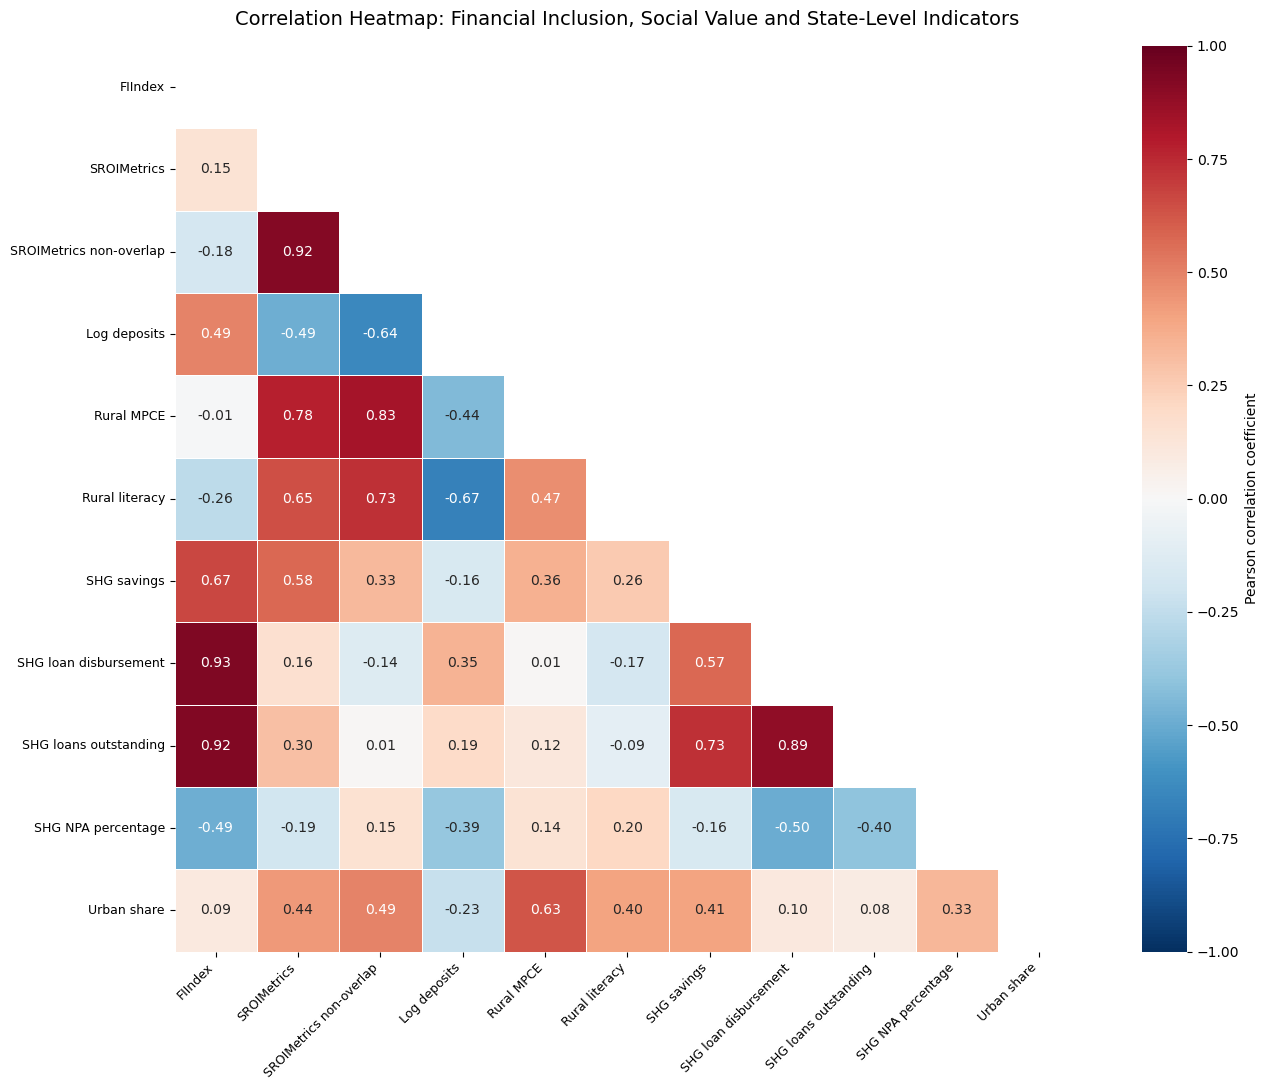

In [377]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the existing complete-case correlation dataset
heatmap_data = correlation_data[
    available_correlation_vars
].copy()

# Renaming variables for report presentation
label_map = {
    "FIIndex": "FIIndex",
    "SROIMetrics": "SROIMetrics",
    "SROIMetrics_nonoverlap": "SROIMetrics non-overlap",
    "log_deposits_total_2017_18": "Log deposits",
    "MPCE_rural_22_noimp": "Rural MPCE",
    "Literacy_rural_7plus": "Rural literacy",
    "shg_savings_per_10k_rural_households": "SHG savings",
    "shg_loans_disbursed_per_10k_rural_households": "SHG loan disbursement",
    "shg_loans_outstanding_per_10k_rural_households": "SHG loans outstanding",
    "tot_npa_pct": "SHG NPA percentage",
    "urban_share_2011": "Urban share"
}

heatmap_data = heatmap_data.rename(
    columns=label_map
)

correlation_heatmap = heatmap_data.corr(
    method="pearson"
)

# Creating a mask for the upper triangle
mask = np.triu(
    np.ones_like(correlation_heatmap, dtype=bool)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_heatmap,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Pearson correlation coefficient"
    }
)

plt.title(
    "Correlation Heatmap: Financial Inclusion, Social Value and State-Level Indicators",
    fontsize=14,
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "Figure_1_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

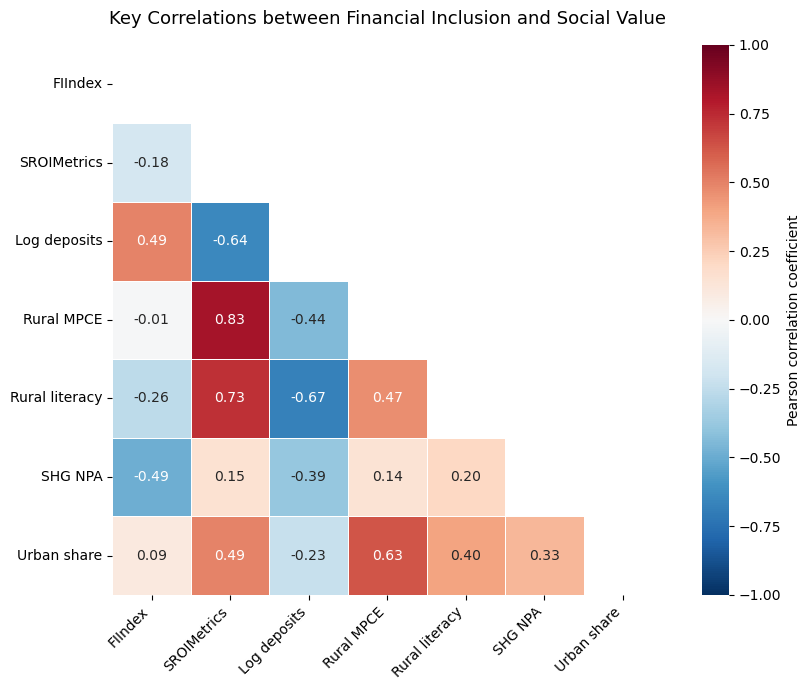

In [378]:
key_heatmap_vars = [
    "FIIndex",
    "SROIMetrics_nonoverlap",
    "log_deposits_total_2017_18",
    "MPCE_rural_22_noimp",
    "Literacy_rural_7plus",
    "tot_npa_pct",
    "urban_share_2011"
]

key_labels = {
    "FIIndex": "FIIndex",
    "SROIMetrics_nonoverlap": "SROIMetrics",
    "log_deposits_total_2017_18": "Log deposits",
    "MPCE_rural_22_noimp": "Rural MPCE",
    "Literacy_rural_7plus": "Rural literacy",
    "tot_npa_pct": "SHG NPA",
    "urban_share_2011": "Urban share"
}

key_correlation = (
    analysis_data[key_heatmap_vars]
    .dropna()
    .rename(columns=key_labels)
    .corr()
)

mask = np.triu(
    np.ones_like(key_correlation, dtype=bool)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    key_correlation,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Pearson correlation coefficient"
    }
)

plt.title(
    "Key Correlations between Financial Inclusion and Social Value",
    fontsize=13,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "Figure_1_Key_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Model 1: FIIndex and social value

In [379]:
model1_vars = [
    "FIIndex",
    "SROIMetrics_nonoverlap",
    "urban_share_2011",
    "Literacy_rural_7plus"
]

model1_data = (
    analysis_data[model1_vars]
    .dropna()
    .copy()
)

y1 = model1_data["FIIndex"]

X1 = model1_data[
    [
        "SROIMetrics_nonoverlap",
        "urban_share_2011",
        "Literacy_rural_7plus"
    ]
]

X1 = sm.add_constant(X1)

model1 = sm.OLS(
    y1,
    X1
).fit(
    cov_type="HC1"
)

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                FIIndex   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     3.050
Date:                Mon, 10 Aug 2026   Prob (F-statistic):             0.0463
Time:                        17:58:39   Log-Likelihood:                 13.102
No. Observations:                  30   AIC:                            -18.20
Df Residuals:                      26   BIC:                            -12.60
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

### Model 2: Financial depth and social value

In [380]:
model2_vars = [
    "SROIMetrics_nonoverlap",
    "log_deposits_total_2017_18",
    "urban_share_2011",
    "Literacy_rural_7plus"
]

model2_data = (
    analysis_data[model2_vars]
    .dropna()
    .copy()
)

y2 = model2_data["SROIMetrics_nonoverlap"]

X2 = model2_data[
    [
        "log_deposits_total_2017_18",
        "urban_share_2011",
        "Literacy_rural_7plus"
    ]
]

X2 = sm.add_constant(X2)

model2 = sm.OLS(
    y2,
    X2
).fit(
    cov_type="HC1"
)

print(model2.summary())

                              OLS Regression Results                              
Dep. Variable:     SROIMetrics_nonoverlap   R-squared:                       0.627
Model:                                OLS   Adj. R-squared:                  0.584
Method:                     Least Squares   F-statistic:                     20.79
Date:                    Mon, 10 Aug 2026   Prob (F-statistic):           4.42e-07
Time:                            17:59:37   Log-Likelihood:                 26.379
No. Observations:                      30   AIC:                            -44.76
Df Residuals:                          26   BIC:                            -39.15
Df Model:                               3                                         
Covariance Type:                      HC1                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

### Model 3: SHG NPA intensity and social value

In [381]:
model3_vars = [
    "SROIMetrics_nonoverlap",
    "tot_npa_pct",
    "FIIndex",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]

model3_data = (
    analysis_data[model3_vars]
    .dropna()
    .copy()
)

y3 = model3_data["SROIMetrics_nonoverlap"]

X3 = model3_data[
    [
        "tot_npa_pct",
        "FIIndex",
        "MPCE_rural_22_noimp",
        "urban_share_2011"
    ]
]

X3 = sm.add_constant(X3)

model3 = sm.OLS(
    y3,
    X3
).fit(
    cov_type="HC1"
)

print(model3.summary())

                              OLS Regression Results                              
Dep. Variable:     SROIMetrics_nonoverlap   R-squared:                       0.726
Model:                                OLS   Adj. R-squared:                  0.682
Method:                     Least Squares   F-statistic:                     35.31
Date:                    Mon, 10 Aug 2026   Prob (F-statistic):           6.03e-10
Time:                            18:00:11   Log-Likelihood:                 30.984
No. Observations:                      30   AIC:                            -51.97
Df Residuals:                          25   BIC:                            -44.96
Df Model:                               4                                         
Covariance Type:                      HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [382]:
def tidy_ols(model, model_name):
    output = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Robust standard error": model.bse.values,
        "p-value": model.pvalues.values
    })

    output["Model"] = model_name
    return output

regression_table = pd.concat(
    [
        tidy_ols(model1, "Model 1: FIIndex"),
        tidy_ols(model2, "Model 2: SROIMetrics"),
        tidy_ols(model3, "Model 3: NPA and SROIMetrics")
    ],
    ignore_index=True
)

regression_table.round(4)

,Variable,Coefficient,Robust standard error,p-value,Model
0,const,0.8508,0.4163,0.0410,Model 1: FIIndex
1,SROIMetrics_nonoverlap,-0.0905,0.2655,0.7332,Model 1: FIIndex
2,urban_share_2011,0.2187,0.1881,0.2450,Model 1: FIIndex
3,Literacy_rural_7plus,-0.0068,0.0060,0.2542,Model 1: FIIndex
4,const,-0.1195,0.4975,0.8102,Model 2: SROIMetrics
5,log_deposits_total_2017_18,-0.0264,0.0214,0.2178,Model 2: SROIMetrics
6,urban_share_2011,0.2099,0.1363,0.1236,Model 2: SROIMetrics
7,Literacy_rural_7plus,0.0099,0.0033,0.0024,Model 2: SROIMetrics
8,const,0.1018,0.0768,0.1853,Model 3: NPA and SROIMetrics
9,tot_npa_pct,-0.0007,0.0014,0.6062,Model 3: NPA and SROIMetrics


In [383]:
model_statistics = pd.DataFrame({
    "Model": [
        "Model 1: FIIndex",
        "Model 2: SROIMetrics",
        "Model 3: NPA and SROIMetrics"
    ],
    "Observations": [
        int(model1.nobs),
        int(model2.nobs),
        int(model3.nobs)
    ],
    "R-squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared
    ],
    "Adjusted R-squared": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj
    ],
    "F-statistic p-value": [
        model1.f_pvalue,
        model2.f_pvalue,
        model3.f_pvalue
    ]
})

model_statistics.round(4)

,Model,Observations,R-squared,Adjusted R-squared,F-statistic p-value
0,Model 1: FIIndex,30,0.1171,0.0152,0.0463
1,Model 2: SROIMetrics,30,0.6271,0.5840,0.0000
2,Model 3: NPA and SROIMetrics,30,0.7257,0.6818,0.0000


In [384]:
regression_table.to_csv(
    "Table_8_Regression_Coefficients.csv",
    index=False
)

model_statistics.to_csv(
    "Table_8_Regression_Model_Statistics.csv",
    index=False
)

In [385]:
compact_regression = pd.DataFrame({
    "Variable": [
        "SROIMetrics_nonoverlap",
        "Log deposits",
        "SHG NPA percentage",
        "Urban share",
        "Rural literacy",
        "Rural MPCE",
        "FIIndex",
        "Constant"
    ],
    "Model 1: FIIndex": [
        model1.params.get("SROIMetrics_nonoverlap", np.nan),
        np.nan,
        np.nan,
        model1.params.get("urban_share_2011", np.nan),
        model1.params.get("Literacy_rural_7plus", np.nan),
        np.nan,
        np.nan,
        model1.params.get("const", np.nan)
    ],
    "Model 2: SROIMetrics": [
        np.nan,
        model2.params.get("log_deposits_total_2017_18", np.nan),
        np.nan,
        model2.params.get("urban_share_2011", np.nan),
        model2.params.get("Literacy_rural_7plus", np.nan),
        np.nan,
        np.nan,
        model2.params.get("const", np.nan)
    ],
    "Model 3: NPA and SROIMetrics": [
        np.nan,
        np.nan,
        model3.params.get("tot_npa_pct", np.nan),
        model3.params.get("urban_share_2011", np.nan),
        np.nan,
        model3.params.get("MPCE_rural_22_noimp", np.nan),
        model3.params.get("FIIndex", np.nan),
        model3.params.get("const", np.nan)
    ]
})

compact_regression.round(4)

,Variable,Model 1: FIIndex,Model 2: SROIMetrics,Model 3: NPA and SROIMetrics
0,SROIMetrics_nonoverlap,-0.0905,NaN,NaN
1,Log deposits,NaN,-0.0264,NaN
2,SHG NPA percentage,NaN,NaN,-0.0007
3,Urban share,0.2187,0.2099,0.0109
4,Rural literacy,-0.0068,0.0099,NaN
5,Rural MPCE,NaN,NaN,0.0001
6,FIIndex,NaN,NaN,-0.2035
7,Constant,0.8508,-0.1195,0.1018


In [386]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = model3_data[
    [
        "tot_npa_pct",
        "FIIndex",
        "MPCE_rural_22_noimp",
        "urban_share_2011"
    ]
].copy()

vif_data = sm.add_constant(vif_data)

vif_table = pd.DataFrame({
    "Variable": vif_data.columns,
    "VIF": [
        variance_inflation_factor(
            vif_data.values,
            i
        )
        for i in range(vif_data.shape[1])
    ]
})

vif_table

,Variable,VIF
0,const,21.985113
1,tot_npa_pct,1.666702
2,FIIndex,1.498446
3,MPCE_rural_22_noimp,1.712398
4,urban_share_2011,2.075936


In [387]:
from sklearn.preprocessing import StandardScaler

standardise_vars = [
    "tot_npa_pct",
    "FIIndex",
    "MPCE_rural_22_noimp",
    "urban_share_2011"
]

model3_standardised = model3_data.copy()

scaler = StandardScaler()

model3_standardised[
    standardise_vars
] = scaler.fit_transform(
    model3_standardised[standardise_vars]
)

y3_std = model3_standardised[
    "SROIMetrics_nonoverlap"
]

X3_std = model3_standardised[
    standardise_vars
]

X3_std = sm.add_constant(X3_std)

model3_std = sm.OLS(
    y3_std,
    X3_std
).fit(
    cov_type="HC1"
)

print(model3_std.summary())

                              OLS Regression Results                              
Dep. Variable:     SROIMetrics_nonoverlap   R-squared:                       0.726
Model:                                OLS   Adj. R-squared:                  0.682
Method:                     Least Squares   F-statistic:                     35.31
Date:                    Mon, 10 Aug 2026   Prob (F-statistic):           6.03e-10
Time:                            18:09:20   Log-Likelihood:                 30.984
No. Observations:                      30   AIC:                            -51.97
Df Residuals:                          25   BIC:                            -44.96
Df Model:                               4                                         
Covariance Type:                      HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

#### Figure 2. Correlation Heatmap

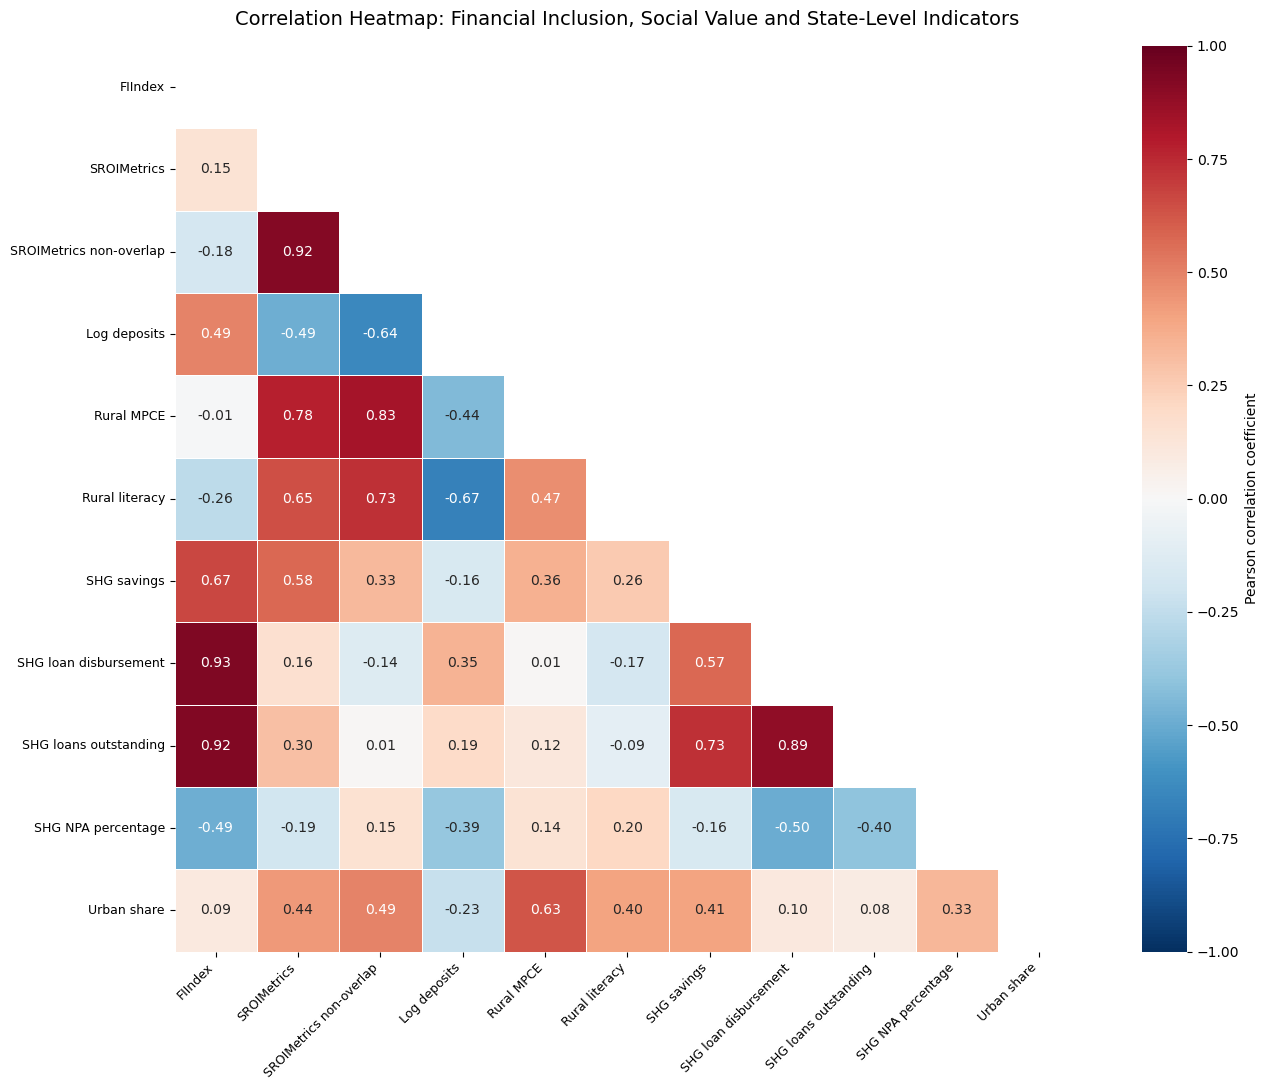

In [388]:
heatmap_labels = {
    "FIIndex": "FIIndex",
    "SROIMetrics": "SROIMetrics",
    "SROIMetrics_nonoverlap": "SROIMetrics non-overlap",
    "log_deposits_total_2017_18": "Log deposits",
    "MPCE_rural_22_noimp": "Rural MPCE",
    "Literacy_rural_7plus": "Rural literacy",
    "shg_savings_per_10k_rural_households": "SHG savings",
    "shg_loans_disbursed_per_10k_rural_households": "SHG loan disbursement",
    "shg_loans_outstanding_per_10k_rural_households": "SHG loans outstanding",
    "tot_npa_pct": "SHG NPA percentage",
    "urban_share_2011": "Urban share"
}

heatmap_corr = (
    correlation_data[available_correlation_vars]
    .corr()
    .rename(index=heatmap_labels, columns=heatmap_labels)
)

mask = np.triu(
    np.ones_like(heatmap_corr, dtype=bool)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    heatmap_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Pearson correlation coefficient"
    }
)

plt.title(
    "Correlation Heatmap: Financial Inclusion, Social Value and State-Level Indicators",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

plt.savefig(
    "Figure_1_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [389]:
fiindex_appendix = (
    fi_state_data[
        [
            "statename",
            "FIIndex",
            "log_deposits_total_2017_18",
            "shg_savings_per_10k_rural_households",
            "shg_loans_disbursed_per_10k_rural_households",
            "shg_loans_outstanding_per_10k_rural_households"
        ]
    ]
    .sort_values(
        by="FIIndex",
        ascending=False
    )
    .round(6)
)

fiindex_appendix.to_csv(
    "Appendix_Table_A1_Full_FIIndex_Values.csv",
    index=False
)

fiindex_appendix

,statename,FIIndex,log_deposits_total_2017_18,shg_savings_per_10k_rural_households,shg_loans_disbursed_per_10k_rural_households,shg_loans_outstanding_per_10k_rural_households
15,KARNATAKA,0.811718,13.635980,1051.565457,502.469151,936.845519
26,PUDUCHERRY,0.673508,9.695326,2601.822813,259.635017,766.591593
35,WEST BENGAL,0.506981,13.485033,613.377890,250.929458,450.900282
30,TAMIL NADU,0.501598,13.482436,1098.917510,172.145759,395.651150
1,ANDHRA PRADESH,0.489814,12.522947,651.630450,220.919945,543.834448
16,KERALA,0.476763,12.998892,714.011164,218.736994,418.908527
20,MAHARASHTRA,0.385863,14.645295,641.927975,84.786395,157.944108
25,ODISHA,0.379327,12.502115,655.735294,137.714684,287.942366
4,BIHAR,0.350643,12.659729,352.720226,134.404202,281.631198
32,TRIPURA,0.326011,9.999717,870.508708,16.542812,534.170637


In [390]:
sroi_appendix = (
    sroi_state_data[
        [
            "statename",
            "SROIMetrics",
            "SROIMetrics_nonoverlap",
            "MPCE_rural_22_noimp",
            "MPCE_urban_22_noimp",
            "Literacy_rural_7plus",
            "PPRA_total_2017_18",
            "shg_savings_per_10k_rural_households",
            "tot_npa_pct"
        ]
    ]
    .sort_values(
        by="SROIMetrics",
        ascending=False
    )
    .round(6)
)

sroi_appendix.to_csv(
    "Appendix_Table_A2_Full_SROIMetrics_Values.csv",
    index=False
)

sroi_appendix

,statename,SROIMetrics,SROIMetrics_nonoverlap,MPCE_rural_22_noimp,MPCE_urban_22_noimp,Literacy_rural_7plus,PPRA_total_2017_18,shg_savings_per_10k_rural_households,tot_npa_pct
29,SIKKIM,0.769890,0.850701,7731.0,12105.0,87.866667,3.4,651.423549,2.18
26,PUDUCHERRY,0.763617,0.694551,6590.0,7706.0,90.333333,2.2,2601.822813,17.13
9,GOA,0.672058,0.716403,7367.0,8734.0,89.366667,5.9,640.989642,5.65
23,MIZORAM,0.652000,0.697837,5224.0,7655.0,99.766667,3.4,844.327675,15.37
5,CHANDIGARH,0.650667,0.811351,7467.0,12575.0,90.266667,9.4,500.000000,40.00
24,NAGALAND,0.594856,0.639685,4393.0,7098.0,96.500000,0.8,235.431059,5.15
30,TAMIL NADU,0.567040,0.534348,5310.0,7630.0,83.833333,6.1,1098.917510,12.18
15,KARNATAKA,0.556023,0.494810,4397.0,7666.0,82.000000,4.3,1051.565457,3.73
32,TRIPURA,0.548886,0.631395,5206.0,7405.0,92.766667,3.1,870.508708,43.02
2,ARUNACHAL PRADESH,0.532399,0.614140,5276.0,8636.0,85.800000,2.9,299.685330,27.85


In [391]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe, variables):
    vif_data = dataframe[variables].dropna().copy()
    vif_data = sm.add_constant(vif_data)

    vif_table = pd.DataFrame({
        "Variable": vif_data.columns,
        "VIF": [
            variance_inflation_factor(
                vif_data.values,
                i
            )
            for i in range(vif_data.shape[1])
        ]
    })

    return vif_table

In [392]:
model1_vif = calculate_vif(
    analysis_data,
    [
        "SROIMetrics_nonoverlap",
        "urban_share_2011",
        "Literacy_rural_7plus"
    ]
)

model1_vif

,Variable,VIF
0,const,209.205535
1,SROIMetrics_nonoverlap,2.385072
2,urban_share_2011,1.327292
3,Literacy_rural_7plus,2.159148


In [393]:
model2_vif = calculate_vif(
    analysis_data,
    [
        "log_deposits_total_2017_18",
        "urban_share_2011",
        "Literacy_rural_7plus"
    ]
)

model2_vif

,Variable,VIF
0,const,536.230041
1,log_deposits_total_2017_18,1.842037
2,urban_share_2011,1.199821
3,Literacy_rural_7plus,2.085270


In [394]:
model1_vif["Model"] = "Model 1"
model2_vif["Model"] = "Model 2"

model3_vif = calculate_vif(
    analysis_data,
    [
        "tot_npa_pct",
        "FIIndex",
        "MPCE_rural_22_noimp",
        "urban_share_2011"
    ]
)

model3_vif["Model"] = "Model 3"

all_vif = pd.concat(
    [
        model1_vif,
        model2_vif,
        model3_vif
    ],
    ignore_index=True
)

all_vif.to_csv(
    "Table_9_VIF_Diagnostics.csv",
    index=False
)

all_vif

,Variable,VIF,Model
0,const,209.205535,Model 1
1,SROIMetrics_nonoverlap,2.385072,Model 1
2,urban_share_2011,1.327292,Model 1
3,Literacy_rural_7plus,2.159148,Model 1
4,const,536.230041,Model 2
5,log_deposits_total_2017_18,1.842037,Model 2
6,urban_share_2011,1.199821,Model 2
7,Literacy_rural_7plus,2.085270,Model 2
8,const,21.985113,Model 3
9,tot_npa_pct,1.666702,Model 3


In [395]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import FancyBboxPatch

sns.set_theme(
    style="whitegrid",
    context="paper"
)

#### Figure 1. Conceptual framework

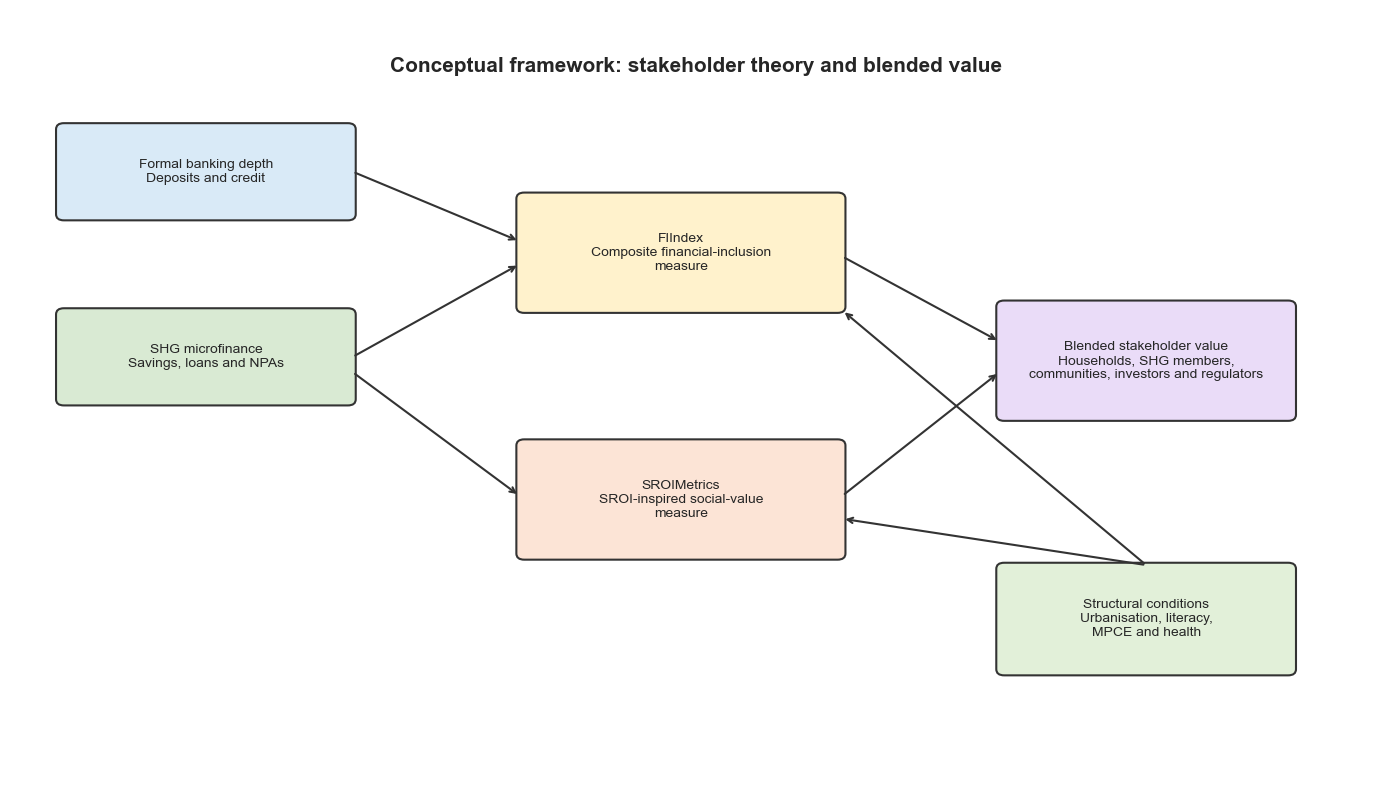

In [396]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

def add_box(x, y, width, height, text, colour):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="#333333",
        facecolor=colour
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

def add_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops={
            "arrowstyle": "->",
            "lw": 1.5,
            "color": "#333333"
        }
    )

# Main boxes
add_box(
    0.5, 7.3, 3.0, 1.2,
    "Formal banking depth\nDeposits and credit",
    "#D9EAF7"
)

add_box(
    0.5, 4.9, 3.0, 1.2,
    "SHG microfinance\nSavings, loans and NPAs",
    "#D9EAD3"
)

add_box(
    5.2, 6.1, 3.3, 1.5,
    "FIIndex\nComposite financial-inclusion\nmeasure",
    "#FFF2CC"
)

add_box(
    5.2, 2.9, 3.3, 1.5,
    "SROIMetrics\nSROI-inspired social-value\nmeasure",
    "#FCE4D6"
)

add_box(
    10.1, 4.7, 3.0, 1.5,
    "Blended stakeholder value\nHouseholds, SHG members,\ncommunities, investors and regulators",
    "#EADCF8"
)

add_box(
    10.1, 1.4, 3.0, 1.4,
    "Structural conditions\nUrbanisation, literacy,\nMPCE and health",
    "#E2F0D9"
)

# Arrows
add_arrow(3.5, 7.9, 5.2, 7.0)
add_arrow(3.5, 5.5, 5.2, 6.7)
add_arrow(3.5, 5.3, 5.2, 3.7)
add_arrow(8.5, 6.8, 10.1, 5.7)
add_arrow(8.5, 3.7, 10.1, 5.3)
add_arrow(11.6, 2.8, 8.5, 3.4)
add_arrow(11.6, 2.8, 8.5, 6.1)

ax.text(
    7,
    9.2,
    "Conceptual framework: stakeholder theory and blended value",
    ha="center",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "Figure_1_Conceptual_Framework.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 3. State-level distribution of FIIndex

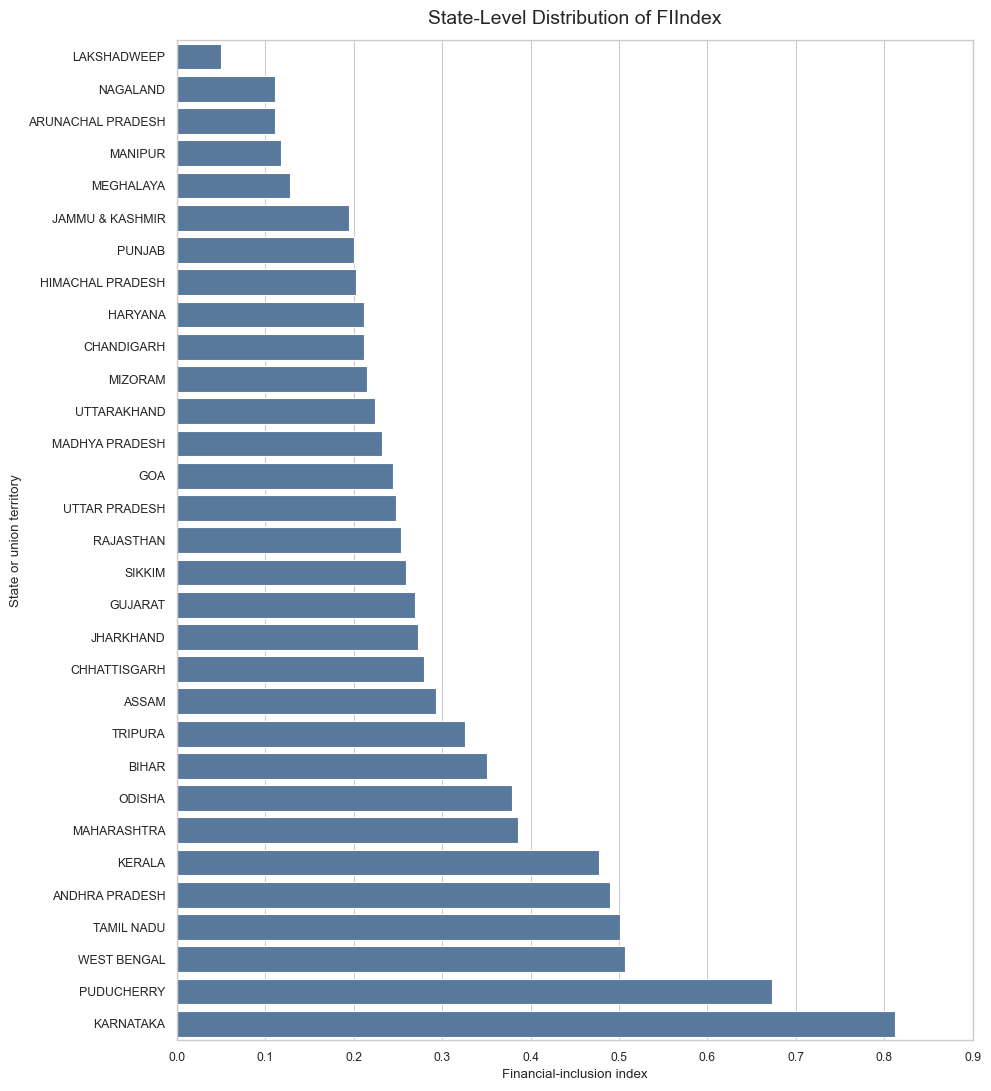

In [397]:
fi_plot = (
    fi_state_data[
        ["statename", "FIIndex"]
    ]
    .dropna()
    .sort_values(
        by="FIIndex",
        ascending=True
    )
)

plt.figure(figsize=(10, 11))

sns.barplot(
    data=fi_plot,
    x="FIIndex",
    y="statename",
    color="#4C78A8"
)

plt.title(
    "State-Level Distribution of FIIndex",
    fontsize=14,
    pad=12
)

plt.xlabel("Financial-inclusion index")
plt.ylabel("State or union territory")
plt.xlim(0, 0.9)
plt.tight_layout()

plt.savefig(
    "Figure_3_State_Level_FIIndex_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 4. FIIndex and SROIMetrics relationship

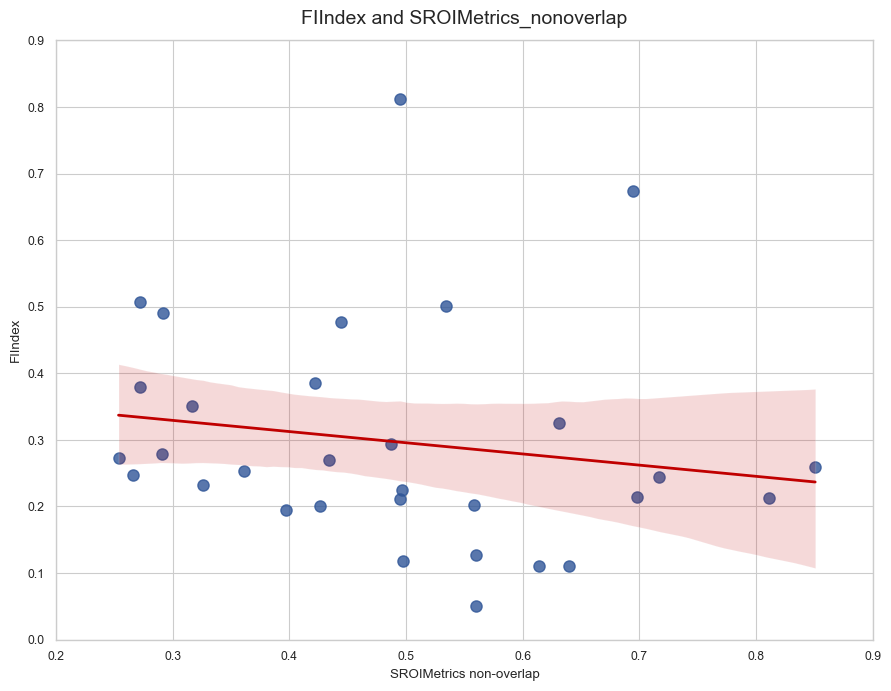

In [398]:
scatter_data = analysis_data[
    [
        "FIIndex",
        "SROIMetrics_nonoverlap",
        "statename"
    ]
].dropna()

plt.figure(figsize=(9, 7))

sns.regplot(
    data=scatter_data,
    x="SROIMetrics_nonoverlap",
    y="FIIndex",
    scatter_kws={
        "s": 65,
        "alpha": 0.8,
        "color": "#2F5597"
    },
    line_kws={
        "color": "#C00000",
        "linewidth": 2
    }
)

plt.title(
    "FIIndex and SROIMetrics_nonoverlap",
    fontsize=14,
    pad=12
)

plt.xlabel("SROIMetrics non-overlap")
plt.ylabel("FIIndex")
plt.xlim(0.2, 0.9)
plt.ylim(0, 0.9)
plt.tight_layout()

plt.savefig(
    "Figure_4_FIIndex_SROIMetrics_Relationship.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 5. Log deposits and hospital expenditure

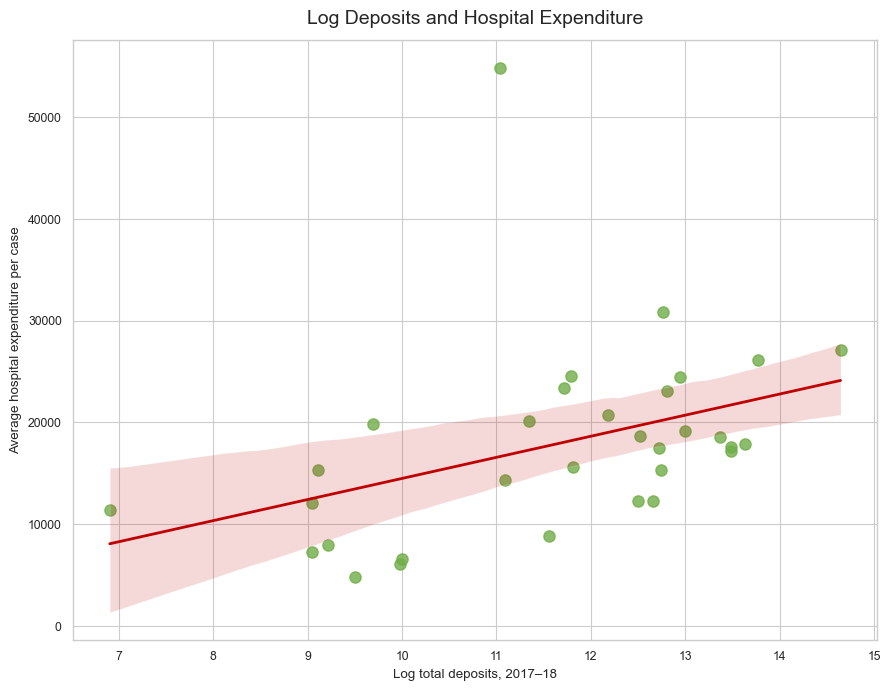

In [399]:
hospital_plot_data = analysis_data[
    [
        "log_deposits_total_2017_18",
        "HospExp_all_total_2017_18"
    ]
].dropna()

plt.figure(figsize=(9, 7))

sns.regplot(
    data=hospital_plot_data,
    x="log_deposits_total_2017_18",
    y="HospExp_all_total_2017_18",
    scatter_kws={
        "s": 65,
        "alpha": 0.8,
        "color": "#70AD47"
    },
    line_kws={
        "color": "#C00000",
        "linewidth": 2
    }
)

plt.title(
    "Log Deposits and Hospital Expenditure",
    fontsize=14,
    pad=12
)

plt.xlabel("Log total deposits, 2017–18")
plt.ylabel("Average hospital expenditure per case")
plt.tight_layout()

plt.savefig(
    "Figure_5_Log_Deposits_Hospital_Expenditure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 6. SHG microfinance and formal financial depth

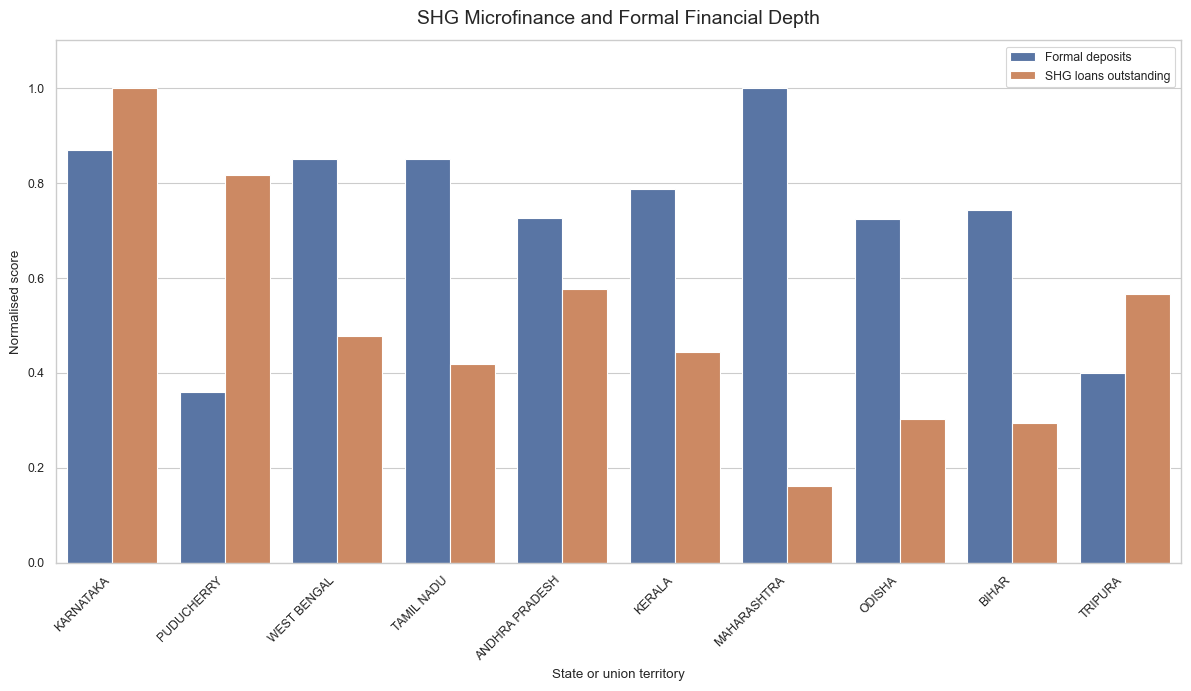

In [400]:
depth_plot = fi_state_data[
    [
        "statename",
        "FIIndex",
        "log_deposits_total_2017_18_norm",
        "shg_loans_outstanding_per_10k_rural_households_norm"
    ]
].dropna().sort_values(
    by="FIIndex",
    ascending=False
).head(10)

depth_plot = depth_plot.rename(
    columns={
        "log_deposits_total_2017_18_norm": "Formal deposits",
        "shg_loans_outstanding_per_10k_rural_households_norm":
            "SHG loans outstanding"
    }
)

depth_long = depth_plot.melt(
    id_vars=["statename", "FIIndex"],
    value_vars=[
        "Formal deposits",
        "SHG loans outstanding"
    ],
    var_name="Measure",
    value_name="Normalised score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=depth_long,
    x="statename",
    y="Normalised score",
    hue="Measure"
)

plt.title(
    "SHG Microfinance and Formal Financial Depth",
    fontsize=14,
    pad=12
)

plt.xlabel("State or union territory")
plt.ylabel("Normalised score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="")
plt.tight_layout()

plt.savefig(
    "Figure_6_SHG_Formal_Financial_Depth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()